# 資料前處理

## Cell 1：設定與掛載 Google Drive

In [1]:
# Cell 1: 環境設定與掛載
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
from pathlib import Path

def clean_ticker_col(df):
    """清理股票代碼欄位的 =「xxxx」格式"""
    col_ticker = df.columns[0]
    df[col_ticker] = df[col_ticker].astype(str).str.replace(r'^="(.*)"$', r'\1', regex=True)
    return df


Mounted at /content/drive


In [2]:
!pip install linearmodels --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.9 MB/s eta 0:00:00


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 3s (19.3 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
✅ 已清除 Matplotlib 快取: /root/.cache/matplotlib
✅ 成功註冊字型：Noto Sans CJK JP


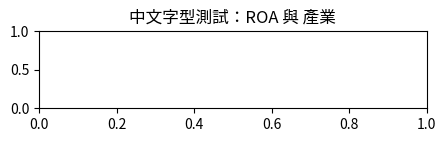

In [3]:
# 1. 安裝字型
!apt-get install -y fonts-noto-cjk

# 2. 刪除 Matplotlib 的舊快取 (這是最重要的一步，否則它永遠找不到新裝的字型)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 清除快取路徑
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    !rm -rf {cache_dir}
    print(f"✅ 已清除 Matplotlib 快取: {cache_dir}")

# 3. 手動將字型檔案加入字型管理器 (確保路徑正確)
# Noto Sans CJK TC 的預設安裝路徑通常如下
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    # 這裡要注意：在 Linux 下，該字型的內部名稱可能是 'Noto Sans CJK JP'
    # (因為 TTC 檔通常包含多國語言，JP 是基底)，或者就是 'Noto Sans CJK TC'
    # 我們可以透過以下方式抓取正確名稱：
    prop = fm.FontProperties(fname=font_path)
    font_name = prop.get_name()

    plt.rc('font', family=font_name)
    print(f"✅ 成功註冊字型：{font_name}")
else:
    print("❌ 找不到字型檔，請確認安裝路徑")

# 4. 解決負號顯示問題
plt.rcParams['axes.unicode_minus'] = False

# 測試繪圖
plt.figure(figsize=(5,1))
plt.title("中文字型測試：ROA 與 產業")
plt.show()

In [4]:
# ===== 路徑設定 =====
BASE_PATH = Path('/content/drive/MyDrive/Paper II/ESG_Data')

FOLDERS = ['TEJ', 'ESG數位平台', '財務績效']
YEARS = ['2021', '2022', '2023', '2024']

# 各資料夾對應的檔案格式
FOLDER_EXT = {
    'TEJ': '*.xlsx',
    'ESG數位平台': '*.csv',
    '財務績效': '*.xlsx',
}

# 全域快取，Cell 3 和 get_df() 都會寫入這裡
data_store = {}

print(f"資料根目錄：{BASE_PATH}")
print(f"子資料夾：{FOLDERS}")
print(f"年份：{YEARS}")

資料根目錄：/content/drive/MyDrive/Paper II/ESG_Data
子資料夾：['TEJ', 'ESG數位平台', '財務績效']
年份：['2021', '2022', '2023', '2024']


In [5]:
# Cell 1.5: 載入台灣上市公司名單，建立合格公司集合

def load_listed_companies():
    fpath = BASE_PATH / '台灣上市公司.xlsx'
    df = pd.read_excel(fpath, engine='openpyxl')
    df.columns = ['代號', '名稱', '目前狀態', '上市別'] + list(df.columns[4:])

    df_valid = df[
        (df['目前狀態'].str.strip() == 'Current') &
        (df['上市別'].str.strip() == 'TSE')
    ]

    valid_tickers = set(df_valid['代號'].astype(str))

    print(f"✅ 台灣上市公司名單載入完成")
    print(f"   總筆數：{len(df)}")
    print(f"   符合條件（Current + TSE）：{len(valid_tickers)} 家")

    return df, valid_tickers  # 同時回傳 df_listed 和 VALID_TICKERS

df_listed, VALID_TICKERS = load_listed_companies()  # 存成全域變數

✅ 台灣上市公司名單載入完成
   總筆數：1057
   符合條件（Current + TSE）：1057 家


## Cell 2：掃描所有 xlsx 檔案路徑

In [6]:
# Cell 2: 掃描並列印所有檔案路徑

def scan_all_files(base_path, folders, years, folder_ext):
    file_registry = {}
    total_count = 0

    for folder in folders:
        file_registry[folder] = {}
        ext_pattern = folder_ext[folder]

        for year in years:
            dir_path = base_path / folder / year
            if not dir_path.exists():
                print(f"[WARNING] 資料夾不存在：{dir_path}")
                file_registry[folder][year] = []
                continue

            files = sorted(dir_path.glob(ext_pattern))
            file_registry[folder][year] = files
            total_count += len(files)

            print(f"\n📁 {folder} / {year}  ({len(files)} 個檔案)")
            for f in files:
                print(f"   └─ {f}")

    print(f"\n{'='*60}")
    print(f"✅ 共掃描到 {total_count} 個檔案")
    return file_registry

file_registry = scan_all_files(BASE_PATH, FOLDERS, YEARS, FOLDER_EXT)


📁 TEJ / 2021  (18 個檔案)
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/G_人事穩定度.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/G_社會責任新聞.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/G_股權結構(控制持股與董監結構).xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/G_董監出席狀況彙總-開會次數.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/G_董監職責與專業度.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/G_董監責任險.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/G_資訊透明度.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/S_1.組織治理_TWSE公司治理評鑑.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/S_2.人權議題_企業進用身障人不足額.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/S_3.員工及幸福企業__員工性別組成.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/S_3.員工及幸福企業_員工學歷構成.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/S_3.員工及幸福企業_員工流動率.xlsx
   └─ /content/drive/MyDrive/Paper II/ESG_Data/TEJ/2021/S_3.員工及幸福企業_員

## Cell 3：批次讀取所有檔案

In [7]:
# Cell 3: 批次讀取所有檔案
def remove_thousand_separator(df):
    """去除數值欄位的千分位逗號（處理 2023/2024 年格式變更）"""
    for col in df.columns:
        if df[col].dtype == object:
            sample = df[col].dropna().head(20)
            # 只處理看起來像數字但有千分位逗號的欄位
            has_numeric_comma = sample.str.match(
                r'^-?[\d,]+\.?\d*$', na=False
            ).any()
            if has_numeric_comma:
                df[col] = df[col].str.replace(',', '', regex=False)
                df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def batch_load_all(file_registry):
    error_log = []
    for folder, years in file_registry.items():
        data_store.setdefault(folder, {})
        for year, file_list in years.items():
            data_store[folder].setdefault(year, {})
            for fpath in file_list:
                if fpath.name in data_store[folder][year]:
                    print(f"⏭️ 已存在，跳過：{folder}/{year}/{fpath.name}")
                    continue
                try:
                    if fpath.suffix == '.csv':
                        df = pd.read_csv(fpath, encoding='utf-8-sig', skiprows=1)
                        df = clean_ticker_col(df)       # 清理 ="xxxx" 格式
                        df = remove_thousand_separator(df)  # 去除千分位逗號
                    else:
                        df = pd.read_excel(fpath, engine='openpyxl')
                    data_store[folder][year][fpath.name] = df
                    print(f"✅ 已讀取：{folder}/{year}/{fpath.name}  →  {df.shape[0]} 列 × {df.shape[1]} 欄")
                except Exception as e:
                    error_log.append((str(fpath), str(e)))
                    print(f"❌ 讀取失敗：{fpath.name}  →  {e}")
    print(f"\n{'='*60}")
    print(f"批次讀取完成，失敗 {len(error_log)} 個檔案")
    if error_log:
        for path, err in error_log:
            print(f"   └─ {path}: {err}")

In [8]:
# data_store = {}
batch_load_all(file_registry)

✅ 已讀取：TEJ/2021/G_人事穩定度.xlsx  →  11842 列 × 18 欄
✅ 已讀取：TEJ/2021/G_社會責任新聞.xlsx  →  1595 列 × 7 欄
✅ 已讀取：TEJ/2021/G_股權結構(控制持股與董監結構).xlsx  →  11842 列 × 105 欄
✅ 已讀取：TEJ/2021/G_董監出席狀況彙總-開會次數.xlsx  →  2998 列 × 12 欄
✅ 已讀取：TEJ/2021/G_董監職責與專業度.xlsx  →  993 列 × 39 欄
✅ 已讀取：TEJ/2021/G_董監責任險.xlsx  →  1263 列 × 9 欄
✅ 已讀取：TEJ/2021/G_資訊透明度.xlsx  →  11830 列 × 31 欄
✅ 已讀取：TEJ/2021/S_1.組織治理_TWSE公司治理評鑑.xlsx  →  946 列 × 8 欄
✅ 已讀取：TEJ/2021/S_2.人權議題_企業進用身障人不足額.xlsx  →  7532 列 × 12 欄
✅ 已讀取：TEJ/2021/S_3.員工及幸福企業__員工性別組成.xlsx  →  665 列 × 13 欄
✅ 已讀取：TEJ/2021/S_3.員工及幸福企業_員工學歷構成.xlsx  →  1019 列 × 18 欄
✅ 已讀取：TEJ/2021/S_3.員工及幸福企業_員工流動率.xlsx  →  1024 列 × 9 欄
✅ 已讀取：TEJ/2021/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx  →  520 列 × 23 欄
✅ 已讀取：TEJ/2021/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx  →  979 列 × 12 欄
✅ 已讀取：TEJ/2021/S_5.估評運作實務_企業違法情形.xlsx  →  43 列 × 11 欄
✅ 已讀取：TEJ/2021/S_6.產品及消費者議題_MIT產品標章認證.xlsx  →  1882 列 × 10 欄
✅ 已讀取：TEJ/2021/S_6.產品及消費者議題_企業取得ISO認證情形.xlsx  →  1155 列 × 15 欄
✅ 已讀取：TEJ/2021/S_7.社會關懷_企業捐贈情形.xlsx  →  341 列 × 16 欄
✅ 已讀取：TEJ/2022/G_人事穩定度.

## Cell 3.5: 將 data_store 內所有檔案依資料結構分類

In [9]:
# Cell 3.5: 將 data_store 內所有檔案依資料結構與用途分類
# single_row_store : ESG 因子 - 一公司一行
# multi_row_store  : ESG 因子 - 一公司多行
# finance_store    : 財務績效

single_row_store = {}
multi_row_store  = {}
finance_store    = {}

for folder, years in data_store.items():
    for year, files in years.items():
        for filename, df in files.items():

            # 財務績效單獨放
            if folder == '財務績效':
                finance_store.setdefault(folder, {}).setdefault(year, {})[filename] = df
                print(f"[財務績效] {folder}/{year}/{filename}")
                continue

            # ESG 因子依結構分類
            col_ticker = df.columns[0]
            rows_per_company = df.groupby(col_ticker).size()
            is_single_row = rows_per_company.max() == 1

            target = single_row_store if is_single_row else multi_row_store
            target.setdefault(folder, {}).setdefault(year, {})[filename] = df

            label = '一公司一行' if is_single_row else '一公司多行'
            print(f"[{label}] {folder}/{year}/{filename}")

print(f"\n{'='*60}")
print(f"ESG 一公司一行：{sum(len(files) for years in single_row_store.values() for files in years.values())} 個檔案")
print(f"ESG 一公司多行：{sum(len(files) for years in multi_row_store.values() for files in years.values())} 個檔案")
print(f"財務績效：      {sum(len(files) for years in finance_store.values() for files in years.values())} 個檔案")

[一公司多行] TEJ/2021/G_人事穩定度.xlsx
[一公司多行] TEJ/2021/G_社會責任新聞.xlsx
[一公司多行] TEJ/2021/G_股權結構(控制持股與董監結構).xlsx
[一公司多行] TEJ/2021/G_董監出席狀況彙總-開會次數.xlsx
[一公司一行] TEJ/2021/G_董監職責與專業度.xlsx
[一公司多行] TEJ/2021/G_董監責任險.xlsx
[一公司多行] TEJ/2021/G_資訊透明度.xlsx
[一公司一行] TEJ/2021/S_1.組織治理_TWSE公司治理評鑑.xlsx
[一公司多行] TEJ/2021/S_2.人權議題_企業進用身障人不足額.xlsx
[一公司一行] TEJ/2021/S_3.員工及幸福企業__員工性別組成.xlsx
[一公司一行] TEJ/2021/S_3.員工及幸福企業_員工學歷構成.xlsx
[一公司一行] TEJ/2021/S_3.員工及幸福企業_員工流動率.xlsx
[一公司一行] TEJ/2021/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
[一公司一行] TEJ/2021/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx
[一公司多行] TEJ/2021/S_5.估評運作實務_企業違法情形.xlsx
[一公司多行] TEJ/2021/S_6.產品及消費者議題_MIT產品標章認證.xlsx
[一公司多行] TEJ/2021/S_6.產品及消費者議題_企業取得ISO認證情形.xlsx
[一公司多行] TEJ/2021/S_7.社會關懷_企業捐贈情形.xlsx
[一公司多行] TEJ/2022/G_人事穩定度.xlsx
[一公司多行] TEJ/2022/G_社會責任新聞.xlsx
[一公司多行] TEJ/2022/G_股權結構(控制持股與董監結構).xlsx
[一公司多行] TEJ/2022/G_董監出席狀況彙總-開會次數.xlsx
[一公司一行] TEJ/2022/G_董監職責與專業度.xlsx
[一公司多行] TEJ/2022/G_董監責任險.xlsx
[一公司多行] TEJ/2022/G_資訊透明度.xlsx
[一公司一行] TEJ/2022/S_1.組織治理_TWSE公司治理評鑑.xlsx
[一公司多行] TEJ/2022/S_2.人權議題_企業進

## Cell 7：檢查上市公司在 single_row_store 的資料完整性

In [10]:
# Cell 7: 角度一：每個檔案缺少哪些上市公司
# 同時建立 missing_by_company 供 Cell 8 使用

missing_by_company = {t: [] for t in VALID_TICKERS}

for folder, years in single_row_store.items():
    for year, files in years.items():
        for filename, df in files.items():
            col_ticker = df.columns[0]
            tickers_in_file = set(df[col_ticker].astype(str))
            missing = VALID_TICKERS - tickers_in_file

            print(f"\n📄 {folder}/{year}/{filename}")
            print(f"   涵蓋公司數：{len(tickers_in_file)}　缺少公司數：{len(missing)}")

            if missing:
                df_missing = df_listed[df_listed['代號'].astype(str).isin(missing)][['代號', '名稱']]
                df_missing = df_missing.sort_values('代號').reset_index(drop=True)
                # display(df_missing)

                for ticker in missing:
                    missing_by_company[ticker].append((folder, year, filename))

print(f"\n{'='*60}")
print(f"✅ 角度一完成，missing_by_company 已建立供 Cell 8 使用")


📄 TEJ/2021/G_董監職責與專業度.xlsx
   涵蓋公司數：993　缺少公司數：64

📄 TEJ/2021/S_1.組織治理_TWSE公司治理評鑑.xlsx
   涵蓋公司數：946　缺少公司數：111

📄 TEJ/2021/S_3.員工及幸福企業__員工性別組成.xlsx
   涵蓋公司數：665　缺少公司數：392

📄 TEJ/2021/S_3.員工及幸福企業_員工學歷構成.xlsx
   涵蓋公司數：1019　缺少公司數：38

📄 TEJ/2021/S_3.員工及幸福企業_員工流動率.xlsx
   涵蓋公司數：1024　缺少公司數：33

📄 TEJ/2021/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
   涵蓋公司數：520　缺少公司數：537

📄 TEJ/2021/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx
   涵蓋公司數：979　缺少公司數：78

📄 TEJ/2022/G_董監職責與專業度.xlsx
   涵蓋公司數：1011　缺少公司數：46

📄 TEJ/2022/S_1.組織治理_TWSE公司治理評鑑.xlsx
   涵蓋公司數：966　缺少公司數：91

📄 TEJ/2022/S_3.員工及幸福企業__員工性別組成.xlsx
   涵蓋公司數：824　缺少公司數：233

📄 TEJ/2022/S_3.員工及幸福企業_員工學歷構成.xlsx
   涵蓋公司數：1030　缺少公司數：27

📄 TEJ/2022/S_3.員工及幸福企業_員工流動率.xlsx
   涵蓋公司數：1036　缺少公司數：21

📄 TEJ/2022/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
   涵蓋公司數：696　缺少公司數：361

📄 TEJ/2022/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx
   涵蓋公司數：1012　缺少公司數：45

📄 TEJ/2023/G_董監職責與專業度.xlsx
   涵蓋公司數：1028　缺少公司數：29

📄 TEJ/2023/S_1.組織治理_TWSE公司治理評鑑.xlsx
   涵蓋公司數：986　缺少公司數：71

📄 TEJ/2023/S_3.員工及幸福企業__員工性別組成.xlsx
   涵蓋公司數：852　缺少公司數：205

📄 TEJ/20

In [11]:
# Cell 8: 角度二：每間公司缺少哪些檔案
# 需先執行 Cell 7 以建立 missing_by_company

companies_with_missing = {t: files for t, files in missing_by_company.items() if files}

print("=" * 60)
print("📋 角度二：每間公司缺少哪些檔案")
print("=" * 60)

if not companies_with_missing:
    print("✅ 所有上市公司在每個檔案中都有資料")
else:
    name_map = df_listed.set_index(df_listed['代號'].astype(str))['名稱'].to_dict()
    print(f"共 {len(companies_with_missing)} 間公司有缺少資料\n")

    for ticker in sorted(companies_with_missing):
        name = name_map.get(ticker, '未知')
        missing_files = companies_with_missing[ticker]
        print(f"  [{ticker}] {name}  缺少 {len(missing_files)} 個檔案：")
        for folder, year, filename in sorted(missing_files):
            print(f"    └─ {folder}/{year}/{filename}")

📋 角度二：每間公司缺少哪些檔案
共 598 間公司有缺少資料

  [1108] 幸福  缺少 3 個檔案：
    └─ TEJ/2021/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2022/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2023/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
  [1210] 大成  缺少 4 個檔案：
    └─ TEJ/2021/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2022/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2023/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2024/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
  [1213] 大飲  缺少 4 個檔案：
    └─ TEJ/2021/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2022/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2023/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2024/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
  [1216] 統一  缺少 4 個檔案：
    └─ TEJ/2021/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2022/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2023/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2024/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
  [1232] 大統益  缺少 4 個檔案：
    └─ TEJ/2021/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2022/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2023/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/2024/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
  [1256] 鮮活果汁-KY  缺少 4 個檔案：
    └─

In [12]:
# Cell 9: 計算在 single_row_store 中所有檔案都有資料的公司數

# 找出有缺失的公司（missing_by_company 由 Cell 7 建立）
companies_with_missing = {t for t, files in missing_by_company.items() if files}

complete_companies = VALID_TICKERS - companies_with_missing

print(f"上市公司總數：{len(VALID_TICKERS)} 家")
print(f"有缺失資料的公司：{len(companies_with_missing)} 家")
print(f"所有檔案均有資料的公司：{len(complete_companies)} 家")

上市公司總數：1057 家
有缺失資料的公司：598 家
所有檔案均有資料的公司：459 家


## Cell 10：依年份合併 single_row_store 的完整公司資料

In [13]:
# Cell 10: 列出 single_row_store 中重複的欄位名稱

TICKER_COL_ALIASES = ['公司代號', '代號']
NAME_COL_ALIASES = ['公司名稱', '名稱']

def find_duplicate_cols(single_row_store, years=YEARS):
    """
    列出各年份中，不同檔案之間重複出現的欄位名稱（排除公司代號與名稱）
    """
    for year in years:
        print(f"\n{'='*60}")
        print(f"📅 年份：{year}")

        # 收集每個欄位出現在哪些檔案
        col_to_files = {}

        for folder, years_data in single_row_store.items():
            if year not in years_data:
                continue
            for filename, df in years_data[year].items():
                for col in df.columns:
                    # 排除代號、名稱類欄位
                    if col in TICKER_COL_ALIASES or col in NAME_COL_ALIASES:
                        continue
                    col_to_files.setdefault(col, []).append(f"{folder}/{filename}")

        # 只列出出現超過一次的欄位
        duplicates = {col: files for col, files in col_to_files.items() if len(files) > 1}

        if not duplicates:
            print("  ✅ 無重複欄位")
        else:
            print(f"  共 {len(duplicates)} 個重複欄位：")
            for col, files in sorted(duplicates.items()):
                print(f"\n  📌 [{col}]  出現於 {len(files)} 個檔案：")
                for f in files:
                    print(f"    └─ {f}")


In [14]:
find_duplicate_cols(single_row_store)


📅 年份：2021
  共 5 個重複欄位：

  📌 [備註]  出現於 2 個檔案：
    └─ TEJ/S_3.員工及幸福企業__員工性別組成.xlsx
    └─ TEJ/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx

  📌 [取得驗證-取得驗證]  出現於 3 個檔案：
    └─ ESG數位平台/E_廢棄物管理.csv
    └─ ESG數位平台/E_水資源管理.csv
    └─ ESG數位平台/E_能源管理.csv

  📌 [員工人數]  出現於 2 個檔案：
    └─ TEJ/S_3.員工及幸福企業_員工流動率.xlsx
    └─ TEJ/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx

  📌 [年度]  出現於 4 個檔案：
    └─ TEJ/S_3.員工及幸福企業__員工性別組成.xlsx
    └─ TEJ/S_3.員工及幸福企業_員工流動率.xlsx
    └─ TEJ/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx
    └─ TEJ/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx

  📌 [資料範圍-資料範圍]  出現於 3 個檔案：
    └─ ESG數位平台/E_廢棄物管理.csv
    └─ ESG數位平台/E_水資源管理.csv
    └─ ESG數位平台/E_能源管理.csv

📅 年份：2022
  共 5 個重複欄位：

  📌 [備註]  出現於 2 個檔案：
    └─ TEJ/S_3.員工及幸福企業__員工性別組成.xlsx
    └─ TEJ/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx

  📌 [取得驗證-取得驗證]  出現於 3 個檔案：
    └─ ESG數位平台/E_廢棄物管理.csv
    └─ ESG數位平台/E_水資源管理.csv
    └─ ESG數位平台/E_能源管理.csv

  📌 [員工人數]  出現於 2 個檔案：
    └─ TEJ/S_3.員工及幸福企業_員工流動率.xlsx
    └─ TEJ/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx

  📌 [年度]  出現於 4 個檔案：
    └─ TEJ/S_3.員工及幸福企業__員工性別組成.xlsx
    └─ TEJ/S_3.

In [15]:
# Cell 10: 將 complete_companies 的資料按年份合併

TICKER_COL_ALIASES = ['公司代號', '代號']
NAME_COL_ALIASES = ['公司名稱', '名稱']

# 員工人數：兩個來源都保留，重新命名以區分
RENAME_ON_CONFLICT = {
    '員工人數': {
        'TEJ/S_3.員工及幸福企業_員工流動率.xlsx': '員工人數_流動率',
        'TEJ/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx.xlsx': '員工人數_薪酬',
    }
}

def merge_by_year(single_row_store, complete_companies, years=YEARS):
    merged_store = {}

    for year in years:
        print(f"\n{'='*60}")
        print(f"📅 處理年份：{year}")

        base_df = None

        for folder, years_data in single_row_store.items():
            if year not in years_data:
                continue

            for filename, df in years_data[year].items():
                col_ticker = df.columns[0]
                df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()

                # 統一股票代碼欄位名稱與型別
                if col_ticker in TICKER_COL_ALIASES:
                    df = df.rename(columns={col_ticker: '公司代號'})
                df['公司代號'] = df['公司代號'].astype(str)

                # 統一名稱欄位
                for alias in NAME_COL_ALIASES:
                    if alias in df.columns:
                        df = df.rename(columns={alias: '公司名稱'})
                        break

                if base_df is None:
                    # 處理第一個檔案的 RENAME_ON_CONFLICT
                    for col, rename_map in RENAME_ON_CONFLICT.items():
                        if col in df.columns and filename in rename_map:
                            df = df.rename(columns={col: rename_map[filename]})
                    base_df = df
                    print(f"  ✅ 基底：{folder}/{filename}  →  {df.shape}")
                    continue

                existing_cols = set(base_df.columns)

                # 處理 RENAME_ON_CONFLICT 欄位
                for col, rename_map in RENAME_ON_CONFLICT.items():
                    if col in df.columns and filename in rename_map:
                        df = df.rename(columns={col: rename_map[filename]})
                        print(f"  🔄 {folder}/{filename}：[{col}] 重新命名為 [{rename_map[filename]}]")

                # 略過真正重複的欄位（排除公司代號、名稱、以及已處理的 RENAME_ON_CONFLICT）
                new_cols = [c for c in df.columns if c not in existing_cols]
                drop_cols = [c for c in df.columns if c in existing_cols
                             and c not in ['公司代號', '公司名稱']]

                if drop_cols:
                    print(f"  ⚠️  {folder}/{filename} 略過重複欄位：{drop_cols}")

                df_to_merge = df[['公司代號'] + new_cols]
                base_df = pd.merge(base_df, df_to_merge, on='公司代號', how='inner')
                print(f"  ✅ 合併：{folder}/{filename}  →  新增 {len(new_cols)} 欄，目前共 {base_df.shape[1]} 欄")

        merged_store[year] = base_df
        print(f"\n  📊 {year} 合併完成：{base_df.shape[0]} 列 × {base_df.shape[1]} 欄")

    return merged_store


In [16]:
merged_store = merge_by_year(single_row_store, complete_companies)


📅 處理年份：2021
  ✅ 基底：TEJ/G_董監職責與專業度.xlsx  →  (459, 39)
  ✅ 合併：TEJ/S_1.組織治理_TWSE公司治理評鑑.xlsx  →  新增 6 欄，目前共 45 欄
  ✅ 合併：TEJ/S_3.員工及幸福企業__員工性別組成.xlsx  →  新增 11 欄，目前共 56 欄
  ✅ 合併：TEJ/S_3.員工及幸福企業_員工學歷構成.xlsx  →  新增 16 欄，目前共 72 欄
  ⚠️  TEJ/S_3.員工及幸福企業_員工流動率.xlsx 略過重複欄位：['年度']
  ✅ 合併：TEJ/S_3.員工及幸福企業_員工流動率.xlsx  →  新增 6 欄，目前共 78 欄
  ⚠️  TEJ/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx 略過重複欄位：['年度', '備註']
  ✅ 合併：TEJ/S_3.員工及幸福企業_員工申請育嬰假情形.xlsx  →  新增 19 欄，目前共 97 欄
  ⚠️  TEJ/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx 略過重複欄位：['年度', '員工人數']
  ✅ 合併：TEJ/S_3.員工及幸福企業_高管與基層員工薪酬.xlsx  →  新增 8 欄，目前共 105 欄
  ✅ 合併：ESG數位平台/E_廢棄物管理.csv  →  新增 7 欄，目前共 112 欄
  ⚠️  ESG數位平台/E_水資源管理.csv 略過重複欄位：['資料範圍-資料範圍', '取得驗證-取得驗證']
  ✅ 合併：ESG數位平台/E_水資源管理.csv  →  新增 3 欄，目前共 115 欄
  ✅ 合併：ESG數位平台/E_溫室氣體排放.csv  →  新增 11 欄，目前共 126 欄
  ⚠️  ESG數位平台/E_能源管理.csv 略過重複欄位：['資料範圍-資料範圍', '取得驗證-取得驗證']
  ✅ 合併：ESG數位平台/E_能源管理.csv  →  新增 1 欄，目前共 127 欄
  ✅ 合併：ESG數位平台/G_投資人溝通.csv  →  新增 1 欄，目前共 128 欄
  ✅ 合併：ESG數位平台/G_董事會.csv  →  新增 6 欄，目前共 134 欄
  ✅ 合併：ESG數位平台/S_人力發展.csv  →  新增 7 欄

In [17]:
# Cell 11: 比較各年度的欄位名稱差異

# 各年度欄位集合
col_sets = {year: set(df.columns) for year, df in merged_store.items()}

# 所有年度都有的欄位
common_cols = set.intersection(*col_sets.values())

# 各年度獨有的欄位
print(f"\n{'='*60}")
print(f"📋 所有年度共同欄位（共 {len(common_cols)} 欄）：")
for col in sorted(common_cols):
    print(f"  └─ {col}")

print(f"\n{'='*60}")
print("📋 各年度獨有的欄位（其他年度沒有）：")
for year, cols in sorted(col_sets.items()):
    unique = cols - set.union(*[s for y, s in col_sets.items() if y != year])
    print(f"\n  📅 {year}（共 {len(df.columns)} 欄，獨有 {len(unique)} 欄）：")
    if unique:
        for col in sorted(unique):
            print(f"    └─ {col}")
    else:
        print(f"    └─ 無")

print(f"\n{'='*60}")
print("📋 部分年度有、部分年度沒有的欄位：")
partial_cols = set.union(*col_sets.values()) - common_cols - set.union(
    *[cols - set.union(*[s for y, s in col_sets.items() if y != year])
      for year, cols in col_sets.items()]
)
for col in sorted(partial_cols):
    years_with = [year for year, cols in col_sets.items() if col in cols]
    print(f"  [{col}]  出現於：{sorted(years_with)}")


📋 所有年度共同欄位（共 137 欄）：
  └─ 使用率(再生能源/總能源)-使用率(再生能源/總能源)
  └─ 備註
  └─ 公司代號
  └─ 公司名稱
  └─ 公司年度召開法說會次數(次)-公司年度召開法說會次數(次)
  └─ 公司狀態(評鑑時)
  └─ 公司簡稱(評鑑時)
  └─ 其他間接(範疇三)溫室氣體排放量-數據(公噸CO₂e)
  └─ 其他間接(範疇三)溫室氣體排放量-確信範圍
  └─ 其他間接(範疇三)溫室氣體排放量-資料邊界
  └─ 前一年復職後仍在職人數(女)
  └─ 前一年復職後仍在職人數(男)
  └─ 博士
  └─ 博士%
  └─ 合併Y/N
  └─ 合計人數
  └─ 含非正職員工總數
  └─ 員工人數
  └─ 員工人數 (揭露值)
  └─ 員工平均年資
  └─ 員工平均年齡
  └─ 員工流動率(%)
  └─ 員工福利平均數(仟元/人)(每年6/2起公開)-員工福利平均數(仟元/人)(每年6/2起公開)
  └─ 員工薪資平均數(仟元/人)(每年6/2起公開)-員工薪資平均數(仟元/人)(每年6/2起公開)
  └─ 基層員工人數
  └─ 基層員工薪酬
  └─ 基層每人薪酬
  └─ 外籍勞工
  └─ 外籍勞工%
  └─ 大專
  └─ 大專%
  └─ 女性人數
  └─ 女性比率%
  └─ 女性董事席次及比率-席
  └─ 女性董事席次及比率-比率
  └─ 實際申請(女)
  └─ 實際申請(男)
  └─ 審計委員會人數
  └─ 屆次
  └─ 平均年資
  └─ 平均年齡
  └─ 年度
  └─ 年月
  └─ 年月日
  └─ 廢棄物密集度-單位
  └─ 廢棄物密集度-密集度(公噸/單位)
  └─ 復職率%(合計)
  └─ 復職率%(女)
  └─ 復職率%(男)
  └─ 復職留任率%(合計)
  └─ 復職留任率%(女)
  └─ 復職留任率%(男)
  └─ 承保保險公司家數
  └─ 是否投保董監責任險(Y/N)
  └─ 是否設立審計委員會(Y/N)
  └─ 有害廢棄物(公噸(t))-有害廢棄物(公噸(t))
  └─ 獨立董事席次(席)-獨立董事席次(席)
  └─ 獨立董事平均兼任家數
  └─ 獨立董監是否兼任(Y)
  └─ 用人費用
  └─

In [18]:
common_cols # 所有年度都有的欄位

{'使用率(再生能源/總能源)-使用率(再生能源/總能源)',
 '備註',
 '公司代號',
 '公司名稱',
 '公司年度召開法說會次數(次)-公司年度召開法說會次數(次)',
 '公司狀態(評鑑時)',
 '公司簡稱(評鑑時)',
 '其他間接(範疇三)溫室氣體排放量-數據(公噸CO₂e)',
 '其他間接(範疇三)溫室氣體排放量-確信範圍',
 '其他間接(範疇三)溫室氣體排放量-資料邊界',
 '前一年復職後仍在職人數(女)',
 '前一年復職後仍在職人數(男)',
 '博士',
 '博士%',
 '合併Y/N',
 '合計人數',
 '含非正職員工總數',
 '員工人數',
 '員工人數 (揭露值)',
 '員工平均年資',
 '員工平均年齡',
 '員工流動率(%)',
 '員工福利平均數(仟元/人)(每年6/2起公開)-員工福利平均數(仟元/人)(每年6/2起公開)',
 '員工薪資平均數(仟元/人)(每年6/2起公開)-員工薪資平均數(仟元/人)(每年6/2起公開)',
 '基層員工人數',
 '基層員工薪酬',
 '基層每人薪酬',
 '外籍勞工',
 '外籍勞工%',
 '大專',
 '大專%',
 '女性人數',
 '女性比率%',
 '女性董事席次及比率-席',
 '女性董事席次及比率-比率',
 '實際申請(女)',
 '實際申請(男)',
 '審計委員會人數',
 '屆次',
 '平均年資',
 '平均年齡',
 '年度',
 '年月',
 '年月日',
 '廢棄物密集度-單位',
 '廢棄物密集度-密集度(公噸/單位)',
 '復職率%(合計)',
 '復職率%(女)',
 '復職率%(男)',
 '復職留任率%(合計)',
 '復職留任率%(女)',
 '復職留任率%(男)',
 '承保保險公司家數',
 '是否投保董監責任險(Y/N)',
 '是否設立審計委員會(Y/N)',
 '有害廢棄物(公噸(t))-有害廢棄物(公噸(t))',
 '獨立董事席次(席)-獨立董事席次(席)',
 '獨立董事平均兼任家數',
 '獨立董監是否兼任(Y)',
 '用人費用',
 '用水密集度-單位',
 '用水密集度-用水密集度',
 '用水量(公噸(t))-用水量(公噸(t))',
 '男性人數',
 '男性比率%',
 '監事實際出席%',


## multi_row_store

In [19]:
print(f"multi_row_store 中 TEJ 資料夾 2021 年的檔案數量：{len(multi_row_store['TEJ']['2021'])} 筆")

multi_row_store 中 TEJ 資料夾 2021 年的檔案數量：11 筆


In [20]:
# 列出 multi_row_store 所有檔案的前5行資料
# 只看 2021 年就好，因為同一檔案各年度欄位相同

for folder, years_data in multi_row_store.items():
    if '2021' not in years_data:
        continue
    for filename, df in years_data['2021'].items():
        print(f"\n{'='*60}")
        print(f"📄 {folder}/{filename}")
        print(f"   欄位數：{len(df.columns)}　列數：{len(df)}")
        display(df.head())


📄 TEJ/G_人事穩定度.xlsx
   欄位數：18　列數：11842


,代號,名稱,年月,3年內董事長異動次數,3年內總經理異動次數,3年內財務主管異動次,3年內發言人異動次數,3年內內部稽核異動次,當月董事長異動次數,當月總經理異動次數,當月財務主管異動次,當月發言人異動次數,當月內部稽核異動次,員工人數,員工流動率%,離職人數,員工平均年資,員工平均年齡
0,1101,台泥,2021/12,0,0,0,0,1,0,0,0,0,0,11931.0,NaN,NaN,7.0,40.0
1,1102,亞泥,2021/12,0,0,0,0,0,0,0,0,0,0,483.0,6.0,31.0,17.0,46.0
2,1103,嘉泥,2021/12,0,0,0,0,0,0,0,0,0,0,432.0,9.0,38.0,6.0,43.0
3,1104,環泥,2021/12,0,1,1,0,0,0,0,0,0,0,445.0,8.0,33.0,11.0,42.0
4,1108,幸福,2021/12,0,0,0,0,0,0,0,0,0,0,452.0,17.0,82.0,12.0,50.0



📄 TEJ/G_社會責任新聞.xlsx
   欄位數：7　列數：1595


,代號,名稱,事件日,序號,事件大類,事件小類,事件內容
0,3018,隆銘綠能,2021/12/30,E_MC02_P_1_001,E,MC02_環保議題,同開科技關於公司於臺灣彰化地方法院一審宣判結果之補充說明，公司涉違廢棄物清理法，今(30日)...
1,3018,隆銘綠能,2021/12/30,E_MC02_P_1_002,E,MC02_環保議題,"化地方法院宣告一審判決書所知，處以公司罰金新台幣1,700萬元，及沒收所得新台幣4,008萬..."
2,3018,隆銘綠能,2021/12/30,E_MC02_P_1_003,E,MC02_環保議題,公司雖對一審宣判結果深感遺憾，但是仍尊重司法判決；惟本案合議庭認定與事實有落差，客觀事實應不...
3,3018,隆銘綠能,2021/12/30,E_MC02_P_1_004,E,MC02_環保議題,罪名，故將委託律師依法提起上訴，以求清白，以維護公司股東權益。公司營運正常且財務健全，不受影響。
4,2317,鴻海,2021/12/29,S_MC01_P_1_001,S,MC01_勞資議題,鴻海澄清媒體報導「蘋果將派獨立審計師 赴富士康清奈廠調查」：員工的安全和福祉一直是集團營運的...



📄 TEJ/G_股權結構(控制持股與董監結構).xlsx
   欄位數：105　列數：11842


...

,代號,名稱,統計年度,MIT標章公司,產業別,無效期內產品(Y),MIT累計獲證產品數,效期內產品數,金選獲獎產品數,MIT公司碼
0,1101,台泥,2021,11913502 臺灣水泥股份有限公司,正字標記,NaN,6,5,0,NaN
1,1102,亞泥,2021,03244509 亞洲水泥股份有限公司,正字標記,NaN,6,4,0,NaN
2,1104,環泥,2021,07568009 環球水泥股份有限公司,正字標記,NaN,1,1,0,NaN
3,1109,信大,2021,03279507 信大水泥股份有限公司,正字標記,NaN,4,4,0,NaN
4,1304,台聚,2021,11893409 台達化學工業股份有限公司,正字標記,NaN,1,1,0,NaN



📄 TEJ/S_6.產品及消費者議題_企業取得ISO認證情形.xlsx
   欄位數：15　列數：1155


,代號,名稱,發證年度,序號,受驗證公司,受驗證公司統編,認證標準,認證標準_版本,認證類別,證書有效日期,現況註記,驗證機構名稱,受驗證標的,受認證標的地址,受認證標的電話
0,1101,台泥,2021,1,台灣通運倉儲,3634507.0,ISO 45001,2018.0,職業安全衛生管理系統,2025/03/27,NaN,台灣衛理國際品保驗證股份有限公司,台灣通運倉儲股份有限公司,台北市中山區中山北路二段113號8樓,NaN
1,1101,台泥,2021,2,台灣通運倉儲,3634507.0,ISO 45001,2018.0,職業安全衛生管理系統,2025/03/27,NaN,台灣衛理國際品保驗證股份有限公司,台灣通運倉儲股份有限公司,臺北市中山區德惠街16-5號10 樓,NaN
2,1101,台泥,2021,3,台灣水泥,11913502.0,ISO 45001,2018.0,職業安全衛生管理系統,2027/05/18,Y,台灣檢驗科技股份有限公司,台灣水泥股份有限公司高雄水泥製品廠,814 高雄市仁武區仁武里工業一路16號,NaN
3,1101,台泥,2021,4,台灣水泥,11913502.0,ISO 45001,2018.0,職業安全衛生管理系統,2027/05/19,Y,台灣檢驗科技股份有限公司,臺灣水泥股份有限公司台北水泥製品廠,221 新北市汐止區大同路一段310號,NaN
4,1101,台泥,2021,5,台灣水泥,11913502.0,ISO 45001,2018.0,職業安全衛生管理系統,2027/05/31,Y,台灣檢驗科技股份有限公司,台灣水泥股份有限公司台中水泥製品廠,428臺中市大雅區中清路3段785號,NaN



📄 TEJ/S_7.社會關懷_企業捐贈情形.xlsx
   欄位數：16　列數：341


,代號,名稱,公告日,序號,受贈對象,實際捐贈者,捐贈原由,災難類別,與公司關係,關係人(Y/N),現金捐贈金額,現金捐贈幣別,實物捐贈項目,實物捐贈金額,備註,實際捐贈者子公司碼
0,1314,中石化,2021/12/29,1,財團法人沈春池文教基金會,中石化,為國內促進海峽兩岸文化交流及推動文化教育公益等活動,NaN,關係人,Y,20000000.0,TWD,NaN,NaN,無,NaN
1,2439,美律,2021/12/29,1,財團法人台灣閱讀文化基金會,美律,2022年度對愛的書庫巡迴研習、真人啟示回饋書庫計畫、動聽閱讀共讀方案、發現天賦，成為孩子的...,NaN,本公司董事長為該基金會董事長,Y,1480000.0,TWD,NaN,NaN,今年因疫情影響，暫停辦理慈善音樂會，原定慈善音樂會經費30萬元，申請調整用於會館興建基金。,NaN
2,2515,中工,2021/12/29,1,財團法人沈春池文教基金會,中工,為善盡企業社會責任，促進公益事業,NaN,關係人,Y,20000000.0,TWD,NaN,NaN,無,NaN
3,1602,太電,2021/12/28,1,太平洋電線電纜全國性公益基金會(暫定),太電,為善盡社會責任、以推動公益事業,NaN,本公司捐助成立之基金會,Y,30000000.0,TWD,NaN,NaN,實際捐贈日：110/12/27,NaN
4,2337,旺宏,2021/12/28,1,財團法人旺宏教育基金會,旺宏,支應2022年度之活動,NaN,本公司捐助成立之基金會,Y,21158000.0,TWD,NaN,NaN,無,NaN


### G_社會責任新聞.xlsx

In [21]:
df = multi_row_store['TEJ']['2021']['G_社會責任新聞.xlsx']
display(df.head(50))

,代號,名稱,事件日,序號,事件大類,事件小類,事件內容
0,3018,隆銘綠能,2021/12/30,E_MC02_P_1_001,E,MC02_環保議題,同開科技關於公司於臺灣彰化地方法院一審宣判結果之補充說明，公司涉違廢棄物清理法，今(30日)...
1,3018,隆銘綠能,2021/12/30,E_MC02_P_1_002,E,MC02_環保議題,"化地方法院宣告一審判決書所知，處以公司罰金新台幣1,700萬元，及沒收所得新台幣4,008萬..."
2,3018,隆銘綠能,2021/12/30,E_MC02_P_1_003,E,MC02_環保議題,公司雖對一審宣判結果深感遺憾，但是仍尊重司法判決；惟本案合議庭認定與事實有落差，客觀事實應不...
3,3018,隆銘綠能,2021/12/30,E_MC02_P_1_004,E,MC02_環保議題,罪名，故將委託律師依法提起上訴，以求清白，以維護公司股東權益。公司營運正常且財務健全，不受影響。
4,2317,鴻海,2021/12/29,S_MC01_P_1_001,S,MC01_勞資議題,鴻海澄清媒體報導「蘋果將派獨立審計師 赴富士康清奈廠調查」：員工的安全和福祉一直是集團營運的...
5,2317,鴻海,2021/12/29,S_MC01_P_1_002,S,MC01_勞資議題,，已針對印度泰米爾納德邦（Tamil Nadu）Sriperumbudur地區的員工設施，在...
6,2317,鴻海,2021/12/29,S_MC01_P_1_003,S,MC01_勞資議題,廠區外的宿舍不符合集團要求的標準。對於員工所遇到的狀況，公司深表歉意，並且已立即採取相對應措...
7,2317,鴻海,2021/12/29,S_MC01_P_1_004,S,MC01_勞資議題,在宿舍內所提供的設備和服務。與此同時，集團亦調整當地經營團隊和管理系統，以確保營運的高標準能...
8,2317,鴻海,2021/12/29,S_MC01_P_1_005,S,MC01_勞資議題,保持。此事件對公司財務及業務無重大影響，在營運重新啟動前，宿舍環境改善期間，員工薪資將持續發...
9,2317,鴻海,2021/12/29,S_MC01_P_1_006,S,MC01_勞資議題,為員工後續重返工作崗位繼續努力。


In [22]:
def process_social_news(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('G_社會責任新聞.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 G_社會責任新聞.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        df['新聞識別碼'] = df['序號'].str.rsplit('_', n=1).str[0]
        df['事件小類名稱'] = df['事件小類']

        df_unique = df.drop_duplicates(subset=[col_ticker, '新聞識別碼'])

        pivot = df_unique.groupby([col_ticker, '事件小類名稱']).size().unstack(fill_value=0)
        pivot.columns = [f'新聞則數_{col}' for col in pivot.columns]
        pivot = pivot.reset_index()
        pivot = pivot.rename(columns={col_ticker: '公司代號'})

        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        pivot = pd.merge(all_tickers, pivot, on='公司代號', how='left').fillna(0)

        result_store[year] = pivot

    # ===== 對齊所有年度欄位 =====
    # 收集所有年度出現過的事件小類欄位
    all_news_cols = set()
    for df in result_store.values():
        all_news_cols.update([c for c in df.columns if c.startswith('新聞則數_')])
    all_news_cols = sorted(all_news_cols)

    # 每個年度補上缺少的欄位並填 0，統一欄位順序
    for year, df in result_store.items():
        for col in all_news_cols:
            if col not in df.columns:
                df[col] = 0
        result_store[year] = df[['公司代號'] + all_news_cols].astype({col: int for col in all_news_cols})
        print(f"✅ {year} 處理完成：{result_store[year].shape[0]} 間公司 × {result_store[year].shape[1]} 欄")
        print(f"   事件小類欄位：{all_news_cols}")

    return result_store

In [23]:
news_result = process_social_news(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 13 欄
   事件小類欄位：['新聞則數_AI01_公告延遲', '新聞則數_AI02_依主管機關要求補充公告', '新聞則數_AI03_公告誤述', '新聞則數_AI04_自結數有重大差異', '新聞則數_IH02_裁員(含無薪假)', '新聞則數_IP03_因災害或意外事故致損失', '新聞則數_IS04_公平交易或反壟斷議題', '新聞則數_MC01_勞資議題', '新聞則數_MC02_環保議題', '新聞則數_MC03_工安議題', '新聞則數_MC04_產品及消費者議題', '新聞則數_MT05_董監高管個人違法/訴訟']
✅ 2022 處理完成：459 間公司 × 13 欄
   事件小類欄位：['新聞則數_AI01_公告延遲', '新聞則數_AI02_依主管機關要求補充公告', '新聞則數_AI03_公告誤述', '新聞則數_AI04_自結數有重大差異', '新聞則數_IH02_裁員(含無薪假)', '新聞則數_IP03_因災害或意外事故致損失', '新聞則數_IS04_公平交易或反壟斷議題', '新聞則數_MC01_勞資議題', '新聞則數_MC02_環保議題', '新聞則數_MC03_工安議題', '新聞則數_MC04_產品及消費者議題', '新聞則數_MT05_董監高管個人違法/訴訟']
✅ 2023 處理完成：459 間公司 × 13 欄
   事件小類欄位：['新聞則數_AI01_公告延遲', '新聞則數_AI02_依主管機關要求補充公告', '新聞則數_AI03_公告誤述', '新聞則數_AI04_自結數有重大差異', '新聞則數_IH02_裁員(含無薪假)', '新聞則數_IP03_因災害或意外事故致損失', '新聞則數_IS04_公平交易或反壟斷議題', '新聞則數_MC01_勞資議題', '新聞則數_MC02_環保議題', '新聞則數_MC03_工安議題', '新聞則數_MC04_產品及消費者議題', '新聞則數_MT05_董監高管個人違法/訴訟']
✅ 2024 處理完成：459 間公司 × 13 欄
   事件小類欄位：['新聞則數_AI01_公告延遲', '新聞則數_AI02_依主管機關要求補充公告', '新聞則數_AI03_公告誤述', '新聞則數_AI04_自結數有重大差異', 

In [24]:
# 預覽 2021 年結果
display(news_result['2021'].head(10))

,公司代號,新聞則數_AI01_公告延遲,新聞則數_AI02_依主管機關要求補充公告,新聞則數_AI03_公告誤述,新聞則數_AI04_自結數有重大差異,新聞則數_IH02_裁員(含無薪假),新聞則數_IP03_因災害或意外事故致損失,新聞則數_IS04_公平交易或反壟斷議題,新聞則數_MC01_勞資議題,新聞則數_MC02_環保議題,新聞則數_MC03_工安議題,新聞則數_MC04_產品及消費者議題,新聞則數_MT05_董監高管個人違法/訴訟
0,1101,0,0,0,0,0,0,0,0,1,1,0,0
1,1102,0,0,0,0,0,0,0,0,1,0,0,0
2,1103,0,0,0,0,0,0,0,0,0,0,0,0
3,1104,0,0,0,0,0,0,0,0,0,0,0,0
4,1109,0,0,0,0,0,0,0,0,0,0,0,0
5,1110,0,0,0,0,0,0,0,0,0,2,0,0
6,1201,0,0,0,0,0,0,0,0,0,0,1,0
7,1203,0,0,0,0,0,0,0,0,0,0,0,2
8,1215,0,0,0,0,0,0,0,0,0,0,0,0
9,1217,0,0,0,0,0,0,0,0,0,0,0,0


### G_董監出席狀況彙總-開會次數.xlsx

In [25]:
df = multi_row_store['TEJ']['2021']['G_董監出席狀況彙總-開會次數.xlsx']
display(df.head(20))

,代號,名稱,年度,會議類型,開會總次數,當年首屆開會次數,當年次屆開會次數,當年末屆開會次數,當年最末屆在職人數,當年首屆屆次,當年次屆屆次,當年末屆屆次
0,1101,台泥,2021,A,13,13,0,0,15,NaN,NaN,NaN
1,1101,台泥,2021,B,12,12,0,0,5,NaN,NaN,NaN
2,1101,台泥,2021,I,4,4,0,0,5,NaN,NaN,NaN
3,1102,亞泥,2021,A,7,7,0,0,14,NaN,NaN,NaN
4,1102,亞泥,2021,B,6,6,0,0,3,NaN,NaN,NaN
5,1102,亞泥,2021,I,2,2,0,0,3,NaN,NaN,NaN
6,1103,嘉泥,2021,A,9,9,0,0,7,NaN,NaN,NaN
7,1103,嘉泥,2021,B,5,5,0,0,3,NaN,NaN,NaN
8,1103,嘉泥,2021,I,10,10,0,0,3,NaN,NaN,NaN
9,1104,環泥,2021,A,9,9,0,0,7,NaN,NaN,NaN


In [26]:
# Cell 13: 處理 G_董監出席狀況彙總-開會次數.xlsx
# 邏輯：每間公司每種會議類型的開會總次數展開成欄位
# Z 類型僅一筆資料，直接忽略

MEETING_TYPE_MAP = {
    'A': '董事會', 'B': '審計委員會', 'C': '重整協調會',
    'D': '常務董事會', 'E': '稽核委員會', 'F': '公司治理委員會',
    'G': '執行委員會', 'H': '提名委員會', 'I': '薪酬委員會',
    'J': '投資暨財務委員會', 'K': '策略委員會', 'L': '風險管理委員會',
    'M': '誠信經營管理委員會', 'N': '策略發展委員會', 'O': '企業社會責任委員會',
    'P': '公司治理暨提名委員會', 'Q': '永續經營委員會', 'R': '專案委員會',
    'S': '資本預算委員會', 'T': '安全資訊委員會', 'U': '數位轉型委員會',
    'V': '投資審議委員會', 'W': '審計暨風險委員會', 'X': '問責委員會',
}

def process_meeting_count(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('G_董監出席狀況彙總-開會次數.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 G_董監出席狀況彙總-開會次數.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 忽略不在對照表的會議類型（如 Z）
        df = df[df['會議類型'].isin(MEETING_TYPE_MAP.keys())].copy()

        # 將會議類型代號對應成完整名稱
        df['會議類型全名'] = df['會議類型'] + df['會議類型'].map(MEETING_TYPE_MAP)

        # 每間公司、每種會議類型的開會總次數
        pivot = df.groupby([col_ticker, '會議類型全名'])['開會總次數'].sum().unstack(fill_value=0)
        pivot.columns = [f'開會次數_{col}' for col in pivot.columns]
        pivot = pivot.reset_index()
        pivot = pivot.rename(columns={col_ticker: '公司代號'})

        # 補上沒有任何會議紀錄的公司（填 0）
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        pivot = pd.merge(all_tickers, pivot, on='公司代號', how='left').fillna(0)

        result_store[year] = pivot

    # 對齊所有年度欄位
    all_meeting_cols = set()
    for df in result_store.values():
        all_meeting_cols.update([c for c in df.columns if c.startswith('開會次數_')])
    all_meeting_cols = sorted(all_meeting_cols)

    for year, df in result_store.items():
        for col in all_meeting_cols:
            if col not in df.columns:
                df[col] = 0
        result_store[year] = df[['公司代號'] + all_meeting_cols].astype({col: int for col in all_meeting_cols})
        print(f"✅ {year} 處理完成：{result_store[year].shape[0]} 間公司 × {result_store[year].shape[1]} 欄")
        print(f"   會議類型欄位：{all_meeting_cols}")

    return result_store

In [27]:
meeting_result = process_meeting_count(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 19 欄
   會議類型欄位：['開會次數_A董事會', '開會次數_B審計委員會', '開會次數_D常務董事會', '開會次數_F公司治理委員會', '開會次數_H提名委員會', '開會次數_I薪酬委員會', '開會次數_L風險管理委員會', '開會次數_M誠信經營管理委員會', '開會次數_N策略發展委員會', '開會次數_O企業社會責任委員會', '開會次數_P公司治理暨提名委員會', '開會次數_Q永續經營委員會', '開會次數_R專案委員會', '開會次數_S資本預算委員會', '開會次數_T安全資訊委員會', '開會次數_U數位轉型委員會', '開會次數_V投資審議委員會', '開會次數_W審計暨風險委員會']
✅ 2022 處理完成：459 間公司 × 19 欄
   會議類型欄位：['開會次數_A董事會', '開會次數_B審計委員會', '開會次數_D常務董事會', '開會次數_F公司治理委員會', '開會次數_H提名委員會', '開會次數_I薪酬委員會', '開會次數_L風險管理委員會', '開會次數_M誠信經營管理委員會', '開會次數_N策略發展委員會', '開會次數_O企業社會責任委員會', '開會次數_P公司治理暨提名委員會', '開會次數_Q永續經營委員會', '開會次數_R專案委員會', '開會次數_S資本預算委員會', '開會次數_T安全資訊委員會', '開會次數_U數位轉型委員會', '開會次數_V投資審議委員會', '開會次數_W審計暨風險委員會']
✅ 2023 處理完成：459 間公司 × 19 欄
   會議類型欄位：['開會次數_A董事會', '開會次數_B審計委員會', '開會次數_D常務董事會', '開會次數_F公司治理委員會', '開會次數_H提名委員會', '開會次數_I薪酬委員會', '開會次數_L風險管理委員會', '開會次數_M誠信經營管理委員會', '開會次數_N策略發展委員會', '開會次數_O企業社會責任委員會', '開會次數_P公司治理暨提名委員會', '開會次數_Q永續經營委員會', '開會次數_R專案委員會', '開會次數_S資本預算委員會', '開會次數_T安全資訊委員會', '開會次數_U數位轉型委員會', '開會次數_V投資審議委員會', '開會次

In [28]:
display(meeting_result['2021'].head())

,公司代號,開會次數_A董事會,開會次數_B審計委員會,開會次數_D常務董事會,開會次數_F公司治理委員會,開會次數_H提名委員會,開會次數_I薪酬委員會,開會次數_L風險管理委員會,開會次數_M誠信經營管理委員會,開會次數_N策略發展委員會,開會次數_O企業社會責任委員會,開會次數_P公司治理暨提名委員會,開會次數_Q永續經營委員會,開會次數_R專案委員會,開會次數_S資本預算委員會,開會次數_T安全資訊委員會,開會次數_U數位轉型委員會,開會次數_V投資審議委員會,開會次數_W審計暨風險委員會
0,1101,13,12,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0
1,1102,7,6,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0
2,1103,9,5,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0
3,1104,9,6,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0
4,1109,6,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### G_董監責任險.xlsx

In [29]:
df = multi_row_store['TEJ']['2021']['G_董監責任險.xlsx']
display(df.head(20))

,代號,名稱,年度,保單序號_保險公司,投保對象,投保金額,投保起日,投保迄日,備註
0,1101,台泥,2021,37_美商安達產物保險,全體董事,276800.0,2021/12/31,2022/12/31,NaN
1,1101,台泥,2021,38_和泰產物保險,全體董事,NaN,2021/12/31,2022/12/31,"(共3家保險公司共保,總保額553,600仟元。)"
2,1101,台泥,2021,38_國泰世紀產物保險,全體董事,NaN,2021/12/31,2022/12/31,"(共3家保險公司共保,總保額553,600仟元。)"
3,1101,台泥,2021,38_新安東京海上產物保險,全體董事,553600.0,2021/12/31,2022/12/31,"(共3家保險公司共保,總保額553,600仟元。)"
4,1101,台泥,2021,39_富邦產物保險,全體董事,276800.0,2021/12/31,2022/12/31,NaN
5,1101,台泥,2021,40_新加坡商美國國際產物保險,全體董事,276800.0,2021/12/31,2022/12/31,NaN
6,1102,亞泥,2021,4_美商安達產物保險,全體董事,NaN,2021/12/01,2022/11/30,"(共2家保險公司共保,總保額279,250仟元。)"
7,1102,亞泥,2021,4_新加坡商美國國際產物保險,全體董事,279250.0,2021/12/01,2022/11/30,"(共2家保險公司共保,總保額279,250仟元。)"
8,1103,嘉泥,2021,11_南山產物保險,全體董事,198000.0,2021/06/15,2022/06/15,NaN
9,1104,環泥,2021,3_新光產物保險,全體董事,82980.0,2021/05/01,2022/05/01,NaN


In [30]:
# Cell 14: 處理 G_董監責任險.xlsx
# 保留欄位：董監責任險_投保金額（非NaN最大值）、董監責任險_是否投保（虛擬變數）

def process_insurance(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('G_董監責任險.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 G_董監責任險.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 每間公司取投保金額非 NaN 的最大值
        result = df.groupby(col_ticker)['投保金額'].max().reset_index()
        result.columns = ['公司代號', '董監責任險_投保金額']

        # 是否投保虛擬變數（有出現在資料中即為有投保）
        result['董監責任險_是否投保'] = 1

        # 補上沒有投保紀錄的公司
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, result, on='公司代號', how='left')
        result['董監責任險_是否投保'] = result['董監責任險_是否投保'].fillna(0).astype(int)
        result['董監責任險_投保金額'] = result['董監責任險_投保金額'].fillna(0)

        result_store[year] = result
        print(f"✅ {year} 處理完成：{result.shape[0]} 間公司 × {result.shape[1]} 欄")
        print(f"   有投保公司數：{result['董監責任險_是否投保'].sum()}")
        print(f"   未投保公司數：{(result['董監責任險_是否投保'] == 0).sum()}")

    return result_store


In [31]:
insurance_result = process_insurance(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 3 欄
   有投保公司數：458
   未投保公司數：1
✅ 2022 處理完成：459 間公司 × 3 欄
   有投保公司數：458
   未投保公司數：1
✅ 2023 處理完成：459 間公司 × 3 欄
   有投保公司數：448
   未投保公司數：11
✅ 2024 處理完成：459 間公司 × 3 欄
   有投保公司數：456
   未投保公司數：3


In [32]:
display(insurance_result['2021'].head(10))

,公司代號,董監責任險_投保金額,董監責任險_是否投保
0,1101,553600.0,1
1,1102,279250.0,1
2,1103,198000.0,1
3,1104,82980.0,1
4,1109,90000.0,1
5,1110,83670.0,1
6,1201,571500.0,1
7,1203,83610.0,1
8,1215,559320.0,1
9,1217,55470.0,1


### S_5.估評運作實務_企業違法情形.xlsx

In [33]:
df = multi_row_store['TEJ']['2021']['S_5.估評運作實務_企業違法情形.xlsx']
display(df.head(20))

,代號,名稱,公告日,序號,違反法規,罰款金額,罰款幣別,違法單位/廠區,其他說明,公告主旨,違反法規之子公司碼
0,7507,環拓科技,2021/12/30,1,空氣汙染防制法,100000.0,TWD,NaN,無,公告本公司違反空氣汙染防制法罰鍰事宜,NaN
1,1565,精華,2021/12/21,1,勞動基準法,1000000.0,TWD,NaN,NaN,勞動主管機關以本公司因違反勞動基準法規定，計裁罰新台幣100萬元,NaN
2,6505,台塑石化,2021/12/07,1,廢棄物清理法,3000000.0,TWD,麻豆官輝土資場、左鎮宏昇土資場,以限期未改善為由，再次裁處。本公司將提行政救濟以維護公司權益，惟仍將於法定期限內先繳納罰鍰。,公告台南市環保局以本公司違反「廢棄物清理法」第52條之規定裁處新台幣300萬元。,NaN
3,7507,環拓科技,2021/11/19,1,空氣汙染防制法,100000.0,TWD,NaN,無,公告本公司違反空氣汙染防制法罰鍰事宜,NaN
4,2228,劍麟,2021/11/10,1,廢棄物清理法、空氣污染防治法及刑法,NaN,TWD,NaN,NaN,公告本公司接獲台灣南投地方檢察署檢察官起訴書事宜,NaN
5,2832,台產,2021/09/14,1,保險法,1200000.0,TWD,NaN,NaN,本公司違反保險法相關規定處分案說明,NaN
6,1789,神隆,2021/09/08,1,當地職業病防治法,240000.0,CNY,NaN,NaN,代子公司神隆醫藥(常熟)有限公司公告因違反當地職業病防治法裁處罰鍰人民幣24萬元,NaN
7,6505,台塑石化,2021/09/03,1,廢棄物清理法,3000000.0,TWD,麻豆官輝土資場及左鎮宏昇土資場,以限期未改善為由，再次裁處，並限期完成改善。將提行政救濟，惟仍將於法定期限內先繳納罰鍰。,公告台南市環保局以本公司違反「廢棄物清理法」第52條之規定裁處新台幣300萬元。,NaN
8,2375,智寶,2021/08/30,1,中華人民共和國職業病防治法,280000.0,CNY,NaN,無,代子公司旺詮科技(昆山)有限公司公告因違反中華人民共和國職業病防治法規定而遭昆山經濟技術開發...,NaN
9,6505,台塑石化,2021/08/18,1,公平交易法,2000000.0,TWD,NaN,針對本次裁罰，本公司將提行政訴訟，以維護公司權益,公告公平交易委員會以本公司違反「公平交易法」第21條第1項之規定裁處新台幣200萬元。,NaN


In [34]:
# Cell 15: 處理 S_5.估評運作實務_企業違法情形.xlsx
# 只保留 TWD，母公司和子公司違規都算
# 衍生欄位：違規次數、罰款金額總計、是否有違規

def process_violations(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('S_5.估評運作實務_企業違法情形.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 S_5.估評運作實務_企業違法情形.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 只保留 TWD
        df = df[df['罰款幣別'] == 'TWD'].copy()

        # 每間公司的違規次數與罰款金額總計
        agg = df.groupby(col_ticker).agg(
            違規次數=('序號', 'count'),
            罰款金額總計=('罰款金額', 'sum')
        ).reset_index()
        agg.columns = ['公司代號', '違規次數', '罰款金額總計']
        agg['是否有違規'] = 1

        # 補上沒有違規紀錄的公司（填 0）
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, agg, on='公司代號', how='left')
        result['違規次數'] = result['違規次數'].fillna(0).astype(int)
        result['罰款金額總計'] = result['罰款金額總計'].fillna(0)
        result['是否有違規'] = result['是否有違規'].fillna(0).astype(int)

        result_store[year] = result
        print(f"✅ {year} 處理完成：{result.shape[0]} 間公司 × {result.shape[1]} 欄")
        print(f"   有違規公司數：{result['是否有違規'].sum()}")
        print(f"   無違規公司數：{(result['是否有違規'] == 0).sum()}")

    return result_store



In [35]:
violation_result = process_violations(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 4 欄
   有違規公司數：15
   無違規公司數：444
✅ 2022 處理完成：459 間公司 × 4 欄
   有違規公司數：11
   無違規公司數：448
✅ 2023 處理完成：459 間公司 × 4 欄
   有違規公司數：23
   無違規公司數：436
✅ 2024 處理完成：459 間公司 × 4 欄
   有違規公司數：27
   無違規公司數：432


In [36]:
display(violation_result['2021'].head(10))

,公司代號,違規次數,罰款金額總計,是否有違規
0,1101,0,0.0,0
1,1102,0,0.0,0
2,1103,0,0.0,0
3,1104,0,0.0,0
4,1109,0,0.0,0
5,1110,0,0.0,0
6,1201,0,0.0,0
7,1203,0,0.0,0
8,1215,0,0.0,0
9,1217,0,0.0,0


### S_6.產品及消費者議題_MIT產品標章認證.xlsx

In [37]:
df = multi_row_store['TEJ']['2021']['S_6.產品及消費者議題_MIT產品標章認證.xlsx']
display(df.head(20))

,代號,名稱,統計年度,MIT標章公司,產業別,無效期內產品(Y),MIT累計獲證產品數,效期內產品數,金選獲獎產品數,MIT公司碼
0,1101,台泥,2021,11913502 臺灣水泥股份有限公司,正字標記,NaN,6,5,0,NaN
1,1102,亞泥,2021,03244509 亞洲水泥股份有限公司,正字標記,NaN,6,4,0,NaN
2,1104,環泥,2021,07568009 環球水泥股份有限公司,正字標記,NaN,1,1,0,NaN
3,1109,信大,2021,03279507 信大水泥股份有限公司,正字標記,NaN,4,4,0,NaN
4,1304,台聚,2021,11893409 台達化學工業股份有限公司,正字標記,NaN,1,1,0,NaN
5,1309,台達化,2021,11893409 台達化學工業股份有限公司,正字標記,NaN,1,1,0,NaN
6,1315,達新,2021,51059101 達新工業股份有限公司,成衣@鞋類,NaN,10,2,0,1100535.0
7,1321,大洋,2021,15024509 大洋塑膠工業股份有限公司,正字標記,NaN,6,6,0,NaN
8,1326,台化,2021,80539426 台塑生醫科技股份有限公司,化粧品GMP@正字標記,Y,22,0,0,NaN
9,1402,遠東新,2021,33977304 全家福股份有限公司,毛衣,Y,10,0,0,1300505.0


In [38]:
# Cell 16: 處理 S_6.產品及消費者議題_MIT產品標章認證.xlsx
# 衍生欄位：MIT_是否取得、MIT_累計獲證產品數、MIT_效期內產品數、MIT_金選獲獎產品數

def process_mit(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('S_6.產品及消費者議題_MIT產品標章認證.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 S_6.產品及消費者議題_MIT產品標章認證.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 每間公司加總
        agg = df.groupby(col_ticker).agg(
            MIT_累計獲證產品數=('MIT累計獲證產品數', 'sum'),
            MIT_效期內產品數=('效期內產品數', 'sum'),
            MIT_金選獲獎產品數=('金選獲獎產品數', 'sum'),
        ).reset_index()
        agg.columns = ['公司代號', 'MIT_累計獲證產品數', 'MIT_效期內產品數', 'MIT_金選獲獎產品數']
        agg['MIT_是否取得'] = 1

        # 補上沒有 MIT 認證的公司（填 0）
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, agg, on='公司代號', how='left')
        result['MIT_是否取得'] = result['MIT_是否取得'].fillna(0).astype(int)
        result['MIT_累計獲證產品數'] = result['MIT_累計獲證產品數'].fillna(0).astype(int)
        result['MIT_效期內產品數'] = result['MIT_效期內產品數'].fillna(0).astype(int)
        result['MIT_金選獲獎產品數'] = result['MIT_金選獲獎產品數'].fillna(0).astype(int)

        # 統一欄位順序
        result = result[['公司代號', 'MIT_是否取得', 'MIT_累計獲證產品數', 'MIT_效期內產品數', 'MIT_金選獲獎產品數']]

        result_store[year] = result
        print(f"✅ {year} 處理完成：{result.shape[0]} 間公司 × {result.shape[1]} 欄")
        print(f"   有 MIT 認證公司數：{result['MIT_是否取得'].sum()}")
        print(f"   無 MIT 認證公司數：{(result['MIT_是否取得'] == 0).sum()}")

    return result_store



In [39]:
mit_result = process_mit(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 5 欄
   有 MIT 認證公司數：49
   無 MIT 認證公司數：410
✅ 2022 處理完成：459 間公司 × 5 欄
   有 MIT 認證公司數：49
   無 MIT 認證公司數：410
✅ 2023 處理完成：459 間公司 × 5 欄
   有 MIT 認證公司數：56
   無 MIT 認證公司數：403
✅ 2024 處理完成：459 間公司 × 5 欄
   有 MIT 認證公司數：56
   無 MIT 認證公司數：403


In [40]:
display(mit_result['2021'].head(10))

,公司代號,MIT_是否取得,MIT_累計獲證產品數,MIT_效期內產品數,MIT_金選獲獎產品數
0,1101,1,6,5,0
1,1102,1,6,4,0
2,1103,0,0,0,0
3,1104,1,1,1,0
4,1109,1,4,4,0
5,1110,0,0,0,0
6,1201,0,0,0,0
7,1203,0,0,0,0
8,1215,0,0,0,0
9,1217,0,0,0,0


### S_6.產品及消費者議題_企業取得ISO認證情形.xlsx

In [41]:
df = multi_row_store['TEJ']['2021']['S_6.產品及消費者議題_企業取得ISO認證情形.xlsx']
display(df.head(20))

,代號,名稱,發證年度,序號,受驗證公司,受驗證公司統編,認證標準,認證標準_版本,認證類別,證書有效日期,現況註記,驗證機構名稱,受驗證標的,受認證標的地址,受認證標的電話
0,1101,台泥,2021,1,台灣通運倉儲,3634507.0,ISO 45001,2018.0,職業安全衛生管理系統,2025/03/27,NaN,台灣衛理國際品保驗證股份有限公司,台灣通運倉儲股份有限公司,台北市中山區中山北路二段113號8樓,NaN
1,1101,台泥,2021,2,台灣通運倉儲,3634507.0,ISO 45001,2018.0,職業安全衛生管理系統,2025/03/27,NaN,台灣衛理國際品保驗證股份有限公司,台灣通運倉儲股份有限公司,臺北市中山區德惠街16-5號10 樓,NaN
2,1101,台泥,2021,3,台灣水泥,11913502.0,ISO 45001,2018.0,職業安全衛生管理系統,2027/05/18,Y,台灣檢驗科技股份有限公司,台灣水泥股份有限公司高雄水泥製品廠,814 高雄市仁武區仁武里工業一路16號,NaN
3,1101,台泥,2021,4,台灣水泥,11913502.0,ISO 45001,2018.0,職業安全衛生管理系統,2027/05/19,Y,台灣檢驗科技股份有限公司,臺灣水泥股份有限公司台北水泥製品廠,221 新北市汐止區大同路一段310號,NaN
4,1101,台泥,2021,5,台灣水泥,11913502.0,ISO 45001,2018.0,職業安全衛生管理系統,2027/05/31,Y,台灣檢驗科技股份有限公司,台灣水泥股份有限公司台中水泥製品廠,428臺中市大雅區中清路3段785號,NaN
5,1101,台泥,2021,6,台灣水泥,11913502.0,ISO 14067,2018.0,產品碳足跡量化要求與指引,2023/07/30,NaN,新加坡商英國標準協會集團私人有限公司,台灣水泥股份有限公司和平分公司和平廠,(972005)臺灣花蓮縣秀林鄉和平村和平263號,+886-3-868211 Ext. 6604
6,1101,台泥,2021,7,台灣水泥,11913502.0,ISO 14067,2018.0,產品碳足跡量化要求與指引,2023/07/31,NaN,新加坡商英國標準協會集團私人有限公司,台灣水泥股份有限公司蘇澳水泥廠,(270009)臺灣宜蘭縣蘇澳鎮永昌路46號,+886-3-9962511 Ext. 280
7,1102,亞泥,2021,1,亞東預拌混凝土,73641592.0,ISO 14067,2018.0,產品碳足跡量化要求與指引,2023/12/25,NaN,新加坡商英國標準協會集團私人有限公司,亞東預拌混凝土股份有限公司,(221006)臺灣新北市汐止區大同路1段139號,+886-2-26417171 Ext. 211
8,1109,信大水泥,2021,1,信大水泥,3279507.0,ISO 45001,2018.0,職業安全衛生管理系統,2024/04/08,NaN,財團法人金屬工業研究發展中心,信大水泥股份有限公司南聖湖廠,宜蘭縣蘇澳鎮中山路2段235號,NaN
9,1109,信大水泥,2021,2,信大水泥,3279507.0,ISO 45001,2018.0,職業安全衛生管理系統,2024/04/08,NaN,財團法人金屬工業研究發展中心,信大水泥股份有限公司南聖湖廠,宜蘭縣蘇澳鎮中山路二段235號,NaN


In [42]:
# Cell 17: 處理 S_6.產品及消費者議題_企業取得ISO認證情形.xlsx
# 只計算現況註記 = Y 的有效認證
# 衍生欄位：ISO_有效證書總數、ISO_認證類別數、各認證類別有效證書數

def process_iso(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('S_6.產品及消費者議題_企業取得ISO認證情形.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 S_6.產品及消費者議題_企業取得ISO認證情形.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 只保留現況註記 = Y 的有效認證
        df_valid = df[df['現況註記'] == 'Y'].copy()

        # 每間公司、每種認證類別的有效證書數
        pivot = df_valid.groupby([col_ticker, '認證類別']).size().unstack(fill_value=0)
        pivot.columns = [f'ISO_{col}_有效證書數' for col in pivot.columns]
        pivot = pivot.reset_index()
        pivot = pivot.rename(columns={col_ticker: '公司代號'})

        # 計算總數與類別數
        iso_cols = [c for c in pivot.columns if c.startswith('ISO_')]
        pivot['ISO_有效證書總數'] = pivot[iso_cols].sum(axis=1)
        pivot['ISO_認證類別數'] = (pivot[iso_cols] > 0).sum(axis=1)

        # 補上沒有有效認證的公司（填 0）
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, pivot, on='公司代號', how='left').fillna(0)

        result_store[year] = result

    # 對齊所有年度欄位
    all_iso_cols = set()
    for df in result_store.values():
        all_iso_cols.update([c for c in df.columns if c.startswith('ISO_')])
    all_iso_cols = sorted(all_iso_cols)

    for year, df in result_store.items():
        for col in all_iso_cols:
            if col not in df.columns:
                df[col] = 0
        # 統一欄位順序：公司代號 → 各類別證書數 → 總數 → 類別數
        category_cols = [c for c in all_iso_cols if c not in ['ISO_有效證書總數', 'ISO_認證類別數']]
        col_order = ['公司代號'] + category_cols + ['ISO_有效證書總數', 'ISO_認證類別數']
        result_store[year] = df[col_order].astype({col: int for col in all_iso_cols})
        print(f"✅ {year} 處理完成：{result_store[year].shape[0]} 間公司 × {result_store[year].shape[1]} 欄")
        print(f"   認證類別欄位：{category_cols}")

    return result_store



In [43]:
iso_result = process_iso(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 11 欄
   認證類別欄位：['ISO_品質管理系統_有效證書數', 'ISO_溫室氣體_有效證書數', 'ISO_環境管理系統_有效證書數', 'ISO_產品碳足跡量化要求與指引_有效證書數', 'ISO_職業安全衛生管理系統_有效證書數', 'ISO_能源管理系統_有效證書數', 'ISO_資訊安全管理系統_有效證書數', 'ISO_食品安全管理_有效證書數']
✅ 2022 處理完成：459 間公司 × 11 欄
   認證類別欄位：['ISO_品質管理系統_有效證書數', 'ISO_溫室氣體_有效證書數', 'ISO_環境管理系統_有效證書數', 'ISO_產品碳足跡量化要求與指引_有效證書數', 'ISO_職業安全衛生管理系統_有效證書數', 'ISO_能源管理系統_有效證書數', 'ISO_資訊安全管理系統_有效證書數', 'ISO_食品安全管理_有效證書數']
✅ 2023 處理完成：459 間公司 × 11 欄
   認證類別欄位：['ISO_品質管理系統_有效證書數', 'ISO_溫室氣體_有效證書數', 'ISO_環境管理系統_有效證書數', 'ISO_產品碳足跡量化要求與指引_有效證書數', 'ISO_職業安全衛生管理系統_有效證書數', 'ISO_能源管理系統_有效證書數', 'ISO_資訊安全管理系統_有效證書數', 'ISO_食品安全管理_有效證書數']
✅ 2024 處理完成：459 間公司 × 11 欄
   認證類別欄位：['ISO_品質管理系統_有效證書數', 'ISO_溫室氣體_有效證書數', 'ISO_環境管理系統_有效證書數', 'ISO_產品碳足跡量化要求與指引_有效證書數', 'ISO_職業安全衛生管理系統_有效證書數', 'ISO_能源管理系統_有效證書數', 'ISO_資訊安全管理系統_有效證書數', 'ISO_食品安全管理_有效證書數']


In [44]:
display(iso_result['2021'].head(10))

,公司代號,ISO_品質管理系統_有效證書數,ISO_溫室氣體_有效證書數,ISO_環境管理系統_有效證書數,ISO_產品碳足跡量化要求與指引_有效證書數,ISO_職業安全衛生管理系統_有效證書數,ISO_能源管理系統_有效證書數,ISO_資訊安全管理系統_有效證書數,ISO_食品安全管理_有效證書數,ISO_有效證書總數,ISO_認證類別數
0,1101,0,0,0,0,3,0,0,0,3,1
1,1102,0,0,0,0,0,0,0,0,0,0
2,1103,0,0,0,0,0,0,0,0,0,0
3,1104,0,0,0,0,0,0,0,0,0,0
4,1109,0,0,0,0,1,0,0,0,1,1
5,1110,0,0,0,0,0,0,0,0,0,0
6,1201,0,0,0,0,0,0,0,0,0,0
7,1203,0,0,0,0,0,0,0,0,0,0
8,1215,0,0,0,0,0,0,0,0,0,0
9,1217,0,0,0,0,0,0,0,0,0,0


### S_7.社會關懷_企業捐贈情形.xlsx

In [45]:
df = multi_row_store['TEJ']['2021']['S_7.社會關懷_企業捐贈情形.xlsx']
display(df.head(20))

,代號,名稱,公告日,序號,受贈對象,實際捐贈者,捐贈原由,災難類別,與公司關係,關係人(Y/N),現金捐贈金額,現金捐贈幣別,實物捐贈項目,實物捐贈金額,備註,實際捐贈者子公司碼
0,1314,中石化,2021/12/29,1,財團法人沈春池文教基金會,中石化,為國內促進海峽兩岸文化交流及推動文化教育公益等活動,NaN,關係人,Y,20000000.0,TWD,NaN,NaN,無,NaN
1,2439,美律,2021/12/29,1,財團法人台灣閱讀文化基金會,美律,2022年度對愛的書庫巡迴研習、真人啟示回饋書庫計畫、動聽閱讀共讀方案、發現天賦，成為孩子的...,NaN,本公司董事長為該基金會董事長,Y,1480000.0,TWD,NaN,NaN,今年因疫情影響，暫停辦理慈善音樂會，原定慈善音樂會經費30萬元，申請調整用於會館興建基金。,NaN
2,2515,中工,2021/12/29,1,財團法人沈春池文教基金會,中工,為善盡企業社會責任，促進公益事業,NaN,關係人,Y,20000000.0,TWD,NaN,NaN,無,NaN
3,1602,太電,2021/12/28,1,太平洋電線電纜全國性公益基金會(暫定),太電,為善盡社會責任、以推動公益事業,NaN,本公司捐助成立之基金會,Y,30000000.0,TWD,NaN,NaN,實際捐贈日：110/12/27,NaN
4,2337,旺宏,2021/12/28,1,財團法人旺宏教育基金會,旺宏,支應2022年度之活動,NaN,本公司捐助成立之基金會,Y,21158000.0,TWD,NaN,NaN,無,NaN
5,1708,東鹼,2021/12/27,1,財團法人宜蘭縣東南實業社會福利基金會,東鹼,本公司為實踐企業社會責任，投入公益事業,NaN,本公司捐贈設立之基金會,Y,10000000.0,TWD,NaN,NaN,無,NaN
6,2520,冠德,2021/12/27,1,財團法人冠德玉山教育基金會,冠德,供該基金會推展會務使用,NaN,關係企業之公益機構,Y,9000000.0,TWD,NaN,NaN,因馬董事長志綱同時擔任該基金會董事，劉董事美朱為馬董事長志綱一親等親屬，張董事勝安同時為該基...,NaN
7,2546,根基,2021/12/27,1,財團法人冠德玉山教育基金會,根基,供該基金會推展會務使用,NaN,關係企業之公益機構,Y,9000000.0,TWD,NaN,NaN,因馬董事志綱及曾董事青松同時擔任該基金會董事，劉董事美朱為馬董事志綱一親等親屬，就本議案有利...,NaN
8,2520,冠德,2021/12/24,1,財團法人冠德玉山教育基金會,環球購物中心,供該基金會推展會務使用,NaN,關係企業之公益機構,Y,2000000.0,TWD,NaN,NaN,馬董事長志綱及范董事錦華因同時擔任該基金會董事，就本議案有利害關係，於本案討論及表決時均迴避。,16BFL_環球購物中心
9,2832,台產,2021/12/24,1,財團法人臺灣產物保險文教基金會,台產,為履行企業社會責任，提升文化品質、培育人才、關懷弱勢、 以服務國家社會，捐助該基金會推動相關業務。,NaN,本公司捐助成立之基金會,Y,6000000.0,TWD,NaN,NaN,無,NaN


In [46]:
# Cell 18: 處理 S_7.社會關懷_企業捐贈情形.xlsx
# 忽略 AAA 幣別（股票捐贈）
# 現金捐贈依幣別分開加總，實物捐贈依幣別分開加總
# 另計算關係人/非關係人 TWD 現金捐贈、捐贈次數、是否有捐贈

def process_donation(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('S_7.社會關懷_企業捐贈情形.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 S_7.社會關懷_企業捐贈情形.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 忽略 AAA 幣別
        df = df[df['現金捐贈幣別'] != 'AAA'].copy()

        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})

        # 現金捐贈依幣別分開加總
        cash_pivot = df.groupby([col_ticker, '現金捐贈幣別'])['現金捐贈金額'].sum().unstack(fill_value=0)
        cash_pivot.columns = [f'現金捐贈_{col}' for col in cash_pivot.columns]
        cash_pivot = cash_pivot.reset_index().rename(columns={col_ticker: '公司代號'})

        # 實物捐贈依幣別分開加總（只有 TWD 和 USD）
        df_physical = df[df['實物捐贈金額'].notna()].copy()
        if len(df_physical) > 0:
            phys_pivot = df_physical.groupby([col_ticker, '現金捐贈幣別'])['實物捐贈金額'].sum().unstack(fill_value=0)
            phys_pivot.columns = [f'實物捐贈_{col}' for col in phys_pivot.columns]
            phys_pivot = phys_pivot.reset_index().rename(columns={col_ticker: '公司代號'})
        else:
            phys_pivot = pd.DataFrame({'公司代號': []})

        # 關係人 vs 非關係人 TWD 現金捐贈
        df_twd = df[df['現金捐贈幣別'] == 'TWD'].copy()
        related = df_twd[df_twd['關係人(Y/N)'] == 'Y'].groupby(col_ticker)['現金捐贈金額'].sum().reset_index()
        related.columns = ['公司代號', '關係人捐贈_TWD']
        non_related = df_twd[df_twd['關係人(Y/N)'] != 'Y'].groupby(col_ticker)['現金捐贈金額'].sum().reset_index()
        non_related.columns = ['公司代號', '非關係人捐贈_TWD']

        # 捐贈次數與是否有捐贈
        count_df = df.groupby(col_ticker).size().reset_index()
        count_df.columns = ['公司代號', '捐贈次數']
        count_df['是否有捐贈'] = 1

        # 合併所有欄位
        result = all_tickers.copy()
        for df_part in [cash_pivot, phys_pivot, related, non_related, count_df]:
            if len(df_part) > 0:
                result = pd.merge(result, df_part, on='公司代號', how='left')

        # 填補缺值
        result['是否有捐贈'] = result['是否有捐贈'].fillna(0).astype(int)
        result['捐贈次數'] = result['捐贈次數'].fillna(0).astype(int)
        for col in result.columns:
            if col not in ['公司代號', '是否有捐贈', '捐贈次數']:
                result[col] = result[col].fillna(0)

        result_store[year] = result
        print(f"✅ {year} 處理完成：{result.shape[0]} 間公司 × {result.shape[1]} 欄")
        print(f"   有捐贈公司數：{result['是否有捐贈'].sum()}")
        print(f"   無捐贈公司數：{(result['是否有捐贈'] == 0).sum()}")

    # 對齊所有年度欄位
    all_cols = set()
    for df in result_store.values():
        all_cols.update([c for c in df.columns if c != '公司代號'])
    all_cols = sorted(all_cols)

    for year, df in result_store.items():
        for col in all_cols:
            if col not in df.columns:
                df[col] = 0
        result_store[year] = df[['公司代號'] + all_cols]
        # 修正型別
        result_store[year]['是否有捐贈'] = result_store[year]['是否有捐贈'].astype(int)
        result_store[year]['捐贈次數'] = result_store[year]['捐贈次數'].astype(int)
        print(f"✅ {year} 對齊後：{result_store[year].shape[0]} 間公司 × {result_store[year].shape[1]} 欄")

    return result_store



In [47]:
donation_result = process_donation(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 10 欄
   有捐贈公司數：125
   無捐贈公司數：334
✅ 2022 處理完成：459 間公司 × 8 欄
   有捐贈公司數：112
   無捐贈公司數：347
✅ 2023 處理完成：459 間公司 × 9 欄
   有捐贈公司數：118
   無捐贈公司數：341
✅ 2024 處理完成：459 間公司 × 8 欄
   有捐贈公司數：118
   無捐贈公司數：341
✅ 2021 對齊後：459 間公司 × 10 欄
✅ 2022 對齊後：459 間公司 × 10 欄
✅ 2023 對齊後：459 間公司 × 10 欄
✅ 2024 對齊後：459 間公司 × 10 欄


In [48]:
display(donation_result['2021'].head(10))

,公司代號,實物捐贈_TWD,實物捐贈_USD,捐贈次數,是否有捐贈,現金捐贈_CNY,現金捐贈_TWD,現金捐贈_USD,關係人捐贈_TWD,非關係人捐贈_TWD
0,1101,0.0,0.0,1,1,0.0,100000000.0,0.0,0.0,100000000.0
1,1102,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0
2,1103,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0
3,1104,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0
4,1109,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0
5,1110,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0
6,1201,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0
7,1203,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0
8,1215,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0
9,1217,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0


In [49]:
print(donation_result['2021'].columns.tolist())

['公司代號', '實物捐贈_TWD', '實物捐贈_USD', '捐贈次數', '是否有捐贈', '現金捐贈_CNY', '現金捐贈_TWD', '現金捐贈_USD', '關係人捐贈_TWD', '非關係人捐贈_TWD']


### G_人事穩定度.xlsx

In [50]:
df = multi_row_store['TEJ']['2021']['G_人事穩定度.xlsx']
display(df.head(20))

,代號,名稱,年月,3年內董事長異動次數,3年內總經理異動次數,3年內財務主管異動次,3年內發言人異動次數,3年內內部稽核異動次,當月董事長異動次數,當月總經理異動次數,當月財務主管異動次,當月發言人異動次數,當月內部稽核異動次,員工人數,員工流動率%,離職人數,員工平均年資,員工平均年齡
0,1101,台泥,2021/12,0,0,0,0,1,0,0,0,0,0,11931.0,NaN,NaN,7.0,40.0
1,1102,亞泥,2021/12,0,0,0,0,0,0,0,0,0,0,483.0,6.0,31.0,17.0,46.0
2,1103,嘉泥,2021/12,0,0,0,0,0,0,0,0,0,0,432.0,9.0,38.0,6.0,43.0
3,1104,環泥,2021/12,0,1,1,0,0,0,0,0,0,0,445.0,8.0,33.0,11.0,42.0
4,1108,幸福,2021/12,0,0,0,0,0,0,0,0,0,0,452.0,17.0,82.0,12.0,50.0
5,1109,信大,2021/12,0,1,1,0,0,0,0,1,0,0,754.0,6.0,46.0,11.0,45.0
6,1110,東泥,2021/12,0,0,0,0,0,0,0,0,0,0,137.0,14.0,17.0,8.0,52.0
7,1201,味全,2021/12,1,1,1,1,0,0,0,0,0,0,2889.0,11.0,345.0,10.0,39.0
8,1203,味王,2021/12,0,0,1,0,0,0,0,0,0,0,1848.0,6.0,115.0,14.0,44.0
9,1210,大成,2021/12,0,0,0,0,0,0,0,0,0,0,2578.0,11.0,266.0,8.0,40.0


In [51]:
# Cell 19: 處理 G_人事穩定度.xlsx
# 3年內異動次數：取12月值（已是累積值）
# 當月異動次數：對全年加總 → 年度異動次數
# 其餘欄位（員工人數、流動率、年資、年齡）：取12月值（狀態型）

def process_personnel_stability(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    # 12月取值的欄位
    dec_cols = [
        '3年內董事長異動次數', '3年內總經理異動次數', '3年內財務主管異動次',
        '3年內發言人異動次數', '3年內內部稽核異動次',
        '員工人數', '員工流動率%', '離職人數', '員工平均年資', '員工平均年齡'
    ]

    # 年度加總的欄位
    sum_cols = [
        '當月董事長異動次數', '當月總經理異動次數', '當月財務主管異動次',
        '當月發言人異動次數', '當月內部稽核異動次'
    ]

    # 年度加總欄位對應的新欄位名稱
    sum_col_rename = {
        '當月董事長異動次數': '年度董事長異動次數',
        '當月總經理異動次數': '年度總經理異動次數',
        '當月財務主管異動次': '年度財務主管異動次數',
        '當月發言人異動次數': '年度發言人異動次數',
        '當月內部稽核異動次': '年度內部稽核異動次數',
    }

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('G_人事穩定度.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 G_人事穩定度.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 取 12 月資料
        df['年月_str'] = df['年月'].astype(str)
        df_dec = df[df['年月_str'].str.endswith('/12') | df['年月_str'].str.endswith('-12')].copy()

        # 取 12 月值的欄位
        result_dec = df_dec[[col_ticker] + dec_cols].copy()
        result_dec = result_dec.rename(columns={col_ticker: '公司代號'})

        # 年度加總的欄位
        result_sum = df.groupby(col_ticker)[sum_cols].sum().reset_index()
        result_sum = result_sum.rename(columns={col_ticker: '公司代號', **sum_col_rename})

        # 合併
        result = pd.merge(result_dec, result_sum, on='公司代號', how='outer')

        # 補上缺少資料的公司
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, result, on='公司代號', how='left')

        result_store[year] = result
        print(f"✅ {year} 處理完成：{result.shape[0]} 間公司 × {result.shape[1]} 欄")

    return result_store



In [52]:
personnel_result = process_personnel_stability(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 16 欄
✅ 2022 處理完成：459 間公司 × 16 欄
✅ 2023 處理完成：459 間公司 × 16 欄
✅ 2024 處理完成：459 間公司 × 16 欄


In [53]:
display(personnel_result['2021'].head(10))

,公司代號,3年內董事長異動次數,3年內總經理異動次數,3年內財務主管異動次,3年內發言人異動次數,3年內內部稽核異動次,員工人數,員工流動率%,離職人數,員工平均年資,員工平均年齡,年度董事長異動次數,年度總經理異動次數,年度財務主管異動次數,年度發言人異動次數,年度內部稽核異動次數
0,1101,0,0,0,0,1,11931.0,NaN,NaN,7.0,40.0,0,0,0,0,0
1,1102,0,0,0,0,0,483.0,6.0,31.0,17.0,46.0,0,0,0,0,0
2,1103,0,0,0,0,0,432.0,9.0,38.0,6.0,43.0,0,0,0,0,0
3,1104,0,1,1,0,0,445.0,8.0,33.0,11.0,42.0,0,0,0,0,0
4,1109,0,1,1,0,0,754.0,6.0,46.0,11.0,45.0,0,0,1,0,0
5,1110,0,0,0,0,0,137.0,14.0,17.0,8.0,52.0,0,0,0,0,0
6,1201,1,1,1,1,0,2889.0,11.0,345.0,10.0,39.0,0,0,0,0,0
7,1203,0,0,1,0,0,1848.0,6.0,115.0,14.0,44.0,0,0,1,0,0
8,1215,0,0,0,1,1,2563.0,0.0,4.0,7.0,40.0,0,0,0,0,1
9,1217,0,0,0,0,0,556.0,4.0,26.0,10.0,42.0,0,0,0,0,0


### G_股權結構(控制持股與董監結構).xlsx

In [54]:
# Cell 20: 處理 G_股權結構(控制持股與董監結構).xlsx
# 狀態型資料，直接取 12 月值
# ★ 新增：Y/N 欄位在此直接轉換

def process_ownership(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    # Y/N → 1/0 的欄位
    yn_cols = ['金字塔結構(Y/N)', '交叉持股結構(Y/N)']

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('G_股權結構(控制持股與董監結構).xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 G_股權結構(控制持股與董監結構).xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 取 12 月資料
        df['年月_str'] = df['年月'].astype(str)
        df_dec = df[df['年月_str'].str.endswith('/12') | df['年月_str'].str.endswith('-12')].copy()
        df_dec = df_dec.drop(columns=['年月_str'])
        df_dec = df_dec.rename(columns={col_ticker: '公司代號'})

        # ★ Y/N → 1/0
        for col in yn_cols:
            if col in df_dec.columns:
                df_dec[col] = df_dec[col].map({'Y': 1, 'N': 0})

        # 補上缺少資料的公司
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, df_dec, on='公司代號', how='left')

        result_store[year] = result

    # 對齊所有年度欄位
    all_cols = set()
    for df in result_store.values():
        all_cols.update([c for c in df.columns if c != '公司代號'])
    all_cols = sorted(all_cols)

    for year, df in result_store.items():
        for col in all_cols:
            if col not in df.columns:
                df[col] = None
        result_store[year] = df[['公司代號'] + all_cols]
        print(f"✅ {year} 處理完成：{result_store[year].shape[0]} 間公司 × {result_store[year].shape[1]} 欄")

    return result_store



In [55]:
ownership_result = process_ownership(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 105 欄
✅ 2022 處理完成：459 間公司 × 105 欄
✅ 2023 處理完成：459 間公司 × 105 欄
✅ 2024 處理完成：459 間公司 × 105 欄


In [56]:
display(ownership_result['2021'].head(10))

,公司代號,交叉持股結構(Y/N),友好法人持股%,友好法人董監持股%,友好法人非董監持股%,友好集團席次,友好集團持股%,友好集團監席,友好集團董席,名稱,...,集團基金會監事席次,集團基金會董事席次,集團控制型態,集團控制型態說明,集團未上市公司持股%,集團未上市公司監事席次,集團未上市公司董事席次,集團法人持股%,集團法人董監持股%,集團法人非董監持股%
0,1101,1,7.63,3.61,4.02,3.0,7.67,0.0,3.0,台泥,...,0,1,F,單一家族主導,6.98,0,6,8.72,4.77,3.95
1,1102,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,亞泥,...,0,1,F,單一家族主導,3.75,0,6,31.74,26.71,5.03
2,1103,1,6.86,NaN,NaN,0.0,6.86,0.0,0.0,嘉泥,...,0,0,F,單一家族主導,31.18,0,2,33.10,16.44,16.66
3,1104,0,3.18,NaN,NaN,0.0,3.18,0.0,0.0,環泥,...,0,0,F,單一家族主導,24.12,0,3,24.12,24.12,0.00
4,1109,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,信大,...,0,0,F,單一家族主導,4.51,0,1,4.51,0.01,4.50
5,1110,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,東泥,...,0,3,F,單一家族主導,55.18,0,4,65.37,34.69,30.68
6,1201,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,味全,...,0,0,F,單一家族主導,40.17,0,4,41.09,14.34,26.75
7,1203,0,15.96,2.33,13.63,2.0,15.96,0.0,2.0,味王,...,0,0,F,單一家族主導,40.62,0,8,40.62,21.02,19.60
8,1215,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,卜蜂,...,0,0,F,單一家族主導,38.72,0,5,38.99,10.00,28.99
9,1217,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,愛之味,...,0,1,F,單一家族主導,18.38,0,5,19.21,7.32,11.89


### G_資訊透明度.xlsx

In [57]:
df = multi_row_store['TEJ']['2021']['G_資訊透明度.xlsx']
display(df.head(20))
print(f"實際欄位數：{len(df.columns)}")
print(f"所有欄位：{df.columns.tolist()}")

,代號,名稱,年月,集團名稱,轉投資佔淨值%,轉投資佔資產%,財測次數,資訊評鑑等級,資訊評鑑說明,當年度財報重編次數,...,員工分紅現金(百萬),員工分紅股票市值(百萬),關係人銷貨%,關係人進貨%,應收關係人融資金額/淨值,關係人財產交易損益%,背書保證%,董監酬勞佔稅前淨利%,平均每席董監酬勞,社會責任事件合計
0,1101,台泥,2021/12,1101 台泥集團,42.33,21.62,0,NaN,NaN,0,...,106.91,0.0,2.0,NaN,0.0,0.0,0.0,0.81,14.03,NaN
1,1102,亞泥,2021/12,1402 遠東集團,76.40,43.44,0,NaN,NaN,0,...,185.11,0.0,4.0,NaN,0.0,0.0,0.0,0.74,11.57,NaN
2,1103,嘉泥,2021/12,1103 嘉新水泥集團,83.96,54.05,0,NaN,NaN,0,...,9.66,0.0,2.0,NaN,0.0,0.0,1.0,1.18,1.38,NaN
3,1104,環泥,2021/12,1440A 侯博義,66.38,51.27,0,NaN,NaN,0,...,20.86,0.0,2.0,NaN,0.0,0.0,0.0,1.68,2.98,NaN
4,1108,幸福,2021/12,1108 幸福水泥集團,4.59,2.65,0,NaN,NaN,0,...,9.97,0.0,2.0,NaN,0.0,0.0,0.0,4.87,2.37,NaN
5,1109,信大,2021/12,1109 信大集團,19.00,16.00,0,NaN,NaN,0,...,21.42,0.0,0.0,NaN,0.0,0.0,0.0,2.33,4.76,NaN
6,1110,東泥,2021/12,1110 東南水泥集團,83.24,66.17,0,NaN,NaN,0,...,3.26,0.0,8.0,NaN,0.0,0.0,0.0,3.28,0.49,NaN
7,1201,味全,2021/12,12844 頂新國際集團,4.00,1.57,0,NaN,NaN,0,...,5.56,0.0,5.0,NaN,0.0,0.0,0.0,0.76,0.61,NaN
8,1203,味王,2021/12,1203 味王集團,30.14,19.66,0,NaN,NaN,0,...,10.95,0.0,0.0,0.0,0.0,0.0,0.0,1.79,1.09,NaN
9,1210,大成,2021/12,1210 大成長城集團,19.35,9.46,0,NaN,NaN,0,...,90.00,0.0,1.0,NaN,0.0,0.0,1.0,1.39,4.00,NaN


實際欄位數：31
所有欄位：['代號', '名稱', '年月', '集團名稱', '轉投資佔淨值%', '轉投資佔資產%', '財測次數', '資訊評鑑等級', '資訊評鑑說明', '當年度財報重編次數', '3年內CPA異動次數', '董事長兼任總經理', '董事長內部化', '總經理內部化', '財務主管內部化', '監察人內部化', '經理人內部化人數', '經理人人數', '經理人內部化比率%', '董監酬勞(百萬元)', '員工分紅佔稅前淨利%', '員工分紅現金(百萬)', '員工分紅股票市值(百萬)', '關係人銷貨%', '關係人進貨%', '應收關係人融資金額/淨值', '關係人財產交易損益%', '背書保證%', '董監酬勞佔稅前淨利%', '平均每席董監酬勞', '社會責任事件合計']


In [58]:
# Cell 21: 處理 G_資訊透明度.xlsx
# 狀態型欄位：取 12 月值
# 社會責任事件合計：年度加總
# ★ 新增：Y/N 欄位和百分比欄位在此直接轉換

def process_transparency(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    # 年度加總的欄位
    sum_cols = ['社會責任事件合計']

    # Y/N → 1/0 的欄位
    yn_cols = [
        '董事長兼任總經理', '董事長內部化', '總經理內部化', '財務主管內部化',
        '監察人內部化', '是否設立審計委員會(Y/N)', '董事持股不足(Y/N)',
        '監事持股不足(Y/N)', '獨立董監是否兼任(Y)',
    ]

    # 百分比字串 → 數值的欄位
    pct_cols = [
        '董事出席董事會出席率-董事出席董事會出席率',
        '董事進修時數符合進修要點比率-董事進修時數符合進修要點比率',
    ]

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('G_資訊透明度.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 G_資訊透明度.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 取 12 月資料
        df['年月_str'] = df['年月'].astype(str)
        df_dec = df[df['年月_str'].str.endswith('/12') | df['年月_str'].str.endswith('-12')].copy()
        df_dec = df_dec.drop(columns=['年月_str'])
        df_dec = df_dec.rename(columns={col_ticker: '公司代號'})

        # 年度加總：社會責任事件合計
        result_sum = df.groupby(col_ticker)[sum_cols].sum().reset_index()
        result_sum = result_sum.rename(columns={
            col_ticker: '公司代號',
            '社會責任事件合計': '社會責任事件合計_年度加總'
        })
        df_dec = df_dec.drop(columns=['社會責任事件合計'], errors='ignore')

        # ★ Y/N → 1/0
        for col in yn_cols:
            if col in df_dec.columns:
                df_dec[col] = df_dec[col].map({'Y': 1, 'N': 0})

        # ★ 百分比字串 → 數值
        for col in pct_cols:
            if col in df_dec.columns:
                df_dec[col] = pd.to_numeric(
                    df_dec[col].astype(str).str.replace('%', '', regex=False).str.strip(),
                    errors='coerce'
                )

        # 合併 12 月值與年度加總
        result = pd.merge(df_dec, result_sum, on='公司代號', how='outer')

        # 補上缺少資料的公司
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, result, on='公司代號', how='left')

        result_store[year] = result

    # 對齊所有年度欄位
    all_cols = set()
    for df in result_store.values():
        all_cols.update([c for c in df.columns if c != '公司代號'])
    all_cols = sorted(all_cols)

    for year, df in result_store.items():
        for col in all_cols:
            if col not in df.columns:
                df[col] = None
        result_store[year] = df[['公司代號'] + all_cols]
        print(f"✅ {year} 處理完成：{result_store[year].shape[0]} 間公司 × {result_store[year].shape[1]} 欄")

    return result_store



In [59]:
transparency_result = process_transparency(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 31 欄
✅ 2022 處理完成：459 間公司 × 31 欄
✅ 2023 處理完成：459 間公司 × 31 欄
✅ 2024 處理完成：459 間公司 × 31 欄


In [60]:
display(transparency_result['2021'].head(10))

,公司代號,3年內CPA異動次數,名稱,員工分紅佔稅前淨利%,員工分紅現金(百萬),員工分紅股票市值(百萬),平均每席董監酬勞,年月,應收關係人融資金額/淨值,當年度財報重編次數,...,財務主管內部化,財測次數,資訊評鑑等級,資訊評鑑說明,轉投資佔淨值%,轉投資佔資產%,關係人財產交易損益%,關係人進貨%,關係人銷貨%,集團名稱
0,1101,0.0,台泥,0.41,106.91,0.0,14.03,2021/12,0.0,0,...,0,0,NaN,NaN,42.33,21.62,0.0,NaN,2.0,1101 台泥集團
1,1102,0.0,亞泥,0.84,185.11,0.0,11.57,2021/12,0.0,0,...,0,0,NaN,NaN,76.40,43.44,0.0,NaN,4.0,1402 遠東集團
2,1103,0.0,嘉泥,1.18,9.66,0.0,1.38,2021/12,0.0,0,...,0,0,NaN,NaN,83.96,54.05,0.0,NaN,2.0,1103 嘉新水泥集團
3,1104,0.0,環泥,1.68,20.86,0.0,2.98,2021/12,0.0,0,...,0,0,NaN,NaN,66.38,51.27,0.0,NaN,2.0,1440A 侯博義
4,1109,0.0,信大,1.16,21.42,0.0,4.76,2021/12,0.0,0,...,0,0,NaN,NaN,19.00,16.00,0.0,NaN,0.0,1109 信大集團
5,1110,0.0,東泥,2.19,3.26,0.0,0.49,2021/12,0.0,0,...,0,0,NaN,NaN,83.24,66.17,0.0,NaN,8.0,1110 東南水泥集團
6,1201,0.0,味全,0.77,5.56,0.0,0.61,2021/12,0.0,0,...,0,0,NaN,NaN,4.00,1.57,0.0,NaN,5.0,12844 頂新國際集團
7,1203,0.0,味王,1.19,10.95,0.0,1.09,2021/12,0.0,0,...,0,0,NaN,NaN,30.14,19.66,0.0,0.0,0.0,1203 味王集團
8,1215,0.0,卜蜂,1.04,17.16,0.0,0.00,2021/12,0.0,0,...,0,0,NaN,NaN,31.13,11.54,0.0,NaN,2.0,1215 台灣卜蜂
9,1217,0.0,愛之味,1.82,5.20,0.0,0.29,2021/12,0.0,0,...,0,0,NaN,NaN,109.08,58.32,0.0,NaN,4.0,1217 耐斯集團


###　S_2.人權議題_企業進用身障人不足額.xlsx

In [61]:
df = multi_row_store['TEJ']['2021']['S_2.人權議題_企業進用身障人不足額.xlsx']
display(df.head(20))
print(f"實際欄位數：{len(df.columns)}")
print(f"所有欄位：{df.columns.tolist()}")

,代號,名稱,年月,序號,投保單位名稱,縣市別,法定人數,不足人數,進用人數,不足百分比,證券碼_投保單位,統一編號_投保單位
0,000116,日盛證券,2021/12,1,日盛期貨股份有限公司,臺北市,1,1,0,100.00,021071,84706950
1,000700,兆豐證券,2021/12,1,兆豐期貨股份有限公司,臺北市,1,1,0,100.00,021301,70745741
2,000884,玉山證券,2021/12,1,玉山綜合證券股份有限公司,臺北市,2,2,0,100.00,000884,70781513
3,000888,國泰證券,2021/12,1,國泰綜合證券股份有限公司,臺北市,9,3,6,33.33,000888,27236155
4,000930,華南永昌證券,2021/12,1,華南期貨股份有限公司,臺北市,1,1,0,100.00,021141,84892292
5,000980,元大證券,2021/12,1,元大期貨股份有限公司,臺北市,3,1,2,33.33,6023,97179282
6,000980,元大證券,2021/12,2,元大證券股份有限公司,臺北市,13,2,11,15.38,000980,97160609
7,1109,信大,2021/12,1,信大水泥股份有限公司太白山礦場,宜蘭縣,1,1,0,100.00,1109,3279507
8,1201,味全,2021/12,1,康國行銷股份有限公司,臺北市,1,1,0,100.00,NaN,22328970
9,1210,大成,2021/12,1,中一食品股份有限公司,臺南市,3,2,1,66.67,NaN,24926614


實際欄位數：12
所有欄位：['代號', '名稱', '年月', '序號', '投保單位名稱', '縣市別', '法定人數', '不足人數', '進用人數', '不足百分比', '證券碼_投保單位', '統一編號_投保單位']


In [62]:
# Cell 22: 處理 S_2.人權議題_企業進用身障人不足額.xlsx
# 取 12 月值，同一公司多個投保單位直接加總
# 衍生欄位：法定人數、不足人數、進用人數、是否有進用不足

def process_disability(multi_row_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in multi_row_store.get('TEJ', {}):
            continue

        df = multi_row_store['TEJ'][year].get('S_2.人權議題_企業進用身障人不足額.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 S_2.人權議題_企業進用身障人不足額.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df[df[col_ticker].astype(str).isin(complete_companies)].copy()
        df[col_ticker] = df[col_ticker].astype(str)

        # 取 12 月資料
        df['年月_str'] = df['年月'].astype(str)
        df_dec = df[df['年月_str'].str.endswith('/12') | df['年月_str'].str.endswith('-12')].copy()

        # 每間公司加總
        agg = df_dec.groupby(col_ticker).agg(
            身障進用_法定人數=('法定人數', 'sum'),
            身障進用_不足人數=('不足人數', 'sum'),
            身障進用_進用人數=('進用人數', 'sum'),
        ).reset_index()
        agg.columns = ['公司代號', '身障進用_法定人數', '身障進用_不足人數', '身障進用_進用人數']
        agg['身障進用_是否不足'] = (agg['身障進用_不足人數'] > 0).astype(int)

        # 補上沒有紀錄的公司（填 0）
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, agg, on='公司代號', how='left')
        result['身障進用_法定人數'] = result['身障進用_法定人數'].fillna(0).astype(int)
        result['身障進用_不足人數'] = result['身障進用_不足人數'].fillna(0).astype(int)
        result['身障進用_進用人數'] = result['身障進用_進用人數'].fillna(0).astype(int)
        result['身障進用_是否不足'] = result['身障進用_是否不足'].fillna(0).astype(int)

        result_store[year] = result
        print(f"✅ {year} 處理完成：{result.shape[0]} 間公司 × {result.shape[1]} 欄")
        print(f"   有進用不足公司數：{result['身障進用_是否不足'].sum()}")
        print(f"   無進用不足公司數：{(result['身障進用_是否不足'] == 0).sum()}")

    return result_store



In [63]:
disability_result = process_disability(multi_row_store, complete_companies)

✅ 2021 處理完成：459 間公司 × 5 欄
   有進用不足公司數：162
   無進用不足公司數：297
✅ 2022 處理完成：459 間公司 × 5 欄
   有進用不足公司數：157
   無進用不足公司數：302
✅ 2023 處理完成：459 間公司 × 5 欄
   有進用不足公司數：130
   無進用不足公司數：329
✅ 2024 處理完成：459 間公司 × 5 欄
   有進用不足公司數：126
   無進用不足公司數：333


In [64]:
display(disability_result['2021'].head(10))

,公司代號,身障進用_法定人數,身障進用_不足人數,身障進用_進用人數,身障進用_是否不足
0,1101,0,0,0,0
1,1102,0,0,0,0
2,1103,0,0,0,0
3,1104,0,0,0,0
4,1109,1,1,0,1
5,1110,0,0,0,0
6,1201,1,1,0,1
7,1203,0,0,0,0
8,1215,0,0,0,0
9,1217,0,0,0,0


### 合併所有多行處理結果

In [65]:
# Cell 23: 合併所有一公司多行處理結果
# 重複欄位（名稱、年月、集團名稱）只保留第一個出現的

def merge_multi_row_results(all_results, years=YEARS):
    merged_store = {}

    for year in years:
        print(f"\n{'='*60}")
        print(f"📅 處理年份：{year}")

        base_df = None

        for name, result in all_results.items():
            if year not in result:
                print(f"  ⚠️ {name} 沒有 {year} 的資料")
                continue

            df = result[year].copy()

            if base_df is None:
                base_df = df
                print(f"  ✅ 基底：{name}  →  {df.shape}")
                continue

            # 找出重複欄位（排除公司代號）
            existing_cols = set(base_df.columns)
            new_cols = [c for c in df.columns if c not in existing_cols]
            drop_cols = [c for c in df.columns if c in existing_cols and c != '公司代號']

            if drop_cols:
                print(f"  ⚠️  {name} 略過重複欄位：{drop_cols}")

            df_to_merge = df[['公司代號'] + new_cols]
            base_df = pd.merge(base_df, df_to_merge, on='公司代號', how='outer')
            print(f"  ✅ 合併：{name}  →  新增 {len(new_cols)} 欄，目前共 {base_df.shape[1]} 欄")

        # 確保公司代號對齊
        base_df = base_df.sort_values('公司代號').reset_index(drop=True)
        merged_store[year] = base_df
        print(f"\n  📊 {year} 合併完成：{base_df.shape[0]} 列 × {base_df.shape[1]} 欄")

    return merged_store



In [66]:
all_results = {
    'news':         news_result,
    'meeting':      meeting_result,
    'insurance':    insurance_result,
    'violation':    violation_result,
    'mit':          mit_result,
    'iso':          iso_result,
    'donation':     donation_result,
    'personnel':    personnel_result,
    'ownership':    ownership_result,
    'transparency': transparency_result,
    'disability':   disability_result,
}

In [67]:
multi_merged_store = merge_multi_row_results(all_results)


📅 處理年份：2021
  ✅ 基底：news  →  (459, 13)
  ✅ 合併：meeting  →  新增 18 欄，目前共 31 欄
  ✅ 合併：insurance  →  新增 2 欄，目前共 33 欄
  ✅ 合併：violation  →  新增 3 欄，目前共 36 欄
  ✅ 合併：mit  →  新增 4 欄，目前共 40 欄
  ✅ 合併：iso  →  新增 10 欄，目前共 50 欄
  ✅ 合併：donation  →  新增 9 欄，目前共 59 欄
  ✅ 合併：personnel  →  新增 15 欄，目前共 74 欄
  ✅ 合併：ownership  →  新增 104 欄，目前共 178 欄
  ⚠️  transparency 略過重複欄位：['名稱', '年月', '集團名稱']
  ✅ 合併：transparency  →  新增 27 欄，目前共 205 欄
  ✅ 合併：disability  →  新增 4 欄，目前共 209 欄

  📊 2021 合併完成：459 列 × 209 欄

📅 處理年份：2022
  ✅ 基底：news  →  (459, 13)
  ✅ 合併：meeting  →  新增 18 欄，目前共 31 欄
  ✅ 合併：insurance  →  新增 2 欄，目前共 33 欄
  ✅ 合併：violation  →  新增 3 欄，目前共 36 欄
  ✅ 合併：mit  →  新增 4 欄，目前共 40 欄
  ✅ 合併：iso  →  新增 10 欄，目前共 50 欄
  ✅ 合併：donation  →  新增 9 欄，目前共 59 欄
  ✅ 合併：personnel  →  新增 15 欄，目前共 74 欄
  ✅ 合併：ownership  →  新增 104 欄，目前共 178 欄
  ⚠️  transparency 略過重複欄位：['名稱', '年月', '集團名稱']
  ✅ 合併：transparency  →  新增 27 欄，目前共 205 欄
  ✅ 合併：disability  →  新增 4 欄，目前共 209 欄

  📊 2022 合併完成：459 列 × 209 欄

📅 處理年份：2023
  ✅ 基底：news  →  (459,

## 合併single、multi

In [68]:
# Cell 24: 合併 merged_store（single）和 multi_merged_store（multi）
# 重複欄位以 single 為主

# 完全一致的欄位：直接從 multi 捨棄
# 不一致的欄位：以 single 為主，從 multi 捨棄
DROP_FROM_MULTI = [
    '員工人數', '員工平均年資', '員工平均年齡',
    '年月', '是否投保董監責任險(Y/N)', '獨立董監是否兼任(Y)',
    '監事席次', '監事持股%', '董事席次', '董事持股%',
    '董監席次', '董監持股%', '集團名稱', '離職人數'
]

def merge_single_multi(merged_store, multi_merged_store, years=YEARS):
    final_store = {}

    for year in years:
        print(f"\n{'='*60}")
        print(f"📅 處理年份：{year}")

        df_single = merged_store[year].copy()
        df_multi = multi_merged_store[year].copy()

        # 從 multi 捨棄重複欄位
        drop_cols = [c for c in DROP_FROM_MULTI if c in df_multi.columns]
        df_multi = df_multi.drop(columns=drop_cols)
        print(f"  ⚠️  multi 捨棄重複欄位：{drop_cols}")

        # 合併
        new_cols = [c for c in df_multi.columns if c != '公司代號']
        result = pd.merge(df_single, df_multi, on='公司代號', how='left')

        result = result.sort_values('公司代號').reset_index(drop=True)
        final_store[year] = result
        print(f"  📊 {year} 合併完成：{result.shape[0]} 列 × {result.shape[1]} 欄")
        print(f"  multi 新增欄位數：{len(new_cols)}")

    return final_store


In [69]:
final_store = merge_single_multi(merged_store, multi_merged_store)


📅 處理年份：2021
  ⚠️  multi 捨棄重複欄位：['員工人數', '員工平均年資', '員工平均年齡', '年月', '是否投保董監責任險(Y/N)', '獨立董監是否兼任(Y)', '監事席次', '監事持股%', '董事席次', '董事持股%', '董監席次', '董監持股%', '集團名稱', '離職人數']
  📊 2021 合併完成：459 列 × 335 欄
  multi 新增欄位數：194

📅 處理年份：2022
  ⚠️  multi 捨棄重複欄位：['員工人數', '員工平均年資', '員工平均年齡', '年月', '是否投保董監責任險(Y/N)', '獨立董監是否兼任(Y)', '監事席次', '監事持股%', '董事席次', '董事持股%', '董監席次', '董監持股%', '集團名稱', '離職人數']
  📊 2022 合併完成：459 列 × 335 欄
  multi 新增欄位數：194

📅 處理年份：2023
  ⚠️  multi 捨棄重複欄位：['員工人數', '員工平均年資', '員工平均年齡', '年月', '是否投保董監責任險(Y/N)', '獨立董監是否兼任(Y)', '監事席次', '監事持股%', '董事席次', '董事持股%', '董監席次', '董監持股%', '集團名稱', '離職人數']
  📊 2023 合併完成：459 列 × 345 欄
  multi 新增欄位數：194

📅 處理年份：2024
  ⚠️  multi 捨棄重複欄位：['員工人數', '員工平均年資', '員工平均年齡', '年月', '是否投保董監責任險(Y/N)', '獨立董監是否兼任(Y)', '監事席次', '監事持股%', '董事席次', '董事持股%', '董監席次', '董監持股%', '集團名稱', '離職人數']
  📊 2024 合併完成：459 列 × 359 欄
  multi 新增欄位數：194


In [70]:
# Cell 25: 建立 common_final_store，只保留四年都有資料的欄位

# 找出四年共通欄位
common_final_cols = set.intersection(*[set(df.columns) for df in final_store.values()])
common_final_cols = sorted(common_final_cols)

print(f"四年共通欄位數：{len(common_final_cols)}")

# 建立 common_final_store
common_final_store = {year: df[common_final_cols] for year, df in final_store.items()}

# 確認結果
for year, df in common_final_store.items():
    print(f"✅ {year}：{df.shape[0]} 列 × {df.shape[1]} 欄")

四年共通欄位數：331
✅ 2021：459 列 × 331 欄
✅ 2022：459 列 × 331 欄
✅ 2023：459 列 × 331 欄
✅ 2024：459 列 × 331 欄


In [71]:
common_final_store

{'2021':      3年內CPA異動次數  3年內內部稽核異動次  3年內發言人異動次數  3年內總經理異動次數  3年內董事長異動次數  3年內財務主管異動次  \
 0           0.0           1           0           0           0           0   
 1           0.0           0           0           0           0           0   
 2           0.0           0           0           0           0           0   
 3           0.0           0           0           1           0           1   
 4           0.0           0           0           1           0           1   
 ..          ...         ...         ...         ...         ...         ...   
 454         0.0           0           0           1           1           0   
 455         0.0           0           0           0           0           0   
 456         0.0           0           0           0           1           0   
 457         0.0           1           1           0           1           0   
 458         0.0           0           0           0           0           1   
 
      ISO_品質管理系統_有效證書數  ISO_有效

In [72]:
common_final_cols # 找出四年共通欄位

['3年內CPA異動次數',
 '3年內內部稽核異動次',
 '3年內發言人異動次數',
 '3年內總經理異動次數',
 '3年內董事長異動次數',
 '3年內財務主管異動次',
 'ISO_品質管理系統_有效證書數',
 'ISO_有效證書總數',
 'ISO_溫室氣體_有效證書數',
 'ISO_環境管理系統_有效證書數',
 'ISO_產品碳足跡量化要求與指引_有效證書數',
 'ISO_職業安全衛生管理系統_有效證書數',
 'ISO_能源管理系統_有效證書數',
 'ISO_認證類別數',
 'ISO_資訊安全管理系統_有效證書數',
 'ISO_食品安全管理_有效證書數',
 'MIT_效期內產品數',
 'MIT_是否取得',
 'MIT_累計獲證產品數',
 'MIT_金選獲獎產品數',
 '交叉持股結構(Y/N)',
 '使用率(再生能源/總能源)-使用率(再生能源/總能源)',
 '備註',
 '公司代號',
 '公司名稱',
 '公司年度召開法說會次數(次)-公司年度召開法說會次數(次)',
 '公司狀態(評鑑時)',
 '公司簡稱(評鑑時)',
 '其他間接(範疇三)溫室氣體排放量-數據(公噸CO₂e)',
 '其他間接(範疇三)溫室氣體排放量-確信範圍',
 '其他間接(範疇三)溫室氣體排放量-資料邊界',
 '前一年復職後仍在職人數(女)',
 '前一年復職後仍在職人數(男)',
 '博士',
 '博士%',
 '友好法人持股%',
 '友好法人董監持股%',
 '友好法人非董監持股%',
 '友好集團席次',
 '友好集團持股%',
 '友好集團監席',
 '友好集團董席',
 '合併Y/N',
 '合計人數',
 '名稱',
 '含非正職員工總數',
 '員工人數',
 '員工人數 (揭露值)',
 '員工分紅佔稅前淨利%',
 '員工分紅現金(百萬)',
 '員工分紅股票市值(百萬)',
 '員工平均年資',
 '員工平均年齡',
 '員工流動率%',
 '員工流動率(%)',
 '員工福利平均數(仟元/人)(每年6/2起公開)-員工福利平均數(仟元/人)(每年6/2起公開)',
 '員工薪資平均數(仟元/人)(每年6/2起公開)-員工薪資平均數(仟元/人)(每年6/2起公開)',
 '基層員工人數',
 '基層員工薪酬',
 '基

In [73]:
# final_store # 所有資料

## Cell 26: 整理 common_final_store

In [74]:
# Cell 26: 整理 common_final_store
# 1. 公司代號、公司名稱移到第一、二欄
# 2. 移除多餘欄位
# 3. 欄位名稱加上 E_/S_/G_ 標籤

# ===== 要移除的欄位 =====
DROP_COLS = [
    '備註', '名稱', '年月', '年月日', '年度',
    '集團控制型態說明', '資訊評鑑說明', '最大外部股東集團碼',
    '員工流動率%',  # 與「員工流動率(%)」重複
]

# ===== ESG 分類對照表 =====
# 根據 ESG_Data.md，X_ 開頭的為排除欄位（不納入分析）
COL_ESG_MAP = {
    # ===== E 環境 =====
    '使用率(再生能源/總能源)-使用率(再生能源/總能源)': 'E',
    '其他間接(範疇三)溫室氣體排放量-數據(公噸CO₂e)': 'E',
    '其他間接(範疇三)溫室氣體排放量-確信範圍': 'E',
    '其他間接(範疇三)溫室氣體排放量-資料邊界': 'E',
    '有害廢棄物(公噸(t))-有害廢棄物(公噸(t))': 'E',
    '用水密集度-單位': 'E',
    '用水密集度-用水密集度': 'E',
    '用水量(公噸(t))-用水量(公噸(t))': 'E',
    '直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)': 'E',
    '直接(範疇一)溫室氣體排放量-確信範圍': 'E',
    '直接(範疇一)溫室氣體排放量-資料邊界': 'E',
    '能源間接(範疇二)溫室氣體排放量-數據(公噸CO₂e)': 'E',
    '能源間接(範疇二)溫室氣體排放量-確信範圍': 'E',
    '能源間接(範疇二)溫室氣體排放量-資料邊界': 'E',
    '廢棄物密集度-單位': 'E',
    '廢棄物密集度-密集度(公噸/單位)': 'E',
    '總重量(有害+非有害)(公噸(t))-總重量(有害+非有害)(公噸(t))': 'E',
    '非有害廢棄物(公噸(t))-非有害廢棄物(公噸(t))': 'E',
    'ISO_環境管理系統_有效證書數': 'E',
    'ISO_溫室氣體_有效證書數': 'E',
    'ISO_產品碳足跡量化要求與指引_有效證書數': 'E',
    'ISO_能源管理系統_有效證書數': 'E',
    '新聞則數_MC02_環保議題': 'E',

    # ===== S 社會 =====
    '員工福利平均數(仟元/人)(每年6/2起公開)-員工福利平均數(仟元/人)(每年6/2起公開)': 'S',
    '員工薪資平均數(仟元/人)(每年6/2起公開)-員工薪資平均數(仟元/人)(每年6/2起公開)': 'S',
    '非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)-非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)': 'S',
    '非擔任主管職務之全時員工薪資平均數(仟元/人)(每年7/1起公開)-非擔任主管職務之全時員工薪資平均數(仟元/人)(每年7/1起公開)': 'S',
    '管理職女性主管占比-管理職女性主管占比': 'S',
    '職業災害人數及比率-人數': 'S',
    '職業災害人數及比率-比率': 'S',
    '員工人數': 'S',
    '員工人數 (揭露值)': 'S',
    '員工平均年資': 'S',
    '員工平均年齡': 'S',
    '員工流動率(%)': 'S',
    '離職人數': 'S',
    '合併Y/N': 'S',
    '博士': 'S',
    '博士%': 'S',
    '碩士': 'S',
    '碩士%': 'S',
    '大專': 'S',
    '大專%': 'S',
    '高中': 'S',
    '高中%': 'S',
    '高中以下': 'S',
    '高中以下%': 'S',
    '外籍勞工': 'S',
    '外籍勞工%': 'S',
    '合計人數': 'S',
    '平均年齡': 'S',
    '平均年資': 'S',
    '高管人數': 'S',
    '高管薪酬': 'S',
    '用人費用': 'S',
    '基層員工人數': 'S',
    '基層員工薪酬': 'S',
    '高管每人薪酬': 'S',
    '基層每人薪酬': 'S',
    '高管基層薪資差異(倍)': 'S',
    '員工人數_流動率': 'S',
    '員工人數_薪酬': 'S',
    '符合育嬰留停申請資格(男)': 'S',
    '符合育嬰留停申請資格(女)': 'S',
    '實際申請(男)': 'S',
    '實際申請(女)': 'S',
    '育嬰留停申請率%(男)': 'S',
    '育嬰留停申請率%(女)': 'S',
    '育嬰留停申請率%(合計)': 'S',
    '預定該年復職人數(男)': 'S',
    '預定該年復職人數(女)': 'S',
    '該年實際復職人數(男)': 'S',
    '該年實際復職人數(女)': 'S',
    '復職率%(男)': 'S',
    '復職率%(女)': 'S',
    '復職率%(合計)': 'S',
    '前一年復職後仍在職人數(男)': 'S',
    '前一年復職後仍在職人數(女)': 'S',
    '復職留任率%(男)': 'S',
    '復職留任率%(女)': 'S',
    '復職留任率%(合計)': 'S',
    '男性人數': 'S',
    '女性人數': 'S',
    '男性比率%': 'S',
    '女性比率%': 'S',
    '非正職員工是否納入員工人數': 'S',
    '非正職員工數(定期約聘、派遣、兼職)': 'S',
    '含非正職員工總數': 'S',
    '非正職員工占整體勞動力比%': 'S',
    '身障進用_法定人數': 'S',
    '身障進用_不足人數': 'S',
    '身障進用_進用人數': 'S',
    '身障進用_是否不足': 'S',
    '違規次數': 'S',
    '罰款金額總計': 'S',
    '是否有違規': 'S',
    'MIT_是否取得': 'S',
    'MIT_累計獲證產品數': 'S',
    'MIT_效期內產品數': 'S',
    'MIT_金選獲獎產品數': 'S',
    'ISO_品質管理系統_有效證書數': 'S',
    'ISO_職業安全衛生管理系統_有效證書數': 'S',
    'ISO_食品安全管理_有效證書數': 'S',
    'ISO_資訊安全管理系統_有效證書數': 'S',
    'ISO_有效證書總數': 'S',
    'ISO_認證類別數': 'S',
    '捐贈次數': 'S',
    '是否有捐贈': 'S',
    '現金捐贈_TWD': 'S',
    '現金捐贈_CNY': 'S',
    '現金捐贈_USD': 'S',
    '實物捐贈_TWD': 'S',
    '實物捐贈_USD': 'S',
    '關係人捐贈_TWD': 'S',
    '非關係人捐贈_TWD': 'S',
    '新聞則數_MC01_勞資議題': 'S',
    '新聞則數_MC03_工安議題': 'S',
    '新聞則數_MC04_產品及消費者議題': 'S',
    '新聞則數_IH02_裁員(含無薪假)': 'S',
    '社會責任事件合計_年度加總': 'S',
    '員工分紅佔稅前淨利%': 'S',
    '員工分紅現金(百萬)': 'S',
    '員工分紅股票市值(百萬)': 'S',

    # ===== G 公司治理 =====
    '公司年度召開法說會次數(次)-公司年度召開法說會次數(次)': 'G',
    '董事席次(含獨立董事)(席)-董事席次(含獨立董事)(席)': 'G',
    '獨立董事席次(席)-獨立董事席次(席)': 'G',
    '女性董事席次及比率-席': 'G',
    '女性董事席次及比率-比率': 'G',
    '董事出席董事會出席率-董事出席董事會出席率': 'G',
    '董事進修時數符合進修要點比率-董事進修時數符合進修要點比率': 'G',
    '董事席次': 'G',
    '監事席次': 'G',
    '董監席次': 'G',
    '董事持股%': 'G',
    '監事持股%': 'G',
    '董監持股%': 'G',
    '董事質押%': 'G',
    '監事質押%': 'G',
    '董監質押%': 'G',
    '大股東持股%': 'G',
    '是否設立審計委員會(Y/N)': 'G',
    '審計委員會人數': 'G',
    '是否投保董監責任險(Y/N)': 'G',
    '董監責任險投保總額(百萬)': 'G',
    '承保保險公司家數': 'G',
    '董監責任險投保額/總資產%': 'G',
    '董監責任險投保額/淨值%': 'G',
    '董監責任險投保額/營收%': 'G',
    '獨立董監是否兼任(Y)': 'G',
    '獨立董事平均兼任家數': 'G',
    '董監進修總時數': 'G',
    '董監平均進修時數': 'G',
    '董事會開會次數': 'G',
    '董事會實際出席%': 'G',
    '董事長實際出席%': 'G',
    '監事實際出席%': 'G',
    '董監具財務經歷人數': 'G',
    '董監具會計經歷人數': 'G',
    '董監具法務經歷人數': 'G',
    '董監具公家機關背景人數': 'G',
    '董監具律師資格人數': 'G',
    '董監具會計師資格人數': 'G',
    '董監具教師資格人數': 'G',
    '董監博士學歷%': 'G',
    '董監碩士學歷%': 'G',
    '董監大學學歷%': 'G',
    '董監高中以下學歷%': 'G',
    '董事持股不足(Y/N)': 'G',
    '監事持股不足(Y/N)': 'G',
    '開會次數_A董事會': 'G',
    '開會次數_B審計委員會': 'G',
    '開會次數_D常務董事會': 'G',
    '開會次數_F公司治理委員會': 'G',
    '開會次數_H提名委員會': 'G',
    '開會次數_I薪酬委員會': 'G',
    '開會次數_L風險管理委員會': 'G',
    '開會次數_M誠信經營管理委員會': 'G',
    '開會次數_N策略發展委員會': 'G',
    '開會次數_O企業社會責任委員會': 'G',
    '開會次數_P公司治理暨提名委員會': 'G',
    '開會次數_Q永續經營委員會': 'G',
    '開會次數_R專案委員會': 'G',
    '開會次數_S資本預算委員會': 'G',
    '開會次數_T安全資訊委員會': 'G',
    '開會次數_U數位轉型委員會': 'G',
    '開會次數_V投資審議委員會': 'G',
    '開會次數_W審計暨風險委員會': 'G',
    '董監責任險_投保金額': 'G',
    '董監責任險_是否投保': 'G',
    '最終控制者個人董事席次': 'G',
    '最終控制者個人監事席次': 'G',
    '最終控制者個人持股%': 'G',
    '集團未上市公司董事席次': 'G',
    '集團未上市公司監事席次': 'G',
    '集團未上市公司持股%': 'G',
    '集團基金會董事席次': 'G',
    '集團基金會監事席次': 'G',
    '集團基金會持股%': 'G',
    '集團上市公司董事席次': 'G',
    '集團上市公司監事席次': 'G',
    '集團上市公司持股%': 'G',
    '經理人董事席次': 'G',
    '經理人監事席次': 'G',
    '經理人持股%': 'G',
    '集團法人持股%': 'G',
    '集團法人董監持股%': 'G',
    '集團法人非董監持股%': 'G',
    '外部個人董事席次': 'G',
    '外部個人監事席次': 'G',
    '外部個人持股%': 'G',
    '外部未上市公司董事席次': 'G',
    '外部未上市公司監事席次': 'G',
    '外部未上市公司持股%': 'G',
    '外部基金會董事席次': 'G',
    '外部基金會監事席次': 'G',
    '外部基金會持股%': 'G',
    '外部上市公司董事席次': 'G',
    '外部上市公司監事席次': 'G',
    '外部上市公司持股%': 'G',
    '最大外部席次': 'G',
    '最大外部董席': 'G',
    '最大外部監席': 'G',
    '最大外部股東%': 'G',
    '友好集團持股%': 'G',
    '友好集團席次': 'G',
    '友好集團董席': 'G',
    '友好集團監席': 'G',
    '獨立董監席次': 'G',
    '獨立董事席次': 'G',
    '獨立監事席次': 'G',
    '外國董監持股%': 'G',
    '外國董監席次': 'G',
    '外國董事席次': 'G',
    '外國監事席次': 'G',
    '控制席次': 'G',
    '董事控制席次': 'G',
    '監事控制席次': 'G',
    '席次控制%': 'G',
    '董事席次控制%': 'G',
    '監事席次控制%': 'G',
    '控制持股%': 'G',
    '直接持股%': 'G',
    '間接持股%': 'G',
    '盈餘分配%': 'G',
    '股份盈餘偏離差': 'G',
    '盈餘股份偏離比': 'G',
    '股份盈餘偏離倍數': 'G',
    '席次盈餘偏離差': 'G',
    '盈餘席次偏離比': 'G',
    '席次盈餘偏離倍數': 'G',
    '席次股份偏離差': 'G',
    '股份席次偏離比': 'G',
    '席次股份偏離倍數': 'G',
    '必要控制持股%': 'G',
    '超額持股%': 'G',
    '法人持股%': 'G',
    '自然人持股%': 'G',
    '本國自然人持股%': 'G',
    '外國自然人持股%': 'G',
    '外國法人持股%': 'G',
    '本國政府機構持股%': 'G',
    '本國金融機構持股%': 'G',
    '外國金融機構持股%': 'G',
    '金字塔結構(Y/N)': 'G',
    '交叉持股結構(Y/N)': 'G',
    '董事兼任經理人席次': 'G',
    '董事兼任占經理人比例': 'G',
    '監察人兼任經理人席次': 'G',
    '監察人兼任占經理人比例': 'G',
    '友好法人持股%': 'G',
    '友好法人董監持股%': 'G',
    '友好法人非董監持股%': 'G',
    '外部法人持股%': 'G',
    '外部法人董監持股%': 'G',
    '外部法人非董監持股%': 'G',
    '集團控制型態': 'G',
    '集團名稱': 'G',
    '轉投資佔淨值%': 'G',
    '轉投資佔資產%': 'G',
    '財測次數': 'G',
    '資訊評鑑等級': 'G',
    '當年度財報重編次數': 'G',
    '3年內CPA異動次數': 'G',
    '董事長兼任總經理': 'G',
    '董事長內部化': 'G',
    '總經理內部化': 'G',
    '財務主管內部化': 'G',
    '監察人內部化': 'G',
    '經理人內部化人數': 'G',
    '經理人人數': 'G',
    '經理人內部化比率%': 'G',
    '董監酬勞(百萬元)': 'G',
    '董監酬勞佔稅前淨利%': 'G',
    '平均每席董監酬勞': 'G',
    '關係人銷貨%': 'G',
    '關係人進貨%': 'G',
    '應收關係人融資金額/淨值': 'G',
    '關係人財產交易損益%': 'G',
    '背書保證%': 'G',
    '3年內董事長異動次數': 'G',
    '3年內總經理異動次數': 'G',
    '3年內財務主管異動次': 'G',
    '3年內發言人異動次數': 'G',
    '3年內內部稽核異動次': 'G',
    '年度董事長異動次數': 'G',
    '年度總經理異動次數': 'G',
    '年度財務主管異動次數': 'G',
    '年度發言人異動次數': 'G',
    '年度內部稽核異動次數': 'G',
    '新聞則數_AI01_公告延遲': 'G',
    '新聞則數_AI02_依主管機關要求補充公告': 'G',
    '新聞則數_AI03_公告誤述': 'G',
    '新聞則數_AI04_自結數有重大差異': 'G',
    '新聞則數_IP03_因災害或意外事故致損失': 'G',
    '新聞則數_IS04_公平交易或反壟斷議題': 'G',
    '新聞則數_MT05_董監高管個人違法/訴訟': 'G',
}

def build_clean_store(common_final_store, col_esg_map, drop_cols):
    clean_store = {}

    for year, df in common_final_store.items():
        df = df.copy()

        # 1. 移除多餘欄位
        df = df.drop(columns=[c for c in drop_cols if c in df.columns])

        # 2. 加上 ESG 標籤（只處理在對照表中的欄位，未對應的維持原名）
        rename_map = {}
        untagged = []
        for col in df.columns:
            if col in ['公司代號', '公司名稱']:
                continue
            if col in col_esg_map:
                prefix = col_esg_map[col]
                rename_map[col] = f'{prefix}_{col}'
            else:
                untagged.append(col)

        df = df.rename(columns=rename_map)

        # 3. 公司代號、公司名稱移到前兩欄
        other_cols = [c for c in df.columns if c not in ['公司代號', '公司名稱']]
        df = df[['公司代號', '公司名稱'] + other_cols]

        clean_store[year] = df

        if untagged:
            print(f"⚠️  {year} 以下欄位未在對照表中，維持原名：{untagged}")

    print(f"\n✅ 整理完成")
    for year, df in clean_store.items():
        e_cols = [c for c in df.columns if c.startswith('E_')]
        s_cols = [c for c in df.columns if c.startswith('S_')]
        g_cols = [c for c in df.columns if c.startswith('G_')]
        print(f"  {year}：總欄數 {df.shape[1]}  E={len(e_cols)}  S={len(s_cols)}  G={len(g_cols)}")

    return clean_store

In [75]:
clean_common_final_store = build_clean_store(common_final_store, COL_ESG_MAP, DROP_COLS)

⚠️  2021 以下欄位未在對照表中，維持原名：['公司狀態(評鑑時)', '公司簡稱(評鑑時)', '屆次', '等級', '評鑑年度', '評鑑結果']
⚠️  2022 以下欄位未在對照表中，維持原名：['公司狀態(評鑑時)', '公司簡稱(評鑑時)', '屆次', '等級', '評鑑年度', '評鑑結果']
⚠️  2023 以下欄位未在對照表中，維持原名：['公司狀態(評鑑時)', '公司簡稱(評鑑時)', '屆次', '等級', '評鑑年度', '評鑑結果']
⚠️  2024 以下欄位未在對照表中，維持原名：['公司狀態(評鑑時)', '公司簡稱(評鑑時)', '屆次', '等級', '評鑑年度', '評鑑結果']

✅ 整理完成
  2021：總欄數 322  E=23  S=98  G=193
  2022：總欄數 322  E=23  S=98  G=193
  2023：總欄數 322  E=23  S=98  G=193
  2024：總欄數 322  E=23  S=98  G=193


In [76]:
# clean_final_store = build_clean_store(final_store, COL_ESG_MAP, DROP_COLS)

## Cell 27：讀取財務績效資料

In [77]:
# 診斷 Cell：確認欄位名稱
df_check = finance_store['財務績效']['2021']['IFRS以合併為主簡表(累計)-全產業.xlsx']
# 找所有包含「購置」的欄位
capex_candidates = [c for c in df_check.columns if '購置' in c]
print("包含「購置」的欄位：", capex_candidates)
# 同時確認資本支出率計算所需欄位都在
print("資產總額是否存在：", '資產總額' in df_check.columns)

包含「購置」的欄位： ['  購置不動產廠房設備（含預付）－CFI']
資產總額是否存在： True


In [78]:
# Cell 27: 從 IFRS以合併為主簡表(累計)-全產業.xlsx 讀取財務績效與控制變數
import numpy as np

FINANCE_COLS = [
    # 依變數
    'ROA(A)稅後息前',
    'ROE(A)－稅後',
    '每股盈餘',
    'Tobins Q',
    # 原有控制變數
    '資產總額',
    '負債比率',
    '營收成長率',
    # 新增控制變數（直接取用）
    '營業毛利率',
    '營業利益率',
    '總資產成長率',
    '研究發展費用率',
    '季底普通股市值',
    # 計算資本支出率用
    '購置不動產廠房設備（含預付）－CFI',
]

industry_map = df_listed[['代號', 'TSE產業_代碼', 'TSE產業_名稱', 'TEJ產業_代碼', 'TEJ產業_名稱']].copy()
industry_map['代號'] = industry_map['代號'].astype(str)
industry_map = industry_map.rename(columns={'代號': '公司代號'})
print(f"產業代碼對照表：{len(industry_map)} 家公司")
print(f"TSE產業_代碼 唯一值數：{industry_map['TSE產業_代碼'].nunique()}")
display(industry_map.head())

def process_finance_v2(finance_store, complete_companies, industry_map, years=YEARS):
    result_store = {}

    for year in years:
        if year not in finance_store.get('財務績效', {}):
            continue

        df = finance_store['財務績效'][year].get('IFRS以合併為主簡表(累計)-全產業.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 IFRS以合併為主簡表(累計)-全產業.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df.copy()
        df.columns = df.columns.str.strip()  # ← 新增這行，去除所有欄位名稱前後空格
        df[col_ticker] = df[col_ticker].astype(str)
        df = df[df['年/月'] == f'{year}/12'].copy()
        df = df[df[col_ticker].isin(complete_companies)].copy()

        # 只取存在的欄位（避免欄位名稱不符報錯）
        available = [c for c in FINANCE_COLS if c in df.columns]
        missing   = [c for c in FINANCE_COLS if c not in df.columns]
        if missing:
            print(f"  ⚠️ {year} 以下欄位不存在，略過：{missing}")

        df = df[[col_ticker] + available].copy()
        df = df.rename(columns={col_ticker: '公司代號'})

        # ln(資產總額)
        if '資產總額' in df.columns:
            df['ln_資產總額'] = np.log(df['資產總額'].replace(0, np.nan))
            df = df.drop(columns=['資產總額'])

        # ln(市值)
        if '季底普通股市值' in df.columns:
            df['ln_市值'] = np.log(df['季底普通股市值'].replace(0, np.nan))
            df = df.drop(columns=['季底普通股市值'])

        # 資本支出率 = |購置不動產廠房設備| / 資產總額
        capex_col = '購置不動產廠房設備（含預付）－CFI'
        if capex_col in df.columns:
            # 從原始 df 重新取資產總額來計算（因為已經 drop 了）
            df_raw = finance_store['財務績效'][year]['IFRS以合併為主簡表(累計)-全產業.xlsx']
            df_raw = df_raw[df_raw[df_raw.columns[0]].astype(str).isin(complete_companies)].copy()
            df_raw = df_raw[df_raw['年/月'] == f'{year}/12'].copy()
            df_raw = df_raw[[df_raw.columns[0], '資產總額']].copy()
            df_raw.columns = ['公司代號', '資產總額_raw']
            df_raw['公司代號'] = df_raw['公司代號'].astype(str)

            df = pd.merge(df, df_raw, on='公司代號', how='left')
            df['資本支出率'] = df[capex_col].abs() / df['資產總額_raw'].replace(0, np.nan)
            df = df.drop(columns=[capex_col, '資產總額_raw'])

        # 合併產業代碼
        df = pd.merge(df, industry_map, on='公司代號', how='left')

        # 補上缺少資料的公司
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, df, on='公司代號', how='left')

        result_store[year] = result
        print(f"✅ {year} 處理完成：{result.shape[0]} 間公司 × {result.shape[1]} 欄")
        for col in ['ROA(A)稅後息前', 'ROE(A)－稅後', '每股盈餘', 'Tobins Q']:
            if col in result.columns:
                print(f"   {col} 缺值：{result[col].isna().sum()} 間")

    return result_store



產業代碼對照表：1057 家公司
TSE產業_代碼 唯一值數：33


,公司代號,TSE產業_代碼,TSE產業_名稱,TEJ產業_代碼,TEJ產業_名稱
0,1101,M1100,水泥工業,M11A,水泥製造
1,1102,M1100,水泥工業,M11A,水泥製造
2,1103,M1100,水泥工業,M11A,水泥製造
3,1104,M1100,水泥工業,M11A,水泥製造
4,1108,M1100,水泥工業,M11A,水泥製造


In [79]:
finance_result = process_finance_v2(finance_store, complete_companies, industry_map)

✅ 2021 處理完成：459 間公司 × 18 欄
   ROA(A)稅後息前 缺值：0 間
   ROE(A)－稅後 缺值：0 間
   每股盈餘 缺值：0 間
   Tobins Q 缺值：0 間
✅ 2022 處理完成：459 間公司 × 18 欄
   ROA(A)稅後息前 缺值：0 間
   ROE(A)－稅後 缺值：0 間
   每股盈餘 缺值：0 間
   Tobins Q 缺值：0 間
✅ 2023 處理完成：459 間公司 × 18 欄
   ROA(A)稅後息前 缺值：0 間
   ROE(A)－稅後 缺值：0 間
   每股盈餘 缺值：0 間
   Tobins Q 缺值：0 間
✅ 2024 處理完成：459 間公司 × 18 欄
   ROA(A)稅後息前 缺值：0 間
   ROE(A)－稅後 缺值：0 間
   每股盈餘 缺值：0 間
   Tobins Q 缺值：0 間


In [80]:
# display(finance_result['2021'].head(10))

In [81]:
# Cell 27.5: 補充控制變數 ── 公司年齡 + Winsorization

def process_company_age(finance_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in finance_store.get('財務績效', {}):
            continue

        df = finance_store['財務績效'][year].get('台灣上市公司成立年數.xlsx')
        if df is None:
            print(f"⚠️ {year} 找不到 台灣上市公司成立年數.xlsx")
            continue

        col_ticker = df.columns[0]
        df = df.copy()
        df.columns = df.columns.str.strip()
        df[col_ticker] = df[col_ticker].astype(str).str.replace(r'^="(.*)"$', r'\1', regex=True)
        df = df[df[col_ticker].isin(complete_companies)].copy()
        df = df.rename(columns={col_ticker: '公司代號'})

        keep = ['公司代號']
        if '成立年數' in df.columns:
            keep.append('成立年數')
        df = df[keep].copy()

        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, df, on='公司代號', how='left')
        result_store[year] = result
        print(f"✅ {year} 公司年齡：{result.shape[0]} 間公司，缺值 {result['成立年數'].isna().sum()} 間")

    return result_store

In [82]:
company_age_result = process_company_age(finance_store, complete_companies)

# ===== 合併公司年齡進 finance_result =====
for year in YEARS:
    if year not in finance_result or year not in company_age_result:
        continue
    finance_result[year] = pd.merge(
        finance_result[year],
        company_age_result[year],
        on='公司代號', how='left'
    )
    print(f"✅ {year} 公司年齡已合併進 finance_result")

# ===== Winsorization =====
WINSOR_COLS = [
    '營收成長率', '負債比率',
    '營業毛利率', '營業利益率',
    '總資產成長率', '研究發展費用率', '資本支出率',
]
for year in YEARS:
    if year not in finance_result:
        continue
    df = finance_result[year].copy()
    for col in WINSOR_COLS:
        if col in df.columns:
            lower = df[col].quantile(0.01)
            upper = df[col].quantile(0.99)
            df[col] = df[col].clip(lower=lower, upper=upper)
    finance_result[year] = df
print("✅ 控制變數 Winsorization 完成")

✅ 2021 公司年齡：459 間公司，缺值 0 間
✅ 2022 公司年齡：459 間公司，缺值 0 間
✅ 2023 公司年齡：459 間公司，缺值 0 間
✅ 2024 公司年齡：459 間公司，缺值 0 間
✅ 2021 公司年齡已合併進 finance_result
✅ 2022 公司年齡已合併進 finance_result
✅ 2023 公司年齡已合併進 finance_result
✅ 2024 公司年齡已合併進 finance_result
✅ 控制變數 Winsorization 完成


In [83]:
# ===== 驗證 =====
print("\n各年度 finance_result 欄位數與缺值統計：")
CHECK_COLS = [
    'ln_資產總額', '負債比率', '營收成長率',
    '營業毛利率', '營業利益率', '總資產成長率',
    '研究發展費用率', '資本支出率', 'ln_市值', '成立年數',
]
for year in YEARS:
    print(f"\n  📅 {year}（共 {finance_result[year].shape[1]} 欄）")
    for col in CHECK_COLS:
        if col in finance_result[year].columns:
            n_na = finance_result[year][col].isna().sum()
            print(f"    {col}：缺值 {n_na} 筆")
        else:
            print(f"    ⚠️ {col}：欄位不存在")


各年度 finance_result 欄位數與缺值統計：

  📅 2021（共 19 欄）
    ln_資產總額：缺值 0 筆
    負債比率：缺值 0 筆
    營收成長率：缺值 0 筆
    營業毛利率：缺值 23 筆
    營業利益率：缺值 23 筆
    總資產成長率：缺值 0 筆
    研究發展費用率：缺值 40 筆
    資本支出率：缺值 0 筆
    ln_市值：缺值 0 筆
    成立年數：缺值 0 筆

  📅 2022（共 19 欄）
    ln_資產總額：缺值 0 筆
    負債比率：缺值 0 筆
    營收成長率：缺值 0 筆
    營業毛利率：缺值 23 筆
    營業利益率：缺值 23 筆
    總資產成長率：缺值 0 筆
    研究發展費用率：缺值 39 筆
    資本支出率：缺值 0 筆
    ln_市值：缺值 0 筆
    成立年數：缺值 0 筆

  📅 2023（共 19 欄）
    ln_資產總額：缺值 0 筆
    負債比率：缺值 0 筆
    營收成長率：缺值 0 筆
    營業毛利率：缺值 23 筆
    營業利益率：缺值 23 筆
    總資產成長率：缺值 0 筆
    研究發展費用率：缺值 37 筆
    資本支出率：缺值 0 筆
    ln_市值：缺值 0 筆
    成立年數：缺值 0 筆

  📅 2024（共 19 欄）
    ln_資產總額：缺值 0 筆
    負債比率：缺值 0 筆
    營收成長率：缺值 0 筆
    營業毛利率：缺值 23 筆
    營業利益率：缺值 23 筆
    總資產成長率：缺值 0 筆
    研究發展費用率：缺值 37 筆
    資本支出率：缺值 0 筆
    ln_市值：缺值 0 筆
    成立年數：缺值 0 筆


In [84]:
# 整理產業別分類
industry_summary = (
    finance_result['2021'][['TSE產業_代碼', 'TSE產業_名稱']]
    .drop_duplicates()
    .sort_values('TSE產業_代碼')
    .reset_index(drop=True)
)
industry_summary['公司數'] = industry_summary['TSE產業_代碼'].map(
    finance_result['2021'].groupby('TSE產業_代碼')['公司代號'].count()
)
print(f"共 {len(industry_summary)} 個產業別")
display(industry_summary)

共 32 個產業別


,TSE產業_代碼,TSE產業_名稱,公司數
0,M1100,水泥工業,6
1,M1200,食品工業,16
2,M1300,塑膠工業,14
3,M1400,紡織纖維,14
4,M1500,電機機械,19
5,M1600,電器電纜,1
6,M1721,化學工業,22
7,M1722,生技醫療業,12
8,M1800,玻璃陶瓷,3
9,M1900,造紙工業,5


In [85]:
all_tse_codes = set([
    'M1100', 'M1200', 'M1300', 'M1400', 'M1500', 'M1600',
    'M1721', 'M1722', 'M1800', 'M1900', 'M2000', 'M2100',
    'M2200', 'M2324', 'M2325', 'M2326', 'M2327', 'M2328',
    'M2329', 'M2330', 'M2331', 'M2500', 'M2600', 'M2700',
    'M2800', 'M2900', 'M3200', 'M3300', 'M3400', 'M3500',
    'M3600', 'M3700', 'M3800', 'M9700', 'M9900'
])

sample_codes = set(finance_result['2021']['TSE產業_代碼'].dropna().unique())
missing = all_tse_codes - sample_codes
print(f"2021樣本中缺少的產業代碼：{missing}")
sample_codes = set(finance_result['2022']['TSE產業_代碼'].dropna().unique())
missing = all_tse_codes - sample_codes
print(f"2022樣本中缺少的產業代碼：{missing}")
sample_codes = set(finance_result['2023']['TSE產業_代碼'].dropna().unique())
missing = all_tse_codes - sample_codes
print(f"2023樣本中缺少的產業代碼：{missing}")
sample_codes = set(finance_result['2024']['TSE產業_代碼'].dropna().unique())
missing = all_tse_codes - sample_codes
print(f"2024樣本中缺少的產業代碼：{missing}")

2021樣本中缺少的產業代碼：{'M3200', 'M3300', 'M3400'}
2022樣本中缺少的產業代碼：{'M3200', 'M3300', 'M3400'}
2023樣本中缺少的產業代碼：{'M3200', 'M3300', 'M3400'}
2024樣本中缺少的產業代碼：{'M3200', 'M3300', 'M3400'}


## Cell 讀取 TWSE 公司治理評鑑資料並合併進 finance_result

In [86]:
# Cell 27.6: 讀取 TWSE 公司治理評鑑資料並合併進 finance_result

import numpy as np

# ===== 等級對應數值 =====
governance_grade_map = {
    'A+': 7,
    'A':  6,
    'B':  5,   # 對應 21%至35%（你的資料裡是B，不是B+）
    'C':  4,
    'C-': 3,
    'D':  2,
    'D-': 1,
}
# 注意：等級為 NaN 的（不宜受評、資料不足）自動變成 NaN，不需要額外處理

def process_governance_rating(finance_store, complete_companies, years=YEARS):
    result_store = {}

    for year in years:
        if year not in finance_store.get('TEJ', {}):
            # 嘗試從財務績效資料夾讀取
            file_path = f'/content/drive/MyDrive/Paper II/ESG_Data/TEJ/{year}/S_1.組織治理_TWSE公司治理評鑑.xlsx'
            try:
                df = pd.read_excel(file_path)
            except FileNotFoundError:
                print(f"⚠️ {year} 找不到 TWSE公司治理評鑑檔案，路徑：{file_path}")
                continue
        else:
            df = finance_store['TEJ'][year].get('S_1.組織治理_TWSE公司治理評鑑.xlsx')
            if df is None:
                print(f"⚠️ {year} 找不到 TWSE公司治理評鑑資料")
                continue

        df = df.copy()
        df.columns = df.columns.str.strip()

        # 確認欄位存在
        if '代號' not in df.columns or '等級' not in df.columns:
            print(f"⚠️ {year} 欄位不符，現有欄位：{df.columns.tolist()}")
            continue

        # 只保留需要的欄位
        df = df[['代號', '等級']].copy()
        df['代號'] = df['代號'].astype(str).str.replace(r'^="(.*)"$', r'\1', regex=True).str.strip()

        # 只保留 complete_companies
        df = df[df['代號'].isin(complete_companies)].copy()
        df = df.rename(columns={'代號': '公司代號', '等級': '公司治理評鑑等級'})

        # 轉換為數值
        df['公司治理評鑑分數'] = df['公司治理評鑑等級'].map(governance_grade_map)

        # 補上缺少資料的公司
        all_tickers = pd.DataFrame({'公司代號': sorted(complete_companies)})
        result = pd.merge(all_tickers, df, on='公司代號', how='left')

        n_valid = result['公司治理評鑑分數'].notna().sum()
        n_nan   = result['公司治理評鑑分數'].isna().sum()
        print(f"✅ {year} 公司治理評鑑：有效 {n_valid} 筆，缺值 {n_nan} 筆")
        result_store[year] = result

    return result_store



In [87]:
governance_result = process_governance_rating(finance_store, complete_companies)

# ===== 合併進 finance_result（只保留分數欄位）=====
for year in YEARS:
    if year not in finance_result or year not in governance_result:
        continue
    finance_result[year] = pd.merge(
        finance_result[year],
        # 只取公司代號和分數，不要等級文字欄位
        governance_result[year][['公司代號', '公司治理評鑑分數']],
        on='公司代號', how='left'
    )
    print(f"✅ {year} 公司治理評鑑已合併進 finance_result")

# ===== 驗證 =====
print("\n各年度公司治理評鑑分數統計：")
for year in YEARS:
    if year in finance_result and '公司治理評鑑分數' in finance_result[year].columns:
        n_valid = finance_result[year]['公司治理評鑑分數'].notna().sum()
        print(f"  {year}：有效 {n_valid} 筆 / {len(finance_result[year])} 筆")

✅ 2021 公司治理評鑑：有效 450 筆，缺值 9 筆
✅ 2022 公司治理評鑑：有效 458 筆，缺值 1 筆
✅ 2023 公司治理評鑑：有效 458 筆，缺值 1 筆
✅ 2024 公司治理評鑑：有效 457 筆，缺值 2 筆
✅ 2021 公司治理評鑑已合併進 finance_result
✅ 2022 公司治理評鑑已合併進 finance_result
✅ 2023 公司治理評鑑已合併進 finance_result
✅ 2024 公司治理評鑑已合併進 finance_result

各年度公司治理評鑑分數統計：
  2021：有效 450 筆 / 459 筆
  2022：有效 458 筆 / 459 筆
  2023：有效 458 筆 / 459 筆
  2024：有效 457 筆 / 459 筆


In [88]:
# 確認 finance_result 裡有哪些多餘欄位
print([c for c in finance_result['2021'].columns
       if c in ['評鑑年度', '公司簡稱(評鑑時)', '公司狀態(評鑑時)', '屆次', '評鑑結果', '等級']])

[]


## Cell 29: 合併 ESG 和財務績效，建立長格式面板資料

In [89]:
# Cell 29 最終版：用有 ESG 前綴的欄位名稱

for year in YEARS:
    df = clean_common_final_store[year].copy()

    # ===== 百分比字串 → 數值（有前綴版本）=====
    PCT_COLS = [
        'G_女性董事席次及比率-比率',
        'S_管理職女性主管占比-管理職女性主管占比',
        'S_職業災害人數及比率-比率',
        'G_董事出席董事會出席率-董事出席董事會出席率',
        'G_董事進修時數符合進修要點比率-董事進修時數符合進修要點比率',
    ]
    for col in PCT_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace('%', '', regex=False).str.strip().replace('nan', float('nan')),
                errors='coerce'
            )

    # ===== 剩餘 Y/N → 1/0（有前綴版本）=====
    YN_COLS = [
        'S_合併Y/N',
        'G_是否設立審計委員會(Y/N)',
        'G_董事持股不足(Y/N)',
        'G_獨立董監是否兼任(Y)',
    ]
    for col in YN_COLS:
        if col in df.columns:
            df[col] = df[col].map({'Y': 1, 'N': 0, 1: 1, 0: 0}).fillna(
                pd.to_numeric(df[col], errors='coerce')
            )

    # ===== 數字字串 → 數值（有前綴版本）=====
    STR_NUM_COLS = [
        'E_使用率(再生能源/總能源)-使用率(再生能源/總能源)',
        'E_廢棄物密集度-密集度(公噸/單位)',
        'E_有害廢棄物(公噸(t))-有害廢棄物(公噸(t))',
        'E_用水密集度-用水密集度',
        'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)',
        'E_能源間接(範疇二)溫室氣體排放量-數據(公噸CO₂e)',
        'S_員工福利平均數(仟元/人)(每年6/2起公開)-員工福利平均數(仟元/人)(每年6/2起公開)',
        'S_非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)-非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)',
    ]
    for col in STR_NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # ===== 刪除真的空值欄位 =====
    TRUE_EMPTY = ['G_資訊評鑑等級']
    df = df.drop(columns=[c for c in TRUE_EMPTY if c in df.columns], errors='ignore')

    clean_common_final_store[year] = df

print("✅ clean_common_final_store 格式清理完成")

# ===== 控制變數 Winsorization =====
for year in YEARS:
    df = finance_result[year].copy()
    for col in ['營收成長率', '負債比率']:
        if col in df.columns:
            lower = df[col].quantile(0.01)
            upper = df[col].quantile(0.99)
            df[col] = df[col].clip(lower=lower, upper=upper)
    finance_result[year] = df
print("✅ 控制變數 Winsorization 完成")

# ===== 驗證 =====
df_check = clean_common_final_store['2021']
for col in ['G_女性董事席次及比率-比率', 'S_合併Y/N', 'G_是否設立審計委員會(Y/N)', 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)']:
    if col in df_check.columns:
        print(f"  {col}：dtype={df_check[col].dtype}，前3值={df_check[col].head(3).tolist()}")

✅ clean_common_final_store 格式清理完成
✅ 控制變數 Winsorization 完成
  G_女性董事席次及比率-比率：dtype=float64，前3值=[27.0, 0.0, 0.0]
  S_合併Y/N：dtype=int64，前3值=[1, 0, 1]
  G_是否設立審計委員會(Y/N)：dtype=int64，前3值=[1, 1, 1]
  E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)：dtype=float64，前3值=[4798945.0, 2967231.0, 209.1565]


In [90]:
# Cell 29: 合併 ESG 和財務績效，建立長格式面板資料

def build_panel(clean_common_final_store, finance_result, years=YEARS):
    panel_list = []

    for year in years:
        df_esg = clean_common_final_store[year].copy()
        df_fin = finance_result[year].copy()

        # 合併
        df = pd.merge(df_esg, df_fin, on='公司代號', how='inner')

        # 加上年份欄位
        df.insert(2, '年份', int(year))

        panel_list.append(df)
        print(f"✅ {year}：{df.shape[0]} 間公司 × {df.shape[1]} 欄")

    panel_df = pd.concat(panel_list, axis=0, ignore_index=True)

    print(f"\n{'='*60}")
    print(f"📊 完整面板資料：{panel_df.shape[0]} 列 × {panel_df.shape[1]} 欄")
    print(f"   公司數：{panel_df['公司代號'].nunique()}")
    print(f"   年份範圍：{panel_df['年份'].min()} - {panel_df['年份'].max()}")
    print(f"\n財務績效缺值統計：")
    for col in ['ROA(A)稅後息前', 'ROE(A)－稅後', '每股盈餘', 'Tobins Q']:
        print(f"   {col}：{panel_df[col].isna().sum()} 筆缺值")

    return panel_df

In [91]:
panel_df = build_panel(clean_common_final_store, finance_result)

✅ 2021：459 間公司 × 341 欄
✅ 2022：459 間公司 × 341 欄
✅ 2023：459 間公司 × 341 欄
✅ 2024：459 間公司 × 341 欄

📊 完整面板資料：1836 列 × 341 欄
   公司數：459
   年份範圍：2021 - 2024

財務績效缺值統計：
   ROA(A)稅後息前：0 筆缺值
   ROE(A)－稅後：0 筆缺值
   每股盈餘：0 筆缺值
   Tobins Q：0 筆缺值


In [92]:
# ===== 必補C新增：在ESG shift之前，先備份當期原始ESG值 =====
# 這個備份只是「複製」，不影響後面panel_df的任何處理流程
ESG_COLS_FOR_PLACEBO = (
    [c for c in panel_df.columns if c.startswith('E_')] +
    [c for c in panel_df.columns if c.startswith('S_')] +
    [c for c in panel_df.columns if c.startswith('G_')]
)
panel_df_placebo_backup = panel_df[['公司代號', '年份'] + ESG_COLS_FOR_PLACEBO].copy()
print(f"✅ 必補C備份完成：已保存{len(ESG_COLS_FOR_PLACEBO)}個ESG子因子之當期原始值（shift前）")

# ===== 補充：lagged 財務績效 + 產業年度平均績效 + ESG 子因子落後一期 =====
panel_df = panel_df.sort_values(['公司代號', '年份']).reset_index(drop=True)
# ===== Lagged 財務績效（t-1）=====
LAG_COLS = {
    'ROA(A)稅後息前': 'L1_ROA',
    'ROE(A)－稅後':   'L1_ROE',
    '每股盈餘':        'L1_EPS',
    'Tobins Q':        'L1_TobinsQ',
}
for orig_col, lag_col in LAG_COLS.items():
    if orig_col in panel_df.columns:
        panel_df[lag_col] = panel_df.groupby('公司代號')[orig_col].shift(1)
        print(f"✅ {lag_col}：有效值 {panel_df[lag_col].notna().sum()} 筆，NaN {panel_df[lag_col].isna().sum()} 筆（含2021年）")
# ===== 產業年度平均績效 =====
IND_AVG_COLS = {
    'ROA(A)稅後息前': 'ind_avg_ROA',
    'ROE(A)－稅後':   'ind_avg_ROE',
    '每股盈餘':        'ind_avg_EPS',
    'Tobins Q':        'ind_avg_TobinsQ',
}
for orig_col, avg_col in IND_AVG_COLS.items():
    if orig_col in panel_df.columns and 'TSE產業_代碼' in panel_df.columns:
        grp = panel_df.groupby(['TSE產業_代碼', '年份'])[orig_col]
        group_sum = grp.transform('sum')
        group_count = grp.transform('count')
        panel_df[avg_col] = (group_sum - panel_df[orig_col]) / (group_count - 1)
        print(f"✅ {avg_col}（leave-one-out）：缺值 {panel_df[avg_col].isna().sum()} 筆")

# ===== ESG 子因子落後一期（t-1）=====
esg_cols = (
    [c for c in panel_df.columns if c.startswith('E_')] +
    [c for c in panel_df.columns if c.startswith('S_')] +
    [c for c in panel_df.columns if c.startswith('G_')]
)
for col in esg_cols:
    panel_df[col] = panel_df.groupby('公司代號')[col].shift(1)
# 驗證 ESG lag
sample_esg_col = esg_cols[0]
n_2021_nan = panel_df[panel_df['年份'] == 2021][sample_esg_col].isna().sum()
n_2022_nan = panel_df[panel_df['年份'] == 2022][sample_esg_col].isna().sum()
print(f"\n✅ ESG 子因子落後一期完成")
print(f"   ESG 欄位數：{len(esg_cols)} 個（E={len([c for c in esg_cols if c.startswith('E_')])}、"
      f"S={len([c for c in esg_cols if c.startswith('S_')])}、"
      f"G={len([c for c in esg_cols if c.startswith('G_')])}）")
print(f"   2021 年 ESG 欄位（應全為 NaN）：{n_2021_nan} 筆 NaN / {(panel_df['年份']==2021).sum()} 筆")
print(f"   2022 年 ESG 欄位（應有值）：非 NaN {(panel_df[panel_df['年份']==2022][sample_esg_col].notna().sum())} 筆")
# ===== 清除公司治理評鑑的多餘欄位 =====
DROP_GOVERNANCE_COLS = [
    '公司狀態(評鑑時)',
    '公司簡稱(評鑑時)',
    '屆次',
    '評鑑年度',
    '評鑑結果',
    '等級',
    '公司治理評鑑等級',
]
cols_to_drop = [c for c in DROP_GOVERNANCE_COLS if c in panel_df.columns]
panel_df = panel_df.drop(columns=cols_to_drop)
print(f"✅ 已刪除多餘欄位：{cols_to_drop}")
print(f"   panel_df 現有欄位數：{panel_df.shape[1]}")
print(f"   公司治理評鑑分數是否存在：{'公司治理評鑑分數' in panel_df.columns}")
print(f"   公司治理評鑑分數缺值：{panel_df['公司治理評鑑分數'].isna().sum()} 筆")
print(f"\n📊 panel_df 更新後：{panel_df.shape[0]} 列 × {panel_df.shape[1]} 欄")
print(f"   有效迴歸樣本（2022–2024，ESG lag 後）：{panel_df[panel_df['年份'] >= 2022].shape[0]} 筆")
NEW_CTRL_COLS = [
    'L1_ROA', 'L1_ROE', 'L1_EPS', 'L1_TobinsQ',
    'ind_avg_ROA', 'ind_avg_ROE', 'ind_avg_EPS', 'ind_avg_TobinsQ',
    '營業毛利率', '營業利益率', '總資產成長率',
    '研究發展費用率', '資本支出率', 'ln_市值',
    '成立年數',
]
print("\n新增控制變數缺值統計：")
for col in NEW_CTRL_COLS:
    if col in panel_df.columns:
        print(f"  {col}：{panel_df[col].isna().sum()} 筆缺值")
    else:
        print(f"  ⚠️ {col}：欄位不存在，請確認")
print("\n📋 邏輯驗證（台泥 1101 為例）：")
sample_company = '1101'
sample_col = esg_cols[0]
df_check = panel_df[panel_df['公司代號'] == sample_company][
    ['公司代號', '年份', 'ROA(A)稅後息前', sample_col]
].copy()
df_check.columns = ['公司代號', '年份', 'ROA_t', f'ESG_t-1（{sample_col[:20]}）']
display(df_check)
print(f"   說明：2022年的ESG欄位值 = 2021年的原始ESG值（已正確往後移一期）")

✅ 必補C備份完成：已保存313個ESG子因子之當期原始值（shift前）
✅ L1_ROA：有效值 1377 筆，NaN 459 筆（含2021年）
✅ L1_ROE：有效值 1377 筆，NaN 459 筆（含2021年）
✅ L1_EPS：有效值 1377 筆，NaN 459 筆（含2021年）
✅ L1_TobinsQ：有效值 1377 筆，NaN 459 筆（含2021年）
✅ ind_avg_ROA（leave-one-out）：缺值 4 筆
✅ ind_avg_ROE（leave-one-out）：缺值 4 筆
✅ ind_avg_EPS（leave-one-out）：缺值 4 筆
✅ ind_avg_TobinsQ（leave-one-out）：缺值 4 筆

✅ ESG 子因子落後一期完成
   ESG 欄位數：313 個（E=23、S=98、G=192）
   2021 年 ESG 欄位（應全為 NaN）：459 筆 NaN / 459 筆
   2022 年 ESG 欄位（應有值）：非 NaN 459 筆
✅ 已刪除多餘欄位：['公司狀態(評鑑時)', '公司簡稱(評鑑時)', '屆次', '評鑑年度', '評鑑結果', '等級']
   panel_df 現有欄位數：343
   公司治理評鑑分數是否存在：True
   公司治理評鑑分數缺值：13 筆

📊 panel_df 更新後：1836 列 × 343 欄
   有效迴歸樣本（2022–2024，ESG lag 後）：1377 筆

新增控制變數缺值統計：
  L1_ROA：459 筆缺值
  L1_ROE：459 筆缺值
  L1_EPS：459 筆缺值
  L1_TobinsQ：459 筆缺值
  ind_avg_ROA：4 筆缺值
  ind_avg_ROE：4 筆缺值
  ind_avg_EPS：4 筆缺值
  ind_avg_TobinsQ：4 筆缺值
  營業毛利率：92 筆缺值
  營業利益率：92 筆缺值
  總資產成長率：0 筆缺值
  研究發展費用率：153 筆缺值
  資本支出率：0 筆缺值
  ln_市值：0 筆缺值
  成立年數：0 筆缺值

📋 邏輯驗證（台泥 1101 為例）：


,公司代號,年份,ROA_t,ESG_t-1（E_ISO_溫室氣體_有效證書數）
0,1101,2021,5.17,NaN
1,1101,2022,1.43,0.0
2,1101,2023,2.76,2.0
3,1101,2024,3.73,5.0


   說明：2022年的ESG欄位值 = 2021年的原始ESG值（已正確往後移一期）


In [93]:
# 目前所有控制變數一覽
CTRL_COLS_CHECK = [
    '公司代號', '公司名稱', '年份', 'TSE產業_名稱',
    # 依變數
    'ROA(A)稅後息前', 'ROE(A)－稅後', '每股盈餘', 'Tobins Q',
    # 原有控制變數
    'ln_資產總額', '負債比率', '營收成長率',
    # 新增：獲利能力
    '營業毛利率', '營業利益率',
    # 新增：成長性與投資
    '總資產成長率', '研究發展費用率', '資本支出率',
    # 新增：市場
    'ln_市值',
    # 新增：公司基本
    '成立年數',
    # 新增：前一期績效
    'L1_ROA', 'L1_ROE', 'L1_EPS', 'L1_TobinsQ',
    # 新增：產業平均
    'ind_avg_ROA', 'ind_avg_ROE', 'ind_avg_EPS', 'ind_avg_TobinsQ',
]

# 只顯示實際存在的欄位，不存在的標記出來
existing = [c for c in CTRL_COLS_CHECK if c in panel_df.columns]
missing  = [c for c in CTRL_COLS_CHECK if c not in panel_df.columns]

print(f"✅ 存在欄位：{len(existing)} 個")
print(f"⚠️  缺少欄位：{missing}")
display(panel_df[existing].head(10))

✅ 存在欄位：26 個
⚠️  缺少欄位：[]


,公司代號,公司名稱,年份,TSE產業_名稱,ROA(A)稅後息前,ROE(A)－稅後,每股盈餘,Tobins Q,ln_資產總額,負債比率,...,ln_市值,成立年數,L1_ROA,L1_ROE,L1_EPS,L1_TobinsQ,ind_avg_ROA,ind_avg_ROE,ind_avg_EPS,ind_avg_TobinsQ
0,1101,台泥,2021,水泥工業,5.17,9.07,3.30,1.06,19.906107,48.91,...,19.499129,72,NaN,NaN,NaN,NaN,4.882,6.570,2.030,0.790
1,1101,台泥,2022,水泥工業,1.43,1.79,0.74,0.91,19.948494,48.29,...,19.299500,73,5.17,9.07,3.30,1.06,3.614,4.680,1.580,0.720
2,1101,台泥,2023,水泥工業,2.76,4.07,1.06,0.90,19.967048,45.91,...,19.388268,74,1.43,1.79,0.74,0.91,4.314,5.384,1.760,0.770
3,1101,台泥,2024,水泥工業,3.73,5.56,1.45,0.74,20.201402,48.11,...,19.293531,75,2.76,4.07,1.06,0.90,3.782,4.730,1.698,0.742
4,1102,亞泥,2021,水泥工業,5.94,10.01,4.70,0.83,19.574589,43.14,...,18.872195,65,NaN,NaN,NaN,NaN,4.728,6.382,1.750,0.836
5,1102,亞泥,2022,水泥工業,4.25,6.91,3.63,0.80,19.597004,43.18,...,18.794882,66,5.94,10.01,4.70,0.83,3.050,3.656,1.002,0.742
6,1102,亞泥,2023,水泥工業,3.78,5.89,3.28,0.79,19.634783,43.02,...,18.805977,67,4.25,6.91,3.63,0.80,4.110,5.020,1.316,0.792
7,1102,亞泥,2024,水泥工業,4.18,6.38,3.86,0.73,19.620125,38.27,...,18.780319,68,3.78,5.89,3.28,0.79,3.692,4.566,1.216,0.744
8,1103,嘉泥,2021,水泥工業,2.16,2.94,1.02,0.65,17.510562,35.62,...,16.592881,68,NaN,NaN,NaN,NaN,5.484,7.796,2.486,0.872
9,1103,嘉泥,2022,水泥工業,-0.10,-0.73,-0.28,0.65,17.411568,39.65,...,16.416805,69,2.16,2.94,1.02,0.65,3.920,5.184,1.784,0.772


In [94]:
display(panel_df[existing].head(10))

,公司代號,公司名稱,年份,TSE產業_名稱,ROA(A)稅後息前,ROE(A)－稅後,每股盈餘,Tobins Q,ln_資產總額,負債比率,...,ln_市值,成立年數,L1_ROA,L1_ROE,L1_EPS,L1_TobinsQ,ind_avg_ROA,ind_avg_ROE,ind_avg_EPS,ind_avg_TobinsQ
0,1101,台泥,2021,水泥工業,5.17,9.07,3.30,1.06,19.906107,48.91,...,19.499129,72,NaN,NaN,NaN,NaN,4.882,6.570,2.030,0.790
1,1101,台泥,2022,水泥工業,1.43,1.79,0.74,0.91,19.948494,48.29,...,19.299500,73,5.17,9.07,3.30,1.06,3.614,4.680,1.580,0.720
2,1101,台泥,2023,水泥工業,2.76,4.07,1.06,0.90,19.967048,45.91,...,19.388268,74,1.43,1.79,0.74,0.91,4.314,5.384,1.760,0.770
3,1101,台泥,2024,水泥工業,3.73,5.56,1.45,0.74,20.201402,48.11,...,19.293531,75,2.76,4.07,1.06,0.90,3.782,4.730,1.698,0.742
4,1102,亞泥,2021,水泥工業,5.94,10.01,4.70,0.83,19.574589,43.14,...,18.872195,65,NaN,NaN,NaN,NaN,4.728,6.382,1.750,0.836
5,1102,亞泥,2022,水泥工業,4.25,6.91,3.63,0.80,19.597004,43.18,...,18.794882,66,5.94,10.01,4.70,0.83,3.050,3.656,1.002,0.742
6,1102,亞泥,2023,水泥工業,3.78,5.89,3.28,0.79,19.634783,43.02,...,18.805977,67,4.25,6.91,3.63,0.80,4.110,5.020,1.316,0.792
7,1102,亞泥,2024,水泥工業,4.18,6.38,3.86,0.73,19.620125,38.27,...,18.780319,68,3.78,5.89,3.28,0.79,3.692,4.566,1.216,0.744
8,1103,嘉泥,2021,水泥工業,2.16,2.94,1.02,0.65,17.510562,35.62,...,16.592881,68,NaN,NaN,NaN,NaN,5.484,7.796,2.486,0.872
9,1103,嘉泥,2022,水泥工業,-0.10,-0.73,-0.28,0.65,17.411568,39.65,...,16.416805,69,2.16,2.94,1.02,0.65,3.920,5.184,1.784,0.772


In [95]:
# 確認各階段欄位數
print(f"common_final_store 2021：{common_final_store['2021'].shape[1]} 欄")
print(f"clean_common_final_store 2021：{clean_common_final_store['2021'].shape[1]} 欄")
print(f"finance_result 2021：{finance_result['2021'].shape[1]} 欄")
print(f"panel_df：{panel_df.shape[1]} 欄")

common_final_store 2021：331 欄
clean_common_final_store 2021：321 欄
finance_result 2021：20 欄
panel_df：343 欄


# ML_SET


## Cell 30: 刪除確定不需要的欄位，建立 panel_clean

In [96]:
# Cell 30: 刪除確定不需要的欄位，建立 panel_clean

DROP_COLS = [
    # ===== 輔助說明欄位（非數值）=====
    'E_其他間接(範疇三)溫室氣體排放量-確信範圍',
    'E_其他間接(範疇三)溫室氣體排放量-資料邊界',
    'E_直接(範疇一)溫室氣體排放量-確信範圍',
    'E_直接(範疇一)溫室氣體排放量-資料邊界',
    'E_能源間接(範疇二)溫室氣體排放量-確信範圍',
    'E_能源間接(範疇二)溫室氣體排放量-資料邊界',
    'E_廢棄物密集度-單位',
    'E_用水密集度-單位',

    # ===== E 環境 =====
    'E_總重量(有害+非有害)(公噸(t))-總重量(有害+非有害)(公噸(t))',  # 有害+非有害加總，有個別欄位
    'E_其他間接(範疇三)溫室氣體排放量-數據(公噸CO₂e)',              # 揭露不完整，定義不一致
    'E_用水量(公噸(t))-用水量(公噸(t))',                             # 保留密集度，刪絕對量
    'E_非有害廢棄物(公噸(t))-非有害廢棄物(公噸(t))',                 # 保留有害廢棄物+廢棄物密集度

    # ===== S 社會：人數絕對值 =====
    'S_女性人數',                    # 有女性比率%
    'S_男性人數',                    # 有女性比率%即可
    'S_男性比率%',                   # 與女性比率%互補，有一個即可
    'S_博士',                        # 有博士%
    'S_碩士',                        # 有碩士%（待定，最後刪）
    'S_大專',                        # 有大專%
    'S_高中',                        # 有高中%
    'S_高中以下',                    # 有高中以下%
    'S_外籍勞工',                    # 有外籍勞工%
    'S_含非正職員工總數',            # 有非正職員工占比
    'S_合計人數',                    # 與員工人數重複
    'S_員工人數 (揭露值)',           # 與員工人數重複
    'S_基層員工人數',                # 有基層每人薪酬
    'S_高管人數',                    # 有高管每人薪酬
    'S_離職人數',                    # 有員工流動率%
    'S_非正職員工數(定期約聘、派遣、兼職)',  # 有非正職員工占比

    # ===== S 社會：育嬰假原始人數 =====
    'S_符合育嬰留停申請資格(女)', 'S_符合育嬰留停申請資格(男)',
    'S_實際申請(女)', 'S_實際申請(男)',
    'S_預定該年復職人數(女)', 'S_預定該年復職人數(男)',
    'S_該年實際復職人數(女)', 'S_該年實際復職人數(男)',
    'S_前一年復職後仍在職人數(女)', 'S_前一年復職後仍在職人數(男)',
    'S_復職率%(女)', 'S_復職率%(男)',
    'S_復職留任率%(女)', 'S_復職留任率%(男)',
    'S_育嬰留停申請率%(女)', 'S_育嬰留停申請率%(男)',

    # ===== S 社會：薪資重複 =====
    'S_員工薪資平均數(仟元/人)(每年6/2起公開)-員工薪資平均數(仟元/人)(每年6/2起公開)',
    'S_非擔任主管職務之全時員工薪資平均數(仟元/人)(每年7/1起公開)-非擔任主管職務之全時員工薪資平均數(仟元/人)(每年7/1起公開)',

    # ===== S 社會：學歷重複 =====
    'S_碩士%',      # 與博士%共線性高
    'S_大專%',      # 有博士%已足夠
    'S_高中%',      # 低學歷端解釋力弱
    'S_高中以下%',  # 低學歷端解釋力弱

    # ===== S 社會：其他重複 =====
    'S_員工分紅現金(百萬)', 'S_員工分紅股票市值(百萬)',  # 有百分比版本
    'S_平均年資', 'S_平均年齡',                          # 與員工平均年資/年齡重複
    'S_員工平均年齡',                                     # 與平均年資重複程度高
    'S_基層員工薪酬',                                     # 有基層每人薪酬
    'S_高管薪酬',                                         # 有高管每人薪酬
    'S_非正職員工是否納入員工人數',                       # 說明性欄位
    'S_捐贈次數',                                         # 有是否有捐贈和金額
    'S_現金捐贈_CNY', 'S_現金捐贈_USD', 'S_實物捐贈_USD', # 境外幣別/金額極少
    'S_關係人捐贈_TWD',                                   # 解釋力弱
    'S_職業災害人數及比率-人數',                          # 有比率版本
    'S_身障進用_不足人數', 'S_身障進用_法定人數', 'S_身障進用_進用人數',  # 有虛擬變數
    'S_ISO_有效證書總數',                                 # 有各類別個別版本
    'S_MIT_累計獲證產品數',                               # 效期內更具意義
    'S_MIT_金選獲獎產品數',                               # 太細，解釋力弱

    # ===== G 治理：3年內異動（改用年度版本）=====
    'G_3年內CPA異動次數', 'G_3年內內部稽核異動次',
    'G_3年內發言人異動次數', 'G_3年內總經理異動次數',
    'G_3年內董事長異動次數', 'G_3年內財務主管異動次',

    # ===== G 治理：監事制度已式微 =====
    'G_監事實際出席%', 'G_監事席次', 'G_監事席次控制%',
    'G_監事持股%', 'G_監事持股不足(Y/N)', 'G_監事控制席次',
    'G_監事質押%', 'G_監察人內部化',
    'G_監察人兼任占經理人比例', 'G_監察人兼任經理人席次',
    'G_獨立監事席次',

    # ===== G 治理：席次細項 =====
    'G_友好法人董監持股%', 'G_友好法人非董監持股%',
    'G_友好集團監席', 'G_友好集團董席',
    'G_外部上市公司監事席次', 'G_外部上市公司董事席次',
    'G_外部個人監事席次', 'G_外部個人董事席次',
    'G_外部基金會持股%', 'G_外部基金會監事席次', 'G_外部基金會董事席次',
    'G_外部未上市公司持股%', 'G_外部未上市公司監事席次', 'G_外部未上市公司董事席次',
    'G_外部法人董監持股%', 'G_外部法人非董監持股%',
    'G_外國監事席次', 'G_外國董監席次', 'G_外國董監持股%', 'G_外國自然人持股%',
    'G_最終控制者個人監事席次', 'G_最終控制者個人董事席次',
    'G_最大外部監席', 'G_最大外部董席',
    'G_集團上市公司監事席次', 'G_集團上市公司董事席次',
    'G_集團基金會持股%', 'G_集團基金會監事席次', 'G_集團基金會董事席次',
    'G_集團未上市公司持股%', 'G_集團未上市公司監事席次', 'G_集團未上市公司董事席次',
    'G_集團法人董監持股%', 'G_集團法人非董監持股%',
    'G_控制席次', 'G_董事控制席次',
    'G_經理人監事席次',

    # ===== G 治理：偏離指標只留股份盈餘偏離倍數 =====
    'G_席次盈餘偏離倍數', 'G_席次盈餘偏離差',
    'G_席次股份偏離倍數', 'G_席次股份偏離差',
    'G_盈餘席次偏離比', 'G_盈餘股份偏離比',
    'G_股份席次偏離比', 'G_股份盈餘偏離差',

    # ===== G 治理：其他重複 =====
    'G_獨立董事席次(席)-獨立董事席次(席)',    # 與獨立董事席次重複
    'G_獨立董監席次',                          # 有獨立董事席次
    'G_董事席次(含獨立董事)(席)-董事席次(含獨立董事)(席)',  # 與董事席次重複
    'G_是否投保董監責任險(Y/N)',               # 與董監責任險_是否投保重複
    'G_董監責任險_投保金額',                   # 保留投保總資產%版本
    'G_董監責任險投保總額(百萬)',              # 保留投保總資產%版本
    'G_董監責任險投保額/淨值%',               # 三比率只留一個
    'G_董監責任險投保額/營收%',               # 三比率只留一個
    'G_董事會實際出席%',                       # 與董事出席率重複
    'G_董事長實際出席%',                       # 與董事出席率重複
    'G_董事兼任經理人席次',                    # 有比率版本
    'G_董監進修總時數',                        # 有平均進修時數
    'G_董監酬勞(百萬元)', 'G_董監酬勞佔稅前淨利%',  # 平均每席更具可比性
    'G_董監大學學歷%', 'G_董監高中以下學歷%', # 低學歷端解釋力弱
    'G_董監具會計經歷人數',                    # 與會計師資格重複
    'G_董監具法務經歷人數',                    # 與律師資格重複
    'G_董監具教師資格人數',                    # 與公司治理關聯性弱
    'G_集團名稱',                              # 文字欄位
    'G_集團控制型態',                          # 文字欄位（可轉dummy但先刪）
    'G_自然人持股%',                           # 本國+外國自然人加總，有細項
    'G_本國自然人持股%',                       # 外國法人持股%更具代表性
    'G_間接持股%',                             # 直接+間接=控制持股，有加總
    'G_直接持股%',                             # 與控制持股%重複
    'G_董事席次控制%',                         # 與席次控制%重複
    'G_董監席次',                              # 與董事席次重複
    'G_董監碩士學歷%',                         # 有博士學歷%已足夠
    'G_集團法人持股%',                         # 有細項版本
    'G_法人持股%',                             # 外國法人持股%更具解釋力
    'G_必要控制持股%',                         # 與控制持股%重複
    'G_超額持股%',                             # 與控制持股%重複
    'G_轉投資佔淨值%',                         # 保留資產版本
    'G_承保保險公司家數',                      # 已有是否投保
    'G_最大外部席次',                          # 有席次控制%替代
    'G_經理人內部化人數',                      # 有比率版本
    'G_席次股份偏離倍數',                      # 主模型只留股份盈餘偏離倍數

    # ===== 補充刪除：缺值率過高 + 零變異 =====
    'G_友好法人持股%',
    'G_友好集團席次',
    'G_友好集團持股%',
    'E_使用率(再生能源/總能源)-使用率(再生能源/總能源)',
    'S_外籍勞工%',
    'G_財測次數',
    'G_獨立董監是否兼任(Y)',  # 零變異，全部為1
    'G_關係人進貨%',          # 缺值率61%，且與關係人銷貨%概念重複
]



In [97]:
  # 執行刪除
cols_to_drop = [c for c in DROP_COLS if c in panel_df.columns]
not_found = [c for c in DROP_COLS if c not in panel_df.columns]
panel_clean = panel_df.drop(columns=cols_to_drop)

print(f"原始欄位數：{panel_df.shape[1]}")
print(f"實際刪除欄位數：{len(cols_to_drop)}")
print(f"剩餘欄位數：{panel_clean.shape[1]}")

if not_found:
    print(f"\n⚠️ 以下欄位在 panel_df 中找不到（可能已刪除或名稱有誤）：")
    for c in not_found:
        print(f"  └─ {c}")

print(f"\n剩餘欄位清單：")
e_cols = [c for c in panel_clean.columns if c.startswith('E_')]
s_cols = [c for c in panel_clean.columns if c.startswith('S_')]
g_cols = [c for c in panel_clean.columns if c.startswith('G_')]
other_cols = [c for c in panel_clean.columns if not c.startswith(('E_','S_','G_'))]

print(f"\n識別/控制變數（{len(other_cols)} 個）：")
for c in other_cols: print(f"  {c}")
print(f"\nE 環境（{len(e_cols)} 個）：")
for c in e_cols: print(f"  {c}")
print(f"\nS 社會（{len(s_cols)} 個）：")
for c in s_cols: print(f"  {c}")
print(f"\nG 公司治理（{len(g_cols)} 個）：")
for c in g_cols: print(f"  {c}")

原始欄位數：343
實際刪除欄位數：177
剩餘欄位數：167

剩餘欄位清單：

識別/控制變數（30 個）：
  公司代號
  公司名稱
  年份
  ROA(A)稅後息前
  ROE(A)－稅後
  每股盈餘
  Tobins Q
  負債比率
  營收成長率
  營業毛利率
  營業利益率
  總資產成長率
  研究發展費用率
  ln_資產總額
  ln_市值
  資本支出率
  TSE產業_代碼
  TSE產業_名稱
  TEJ產業_代碼
  TEJ產業_名稱
  成立年數
  公司治理評鑑分數
  L1_ROA
  L1_ROE
  L1_EPS
  L1_TobinsQ
  ind_avg_ROA
  ind_avg_ROE
  ind_avg_EPS
  ind_avg_TobinsQ

E 環境（10 個）：
  E_ISO_溫室氣體_有效證書數
  E_ISO_環境管理系統_有效證書數
  E_ISO_產品碳足跡量化要求與指引_有效證書數
  E_ISO_能源管理系統_有效證書數
  E_廢棄物密集度-密集度(公噸/單位)
  E_新聞則數_MC02_環保議題
  E_有害廢棄物(公噸(t))-有害廢棄物(公噸(t))
  E_用水密集度-用水密集度
  E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)
  E_能源間接(範疇二)溫室氣體排放量-數據(公噸CO₂e)

S 社會（39 個）：
  S_ISO_品質管理系統_有效證書數
  S_ISO_職業安全衛生管理系統_有效證書數
  S_ISO_認證類別數
  S_ISO_資訊安全管理系統_有效證書數
  S_ISO_食品安全管理_有效證書數
  S_MIT_效期內產品數
  S_MIT_是否取得
  S_博士%
  S_合併Y/N
  S_員工人數
  S_員工分紅佔稅前淨利%
  S_員工平均年資
  S_員工流動率(%)
  S_員工福利平均數(仟元/人)(每年6/2起公開)-員工福利平均數(仟元/人)(每年6/2起公開)
  S_基層每人薪酬
  S_女性比率%
  S_實物捐贈_TWD
  S_復職率%(合計)
  S_復職留任率%(合計)
  S_新聞則數_IH02_裁員(含無薪假)
  S_新聞則數_MC01_勞資議題
  S_新聞則數_MC03_工安議題
  S_新聞則

## Cell 31: 建立 ML_SET

In [98]:
# Cell 31: 建立 ML_SET
# 處理順序：原始值 → 1% Winsorization → log(1+x) 轉換
# 原始欄位保留，轉換後欄位加上 _log 後綴

import numpy as np

ML_SET = panel_clean.copy()

# ===== 需要做 Winsorization + log(1+x) 轉換的欄位 =====
LOG_TRANSFORM_COLS = [
    # E 環境
    'E_有害廢棄物(公噸(t))-有害廢棄物(公噸(t))',
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)',
    'E_能源間接(範疇二)溫室氣體排放量-數據(公噸CO₂e)',
    'E_新聞則數_MC02_環保議題',

    # S 社會
    'S_員工人數',
    'S_MIT_效期內產品數',
    'S_現金捐贈_TWD',
    'S_實物捐贈_TWD',
    'S_非關係人捐贈_TWD',
    'S_罰款金額總計',
    'S_用人費用',
    'S_基層每人薪酬',
    'S_高管每人薪酬',
    'S_員工福利平均數(仟元/人)(每年6/2起公開)-員工福利平均數(仟元/人)(每年6/2起公開)',
    'S_非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)-非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)',
    'S_高管基層薪資差異(倍)',
    'S_社會責任事件合計_年度加總',
    'S_新聞則數_IH02_裁員(含無薪假)',
    'S_新聞則數_MC01_勞資議題',
    'S_新聞則數_MC03_工安議題',
    'S_新聞則數_MC04_產品及消費者議題',

    # G 公司治理
    'G_公司年度召開法說會次數(次)-公司年度召開法說會次數(次)',
    'G_平均每席董監酬勞',
    'G_董監責任險投保額/總資產%',
    'G_新聞則數_AI01_公告延遲',
    'G_新聞則數_AI02_依主管機關要求補充公告',
    'G_新聞則數_AI03_公告誤述',
    'G_新聞則數_AI04_自結數有重大差異',
    'G_新聞則數_IP03_因災害或意外事故致損失',
    'G_新聞則數_IS04_公平交易或反壟斷議題',
    'G_新聞則數_MT05_董監高管個人違法/訴訟',
    'G_年度董事長異動次數',
    'G_年度總經理異動次數',
    'G_年度財務主管異動次數',
    'G_年度發言人異動次數',
    'G_年度內部稽核異動次數',
    'G_當年度財報重編次數',
    'G_開會次數_A董事會',
    'G_開會次數_B審計委員會',
    'G_開會次數_D常務董事會',
    'G_開會次數_F公司治理委員會',
    'G_開會次數_H提名委員會',
    'G_開會次數_I薪酬委員會',
    'G_開會次數_L風險管理委員會',
    'G_開會次數_M誠信經營管理委員會',
    'G_開會次數_N策略發展委員會',
    'G_開會次數_O企業社會責任委員會',
    'G_開會次數_P公司治理暨提名委員會',
    'G_開會次數_Q永續經營委員會',
    'G_開會次數_R專案委員會',
    'G_開會次數_S資本預算委員會',
    'G_開會次數_T安全資訊委員會',
    'G_開會次數_U數位轉型委員會',
    'G_開會次數_V投資審議委員會',
    'G_開會次數_W審計暨風險委員會',
    'G_友好集團席次',
    'G_審計委員會人數',
    'G_獨立董事席次',
    'G_董事席次',
    'G_外國董事席次',
    'G_經理人人數',
    'G_經理人董事席次',
]

# ===== Step 1：強制轉數值 =====
log_cols_exist = [c for c in LOG_TRANSFORM_COLS if c in ML_SET.columns]
for col in log_cols_exist:
    ML_SET[col] = pd.to_numeric(ML_SET[col], errors='coerce')

# ===== Step 2：1% Winsorization =====
# 對每個欄位，將低於第 1 百分位數的值截斷至第 1 百分位數
# 將高於第 99 百分位數的值截斷至第 99 百分位數
winsor_lower = 0.01
winsor_upper = 0.99

for col in log_cols_exist:
    lower = ML_SET[col].quantile(winsor_lower)
    upper = ML_SET[col].quantile(winsor_upper)
    ML_SET[col] = ML_SET[col].clip(lower=lower, upper=upper)

print(f"✅ Step 2 完成：{len(log_cols_exist)} 個欄位完成 Winsorization（1%–99%）")

# ===== Step 3：log(1+x) 轉換 =====
log_df = pd.DataFrame(
    {f'{col}_log': np.log1p(ML_SET[col].clip(lower=0)) for col in log_cols_exist},
    index=ML_SET.index
)
ML_SET = pd.concat([ML_SET, log_df], axis=1)
ML_SET = ML_SET.copy()  # 消除 fragmentation

print(f"✅ Step 3 完成：{len(log_cols_exist)} 個 log(1+x) 轉換欄位已新增")

# ===== 詳細輸出摘要 =====

# 識別變數
id_cols = ['公司代號', '公司名稱', '年份', 'TSE產業_代碼', 'TSE產業_名稱',
           'TEJ產業_代碼', 'TEJ產業_名稱', '產業_encoded']
id_cols_exist = [c for c in id_cols if c in ML_SET.columns]

# 依變數
dep_cols = ['ROA(A)稅後息前', 'ROE(A)－稅後', '每股盈餘', 'Tobins Q']
dep_cols_exist = [c for c in dep_cols if c in ML_SET.columns]

# 控制變數
ctrl_cols = [
    'ln_資產總額', '負債比率', '營收成長率',
    '營業毛利率', '營業利益率',
    '總資產成長率', '研究發展費用率', '資本支出率',
    'ln_市值', '成立年數',
    'L1_ROA', 'L1_ROE', 'L1_EPS', 'L1_TobinsQ',
    'ind_avg_ROA', 'ind_avg_ROE', 'ind_avg_EPS', 'ind_avg_TobinsQ',
]
ctrl_cols_exist = [c for c in ctrl_cols if c in ML_SET.columns]

# ESG 原始欄位（不含 _log）
e_cols = [c for c in ML_SET.columns if c.startswith('E_') and not c.endswith('_log')]
s_cols = [c for c in ML_SET.columns if c.startswith('S_') and not c.endswith('_log')]
g_cols = [c for c in ML_SET.columns if c.startswith('G_') and not c.endswith('_log')]

# log 轉換欄位
log_cols = [c for c in ML_SET.columns if c.endswith('_log')]

print("=" * 60)
print("📊 ML_SET 欄位組成摘要")
print("=" * 60)
print(f"  總列數：{ML_SET.shape[0]} 筆（{ML_SET['年份'].nunique()} 年 × {ML_SET['公司代號'].nunique()} 家公司）")
print(f"  總欄數：{ML_SET.shape[1]} 欄")
print()
print(f"  【識別變數】{len(id_cols_exist)} 欄")
print(f"    {id_cols_exist}")
print()
print(f"  【依變數】{len(dep_cols_exist)} 欄")
print(f"    {dep_cols_exist}")
print()
print(f"  【控制變數】{len(ctrl_cols_exist)} 欄")
for col in ctrl_cols_exist:
    n_na = ML_SET[col].isna().sum()
    na_str = f"（缺值 {n_na} 筆）" if n_na > 0 else ""
    print(f"    - {col} {na_str}")
print()
print(f"  【ESG 子因子】原始共 {len(e_cols)+len(s_cols)+len(g_cols)} 欄")
print(f"    E 環境：{len(e_cols)} 欄")
print(f"    S 社會：{len(s_cols)} 欄")
print(f"    G 治理：{len(g_cols)} 欄")
print()
print(f"  【log 轉換欄位】{len(log_cols)} 欄（_log 後綴）")
print()
print(f"  驗證：{len(id_cols_exist)} + {len(dep_cols_exist)} + {len(ctrl_cols_exist)} + "
      f"{len(e_cols)+len(s_cols)+len(g_cols)} + {len(log_cols)} = "
      f"{len(id_cols_exist)+len(dep_cols_exist)+len(ctrl_cols_exist)+len(e_cols)+len(s_cols)+len(g_cols)+len(log_cols)} 欄"
      f"（ML_SET 總欄數：{ML_SET.shape[1]}）")

✅ Step 2 完成：61 個欄位完成 Winsorization（1%–99%）
✅ Step 3 完成：61 個 log(1+x) 轉換欄位已新增
📊 ML_SET 欄位組成摘要
  總列數：1836 筆（4 年 × 459 家公司）
  總欄數：228 欄

  【識別變數】7 欄
    ['公司代號', '公司名稱', '年份', 'TSE產業_代碼', 'TSE產業_名稱', 'TEJ產業_代碼', 'TEJ產業_名稱']

  【依變數】4 欄
    ['ROA(A)稅後息前', 'ROE(A)－稅後', '每股盈餘', 'Tobins Q']

  【控制變數】18 欄
    - ln_資產總額 
    - 負債比率 
    - 營收成長率 
    - 營業毛利率 （缺值 92 筆）
    - 營業利益率 （缺值 92 筆）
    - 總資產成長率 
    - 研究發展費用率 （缺值 153 筆）
    - 資本支出率 
    - ln_市值 
    - 成立年數 
    - L1_ROA （缺值 459 筆）
    - L1_ROE （缺值 459 筆）
    - L1_EPS （缺值 459 筆）
    - L1_TobinsQ （缺值 459 筆）
    - ind_avg_ROA （缺值 4 筆）
    - ind_avg_ROE （缺值 4 筆）
    - ind_avg_EPS （缺值 4 筆）
    - ind_avg_TobinsQ （缺值 4 筆）

  【ESG 子因子】原始共 137 欄
    E 環境：10 欄
    S 社會：39 欄
    G 治理：88 欄

  【log 轉換欄位】61 欄（_log 後綴）

  驗證：7 + 4 + 18 + 137 + 61 = 227 欄（ML_SET 總欄數：228）


In [99]:
# Cell 31 最後段落修正版
# 把 ML_SET 所有 _log 欄位全部補回 panel_clean（不手動定義）

log_cols_all = [c for c in ML_SET.columns if c.endswith('_log')]
print(f"ML_SET 中所有 _log 欄位：{len(log_cols_all)} 個")

# 從 ML_SET 取出所有 _log 欄位
merge_cols = ['公司代號', '年份'] + log_cols_all
log_df = ML_SET[merge_cols].copy()

# 合併前先移除 panel_clean 中已有的 _log 欄位（避免重複）
existing_log = [c for c in log_cols_all if c in panel_clean.columns]
if existing_log:
    panel_clean = panel_clean.drop(columns=existing_log)

# 合併
panel_clean = pd.merge(panel_clean, log_df, on=['公司代號', '年份'], how='left')

print(f"panel_clean 更新後：{panel_clean.shape[0]} 列 × {panel_clean.shape[1]} 欄")
print(f"新增 _log 欄位：{len(log_cols_all)} 個")

# 確認三個問題欄位現在是否存在
check_cols = [
    'S_非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)-非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)_log',
    'E_能源間接(範疇二)溫室氣體排放量-數據(公噸CO₂e)_log',
    'S_用人費用_log',
]
print(f"\n確認問題欄位是否已補回：")
for col in check_cols:
    exists = col in panel_clean.columns
    print(f"  {'✅' if exists else '❌'} {col[:50]}...")

ML_SET 中所有 _log 欄位：61 個
panel_clean 更新後：1836 列 × 228 欄
新增 _log 欄位：61 個

確認問題欄位是否已補回：
  ✅ S_非擔任主管職務之全時員工薪資中位數(仟元/人)(每年7/1起公開)-非擔任主管職務之全時員工薪資...
  ✅ E_能源間接(範疇二)溫室氣體排放量-數據(公噸CO₂e)_log...
  ✅ S_用人費用_log...


# Cell 32: 描述性統計

In [100]:
# Cell 32: 描述性統計
import pytz
from datetime import datetime

# ===== 時間戳記 =====
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
RESULT_PATH = '/content/drive/MyDrive/Paper II/ESG_Result/'
import os
os.makedirs(RESULT_PATH, exist_ok=True)

# ===== 使用 lag 後的有效樣本（2022–2024）=====
panel_for_desc = panel_clean[panel_clean['年份'] >= 2022].copy()
print(f"描述性統計樣本：{panel_for_desc.shape[0]} 筆（{panel_for_desc['年份'].nunique()} 年 × {panel_for_desc['公司代號'].nunique()} 家公司）")

# 確認依變數都存在
dep_vars = ['ROA(A)稅後息前', 'ROE(A)－稅後', '每股盈餘', 'Tobins Q']
print("依變數存在確認：")
for col in dep_vars:
    print(f"  {col}：{'✅ 存在' if col in panel_for_desc.columns else '❌ 不存在'}")

# 控制變數（更新為完整清單）
ctrl_vars = [
    'ln_資產總額', '負債比率', '營收成長率',
    '營業毛利率', '營業利益率',
    '總資產成長率', '研究發展費用率', '資本支出率',
    'ln_市值', '成立年數',
    'L1_ROA', 'L1_ROE', 'L1_EPS', 'L1_TobinsQ',
    'ind_avg_ROA', 'ind_avg_ROE', 'ind_avg_EPS', 'ind_avg_TobinsQ',
]

# ESG 變數（原始欄位，不含 _log）
e_vars = [c for c in panel_clean.columns if c.startswith('E_')]
s_vars = [c for c in panel_clean.columns if c.startswith('S_')]
g_vars = [c for c in panel_clean.columns if c.startswith('G_')]
esg_vars = e_vars + s_vars + g_vars

all_vars = dep_vars + ctrl_vars + esg_vars

# ===== 計算描述性統計 =====
def describe_vars(df, cols):
    results = []
    for col in cols:
        if col not in df.columns:
            continue
        series = pd.to_numeric(df[col], errors='coerce')
        n_valid = series.notna().sum()
        n_total = len(series)
        results.append({
            '欄位名稱': col,
            'N': n_valid,
            '缺值率(%)': round((1 - n_valid / n_total) * 100, 2),
            '均值': round(series.mean(), 4),
            '標準差': round(series.std(), 4),
            '最小值': round(series.min(), 4),
            'Q1': round(series.quantile(0.25), 4),
            '中位數': round(series.median(), 4),
            'Q3': round(series.quantile(0.75), 4),
            '最大值': round(series.max(), 4),
        })
    return pd.DataFrame(results)


描述性統計樣本：1377 筆（3 年 × 459 家公司）
依變數存在確認：
  ROA(A)稅後息前：✅ 存在
  ROE(A)－稅後：✅ 存在
  每股盈餘：✅ 存在
  Tobins Q：✅ 存在


In [101]:

# 描述性統計只用實際進入迴歸的樣本（2022–2024，ESG lag 後）
panel_for_desc = panel_clean[panel_clean['年份'] >= 2022].copy()
desc_all = describe_vars(panel_for_desc, all_vars)

# ===== 分類輸出 =====
print(f"📋 描述性統計基於完整樣本：N={len(panel_clean)} 筆（{panel_clean['年份'].nunique()} 年 × {panel_clean['公司代號'].nunique()} 家公司）")
print(f"   註：迴歸分析因採用 ESG 落後一期設計，有效樣本將縮減為約 1,398 筆（2022–2024）")

print("\n" + "=" * 70)
print("📊 依變數描述性統計")
print("=" * 70)
display(desc_all[desc_all['欄位名稱'].isin(dep_vars)].reset_index(drop=True))

print("\n" + "=" * 70)
print("📊 控制變數描述性統計")
print("=" * 70)
display(desc_all[desc_all['欄位名稱'].isin(ctrl_vars)].reset_index(drop=True))

print("\n" + "=" * 70)
print(f"📊 E 環境 ESG 變數描述性統計（共 {len(e_vars)} 個）")
print("=" * 70)
display(desc_all[desc_all['欄位名稱'].isin(e_vars)].reset_index(drop=True))

print("\n" + "=" * 70)
print(f"📊 S 社會 ESG 變數描述性統計（共 {len(s_vars)} 個）")
print("=" * 70)
display(desc_all[desc_all['欄位名稱'].isin(s_vars)].reset_index(drop=True))

print("\n" + "=" * 70)
print(f"📊 G 公司治理 ESG 變數描述性統計（共 {len(g_vars)} 個）")
print("=" * 70)
display(desc_all[desc_all['欄位名稱'].isin(g_vars)].reset_index(drop=True))

# ===== 缺值率警示 =====
print("\n" + "=" * 70)
print("⚠️  缺值率 > 20% 的 ESG 變數（需特別注意）")
print("=" * 70)
high_missing = desc_all[
    desc_all['欄位名稱'].isin(esg_vars) &
    (desc_all['缺值率(%)'] > 20)
][['欄位名稱', 'N', '缺值率(%)']].reset_index(drop=True)
if len(high_missing) == 0:
    print("✅ 無缺值率超過 20% 的變數")
else:
    display(high_missing)

# ===== 零值率檢查 =====
print("\n" + "=" * 70)
print("📋 零值率 > 80% 的 ESG 變數（事件稀少，模型解釋力可能受限）")
print("=" * 70)
zero_rate_results = []
for col in esg_vars:
    if col not in panel_clean.columns:
        continue
    series = pd.to_numeric(panel_clean[col], errors='coerce')
    n_nonzero = series.notna().sum()
    if n_nonzero == 0:
        continue
    zero_rate = (series == 0).sum() / n_nonzero * 100
    if zero_rate > 80:
        zero_rate_results.append({'欄位名稱': col, '零值率(%)': round(zero_rate, 2)})
if not zero_rate_results:
    print("✅ 無零值率超過 80% 的變數")
else:
    display(pd.DataFrame(zero_rate_results).sort_values('零值率(%)', ascending=False).reset_index(drop=True))

# ===== 儲存 =====
save_path = f'{RESULT_PATH}描述性統計_{timestamp}.csv'
desc_all.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 描述性統計已儲存至：{save_path}")

📋 描述性統計基於完整樣本：N=1836 筆（4 年 × 459 家公司）
   註：迴歸分析因採用 ESG 落後一期設計，有效樣本將縮減為約 1,398 筆（2022–2024）

📊 依變數描述性統計


,欄位名稱,N,缺值率(%),均值,標準差,最小值,Q1,中位數,Q3,最大值
0,ROA(A)稅後息前,1377,0.0,5.3572,6.0699,-15.10,1.78,4.68,8.23,46.55
1,ROE(A)－稅後,1377,0.0,9.6405,11.2430,-49.15,3.63,8.87,15.41,73.66
2,每股盈餘,1377,0.0,5.5670,12.4587,-35.39,0.70,2.47,6.10,194.17
3,Tobins Q,1377,0.0,1.2171,1.0072,0.02,0.72,0.96,1.41,10.22



📊 控制變數描述性統計


,欄位名稱,N,缺值率(%),均值,標準差,最小值,Q1,中位數,Q3,最大值
0,ln_資產總額,1377,0.00,17.3140,1.7216,13.3673,16.1774,16.9711,18.1444,23.3456
1,負債比率,1377,0.00,47.8490,20.1687,9.6900,33.1100,47.1900,59.7200,94.9388
2,營收成長率,1377,0.00,3.6836,23.3864,-57.1411,-9.8700,2.2700,13.3900,113.7467
3,營業毛利率,1308,5.01,23.9022,15.7227,-10.6560,12.4825,21.5050,33.5325,72.6910
4,營業利益率,1308,5.01,7.8210,12.3222,-46.9950,1.8600,6.8750,13.8025,45.9000
5,總資產成長率,1377,0.00,5.5444,13.3976,-22.2780,-2.0100,3.7800,9.9300,77.0788
6,研究發展費用率,1264,8.21,3.6496,5.5172,0.0000,0.1200,1.7300,4.3450,29.7380
7,資本支出率,1377,0.00,0.0337,0.0368,0.0001,0.0073,0.0214,0.0484,0.1960
8,ln_市值,1377,0.00,16.9503,1.4562,13.3632,15.9110,16.7305,17.7950,24.0511
9,成立年數,1377,0.00,40.6950,15.9975,2.0000,28.0000,39.0000,52.0000,79.0000



📊 E 環境 ESG 變數描述性統計（共 14 個）


...


⚠️  缺值率 > 20% 的 ESG 變數（需特別注意）


,欄位名稱,N,缺值率(%)
0,E_廢棄物密集度-密集度(公噸/單位),1021,25.85
1,S_復職率%(合計),1084,21.28
2,S_復職留任率%(合計),965,29.92
3,S_育嬰留停申請率%(合計),990,28.10



📋 零值率 > 80% 的 ESG 變數（事件稀少，模型解釋力可能受限）


,欄位名稱,零值率(%)
0,G_開會次數_M誠信經營管理委員會_log,100.00
1,G_開會次數_U數位轉型委員會_log,100.00
2,G_新聞則數_AI02_依主管機關要求補充公告_log,100.00
3,G_開會次數_O企業社會責任委員會_log,100.00
4,G_開會次數_R專案委員會_log,100.00
...,...,...
87,G_年度發言人異動次數_log,87.94
88,G_年度發言人異動次數,87.94
89,E_ISO_溫室氣體_有效證書數,86.78
90,G_年度總經理異動次數,85.91



✅ 描述性統計已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/描述性統計_20260815_212903.csv


In [102]:
# print(dep_vars)
# print([c for c in panel_clean.columns if 'ROA' in c or 'ROE' in c or 'EPS' in c or 'Tobin' in c])

In [103]:
# # 診斷：確認每股盈餘在哪裡
# print("panel_clean 中含有「盈餘」或「EPS」的欄位：")
# print([c for c in panel_clean.columns if '盈餘' in c or 'EPS' in c or 'eps' in c])

# print("\npanel_df 中含有「盈餘」或「EPS」的欄位：")
# print([c for c in panel_df.columns if '盈餘' in c or 'EPS' in c or 'eps' in c])

# Cell 33:建立panel fe common

In [104]:
# ============================================================
# Cell 33: 建立 panel_fe_common（修正版 —— 不再自行位移，
#           沿用你已驗證過、能正確重現1,114筆/402家之邏輯）
# ============================================================
print("=" * 60)
print("📊 建立 panel_fe_common（修正版）")
print("=" * 60)

# ⚠️ 關鍵修正：panel_clean 中的ESG子因子與控制變數欄位，
#    已經是對齊好的落後一期（t-1）數值，不需要再手動shift(1)。
#    這一點已由你自己先前跑過的程式碼（重現1,114筆/402家）驗證確認。

FINAL_11_ESG = [
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'S_博士%',
    'S_員工平均年資',
    'S_員工人數_log',
    'S_高管基層薪資差異(倍)_log',
    'G_外部法人持股%',
    'G_董監責任險投保額/總資產%_log',
    'G_轉投資佔資產%',
    'G_外國法人持股%',
    'G_最終控制者個人持股%',
    'G_董監博士學歷%',
]

CTRL_BASE = [
    'ln_資產總額', '負債比率', '營收成長率',
    '總資產成長率', '資本支出率', '成立年數',
    '營業毛利率', '營業利益率', '研究發展費用率',
]

DEP_VARS = {
    'ROA': 'ROA(A)稅後息前',
    'ROE': 'ROE(A)－稅後',
    'EPS': '每股盈餘',
    'TobinsQ': 'Tobins Q',
}
L1_MAP = {'ROA': 'L1_ROA', 'ROE': 'L1_ROE', 'EPS': 'L1_EPS', 'TobinsQ': 'L1_TobinsQ'}
IND_AVG_MAP = {
    'ROA': 'ind_avg_ROA', 'ROE': 'ind_avg_ROE',
    'EPS': 'ind_avg_EPS', 'TobinsQ': 'ind_avg_TobinsQ',
}

# ===== Step 1：篩選2022–2024（不做任何位移，panel_clean已對齊好） =====
panel_fe = panel_clean[panel_clean['年份'] >= 2022].copy()
panel_fe = panel_fe.set_index(['公司代號', '年份'])
print(f"篩選2022–2024後：{len(panel_fe)} 筆")

# ===== Step 1.5：對10個非碳排放ESG變數做三層補值 =====
# 唯獨範疇一溫室氣體排放量（對數）維持制度性缺值不補值（3.2.2節），
# 其餘10個ESG變數依序以：公司歷年平均 → 同產業同年度平均 → 當年度中位數 補值
carbon_col = 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log'
esg_to_impute = [
    col for col in FINAL_11_ESG
    if col in panel_fe.columns
    and panel_fe[col].isna().sum() > 0
    and col != carbon_col
]
print(f"需要補值之ESG變數（{len(esg_to_impute)}個，不含碳排放量）：{esg_to_impute}")

for col in esg_to_impute:
    panel_fe[col] = panel_fe.groupby(level='公司代號')[col].transform(
        lambda x: x.fillna(x.mean()))
    if panel_fe[col].isna().sum() > 0:
        panel_fe[col] = panel_fe.groupby(
            ['TSE產業_代碼', panel_fe.index.get_level_values('年份')]
        )[col].transform(lambda x: x.fillna(x.mean()))
    if panel_fe[col].isna().sum() > 0:
        panel_fe[col] = panel_fe.groupby(
            panel_fe.index.get_level_values('年份')
        )[col].transform(lambda x: x.fillna(x.median()))
print("✅ Step 1.5 完成：10個非碳排放ESG變數補值完畢，碳排放量維持原缺值狀態")

# ===== Step 2：listwise deletion（依變數＋控制變數＋落後依變數＋產業平均＋11個ESG）=====
# 金融業、範疇一排放量全缺公司，均透過此步驟自然排除，不另外寫額外篩選邏輯
COMMON_VARS = (
    list(DEP_VARS.values()) + CTRL_BASE +
    list(L1_MAP.values()) + list(IND_AVG_MAP.values()) +
    ['公司治理評鑑分數'] + FINAL_11_ESG
)
common_cols_exist = [c for c in COMMON_VARS if c in panel_fe.columns]
missing = [c for c in COMMON_VARS if c not in panel_fe.columns]
if missing:
    print(f"⚠️ 以下欄位在panel_fe中找不到：{missing}")

df_common_check = panel_fe[common_cols_exist].apply(pd.to_numeric, errors='coerce').dropna()
panel_fe_common = panel_fe.loc[df_common_check.index].copy()

n_obs = len(panel_fe_common)
n_firms = panel_fe_common.index.get_level_values('公司代號').nunique()
print(f"\n✅ panel_fe_common 建立完成：{n_obs} 筆 / {n_firms} 家公司")

# ===== 驗證：與baseline（402家/1,114筆）比對 =====
print("\n" + "=" * 60)
print("🔍 與baseline（402家／1,114筆）比對")
print("=" * 60)
if n_firms == 401 and n_obs == 1111:
    print("✅ 完全吻合！panel_fe_common 建立邏輯與leave-one-out修正後之主模型一致")
else:
    print(f"⚠️ 與預期之401家／1,111筆不符（目前：{n_firms}家／{n_obs}筆），需要再檢查")

# ===== Step 3：還原成一般欄位（非MultiIndex），供50/50驗證程式碼使用 =====
panel_fe_common = panel_fe_common.reset_index()

# 依變數欄位改回簡稱，對應50/50驗證程式碼CORE_CANDIDATES用法
RENAME_FOR_FE = {v: k for k, v in DEP_VARS.items()}
panel_fe_common = panel_fe_common.rename(columns=RENAME_FOR_FE)

print(f"\n✅ panel_fe_common 已就緒，可直接對接50/50雙向切割驗證程式碼（Cell A_0起）")
print(f"   最終維度：{panel_fe_common.shape}")
print(f"   ENTITY_COL='公司代號', TIME_COL='年份'（注意：50/50驗證程式碼中TIME_COL"
      f"預設寫'年度'，請記得改成'年份'以對應這裡的欄位名稱）")

📊 建立 panel_fe_common（修正版）
篩選2022–2024後：1377 筆
需要補值之ESG變數（4個，不含碳排放量）：['S_博士%', 'S_員工平均年資', 'G_外部法人持股%', 'G_董監責任險投保額/總資產%_log']
✅ Step 1.5 完成：10個非碳排放ESG變數補值完畢，碳排放量維持原缺值狀態

✅ panel_fe_common 建立完成：1111 筆 / 401 家公司

🔍 與baseline（402家／1,114筆）比對
✅ 完全吻合！panel_fe_common 建立邏輯與leave-one-out修正後之主模型一致

✅ panel_fe_common 已就緒，可直接對接50/50雙向切割驗證程式碼（Cell A_0起）
   最終維度：(1111, 228)
   ENTITY_COL='公司代號', TIME_COL='年份'（注意：50/50驗證程式碼中TIME_COL預設寫'年度'，請記得改成'年份'以對應這裡的欄位名稱）


# Cell 33b（新增）：估計主模型 Model 4（表4.12），

In [105]:
# ============================================================
# Cell 33b（新增）：估計主模型 Model 4（表4.12），
# 作為全notebook「唯一」的主模型結果來源，
# 供表4.12、表4.33動態模型、FDR、SHAP比較等後續分析共用
# ============================================================
from linearmodels.panel import PanelOLS

print("=" * 60)
print("📊 估計主模型 Model 4（表4.12）")
print("=" * 60)

assert 'panel_fe_common' in dir(), "❌ 找不到 panel_fe_common，請先執行 Cell 33"
assert panel_fe_common.shape[0] == 1111, \
    f"❌ panel_fe_common 筆數為 {panel_fe_common.shape[0]}，非預期之 1,111 筆"

panel_idx_main = panel_fe_common.set_index(['公司代號', '年份']) \
    if panel_fe_common.index.names != ['公司代號', '年份'] else panel_fe_common.copy()

model4_results = {}

for dv_name in DEP_VARS:  # DEP_VARS 已在 Cell 33 中定義為 {'ROA':'ROA', 'ROE':'ROE', ...}（reset_index/rename後之簡稱）
    y = panel_idx_main[dv_name]
    ctrl_dynamic = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    # 注意：CTRL_BASE 在此沿用 Cell 33 定義（含成立年數），
    # 若表4.12實際排除成立年數（結構性共線），請將下一行改為：
    # ctrl_dynamic = [c for c in CTRL_BASE if c != '成立年數'] + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    X = panel_idx_main[FINAL_11_ESG + ctrl_dynamic]
    try:
        model = PanelOLS(y, X, entity_effects=True, time_effects=True,
                          drop_absorbed=True)
        res = model.fit(cov_type='clustered', cluster_entity=True)
        model4_results[dv_name] = res
        print(f"  ✅ {dv_name}｜Model 4 估計完成（Within R²={res.rsquared_within:.4f}）")
    except Exception as e:
        print(f"  ⚠️ {dv_name}｜Model 4 估計失敗：{e}")
        model4_results[dv_name] = None

print("\n✅ Cell 33b 完成：model4_results 已建立，為全notebook唯一之主模型結果來源")

📊 估計主模型 Model 4（表4.12）


/tmp/ipykernel_897/3586915999.py:31: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = model.fit(cov_type='clustered', cluster_entity=True)
/tmp/ipykernel_897/3586915999.py:31: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = model.fit(cov_type='clustered', cluster_entity=True)
/tmp/ipykernel_897/3586915999.py:31: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = model.fit(cov_type='clustered', cluster_entity=True)


  ✅ ROA｜Model 4 估計完成（Within R²=0.5695）
  ✅ ROE｜Model 4 估計完成（Within R²=0.5364）
  ✅ EPS｜Model 4 估計完成（Within R²=0.4244）
  ✅ TobinsQ｜Model 4 估計完成（Within R²=0.2227）

✅ Cell 33b 完成：model4_results 已建立，為全notebook唯一之主模型結果來源


/tmp/ipykernel_897/3586915999.py:31: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = model.fit(cov_type='clustered', cluster_entity=True)


In [106]:
for dv_name, res in model4_results.items():
    print(f"  [Model4 - {dv_name}] 有效樣本：{res.nobs:.0f} 筆")
    print(res.summary.tables[1])  # 或您原本產生這份格式輸出的那段程式碼
    print(f"  Adj. R²（within）：{res.rsquared_within:.4f}")

  [Model4 - ROA] 有效樣本：1111 筆
                                        Parameter Estimates                                        
                                 Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------------------------
E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log     0.0563     0.1109     0.5080     0.6116     -0.1614      0.2740
S_博士%                               0.7717     0.9846     0.7838     0.4334     -1.1615      2.7050
S_員工平均年資                            0.0637     0.2576     0.2473     0.8047     -0.4420      0.5694
S_員工人數_log                          0.8400     1.1691     0.7185     0.4727     -1.4555      3.1355
S_高管基層薪資差異(倍)_log                   0.4375     0.6521     0.6709     0.5025     -0.8429      1.7178
G_外部法人持股%                           0.0084     0.0506     0.1663     0.8680     -0.0910      0.1079
G_董監責任險投保額/總資產%_log                -1.7259     1.5217    -1.1342     0.

# 50/50雙向切割驗證

## Cell A_0: 50/50雙向切割 —— 共用設定

In [ ]:
# ============================================================
# Cell A_0: 50/50雙向切割 —— 共用設定
# ============================================================
print("=" * 60)
print("📊 選後推論驗證：50/50公司層級雙向切割（Two-fold）")
print("=" * 60)

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import shap
from linearmodels.panel import PanelOLS
from statsmodels.stats.multitest import multipletests

# ===== 事前固定之核心候選子因子與目標依變數 =====
# ⚠️ 依變數配對依據：
#   S_博士%              → TobinsQ（主模型原始顯著發現，p=0.047）
#   G_最終控制者個人持股% → ROE    （主模型原始顯著發現，p=0.069）
#   E_範疇一溫室氣體排放量 → TobinsQ（4.3.1節Bootstrap SHAP穩定性分析中，
#                                    此變數僅於TobinsQ達兩模型共同穩定判定，
#                                    於其餘三依變數均未通過穩定性門檻）
CORE_CANDIDATES = {
    'S_博士%': 'TobinsQ',
    'G_最終控制者個人持股%': 'ROE',
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log': 'TobinsQ',
}

# ⚠️ 篩選確認步驟使用之候選變數池：13個穩定候選子因子（4.3.2節篩選結果）
# 請依實際欄位名稱核對後填入完整13個
FEATURE_POOL_13 = [
    'S_博士%',
    'G_轉投資佔資產%',
    'G_外國法人持股%',
    'S_員工平均年資',
    'S_員工人數_log',
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'G_董監責任險投保額/總資產%_log',
    'G_董監博士學歷%',
    'G_最終控制者個人持股%',
    'S_高管每人薪酬_log',
    'S_高管基層薪資差異(倍)_log',
    'G_外部法人持股%',
    'G_最大外部股東%',
]

# ⚠️ 控制變數欄位名稱，請依panel_fe_common實際欄位核對
# ⚠️ 已移除「成立年數」：其數值恰為年份－公司成立年份之線性組合，
#    同時控制公司固定效果與年份固定效果時必然被完全吸收（詳見4.5.3節），
#    無論樣本大小皆會導致AbsorbingEffectError，公司固定效果模型不應納入此變數
CONTROL_VARS = [
    'ln_資產總額', '負債比率', '營業毛利率', '營業利益率',
    '營收成長率', '總資產成長率', '研究發展費用率', '資本支出率',
]

ENTITY_COL = '公司代號'
TIME_COL = '年份'

N_SPLITS = 10
BASE_SEED = 2026
N_BOOTSTRAP_STABILITY = 50
TOPK = 10

print(f"事前固定核心候選子因子：{list(CORE_CANDIDATES.keys())}")
print(f"篩選確認候選池大小：{len(FEATURE_POOL_13)}")
print(f"預計切割次數：{N_SPLITS} 次 × 2 方向 = {N_SPLITS * 2} 組篩選確認 + 推論")
print("\n✅ Cell A_0 完成")

📊 選後推論驗證：50/50公司層級雙向切割（Two-fold）
事前固定核心候選子因子：['S_博士%', 'G_最終控制者個人持股%', 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log']
篩選確認候選池大小：13
預計切割次數：10 次 × 2 方向 = 20 組篩選確認 + 推論

✅ Cell A_0 完成


## Cell A_1: 函式定義 —— 公司層級50/50切割

In [ ]:

# ============================================================
# Cell A_1: 函式定義 —— 公司層級50/50切割
# ============================================================
def split_companies(panel_df, entity_col, seed):
    """依公司代號隨機切成兩半，同一家公司之全部年度觀測值歸同一組"""
    companies = panel_df[entity_col].unique()
    rng = np.random.RandomState(seed)
    shuffled = rng.permutation(companies)
    half = len(shuffled) // 2
    group_a = set(shuffled[:half])
    group_b = set(shuffled[half:])
    df_a = panel_df[panel_df[entity_col].isin(group_a)].copy()
    df_b = panel_df[panel_df[entity_col].isin(group_b)].copy()
    return df_a, df_b

print("✅ Cell A_1 完成：split_companies() 已定義")


✅ Cell A_1 完成：split_companies() 已定義


## Cell A_2: 函式定義 —— 篩選確認（Bootstrap SHAP穩定性檢查）

In [ ]:

# ============================================================
# Cell A_2: 函式定義 —— 篩選確認（Bootstrap SHAP穩定性檢查）
# ============================================================

from sklearn.ensemble import RandomForestRegressor

def _bootstrap_rank_hits(X, y, feature_pool, target_var, model_type,
                          n_boot, topk, seed):
    """對單一模型（XGBoost或隨機森林）跑Bootstrap SHAP排名穩定性"""
    rng = np.random.RandomState(seed)
    rank_hits = []
    for b in range(n_boot):
        boot_idx = rng.choice(len(X), size=len(X), replace=True)
        X_boot, y_boot = X.iloc[boot_idx], y.iloc[boot_idx]

        if model_type == 'xgb':
            model = xgb.XGBRegressor(
                n_estimators=150, max_depth=3, learning_rate=0.05,
                subsample=0.7, reg_lambda=10, reg_alpha=5, random_state=seed + b,
            )
        else:  # 'rf'
            model = RandomForestRegressor(
                n_estimators=200, max_depth=5, max_features=0.7, random_state=seed + b,
            )
        model.fit(X_boot, y_boot)
        explainer = shap.TreeExplainer(model)
        shap_out = explainer.shap_values(X_boot)
        shap_vals = np.abs(shap_out).mean(axis=0)
        ranks = pd.Series(shap_vals, index=feature_pool).rank(ascending=False)
        if ranks[target_var] <= topk:
            rank_hits.append(ranks[target_var])
    return rank_hits


def check_variable_stability(data_half, target_var, dv_col, feature_pool,
                              n_boot=N_BOOTSTRAP_STABILITY, topk=TOPK, seed=42):
    """
    在 data_half 上，對 feature_pool 全部候選變數，同時以XGBoost與隨機森林
    重跑Bootstrap SHAP穩定性分析（沿用baseline之出現率≥50%、排名標準差
    ≤topk*30%雙重判準），回傳 target_var 是否於「兩模型皆穩定」判定下
    通過（True/False/None）。None代表該切割組樣本過小，無法穩健執行。

    ⚠️ 判準採「兩模型皆穩定」（比對照論文4.3.1節之最強穩健性等級），
       對應書面建議第3點「A組：執行XGBoost、Random Forest、SHAP及特徵篩選」
       之要求，不再只跑單一模型。
    """
    df_valid = data_half.dropna(subset=feature_pool + [dv_col])
    if len(df_valid) < 30:
        return None

    X = df_valid[feature_pool]
    y = df_valid[dv_col]

    hits_xgb = _bootstrap_rank_hits(X, y, feature_pool, target_var, 'xgb',
                                     n_boot, topk, seed)
    hits_rf = _bootstrap_rank_hits(X, y, feature_pool, target_var, 'rf',
                                    n_boot, topk, seed + 1000)  # 不同種子避免兩模型重抽樣完全同步

    def _is_stable(hits):
        rate = len(hits) / n_boot
        std = np.std(hits) if hits else np.inf
        return (rate >= 0.5) and (std <= topk * 0.3)

    stable_xgb = _is_stable(hits_xgb)
    stable_rf = _is_stable(hits_rf)

    return stable_xgb and stable_rf  # 兩模型皆穩定，才判定為穩定

print("✅ Cell A_2 完成：check_variable_stability() 已定義")

✅ Cell A_2 完成：check_variable_stability() 已定義


## Cell A_3: 函式定義 —— 推論（固定效果模型，僅用核心候選變數）

In [ ]:

# ============================================================
# Cell A_3: 函式定義 —— 推論（固定效果模型，僅用核心候選變數）
# ============================================================
def run_core_inference(data_half, core_vars, dv_col, control_vars,
                        entity_col=ENTITY_COL, time_col=TIME_COL):
    """僅以 core_vars（本次dv所對應之核心候選）+ control_vars 跑雙向固定效果模型"""
    df = data_half.set_index([entity_col, time_col]).copy()
    y = df[dv_col]
    X = df[core_vars + control_vars].dropna()
    y = y.loc[X.index]

    if len(X) < 30:
        return {v: (np.nan, np.nan) for v in core_vars}

    try:
        model = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
        # drop_absorbed=True：若本次切割之子樣本中，某控制變數或核心候選變數
        # 因組內變異不足而被固定效果完全吸收，自動排除該變數而非中斷整個流程；
        # 若被吸收的剛好是本次要推論的核心候選變數，該變數本次記為缺失（NaN），
        # 而非強行估計出不可信的係數
        res = model.fit(cov_type='clustered', cluster_entity=True)
    except Exception as e:
        print(f"    ⚠️ 本次固定效果模型估計失敗（{dv_col}）：{e}")
        return {v: (np.nan, np.nan) for v in core_vars}

    results = {}
    for v in core_vars:
        if v in res.params.index:
            results[v] = (res.params[v], res.pvalues[v])
        else:
            results[v] = (np.nan, np.nan)  # 該核心候選變數本次被吸收，無法估計
    return results

print("✅ Cell A_3 完成：run_core_inference() 已定義")


✅ Cell A_3 完成：run_core_inference() 已定義


## Cell A_4: 主流程 —— N_SPLITS次切割 × 2方向

In [ ]:

# ============================================================
# Cell A_4: 主流程 —— N_SPLITS次切割 × 2方向
# ============================================================
def run_two_fold_validation(panel_fe_common):
    stability_records = []
    inference_records = []

    for split_id in range(N_SPLITS):
        seed = BASE_SEED + split_id
        group_a, group_b = split_companies(panel_fe_common, ENTITY_COL, seed)

        for direction, (select_half, infer_half) in enumerate(
            [(group_a, group_b), (group_b, group_a)], start=1
        ):
            # 篩選確認：在select_half上，逐一檢查3個固定變數
            for var, dv in CORE_CANDIDATES.items():
                is_stable = check_variable_stability(
                    select_half, target_var=var, dv_col=dv, feature_pool=FEATURE_POOL_13,
                )
                stability_records.append({
                    'split_id': split_id, 'direction': direction,
                    'var': var, 'dv': dv, 'is_stable': is_stable,
                })

            # 推論：在infer_half上，依各dv分組一次跑完該dv下的核心候選變數
            for dv_target in set(CORE_CANDIDATES.values()):
                vars_for_dv = [v for v, d in CORE_CANDIDATES.items() if d == dv_target]
                results = run_core_inference(
                    infer_half, core_vars=vars_for_dv, dv_col=dv_target,
                    control_vars=CONTROL_VARS,
                )
                for var, (coef, pval) in results.items():
                    inference_records.append({
                        'split_id': split_id, 'direction': direction,
                        'var': var, 'dv': dv_target, 'coef': coef, 'pval': pval,
                    })

        print(f"  ✅ Split {split_id + 1}/{N_SPLITS} 完成（雙方向）")

    return pd.DataFrame(stability_records), pd.DataFrame(inference_records)

print("✅ Cell A_4 完成：run_two_fold_validation() 已定義")



✅ Cell A_4 完成：run_two_fold_validation() 已定義


## Cell A_5: 彙整總表（對應書面建議第5點要求格式）

In [ ]:

# ============================================================
# Cell A_5: 彙整總表（對應書面建議第5點要求格式）
# ============================================================
def build_summary_table(stability_df, inference_df):
    rows = []
    for var, dv in CORE_CANDIDATES.items():
        stab_sub = stability_df[stability_df['var'] == var]
        selection_rate = stab_sub['is_stable'].mean(skipna=True)

        inf_sub = inference_df[
            (inference_df['var'] == var) & (inference_df['dv'] == dv)
        ].dropna(subset=['coef', 'pval'])

        fdr_pass_flags = []
        for (sid, direction), grp in inference_df[inference_df['dv'] == dv].groupby(
            ['split_id', 'direction']
        ):
            grp_valid = grp.dropna(subset=['pval'])
            if len(grp_valid) == 0:
                continue
            reject, _, _, _ = multipletests(grp_valid['pval'].values, alpha=0.1, method='fdr_bh')
            grp_valid = grp_valid.reset_index(drop=True)
            match = grp_valid[grp_valid['var'] == var]
            if len(match) > 0:
                fdr_pass_flags.append(reject[match.index[0]])

        rows.append({
            '子因子': var,
            '目標依變數': dv,
            '被選中比例': f"{selection_rate:.1%}" if pd.notna(selection_rate) else "—",
            '係數正向比例': f"{(inf_sub['coef'] > 0).mean():.1%}" if len(inf_sub) else "—",
            '係數中位數': f"{inf_sub['coef'].median():.4f}" if len(inf_sub) else "—",
            '95%區間': (f"[{inf_sub['coef'].quantile(0.025):.4f}, "
                        f"{inf_sub['coef'].quantile(0.975):.4f}]") if len(inf_sub) else "—",
            '通過FDR比例': f"{np.mean(fdr_pass_flags):.1%}" if fdr_pass_flags else "—",
            '有效推論次數': len(inf_sub),
        })
    return pd.DataFrame(rows)

print("✅ Cell A_5 完成：build_summary_table() 已定義")

✅ Cell A_5 完成：build_summary_table() 已定義


## Cell A_6: 執行（請確認panel_fe_common已在環境中，且欄位名稱已核對無誤）

In [ ]:

# ============================================================
# Cell A_6: 執行與儲存（獨立於原始baseline結果資料夾）
# ============================================================
import os
import pytz
from datetime import datetime

# ===== 時間戳記，建立獨立輸出資料夾 =====
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')

BASE_PATH = '/content/drive/MyDrive/Paper II/ESG_Result/append_test/'
RESULT_PATH = os.path.join(BASE_PATH, f'twofold_50_50_{timestamp}/')
os.makedirs(RESULT_PATH, exist_ok=True)
print(f"📁 本次結果將儲存至：{RESULT_PATH}")

# ===== 確認 panel_fe_common 已在環境中 =====
assert 'panel_fe_common' in dir(), (
    "❌ 找不到 panel_fe_common，請先執行「從ML_SET建立panel_fe_common」的中間步驟"
)

# ===== 執行主流程 =====
stability_df, inference_df = run_two_fold_validation(panel_fe_common)

summary_table = build_summary_table(stability_df, inference_df)
print("\n" + "=" * 60)
print("📊 50/50雙向切割驗證總表")
print("=" * 60)
print(summary_table.to_string(index=False))

# ===== 儲存三份CSV至本次獨立資料夾 =====
stability_df.to_csv(RESULT_PATH + 'stability_raw.csv', index=False, encoding='utf-8-sig')
inference_df.to_csv(RESULT_PATH + 'inference_raw.csv', index=False, encoding='utf-8-sig')
summary_table.to_csv(RESULT_PATH + 'summary_table.csv', index=False, encoding='utf-8-sig')

print(f"\n✅ 已儲存三份CSV至：{RESULT_PATH}")
print("   - stability_raw.csv（篩選確認原始紀錄）")
print("   - inference_raw.csv（推論原始紀錄）")
print("   - summary_table.csv（彙整總表）")

📁 本次結果將儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/twofold_50_50_20260807_174455/


KeyboardInterrupt: 

## Cell A_7: 補充統計 —— 10次切割中各組實際樣本規模

In [ ]:

# ============================================================
# Cell A_7: 補充統計 —— 10次切割中各組實際樣本規模
# ============================================================
print("=" * 60)
print("📊 10次切割×2方向，各組公司數／觀測值筆數統計")
print("=" * 60)

sample_size_records = []
for split_id in range(N_SPLITS):
    seed = BASE_SEED + split_id
    group_a, group_b = split_companies(panel_fe_common, ENTITY_COL, seed)

    n_firms_a = group_a[ENTITY_COL].nunique()
    n_obs_a = len(group_a)
    n_firms_b = group_b[ENTITY_COL].nunique()
    n_obs_b = len(group_b)

    sample_size_records.append({
        'split_id': split_id, 'group': 'A',
        '公司數': n_firms_a, '觀測值筆數': n_obs_a,
    })
    sample_size_records.append({
        'split_id': split_id, 'group': 'B',
        '公司數': n_firms_b, '觀測值筆數': n_obs_b,
    })

size_df = pd.DataFrame(sample_size_records)
print(size_df.to_string(index=False))

print("\n" + "=" * 60)
print("📊 彙整統計（供論文方法論段落引用）")
print("=" * 60)
print(f"公司數：固定為 {size_df['公司數'].iloc[0]} 家（每次切割A、B兩組公司數相同）")
print(f"觀測值筆數：平均 {size_df['觀測值筆數'].mean():.1f} 筆，"
      f"範圍 {size_df['觀測值筆數'].min()}～{size_df['觀測值筆數'].max()} 筆")
print(f"（20組半樣本中之最小值與最大值，每組半樣本涵蓋2022–2024三個年度）")

size_df.to_csv(RESULT_PATH + 'split_sample_sizes.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{RESULT_PATH}split_sample_sizes.csv")

📊 10次切割×2方向，各組公司數／觀測值筆數統計
 split_id group  公司數  觀測值筆數
        0     A  201    554
        0     B  201    560
        1     A  201    558
        1     B  201    556
        2     A  201    567
        2     B  201    547
        3     A  201    557
        3     B  201    557
        4     A  201    556
        4     B  201    558
        5     A  201    566
        5     B  201    548
        6     A  201    552
        6     B  201    562
        7     A  201    559
        7     B  201    555
        8     A  201    564
        8     B  201    550
        9     A  201    555
        9     B  201    559

📊 彙整統計（供論文方法論段落引用）
公司數：固定為 201 家（每次切割A、B兩組公司數相同）
觀測值筆數：平均 557.0 筆，範圍 547～567 筆
（20組半樣本中之最小值與最大值，每組半樣本涵蓋2022–2024三個年度）

✅ 已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/twofold_50_50_20260807_174455/split_sample_sizes.csv


# 時間方向三比較

## Cell B_0: 同期模型 —— 建立同期對齊資料

In [ ]:
# ============================================================
# Cell B_0: 同期模型 —— 建立同期對齊資料
# ============================================================
print("=" * 60)
print("📊 時間方向比較：建立同期模型資料")
print("=" * 60)

# ⚠️ 關鍵邏輯：panel_clean中「年份=t」那一列的ESG欄位，實際存的是t-1年的
#    真實ESG數值（此為既有位移設計，已於Cell 33驗證確認）。
#    因此要組出「Y_t 配 ESG_t（真正同一年）」，須改抓「年份=t+1」那一列
#    的ESG欄位（因為那一列存的正是t年的真實ESG數值）。
#
#    受限於此位移結構，同期模型僅能涵蓋2022、2023兩年：
#      - Y_2022 配 ESG_2022（取自年份=2023列的ESG欄位）
#      - Y_2023 配 ESG_2023（取自年份=2024列的ESG欄位）
#    2024年同期無法建立（需年份=2025列，資料中不存在）；
#    2021年同期亦無法建立（L1_ROA等落後依變數控制項需2020年資料，資料中不存在）。

FINAL_11_ESG = [
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'S_博士%', 'S_員工平均年資', 'S_員工人數_log',
    'S_高管基層薪資差異(倍)_log', 'G_外部法人持股%',
    'G_董監責任險投保額/總資產%_log', 'G_轉投資佔資產%',
    'G_外國法人持股%', 'G_最終控制者個人持股%', 'G_董監博士學歷%',
]

# ===== Step 1：取出「年份、公司代號、ESG欄位」，年份整體往前平移一年 =====
# 做法：把panel_clean中每一列的「年份」減1、只保留ESG欄位，
#       這樣「原本年份=2023列的ESG值」就會變成「年份=2022」，
#       代表的意義正好是「2022年真正的ESG數值」
esg_source = panel_clean[['公司代號', '年份'] + FINAL_11_ESG].copy()
esg_source['年份_對應同期'] = esg_source['年份'] - 1
esg_contemporary = esg_source[['公司代號', '年份_對應同期'] + FINAL_11_ESG].copy()
esg_contemporary = esg_contemporary.rename(
    columns={**{'年份_對應同期': '年份'}, **{c: f'{c}_同期' for c in FINAL_11_ESG}}
)

# ===== Step 2：與panel_clean的依變數、控制變數合併（保留原本Controls_t-1不變）=====
panel_contemp = panel_clean.merge(
    esg_contemporary, on=['公司代號', '年份'], how='left'
)
panel_contemp = panel_contemp[panel_contemp['年份'].isin([2022, 2023])].copy()
print(f"篩選2022–2023後：{len(panel_contemp)} 筆 / {panel_contemp['公司代號'].nunique()} 家公司")

print("\n✅ Cell B_0 完成")

📊 時間方向比較：建立同期模型資料
篩選2022–2023後：918 筆 / 459 家公司

✅ Cell B_0 完成


## Cell B_1: 同期模型 —— 補值（比照Cell 33邏輯，僅碳排放不補值）

In [ ]:

# ============================================================
# Cell B_1: 同期模型 —— 補值（比照Cell 33邏輯，僅碳排放不補值）
# ============================================================
carbon_col_contemp = 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log_同期'
ESG_CONTEMP_COLS = [f'{c}_同期' for c in FINAL_11_ESG]

panel_contemp_idx = panel_contemp.set_index(['公司代號', '年份'])
esg_to_impute_contemp = [
    c for c in ESG_CONTEMP_COLS
    if c in panel_contemp_idx.columns
    and panel_contemp_idx[c].isna().sum() > 0
    and c != carbon_col_contemp
]
for col in esg_to_impute_contemp:
    panel_contemp_idx[col] = panel_contemp_idx.groupby(level='公司代號')[col].transform(
        lambda x: x.fillna(x.mean()))
    if panel_contemp_idx[col].isna().sum() > 0:
        panel_contemp_idx[col] = panel_contemp_idx.groupby(
            ['TSE產業_代碼', panel_contemp_idx.index.get_level_values('年份')]
        )[col].transform(lambda x: x.fillna(x.mean()))
    if panel_contemp_idx[col].isna().sum() > 0:
        panel_contemp_idx[col] = panel_contemp_idx.groupby(
            panel_contemp_idx.index.get_level_values('年份')
        )[col].transform(lambda x: x.fillna(x.median()))

print(f"✅ Cell B_1 完成：{len(esg_to_impute_contemp)} 個同期ESG變數已補值")

✅ Cell B_1 完成：4 個同期ESG變數已補值


## Cell B_2: 三模型統一樣本 —— listwise deletion（變數需求聯集）

In [ ]:

# ============================================================
# Cell B_2: 三模型統一樣本 —— listwise deletion（變數需求聯集）
# ============================================================
CTRL_BASE = [
    'ln_資產總額', '負債比率', '營收成長率',
    '總資產成長率', '資本支出率',
    '營業毛利率', '營業利益率', '研究發展費用率',
]  # 已排除成立年數（結構性共線，理由同Cell 33）

DEP_VARS = {
    'ROA': 'ROA(A)稅後息前', 'ROE': 'ROE(A)－稅後',
    'EPS': '每股盈餘', 'TobinsQ': 'Tobins Q',
}
L1_MAP = {'ROA': 'L1_ROA', 'ROE': 'L1_ROE', 'EPS': 'L1_EPS', 'TobinsQ': 'L1_TobinsQ'}
IND_AVG_MAP = {
    'ROA': 'ind_avg_ROA', 'ROE': 'ind_avg_ROE',
    'EPS': 'ind_avg_EPS', 'TobinsQ': 'ind_avg_TobinsQ',
}

# ⚠️ 三模型變數需求聯集：
#   同期模型需要 ESG_CONTEMP_COLS
#   落後一期模型需要 FINAL_11_ESG（原始欄位，panel_clean中已對齊為t-1）
#   反向Placebo需要 FINAL_11_ESG（同落後一期模型之ESG，但依變數改用L1_DV）
REQUIRED_COLS_ALL = list(set(
    list(DEP_VARS.values()) + CTRL_BASE +
    list(L1_MAP.values()) + list(IND_AVG_MAP.values()) +
    ESG_CONTEMP_COLS + FINAL_11_ESG
))
missing = [c for c in REQUIRED_COLS_ALL if c not in panel_contemp_idx.columns]
if missing:
    print(f"⚠️ 找不到以下欄位：{missing}")

df_check = panel_contemp_idx[REQUIRED_COLS_ALL].apply(pd.to_numeric, errors='coerce').dropna()
panel_3way_common = panel_contemp_idx.loc[df_check.index].copy()

n_obs_3way = len(panel_3way_common)
n_firms_3way = panel_3way_common.index.get_level_values('公司代號').nunique()
print(f"三模型統一樣本：{n_obs_3way} 筆 / {n_firms_3way} 家公司（2022–2023）")
print("✅ Cell B_2 完成")


三模型統一樣本：603 筆 / 335 家公司（2022–2023）
✅ Cell B_2 完成


## Cell B_2b: 於統一樣本上，分別估計 同期／落後一期／反向Placebo 三個模型

In [ ]:

# ============================================================
# Cell B_2b: 於統一樣本上，分別估計 同期／落後一期／反向Placebo 三個模型
# ============================================================

from linearmodels.panel import PanelOLS

def fit_fe_model(y, X, label):
    try:
        model = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
        res = model.fit(cov_type='clustered', cluster_entity=True)
        print(f"  ✅ {label} 估計完成（Within R²={res.rsquared_within:.4f}）")
        return res
    except Exception as e:
        print(f"  ⚠️ {label} 估計失敗：{e}")
        return None

contemp_results = {}
lagged_results = {}
placebo_results = {}

for dv_name, dv_col in DEP_VARS.items():
    ctrl_vars = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]

    # ---- 同期模型：Y_t ~ ESG_同期 + controls ----
    y_same = panel_3way_common[dv_col]
    X_same = panel_3way_common[ESG_CONTEMP_COLS + ctrl_vars]
    contemp_results[dv_name] = fit_fe_model(y_same, X_same, f'{dv_name}｜同期')

    # ---- 落後一期模型（限縮版）：Y_t ~ ESG原始(t-1) + controls ----
    y_lag = panel_3way_common[dv_col]
    X_lag = panel_3way_common[FINAL_11_ESG + ctrl_vars]
    lagged_results[dv_name] = fit_fe_model(y_lag, X_lag, f'{dv_name}｜落後一期(限縮樣本)')

    # ---- 反向Placebo（限縮版）：Y_{t-1}(=L1_DV) ~ ESG原始(t-1) + controls（不含依變數自身落後項）----
    y_placebo = panel_3way_common[L1_MAP[dv_name]]
    ctrl_vars_placebo = [c for c in CTRL_BASE] + [IND_AVG_MAP[dv_name]]  # 排除L1_DV自身
    X_placebo = panel_3way_common[FINAL_11_ESG + ctrl_vars_placebo]
    placebo_results[dv_name] = fit_fe_model(y_placebo, X_placebo, f'{dv_name}｜反向Placebo(限縮樣本)')

print("\n✅ Cell B_2b 完成：三模型皆已於相同2022–2023統一樣本上估計完成")

  ✅ ROA｜同期 估計完成（Within R²=0.7161）
  ✅ ROA｜落後一期(限縮樣本) 估計完成（Within R²=0.7014）
  ✅ ROA｜反向Placebo(限縮樣本) 估計完成（Within R²=0.2435）
  ✅ ROE｜同期 估計完成（Within R²=0.6477）
  ✅ ROE｜落後一期(限縮樣本) 估計完成（Within R²=0.6397）
  ✅ ROE｜反向Placebo(限縮樣本) 估計完成（Within R²=0.3065）
  ✅ EPS｜同期 估計完成（Within R²=0.6965）
  ✅ EPS｜落後一期(限縮樣本) 估計完成（Within R²=0.6991）
  ✅ EPS｜反向Placebo(限縮樣本) 估計完成（Within R²=0.3221）
  ✅ TobinsQ｜同期 估計完成（Within R²=0.4740）
  ✅ TobinsQ｜落後一期(限縮樣本) 估計完成（Within R²=0.5402）
  ✅ TobinsQ｜反向Placebo(限縮樣本) 估計完成（Within R²=0.3154）

✅ Cell B_2b 完成：三模型皆已於相同2022–2023統一樣本上估計完成


## Cell B_3: 三方比較表 —— 同期 / 落後一期（主模型）/ 反向Placebo

In [ ]:

# ============================================================
# Cell B_3: 三方比較表（同一樣本、同一組公司、僅ESG時間點不同）
# ============================================================
rows = []
for dv_name in DEP_VARS:
    for esg_col in FINAL_11_ESG:
        row = {'依變數': dv_name, 'ESG子因子': esg_col}

        # 同期
        res = contemp_results.get(dv_name)
        col_contemp = f'{esg_col}_同期'
        if res is not None and col_contemp in res.params.index:
            row['同期_係數'] = round(res.params[col_contemp], 4)
            row['同期_p值'] = round(res.pvalues[col_contemp], 4)
        else:
            row['同期_係數'], row['同期_p值'] = None, None

        # 落後一期（限縮樣本）
        res = lagged_results.get(dv_name)
        if res is not None and esg_col in res.params.index:
            row['落後一期_係數'] = round(res.params[esg_col], 4)
            row['落後一期_p值'] = round(res.pvalues[esg_col], 4)
        else:
            row['落後一期_係數'], row['落後一期_p值'] = None, None

        # 反向Placebo（限縮樣本）
        res = placebo_results.get(dv_name)
        if res is not None and esg_col in res.params.index:
            row['反向Placebo_係數'] = round(res.params[esg_col], 4)
            row['反向Placebo_p值'] = round(res.pvalues[esg_col], 4)
        else:
            row['反向Placebo_係數'], row['反向Placebo_p值'] = None, None

        rows.append(row)

three_way_table = pd.DataFrame(rows)

In [ ]:

# ===== 自動判讀：情境標記 =====
def classify_pattern(row):
    def sig(p):
        return p is not None and p < 0.1
    same_sig, lag_sig = sig(row['同期_p值']), sig(row['落後一期_p值'])
    same_dir, lag_dir = row['同期_係數'], row['落後一期_係數']

    if same_dir is None or lag_dir is None:
        return '資料不足'
    dir_consistent = (same_dir > 0) == (lag_dir > 0)

    if same_sig and lag_sig and dir_consistent:
        return '同期落後方向一致'
    elif same_sig and not lag_sig:
        return '僅同期顯著'
    elif not same_sig and lag_sig:
        return '僅落後期顯著'
    elif not dir_consistent and (same_sig or lag_sig):
        return '方向反轉'
    else:
        return '同期落後皆不顯著'

three_way_table['情境判讀'] = three_way_table.apply(classify_pattern, axis=1)

print("\n" + "=" * 70)
print("📊 時間方向三方比較表（同期／落後一期／反向Placebo，統一2022–2023樣本）")
print("=" * 70)
print(three_way_table.to_string(index=False))

print(f"\n樣本說明：三模型皆於相同 {n_obs_3way} 筆觀測值／{n_firms_3way} 家公司"
      f"（2022–2023）上估計，唯一差異為ESG子因子所取用之時間點。")

print("\n✅ Cell B_3 完成")


📊 時間方向三方比較表（同期／落後一期／反向Placebo，統一2022–2023樣本）
    依變數                          ESG子因子   同期_係數  同期_p值  落後一期_係數  落後一期_p值  反向Placebo_係數  反向Placebo_p值     情境判讀
    ROA E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log  0.0260 0.9350   0.0965   0.6950       -0.1758        0.6561 同期落後皆不顯著
    ROA                           S_博士%  3.6933 0.1482  -4.3070   0.0110       -6.4221        0.0761   僅落後期顯著
    ROA                        S_員工平均年資 -0.0598 0.9113   0.2557   0.5959       -0.4376        0.6522 同期落後皆不顯著
    ROA                      S_員工人數_log  4.1034 0.2122  -0.1912   0.9366       -2.2327        0.5281 同期落後皆不顯著
    ROA               S_高管基層薪資差異(倍)_log  0.2753 0.7915   0.9977   0.4269        1.9963        0.2914 同期落後皆不顯著
    ROA                       G_外部法人持股%  0.4291 0.0463  -0.1361   0.3530       -0.0684        0.7320    僅同期顯著
    ROA             G_董監責任險投保額/總資產%_log -0.0776 0.9881  -2.4952   0.3979       -5.7048        0.4420 同期落後皆不顯著
    ROA                       G_轉投資佔資產% -0.0555 0.7551   0.3398   0.2576  

## 儲存

In [ ]:

# ===== 儲存（獨立建立時間戳記資料夾，不依賴50/50驗證程式碼是否已執行）=====
import os
import pytz
from datetime import datetime

tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')

BASE_PATH_TIME = '/content/drive/MyDrive/Paper II/ESG_Result/append_test/'
SAVE_PATH_3WAY = os.path.join(BASE_PATH_TIME, f'time_direction_3way_{timestamp}/')
os.makedirs(SAVE_PATH_3WAY, exist_ok=True)

three_way_table.to_csv(SAVE_PATH_3WAY + 'three_way_comparison.csv',
                        index=False, encoding='utf-8-sig')
print(f"✅ 已儲存至：{SAVE_PATH_3WAY}three_way_comparison.csv")

✅ 已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/time_direction_3way_20260807_022029/three_way_comparison.csv


#靜態vs動態twfe比較

## Cell C_0: 靜態TWFE vs 動態TWFE 比較

In [117]:
import numpy as np
from linearmodels.panel import PanelOLS

# ============================================================
# Cell C_0（修正版）：靜態TWFE vs 動態TWFE 比較
# 樣本：401家／1,111筆（leave-one-out產業年度平均績效修正後）
# 動態模型（模型B）不重新估計，直接沿用 Cell 33 主模型（表4.12/Model 4）結果，
# 確保「動態模型＝主模型」在程式邏輯上保證一致，不會再發生兩次估計對不上的狀況
# ============================================================
print("=" * 60)
print("📊 靜態TWFE（無落後依變數）vs 動態TWFE（＝主模型）比較")
print("=" * 60)

# ⚠️ 沿用 Cell 33 已建立、且與baseline吻合（401家／1,111筆，leave-one-out修正後）之 panel_fe_common
assert 'panel_fe_common' in dir(), "❌ 找不到 panel_fe_common，請先執行 Cell 33"
assert panel_fe_common.shape[0] == 1111, \
    f"❌ panel_fe_common 筆數為 {panel_fe_common.shape[0]}，非預期之 1,111 筆，請確認是否為 leave-one-out 修正後版本"

# ⚠️ 請將下面這一行改成 Cell 33 實際儲存主模型（Model 4）估計結果的變數名稱
#    型別應為 dict：{'ROA': res, 'ROE': res, 'EPS': res, 'TobinsQ': res}，res 為 PanelOLS 的 fit() 結果
MAIN_MODEL_RESULTS = model4_results  # <-- 請依 Cell 33 實際變數名稱修改
assert 'MAIN_MODEL_RESULTS' in dir() and MAIN_MODEL_RESULTS is not None, \
    "❌ 找不到主模型（Model 4）結果物件，請先確認 Cell 33 已執行，並修改上面 MAIN_MODEL_RESULTS 的變數名稱"

FINAL_11_ESG = [
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'S_博士%', 'S_員工平均年資', 'S_員工人數_log',
    'S_高管基層薪資差異(倍)_log', 'G_外部法人持股%',
    'G_董監責任險投保額/總資產%_log', 'G_轉投資佔資產%',
    'G_外國法人持股%', 'G_最終控制者個人持股%', 'G_董監博士學歷%',
]
CTRL_BASE = [
    'ln_資產總額', '負債比率', '營收成長率',
    '總資產成長率', '資本支出率',
    '營業毛利率', '營業利益率', '研究發展費用率',
]  # 已排除成立年數（結構性共線，理由同Cell 33）

DEP_VARS = {'ROA': 'ROA', 'ROE': 'ROE', 'EPS': 'EPS', 'TobinsQ': 'TobinsQ'}
IND_AVG_MAP = {
    'ROA': 'ind_avg_ROA', 'ROE': 'ind_avg_ROE',
    'EPS': 'ind_avg_EPS', 'TobinsQ': 'ind_avg_TobinsQ',
}

panel_idx = panel_fe_common.set_index(['公司代號', '年份']) \
    if panel_fe_common.index.names != ['公司代號', '年份'] else panel_fe_common.copy()

static_results = {}
dynamic_results = {}  # 直接引用主模型結果，不重新估計

for dv_name, dv_col in DEP_VARS.items():
    y = panel_idx[dv_col]

    # ===== 模型A：靜態TWFE，不放落後依變數（唯一需要新估計的模型）=====
    ctrl_static = CTRL_BASE + [IND_AVG_MAP[dv_name]]
    X_static = panel_idx[FINAL_11_ESG + ctrl_static]
    try:
        model_a = PanelOLS(y, X_static, entity_effects=True, time_effects=True,
                            drop_absorbed=True)
        res_a = model_a.fit(cov_type='clustered', cluster_entity=True)
        static_results[dv_name] = res_a
        print(f"  ✅ {dv_name}｜模型A（靜態）估計完成（Within R²={res_a.rsquared_within:.4f}）")
    except Exception as e:
        print(f"  ⚠️ {dv_name}｜模型A（靜態）估計失敗：{e}")
        static_results[dv_name] = None

    # ===== 模型B：動態TWFE＝主模型，直接引用 Cell 33 結果，不重新估計 =====
    if dv_name in MAIN_MODEL_RESULTS and MAIN_MODEL_RESULTS[dv_name] is not None:
        dynamic_results[dv_name] = MAIN_MODEL_RESULTS[dv_name]
        print(f"  ✅ {dv_name}｜模型B（動態＝主模型）已引用（Within R²={dynamic_results[dv_name].rsquared_within:.4f}）")
    else:
        print(f"  ⚠️ {dv_name}｜主模型結果缺失，請確認 MAIN_MODEL_RESULTS")
        dynamic_results[dv_name] = None

print("\n✅ Cell C_0 完成（動態模型已確認引用自主模型，無重複估計之風險）")


📊 靜態TWFE（無落後依變數）vs 動態TWFE（＝主模型）比較
  ✅ ROA｜模型A（靜態）估計完成（Within R²=0.5680）
  ✅ ROA｜模型B（動態＝主模型）已引用（Within R²=0.5695）
  ✅ ROE｜模型A（靜態）估計完成（Within R²=0.5181）
  ✅ ROE｜模型B（動態＝主模型）已引用（Within R²=0.5364）
  ✅ EPS｜模型A（靜態）估計完成（Within R²=0.3737）
  ✅ EPS｜模型B（動態＝主模型）已引用（Within R²=0.4244）
  ✅ TobinsQ｜模型A（靜態）估計完成（Within R²=0.2206）
  ✅ TobinsQ｜模型B（動態＝主模型）已引用（Within R²=0.2227）

✅ Cell C_0 完成（動態模型已確認引用自主模型，無重複估計之風險）


In [119]:
# 找出哪些「公司-年」在該產業當年度是唯一一家（leave-one-out分母=0）
industry_year_count = panel_df.groupby(['TSE產業_代碼', '年份'])['公司代號'].transform('count')
lonely_obs = panel_df[industry_year_count == 1][['公司代號', '年份', 'TSE產業_代碼']]
print("落單觀察值（該產業該年僅此一家公司）：")
print(lonely_obs)
print(f"\n共 {len(lonely_obs)} 筆，涉及 {lonely_obs['公司代號'].nunique()} 家不同公司")

落單觀察值（該產業該年僅此一家公司）：
     公司代號    年份 TSE產業_代碼
256  1605  2021    M1600
257  1605  2022    M1600
258  1605  2023    M1600
259  1605  2024    M1600

共 4 筆，涉及 1 家不同公司


## Cell C_0b（新增）：樣本一致性檢查

In [120]:
# ============================================================
# Cell C_0b（新增）：樣本一致性檢查
# 逐一確認主模型與本次靜態模型使用的樣本是否完全相同（entity-time組合）
# ============================================================
main_sample_idx = set(MAIN_MODEL_RESULTS['ROA'].resids.index) if 'ROA' in MAIN_MODEL_RESULTS else None
static_sample_idx = set(static_results['ROA'].resids.index) if static_results.get('ROA') is not None else None

if main_sample_idx is not None and static_sample_idx is not None:
    if main_sample_idx == static_sample_idx:
        print(f"✅ 主模型與靜態模型樣本完全一致（{len(main_sample_idx)} 筆）")
    else:
        only_main = main_sample_idx - static_sample_idx
        only_static = static_sample_idx - main_sample_idx
        print(f"⚠️ 主模型與靜態模型樣本不一致！")
        print(f"   僅主模型有：{len(only_main)} 筆　僅靜態模型有：{len(only_static)} 筆")
else:
    print("⚠️ 無法比對樣本，請確認 static_results 與 MAIN_MODEL_RESULTS 是否皆已成功估計")



✅ 主模型與靜態模型樣本完全一致（1111 筆）


## Cell C_1: Within R² 比較表

In [121]:
# ============================================================
# Cell C_1: Within R² 比較表
# ============================================================
r2_rows = []
for dv_name in DEP_VARS:
    r2_a = static_results[dv_name].rsquared_within if static_results[dv_name] else None
    r2_b = dynamic_results[dv_name].rsquared_within if dynamic_results[dv_name] else None
    r2_rows.append({
        '依變數': dv_name,
        '模型A_靜態TWFE': round(r2_a, 4) if r2_a is not None else None,
        '模型B_動態TWFE(=主模型)': round(r2_b, 4) if r2_b is not None else None,
        '差異(B-A)': round(r2_b - r2_a, 4) if (r2_a is not None and r2_b is not None) else None,
    })
r2_table = pd.DataFrame(r2_rows)
print("=" * 60)
print("📊 Within R² 比較：靜態 vs 動態(=主模型)")
print("=" * 60)
print(r2_table.to_string(index=False))



📊 Within R² 比較：靜態 vs 動態(=主模型)
    依變數  模型A_靜態TWFE  模型B_動態TWFE(=主模型)  差異(B-A)
    ROA      0.5680            0.5695   0.0015
    ROE      0.5181            0.5364   0.0183
    EPS      0.3737            0.4244   0.0507
TobinsQ      0.2206            0.2227   0.0021


## Cell C_2: ESG子因子係數比較表（方向／大小／標準誤／顯著性）

In [122]:

# ============================================================
# Cell C_2: ESG子因子係數比較表（方向／大小／標準誤／顯著性）
# ============================================================
coef_rows = []
for dv_name in DEP_VARS:
    res_a, res_b = static_results[dv_name], dynamic_results[dv_name]
    for esg_col in FINAL_11_ESG:
        row = {'依變數': dv_name, 'ESG子因子': esg_col}
        if res_a is not None and esg_col in res_a.params.index:
            row['靜態_係數'] = round(res_a.params[esg_col], 4)
            row['靜態_標準誤'] = round(res_a.std_errors[esg_col], 4)
            row['靜態_p值'] = round(res_a.pvalues[esg_col], 4)
        else:
            row['靜態_係數'], row['靜態_標準誤'], row['靜態_p值'] = None, None, None

        if res_b is not None and esg_col in res_b.params.index:
            row['動態_係數'] = round(res_b.params[esg_col], 4)
            row['動態_標準誤'] = round(res_b.std_errors[esg_col], 4)
            row['動態_p值'] = round(res_b.pvalues[esg_col], 4)
        else:
            row['動態_係數'], row['動態_標準誤'], row['動態_p值'] = None, None, None

        if row['靜態_係數'] is not None and row['動態_係數'] is not None:
            dir_consistent = (row['靜態_係數'] > 0) == (row['動態_係數'] > 0)
            sig_a = row['靜態_p值'] < 0.1
            sig_b = row['動態_p值'] < 0.1
            if not dir_consistent:
                row['判讀'] = '方向不一致'
            elif sig_a and sig_b:
                row['判讀'] = '兩者皆顯著'
            elif sig_a and not sig_b:
                row['判讀'] = '僅靜態顯著'
            elif not sig_a and sig_b:
                row['判讀'] = '僅動態顯著'
            else:
                row['判讀'] = '兩者皆不顯著'
        else:
            row['判讀'] = '資料不足'
        coef_rows.append(row)

coef_table = pd.DataFrame(coef_rows)
print("\n" + "=" * 70)
print("📊 ESG子因子係數比較：靜態TWFE vs 動態TWFE(=主模型)")
print("=" * 70)
print(coef_table.to_string(index=False))

n_total = len(coef_table)
n_dir_mismatch = (coef_table['判讀'] == '方向不一致').sum()
n_sig_change = coef_table['判讀'].isin(['僅靜態顯著', '僅動態顯著']).sum()
print(f"\n📌 共{n_total}組（11子因子×4依變數）")
print(f"   方向不一致：{n_dir_mismatch}組（{n_dir_mismatch/n_total:.1%}）")
print(f"   顯著性改變（僅一邊顯著）：{n_sig_change}組（{n_sig_change/n_total:.1%}）")



📊 ESG子因子係數比較：靜態TWFE vs 動態TWFE(=主模型)
    依變數                          ESG子因子   靜態_係數  靜態_標準誤  靜態_p值   動態_係數  動態_標準誤  動態_p值     判讀
    ROA E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log  0.0572  0.1112 0.6070  0.0563  0.1109 0.6116 兩者皆不顯著
    ROA                           S_博士%  0.7551  1.0081 0.4541  0.7717  0.9846 0.4334 兩者皆不顯著
    ROA                        S_員工平均年資  0.0568  0.2734 0.8355  0.0637  0.2576 0.8047 兩者皆不顯著
    ROA                      S_員工人數_log  0.8245  1.2124 0.4967  0.8400  1.1691 0.4727 兩者皆不顯著
    ROA               S_高管基層薪資差異(倍)_log  0.4574  0.6033 0.4486  0.4375  0.6521 0.5025 兩者皆不顯著
    ROA                       G_外部法人持股%  0.0116  0.0409 0.7769  0.0084  0.0506 0.8680 兩者皆不顯著
    ROA             G_董監責任險投保額/總資產%_log -1.7996  1.6982 0.2897 -1.7259  1.5217 0.2571 兩者皆不顯著
    ROA                       G_轉投資佔資產%  0.0630  0.0600 0.2941  0.0627  0.0625 0.3160 兩者皆不顯著
    ROA                       G_外國法人持股% -0.0036  0.0366 0.9213 -0.0059  0.0389 0.8805 兩者皆不顯著
    ROA                    G_最終控制

## Cell C_3: 儲存

In [123]:
# ============================================================
# Cell C_3: 儲存
# ============================================================
import os
import pytz
from datetime import datetime

tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH_STATIC_DYNAMIC = os.path.join(
    '/content/drive/MyDrive/Paper II/ESG_Result/append_test/',
    f'static_vs_dynamic_{timestamp}/'
)
os.makedirs(SAVE_PATH_STATIC_DYNAMIC, exist_ok=True)
r2_table.to_csv(SAVE_PATH_STATIC_DYNAMIC + 'within_r2_comparison.csv',
                 index=False, encoding='utf-8-sig')
coef_table.to_csv(SAVE_PATH_STATIC_DYNAMIC + 'coefficient_comparison.csv',
                   index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{SAVE_PATH_STATIC_DYNAMIC}")
print(f"   樣本：401家／1,111筆（leave-one-out產業年度平均績效修正後）")
print(f"   動態模型（模型B）＝主模型（Model 4），非重新估計")


✅ 已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/static_vs_dynamic_20260815_013450/
   樣本：401家／1,111筆（leave-one-out產業年度平均績效修正後）
   動態模型（模型B）＝主模型（Model 4），非重新估計


# 產業交互作用檢定

## Cell D_0: 產業交互作用檢定 —— 共用設定

In [ ]:
# ============================================================
# Cell D_0: 產業交互作用檢定 —— 共用設定
# ============================================================
print("=" * 60)
print("📊 產業交互作用檢定：2-3項理論驅動之交互作用")
print("=" * 60)

assert 'panel_fe_common' in dir(), "❌ 找不到 panel_fe_common，請先執行 Cell 33"

import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS
from statsmodels.stats.multitest import multipletests

CTRL_BASE = [
    'ln_資產總額', '負債比率', '營收成長率',
    '總資產成長率', '資本支出率',
    '營業毛利率', '營業利益率', '研究發展費用率',
]  # 已排除成立年數（結構性共線，理由同Cell 33）

DEP_VARS = {
    'ROA': 'ROA(A)稅後息前', 'ROE': 'ROE(A)－稅後',
    'EPS': '每股盈餘', 'TobinsQ': 'Tobins Q',
}
L1_MAP = {'ROA': 'L1_ROA', 'ROE': 'L1_ROE', 'EPS': 'L1_EPS', 'TobinsQ': 'L1_TobinsQ'}
IND_AVG_MAP = {
    'ROA': 'ind_avg_ROA', 'ROE': 'ind_avg_ROE',
    'EPS': 'ind_avg_EPS', 'TobinsQ': 'ind_avg_TobinsQ',
}

# ⚠️ 三項事前選定之交互作用設計（詳見4.7.4節設計理由）
INTERACTIONS = [
    {
        'label': '員工具博士學歷比例 × 生技醫療業',
        'esg_var': 'S_博士%',
        'dv_name': 'TobinsQ',
        'industry_codes': ['M1722'],  # 生技醫療業
        'industry_label': '生技醫療業',
    },
    {
        'label': '範疇一溫室氣體排放量（對數） × 高碳排產業',
        'esg_var': 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
        'dv_name': 'TobinsQ',
        'industry_codes': ['M1100', 'M1300', 'M1400', 'M1721', 'M1900',
                            'M2000', 'M2324', 'M2326'],  # 高碳排產業（4.7.2節定義）
        'industry_label': '高碳排產業',
    },
    {
        'label': '最終控制者個人持股比例 × 電子業',
        'esg_var': 'G_最終控制者個人持股%',
        'dv_name': 'ROE',
        'industry_codes': ['M2324', 'M2325', 'M2326', 'M2327', 'M2328',
                            'M2329', 'M2330', 'M2331'],  # 電子業（4.7.1節定義）
        'industry_label': '電子業',
    },
]

panel_idx = panel_fe_common.set_index(['公司代號', '年份']) \
    if panel_fe_common.index.names != ['公司代號', '年份'] else panel_fe_common.copy()

print(f"共同樣本：{len(panel_idx)} 筆 / {panel_idx.index.get_level_values('公司代號').nunique()} 家公司")
print("✅ Cell D_0 完成")


📊 產業交互作用檢定：2-3項理論驅動之交互作用
共同樣本：1114 筆 / 402 家公司
✅ Cell D_0 完成


## Cell D_1: 建立交互作用項，並記錄各產業分組之樣本規模

In [ ]:

# ============================================================
# Cell D_1: 建立交互作用項，並記錄各產業分組之樣本規模
# ============================================================
sample_size_log = []

for spec in INTERACTIONS:
    industry_dummy = panel_idx['TSE產業_代碼'].isin(spec['industry_codes']).astype(int)
    interaction_col = f"{spec['esg_var']}_x_{spec['industry_label']}"
    panel_idx[interaction_col] = panel_idx[spec['esg_var']] * industry_dummy
    spec['interaction_col'] = interaction_col
    spec['industry_dummy_col'] = f"dummy_{spec['industry_label']}"
    panel_idx[spec['industry_dummy_col']] = industry_dummy

    n_firms_in = panel_idx[industry_dummy == 1].index.get_level_values('公司代號').nunique()
    n_obs_in = int(industry_dummy.sum())
    n_firms_out = panel_idx[industry_dummy == 0].index.get_level_values('公司代號').nunique()
    n_obs_out = int((industry_dummy == 0).sum())

    sample_size_log.append({
        '交互作用': spec['label'],
        '產業組公司數': n_firms_in, '產業組觀測值筆數': n_obs_in,
        '非產業組公司數': n_firms_out, '非產業組觀測值筆數': n_obs_out,
    })
    print(f"  {spec['label']}：{spec['industry_label']}組 {n_firms_in}家/{n_obs_in}筆，"
          f"其餘 {n_firms_out}家/{n_obs_out}筆")

size_log_df = pd.DataFrame(sample_size_log)
print("\n✅ Cell D_1 完成：交互作用項已建立，樣本規模已記錄")

  員工具博士學歷比例 × 生技醫療業：生技醫療業組 11家/28筆，其餘 391家/1086筆
  範疇一溫室氣體排放量（對數） × 高碳排產業：高碳排產業組 141家/397筆，其餘 261家/717筆
  最終控制者個人持股比例 × 電子業：電子業組 183家/521筆，其餘 219家/593筆

✅ Cell D_1 完成：交互作用項已建立，樣本規模已記錄


## Cell D_2: 估計交互作用模型

In [ ]:

# ============================================================
# Cell D_2: 估計交互作用模型
# ============================================================
interaction_results = []
model_diagnostics = []

for spec in INTERACTIONS:
    dv_name = spec['dv_name']
    # Fix: Use dv_name directly as it refers to the renamed column in panel_idx
    dv_col = dv_name
    y = panel_idx[dv_col]

    ctrl_vars = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    # 主效果ESG_it + 交互作用項 + 控制變數（產業虛擬變數本身因公司固定效果吸收，不納入）
    X_cols = [spec['esg_var'], spec['interaction_col']] + ctrl_vars
    X = panel_idx[X_cols]

    try:
        model = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
        res = model.fit(cov_type='clustered', cluster_entity=True)

        beta1 = res.params.get(spec['esg_var'], np.nan)
        beta1_p = res.pvalues.get(spec['esg_var'], np.nan)
        beta2 = res.params.get(spec['interaction_col'], np.nan)
        beta2_p = res.pvalues.get(spec['interaction_col'], np.nan)
        beta2_se = res.std_errors.get(spec['interaction_col'], np.nan)

        interaction_results.append({
            '交互作用': spec['label'],
            '依變數': dv_name,
            'ESG主效果係數(β1)': round(beta1, 4) if pd.notna(beta1) else None,
            'ESG主效果p值': round(beta1_p, 4) if pd.notna(beta1_p) else None,
            '交互作用係數(β2)': round(beta2, 4) if pd.notna(beta2) else None,
            '交互作用標準誤': round(beta2_se, 4) if pd.notna(beta2_se) else None,
            '交互作用p值': round(beta2_p, 4) if pd.notna(beta2_p) else None,
            'Within R²': round(res.rsquared_within, 4),
            '有效樣本筆數': int(res.nobs),
        })
        print(f"  ✅ {spec['label']}｜{dv_name} 估計完成"
              f"（β2={beta2:.4f}, p={beta2_p:.4f}, Within R²={res.rsquared_within:.4f}）")

        # 保留完整模型摘要供日後查核
        model_diagnostics.append({
            '交互作用': spec['label'],
            '完整係數表': res.params.to_dict(),
            '完整p值表': res.pvalues.to_dict(),
            '完整標準誤表': res.std_errors.to_dict(),
            'nobs': int(res.nobs),
            'rsquared_within': float(res.rsquared_within),
            'f_statistic': str(res.f_statistic) if hasattr(res, 'f_statistic') else None,
        })
    except Exception as e:
        print(f"  ⚠️ {spec['label']}｜{dv_name} 估計失敗：{e}")
        interaction_results.append({
            '交互作用': spec['label'], '依變數': dv_name,
            'ESG主效果係數(β1)': None, 'ESG主效果p值': None,
            '交互作用係數(β2)': None, '交互作用標準誤': None, '交互作用p值': None,
            'Within R²': None, '有效樣本筆數': None,
        })

interaction_df = pd.DataFrame(interaction_results)
print("\n✅ Cell D_2 完成")

  ✅ 員工具博士學歷比例 × 生技醫療業｜TobinsQ 估計完成（β2=1.1218, p=0.0118, Within R²=0.3107）
  ✅ 範疇一溫室氣體排放量（對數） × 高碳排產業｜TobinsQ 估計完成（β2=0.0116, p=0.8147, Within R²=0.2942）
  ✅ 最終控制者個人持股比例 × 電子業｜ROE 估計完成（β2=-0.2015, p=0.5037, Within R²=0.5669）

✅ Cell D_2 完成


## Cell D_3: 對交互作用項進行FDR修正

In [ ]:

# ============================================================
# Cell D_3: 對交互作用項進行FDR修正
# ============================================================
valid_pvals = interaction_df['交互作用p值'].dropna()
if len(valid_pvals) > 0:
    reject, pvals_corrected, _, _ = multipletests(valid_pvals.values, alpha=0.1, method='fdr_bh')
    interaction_df.loc[valid_pvals.index, 'FDR校正後p值'] = np.round(pvals_corrected, 4)
    interaction_df.loc[valid_pvals.index, 'FDR修正後是否顯著'] = reject
else:
    interaction_df['FDR校正後p值'] = None
    interaction_df['FDR修正後是否顯著'] = None

print("=" * 70)
print("📊 產業交互作用檢定完整結果（含FDR修正）")
print("=" * 70)
print(interaction_df.to_string(index=False))

print("\n" + "=" * 60)
print("📊 各交互作用之產業分組樣本規模")
print("=" * 60)
print(size_log_df.to_string(index=False))

print("\n✅ Cell D_3 完成")


📊 產業交互作用檢定完整結果（含FDR修正）
                  交互作用     依變數  ESG主效果係數(β1)  ESG主效果p值  交互作用係數(β2)  交互作用標準誤  交互作用p值  Within R²  有效樣本筆數  FDR校正後p值 FDR修正後是否顯著
     員工具博士學歷比例 × 生技醫療業 TobinsQ        0.0907    0.4240      1.1218   0.4445  0.0118     0.3107    1114    0.0354       True
範疇一溫室氣體排放量（對數） × 高碳排產業 TobinsQ        0.0113    0.7530      0.0116   0.0495  0.8147     0.2942    1114    0.8147      False
     最終控制者個人持股比例 × 電子業     ROE        0.3435    0.2298     -0.2015   0.3012  0.5037     0.5669    1114    0.7556      False

📊 各交互作用之產業分組樣本規模
                  交互作用  產業組公司數  產業組觀測值筆數  非產業組公司數  非產業組觀測值筆數
     員工具博士學歷比例 × 生技醫療業      11        28      391       1086
範疇一溫室氣體排放量（對數） × 高碳排產業     141       397      261        717
     最終控制者個人持股比例 × 電子業     183       521      219        593

✅ Cell D_3 完成


## Cell D_4: 儲存（含完整模型細節，供日後查核）

In [ ]:

# ============================================================
# Cell D_4: 儲存（含完整模型細節，供日後查核）
# ============================================================
import os
import pytz
import json
from datetime import datetime

tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH_INTERACTION = os.path.join(
    '/content/drive/MyDrive/Paper II/ESG_Result/append_test/',
    f'industry_interaction_{timestamp}/'
)
os.makedirs(SAVE_PATH_INTERACTION, exist_ok=True)

interaction_df.to_csv(SAVE_PATH_INTERACTION + 'interaction_results.csv',
                       index=False, encoding='utf-8-sig')
size_log_df.to_csv(SAVE_PATH_INTERACTION + 'sample_size_by_interaction.csv',
                    index=False, encoding='utf-8-sig')

# 完整模型細節（含每個模型的全部係數、p值、標準誤，供日後對照任何細節）
with open(SAVE_PATH_INTERACTION + 'full_model_diagnostics.json', 'w', encoding='utf-8') as f:
    json.dump(model_diagnostics, f, ensure_ascii=False, indent=2, default=str)

# 記錄本次執行使用之設定（交互作用定義、控制變數清單等），供日後回溯核對
run_config = {
    'timestamp': timestamp,
    'interactions_config': [
        {k: v for k, v in spec.items() if k not in ['interaction_col', 'industry_dummy_col']}
        for spec in INTERACTIONS
    ],
    'control_vars': CTRL_BASE,
    'sample_total_obs': len(panel_idx),
    'sample_total_firms': panel_idx.index.get_level_values('公司代號').nunique(),
}
with open(SAVE_PATH_INTERACTION + 'run_config.json', 'w', encoding='utf-8') as f:
    json.dump(run_config, f, ensure_ascii=False, indent=2, default=str)

print(f"✅ 已儲存至：{SAVE_PATH_INTERACTION}")
print("   - interaction_results.csv（交互作用檢定結果，含FDR修正）")
print("   - sample_size_by_interaction.csv（各產業分組樣本規模）")
print("   - full_model_diagnostics.json（完整模型係數/p值/標準誤，供日後查核任何變數）")
print("   - run_config.json（本次執行設定：交互作用定義、控制變數、樣本規模）")


✅ 已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/industry_interaction_20260810_011815/
   - interaction_results.csv（交互作用檢定結果，含FDR修正）
   - sample_size_by_interaction.csv（各產業分組樣本規模）
   - full_model_diagnostics.json（完整模型係數/p值/標準誤，供日後查核任何變數）
   - run_config.json（本次執行設定：交互作用定義、控制變數、樣本規模）


# FDR校正跟標準化Beta

## Cell E_0: FDR多重檢定修正（表4.20／附錄七）

In [138]:
# ============================================================
# Cell E_0: FDR多重檢定修正（表4.20／附錄七）
# 對 model4_results 中，11個最終ESG子因子×4個依變數共44組p值，
# 依「各依變數內」分別進行Benjamini-Hochberg校正
# ============================================================
from statsmodels.stats.multitest import multipletests
import pandas as pd

assert 'model4_results' in dir(), "❌ 找不到 model4_results，請先執行 Cell 33b"

FINAL_11_ESG = [
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'S_博士%', 'S_員工平均年資', 'S_員工人數_log',
    'S_高管基層薪資差異(倍)_log', 'G_外部法人持股%',
    'G_董監責任險投保額/總資產%_log', 'G_轉投資佔資產%',
    'G_外國法人持股%', 'G_最終控制者個人持股%', 'G_董監博士學歷%',
]

fdr_rows = []
for dv_name, res in model4_results.items():
    raw_pvals = [res.pvalues[col] for col in FINAL_11_ESG]
    # BH校正：alpha=0.1，與主模型顯著門檻p<0.1一致
    reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.1, method='fdr_bh')
    for col, raw_p, adj_p, rej in zip(FINAL_11_ESG, raw_pvals, pvals_corrected, reject):
        fdr_rows.append({
            '依變數': dv_name,
            'ESG子因子': col,
            '原始係數': round(res.params[col], 4),
            '原始p值': round(raw_p, 4),
            'FDR校正後p值': round(adj_p, 4),
            'FDR後是否顯著(p<0.1)': '是' if rej else '否',
        })

fdr_table = pd.DataFrame(fdr_rows)
print("=" * 70)
print("📊 FDR多重檢定修正結果（各依變數內分別校正，共44組）")
print("=" * 70)
print(fdr_table.to_string(index=False))

n_sig_before = (fdr_table['原始p值'] < 0.1).sum()
n_sig_after = (fdr_table['FDR後是否顯著(p<0.1)'] == '是').sum()
print(f"\n📌 校正前顯著（p<0.1）：{n_sig_before}組")
print(f"📌 校正後顯著（p<0.1）：{n_sig_after}組")


📊 FDR多重檢定修正結果（各依變數內分別校正，共44組）
    依變數                          ESG子因子    原始係數   原始p值  FDR校正後p值 FDR後是否顯著(p<0.1)
    ROA E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log  0.0563 0.6116    0.8410               否
    ROA                           S_博士%  0.7717 0.4334    0.7897               否
    ROA                        S_員工平均年資  0.0637 0.8047    0.8805               否
    ROA                      S_員工人數_log  0.8400 0.4727    0.7897               否
    ROA               S_高管基層薪資差異(倍)_log  0.4375 0.5025    0.7897               否
    ROA                       G_外部法人持股%  0.0084 0.8680    0.8805               否
    ROA             G_董監責任險投保額/總資產%_log -1.7259 0.2571    0.7897               否
    ROA                       G_轉投資佔資產%  0.0627 0.3160    0.7897               否
    ROA                       G_外國法人持股% -0.0059 0.8805    0.8805               否
    ROA                    G_最終控制者個人持股%  0.0955 0.1318    0.7897               否
    ROA                       G_董監博士學歷% -0.0156 0.4804    0.7897               

## Cell E_1: 標準化Beta係數（附錄六）

In [126]:
# ============================================================
# Cell E_1: 標準化Beta係數（附錄六）
# Beta = 原始係數 × SD(X) / SD(Y)，SD取自 panel_fe_common（401家/1,111筆）
# ============================================================
assert 'panel_fe_common' in dir(), "❌ 找不到 panel_fe_common"

panel_idx_beta = panel_fe_common.set_index(['公司代號', '年份']) \
    if panel_fe_common.index.names != ['公司代號', '年份'] else panel_fe_common.copy()

beta_rows = []
for dv_name, res in model4_results.items():
    sd_y = panel_idx_beta.loc[res.resids.index, dv_name].std()
    for col in FINAL_11_ESG:
        sd_x = panel_idx_beta.loc[res.resids.index, col].std()
        coef = res.params[col]
        beta = coef * sd_x / sd_y
        beta_rows.append({
            '依變數': dv_name,
            'ESG子因子': col,
            '原始係數': round(coef, 4),
            'SD(X)': round(sd_x, 4),
            'SD(Y)': round(sd_y, 4),
            '標準化Beta': round(beta, 4),
        })

beta_table = pd.DataFrame(beta_rows)
print("\n" + "=" * 70)
print("📊 標準化Beta係數（附錄六）")
print("=" * 70)
print(beta_table.to_string(index=False))



📊 標準化Beta係數（附錄六）
    依變數                          ESG子因子    原始係數   SD(X)   SD(Y)  標準化Beta
    ROA E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log  0.0563  3.0784  6.1788   0.0281
    ROA                           S_博士%  0.7717  0.8746  6.1788   0.1092
    ROA                        S_員工平均年資  0.0637  3.6121  6.1788   0.0372
    ROA                      S_員工人數_log  0.8400  1.4891  6.1788   0.2024
    ROA               S_高管基層薪資差異(倍)_log  0.4375  0.5924  6.1788   0.0419
    ROA                       G_外部法人持股%  0.0084  8.5528  6.1788   0.0117
    ROA             G_董監責任險投保額/總資產%_log -1.7259  0.6084  6.1788  -0.1699
    ROA                       G_轉投資佔資產%  0.0627 15.3260  6.1788   0.1556
    ROA                       G_外國法人持股% -0.0059 17.0736  6.1788  -0.0162
    ROA                    G_最終控制者個人持股%  0.0955  9.3181  6.1788   0.1441
    ROA                       G_董監博士學歷% -0.0156 17.5908  6.1788  -0.0445
    ROE E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log  0.0935  3.0784 11.5382   0.0249
    ROE                          

## Cell E_2: 儲存

In [127]:
# ============================================================
# Cell E_2: 儲存
# ============================================================
import os, pytz
from datetime import datetime
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH_FDR_BETA = os.path.join(
    '/content/drive/MyDrive/Paper II/ESG_Result/append_test/',
    f'fdr_beta_leave1out_{timestamp}/'
)
os.makedirs(SAVE_PATH_FDR_BETA, exist_ok=True)
fdr_table.to_csv(SAVE_PATH_FDR_BETA + 'fdr_correction.csv', index=False, encoding='utf-8-sig')
beta_table.to_csv(SAVE_PATH_FDR_BETA + 'standardized_beta.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{SAVE_PATH_FDR_BETA}")


✅ 已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/fdr_beta_leave1out_20260815_023449/


#重跑 Model 1、Model 2、Model 3

## Cell F_0: Model 1 與 Model 2（表4.12/4.13/4.14 Within R²/AIC/BIC）

In [139]:
e_count = len([c for c in ALL_198_ESG_COLS if c.startswith('E_')])
s_count = len([c for c in ALL_198_ESG_COLS if c.startswith('S_')])
g_count = len([c for c in ALL_198_ESG_COLS if c.startswith('G_')])
print(f"E面向：{e_count}個　S面向：{s_count}個　G面向：{g_count}個　總計：{e_count+s_count+g_count}個")

E面向：14個　S面向：56個　G面向：128個　總計：198個


In [130]:
import numpy as np
from linearmodels.panel import PanelOLS
import pandas as pd

assert 'panel_fe_common' in dir(), "❌ 找不到 panel_fe_common，請先執行 Cell 33"
assert panel_fe_common.shape[0] == 1111, f"❌ 樣本筆數為{panel_fe_common.shape[0]}，非預期之1,111筆"

panel_idx = panel_fe_common.set_index(['公司代號', '年份']) \
    if panel_fe_common.index.names != ['公司代號', '年份'] else panel_fe_common.copy()

CTRL_BASE = [
    'ln_資產總額', '負債比率', '營收成長率',
    '總資產成長率', '資本支出率',
    '營業毛利率', '營業利益率', '研究發展費用率',
] # Removed '成立年數' as it is absorbed by entity effects
DEP_VARS = {'ROA': 'ROA', 'ROE': 'ROE', 'EPS': 'EPS', 'TobinsQ': 'TobinsQ'}
L1_MAP = {'ROA': 'L1_ROA', 'ROE': 'L1_ROE', 'EPS': 'L1_EPS', 'TobinsQ': 'L1_TobinsQ'}
IND_AVG_MAP = {
    'ROA': 'ind_avg_ROA', 'ROE': 'ind_avg_ROE',
    'EPS': 'ind_avg_EPS', 'TobinsQ': 'ind_avg_TobinsQ',
}
# ⚠️ 請確認 TWSE 公司治理評鑑分數欄位名稱是否正確
GOV_SCORE_COL = '公司治理評鑑分數'
assert GOV_SCORE_COL in panel_idx.columns, f"❌ 找不到欄位 {GOV_SCORE_COL}，請確認實際欄位名稱"

model1_results = {}
model2_results = {}

for dv_name in DEP_VARS:
    y = panel_idx[dv_name]
    ctrl_full = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]

    # ===== Model 1：僅控制變數 =====
    X1 = panel_idx[ctrl_full]
    try:
        res1 = PanelOLS(y, X1, entity_effects=True, time_effects=True,
                         drop_absorbed=True).fit(cov_type='clustered', cluster_entity=True)
        model1_results[dv_name] = res1
        print(f"  ✅ {dv_name}｜Model 1 完成（Within R²={res1.rsquared_within:.4f}）")
    except Exception as e:
        print(f"  ⚠️ {dv_name}｜Model 1 失敗：{e}")
        model1_results[dv_name] = None

    # ===== Model 2：控制變數 + TWSE公司治理評鑑分數 =====
    X2 = panel_idx[ctrl_full + [GOV_SCORE_COL]]
    try:
        res2 = PanelOLS(y, X2, entity_effects=True, time_effects=True,
                         drop_absorbed=True).fit(cov_type='clustered', cluster_entity=True)
        model2_results[dv_name] = res2
        print(f"  ✅ {dv_name}｜Model 2 完成（Within R²={res2.rsquared_within:.4f}）")
    except Exception as e:
        print(f"  ⚠️ {dv_name}｜Model 2 失敗：{e}")
        model2_results[dv_name] = None

# ===== 彙整 Within R² / AIC / BIC 比較表（表4.12/4.13/4.14）=====
rows = []
for dv_name in DEP_VARS:
    r1, r2, r4 = model1_results[dv_name], model2_results[dv_name], model4_results[dv_name]

    # Manually calculate AIC and BIC if the direct attribute access fails or is missing
    aic1 = (-2 * r1.loglik + 2 * r1.params.shape[0]) if r1 and hasattr(r1, 'loglik') else None
    bic1 = (-2 * r1.loglik + r1.params.shape[0] * np.log(r1.nobs)) if r1 and hasattr(r1, 'loglik') else None

    aic2 = (-2 * r2.loglik + 2 * r2.params.shape[0]) if r2 and hasattr(r2, 'loglik') else None
    bic2 = (-2 * r2.loglik + r2.params.shape[0] * np.log(r2.nobs)) if r2 and hasattr(r2, 'loglik') else None

    aic4 = (-2 * r4.loglik + 2 * r4.params.shape[0]) if r4 and hasattr(r4, 'loglik') else None
    bic4 = (-2 * r4.loglik + r4.params.shape[0] * np.log(r4.nobs)) if r4 and hasattr(r4, 'loglik') else None

    rows.append({
        '依變數': dv_name,
        'Model1_R2': round(r1.rsquared_within, 4) if r1 else None,
        'Model2_R2': round(r2.rsquared_within, 4) if r2 else None,
        'Model4_R2': round(r4.rsquared_within, 4) if r4 else None,
        'Model1_AIC': round(aic1, 2) if aic1 is not None else None,
        'Model2_AIC': round(aic2, 2) if aic2 is not None else None,
        'Model4_AIC': round(aic4, 2) if aic4 is not None else None,
        'Model1_BIC': round(bic1, 2) if bic1 is not None else None,
        'Model2_BIC': round(bic2, 2) if bic2 is not None else None,
        'Model4_BIC': round(bic4, 2) if bic4 is not None else None,
    })
model_compare_table = pd.DataFrame(rows)
print("\n" + "=" * 70)
print("📊 Model 1/2/4 比較（表4.12/4.13/4.14）")
print("=" * 70)
print(model_compare_table.to_string(index=False))


  ✅ ROA｜Model 1 完成（Within R²=0.5603）
  ✅ ROA｜Model 2 完成（Within R²=0.5604）
  ✅ ROE｜Model 1 完成（Within R²=0.5328）
  ✅ ROE｜Model 2 完成（Within R²=0.5328）
  ✅ EPS｜Model 1 完成（Within R²=0.4085）
  ✅ EPS｜Model 2 完成（Within R²=0.4088）
  ✅ TobinsQ｜Model 1 完成（Within R²=0.2083）
  ✅ TobinsQ｜Model 2 完成（Within R²=0.2107）

📊 Model 1/2/4 比較（表4.12/4.13/4.14）
    依變數  Model1_R2  Model2_R2  Model4_R2  Model1_AIC  Model2_AIC  Model4_AIC  Model1_BIC  Model2_BIC  Model4_BIC
    ROA     0.5603     0.5604     0.5695     4652.87     4654.60     4657.21     4703.00     4709.74     4762.48
    ROE     0.5328     0.5328     0.5364     6190.69     6192.39     6205.29     6240.82     6247.53     6310.56
    EPS     0.4085     0.4088     0.4244     5480.97     5482.50     5479.17     5531.10     5537.64     5584.44
TobinsQ     0.2083     0.2107     0.2227      637.04      636.87      637.20      687.17      692.01      742.48


## Cell F_1: Model 3 樣本損失（198變數，僅需確認listwise deletion後樣本數）

In [143]:
import numpy as np
from linearmodels.panel import PanelOLS
import pandas as pd

# ============================================================
# Cell F_1（修正版）：Model 3 自變數總數與樣本損失
# 明確使用Cell 33原始定義之CTRL_BASE（9項，含成立年數），
# 與Model 1/2/4採用相同之控制變數基礎，確保四模型比較基準一致
# ============================================================
CTRL_BASE_MODEL3 = [
    'ln_資產總額', '負債比率', '營收成長率',
    '總資產成長率', '資本支出率', '成立年數',
    '營業毛利率', '營業利益率', '研究發展費用率',
]  # 明確寫死9項，不依賴可能被覆蓋的CTRL_BASE變數

# 定義 MODEL3_ESG_COLS，包含所有原始和log轉換後的ESG變數
MODEL3_ESG_COLS = e_cols + s_cols + g_cols + log_cols_all

ALL_198_ESG_COLS = MODEL3_ESG_COLS
assert len(ALL_198_ESG_COLS) == 198, f"❌ 清單長度為{len(ALL_198_ESG_COLS)}，非預期之198"

e_count = len([c for c in ALL_198_ESG_COLS if c.startswith('E_')])
s_count = len([c for c in ALL_198_ESG_COLS if c.startswith('S_')])
g_count = len([c for c in ALL_198_ESG_COLS if c.startswith('G_')])
print(f"198個ESG子因子分布：E={e_count}個、S={s_count}個、G={g_count}個")

n_ctrl = len(CTRL_BASE_MODEL3)
n_total_per_dv = len(ALL_198_ESG_COLS) + n_ctrl + 2  # +2 為 L1_DV 與 ind_avg_DV
print(f"Model 3自變數總數：{len(ALL_198_ESG_COLS)}個ESG子因子 + {n_ctrl}個控制變數 "
      f"+ 落後依變數(1) + 產業年度平均(1) = {n_total_per_dv}個")

for dv_name in DEP_VARS:
    model3_vars = ALL_198_ESG_COLS + CTRL_BASE_MODEL3 + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    model3_vars_exist = [c for c in model3_vars if c in panel_idx.columns]
    if len(model3_vars_exist) != len(model3_vars):
        missing = set(model3_vars) - set(model3_vars_exist)
        print(f"  ⚠️ {dv_name}：以下變數在資料中找不到：{missing}")
    df_m3 = panel_idx[[dv_name] + model3_vars_exist].apply(pd.to_numeric, errors='coerce').dropna()
    n_before = panel_idx.shape[0]
    n_after = df_m3.shape[0]
    loss_pct = (n_before - n_after) / n_before * 100
    print(f"  {dv_name}：{n_before}筆 → {n_after}筆（損失{loss_pct:.1f}%，"
          f"樣本/變數比={n_after/len(model3_vars_exist):.2f}）")

198個ESG子因子分布：E=14個、S=56個、G=128個
Model 3自變數總數：198個ESG子因子 + 9個控制變數 + 落後依變數(1) + 產業年度平均(1) = 209個
  ROA：1111筆 → 362筆（損失67.4%，樣本/變數比=1.73）
  ROE：1111筆 → 362筆（損失67.4%，樣本/變數比=1.73）
  EPS：1111筆 → 362筆（損失67.4%，樣本/變數比=1.73）
  TobinsQ：1111筆 → 362筆（損失67.4%，樣本/變數比=1.73）


## Cell F_2: 4.5.2節 產業固定效果補充模型

In [144]:
# ============================================================
# Cell F_2: 4.5.2節 產業固定效果補充模型
# 產業固定效果 + 年份固定效果（無公司固定效果），比較 Model 1 與 Model 4
# ============================================================
FINAL_11_ESG = [
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'S_博士%', 'S_員工平均年資', 'S_員工人數_log',
    'S_高管基層薪資差異(倍)_log', 'G_外部法人持股%',
    'G_董監責任險投保額/總資產%_log', 'G_轉投資佔資產%',
    'G_外國法人持股%', 'G_最終控制者個人持股%', 'G_董監博士學歷%',
]

# 產業固定效果需以「產業代碼」作為entity維度，故重建index
panel_ind = panel_fe_common.copy()
assert 'TSE產業_代碼' in panel_ind.columns, "❌ 找不到 TSE產業_代碼 欄位"
panel_ind_idx = panel_ind.set_index(['TSE產業_代碼', '年份'])
# 注意：以產業代碼為entity時，同一產業多家公司的觀察值會被視為同一entity的重複時間點，
# PanelOLS本身不支援此結構下仍保留公司層級clustered SE，
# 故改採 statsmodels 加產業/年份虛擬變數 + 公司層級聚類標準誤，較為穩健
import statsmodels.api as sm

def fit_industry_fe(df, y_col, x_cols, industry_col='TSE產業_代碼', year_col='年份', cluster_col='公司代號'):
    ind_dummies = pd.get_dummies(df[industry_col], prefix='ind', drop_first=True)
    year_dummies = pd.get_dummies(df[year_col], prefix='yr', drop_first=True)
    X = pd.concat([df[x_cols], ind_dummies, year_dummies], axis=1)
    X = sm.add_constant(X).astype(float)
    y = df[y_col].astype(float)
    model = sm.OLS(y, X, missing='drop')
    res = model.fit(cov_type='cluster', cov_kwds={'groups': df.loc[X.index, cluster_col]})
    return res

industry_fe_model1 = {}
industry_fe_model4 = {}

for dv_name in DEP_VARS:
    ctrl_full = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    df_use = panel_fe_common.dropna(subset=[dv_name] + ctrl_full + FINAL_11_ESG +
                                     ['TSE產業_代碼', '年份', '公司代號'])

    res1 = fit_industry_fe(df_use, dv_name, ctrl_full)
    industry_fe_model1[dv_name] = res1
    print(f"  ✅ {dv_name}｜產業FE Model1完成（R²={res1.rsquared:.4f}）")

    res4 = fit_industry_fe(df_use, dv_name, ctrl_full + FINAL_11_ESG)
    industry_fe_model4[dv_name] = res4
    print(f"  ✅ {dv_name}｜產業FE Model4完成（R²={res4.rsquared:.4f}）")

# ===== 彙整表4.16（Within R²比較，含公司FE與產業FE兩種設定）=====
r2_compare_rows = []
for dv_name in DEP_VARS:
    r2_compare_rows.append({
        '依變數': dv_name,
        '基準_公司FE': round(model1_results[dv_name].rsquared_within, 4),
        '主模型_公司FE': round(model4_results[dv_name].rsquared_within, 4),
        '基準_產業FE': round(industry_fe_model1[dv_name].rsquared, 4),
        '補充_產業FE': round(industry_fe_model4[dv_name].rsquared, 4),
    })
print("\n" + "=" * 70)
print("📊 表4.16：固定效果設定比較")
print("=" * 70)
print(pd.DataFrame(r2_compare_rows).to_string(index=False))

# ===== 彙整表4.17（兩種FE設定下均顯著之ESG子因子方向比較）=====
compare_rows = []
for dv_name in DEP_VARS:
    for col in FINAL_11_ESG:
        c_coef = model4_results[dv_name].params.get(col)
        c_p = model4_results[dv_name].pvalues.get(col)
        i_coef = industry_fe_model4[dv_name].params.get(col)
        i_p = industry_fe_model4[dv_name].pvalues.get(col)
        if c_coef is not None and i_coef is not None:
            compare_rows.append({
                '依變數': dv_name, 'ESG子因子': col,
                '公司FE_係數': round(c_coef, 4), '公司FE_p值': round(c_p, 4),
                '產業FE_係數': round(i_coef, 4), '產業FE_p值': round(i_p, 4),
                '公司FE顯著': c_p < 0.1, '產業FE顯著': i_p < 0.1,
                '方向一致': (c_coef > 0) == (i_coef > 0),
            })
fe_compare_table = pd.DataFrame(compare_rows)
print("\n" + "=" * 70)
print("📊 附錄四：兩種固定效果設定下完整係數比較")
print("=" * 70)
print(fe_compare_table.to_string(index=False))

both_sig = fe_compare_table[(fe_compare_table['公司FE顯著']) & (fe_compare_table['產業FE顯著'])]
print(f"\n📌 兩設定下均顯著之子因子：{len(both_sig)}個")
print(both_sig[['依變數', 'ESG子因子', '公司FE_係數', '公司FE_p值',
                 '產業FE_係數', '產業FE_p值', '方向一致']].to_string(index=False))


  ✅ ROA｜產業FE Model1完成（R²=0.7493）
  ✅ ROA｜產業FE Model4完成（R²=0.7665）
  ✅ ROE｜產業FE Model1完成（R²=0.7402）
  ✅ ROE｜產業FE Model4完成（R²=0.7567）
  ✅ EPS｜產業FE Model1完成（R²=0.7275）
  ✅ EPS｜產業FE Model4完成（R²=0.7347）
  ✅ TobinsQ｜產業FE Model1完成（R²=0.7145）
  ✅ TobinsQ｜產業FE Model4完成（R²=0.7263）

📊 表4.16：固定效果設定比較
    依變數  基準_公司FE  主模型_公司FE  基準_產業FE  補充_產業FE
    ROA   0.5603    0.5695   0.7493   0.7665
    ROE   0.5328    0.5364   0.7402   0.7567
    EPS   0.4085    0.4244   0.7275   0.7347
TobinsQ   0.2083    0.2227   0.7145   0.7263

📊 附錄四：兩種固定效果設定下完整係數比較
    依變數                          ESG子因子  公司FE_係數  公司FE_p值  產業FE_係數  產業FE_p值  公司FE顯著  產業FE顯著  方向一致
    ROA E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log   0.0563   0.6116   0.0191   0.7316   False   False  True
    ROA                           S_博士%   0.7717   0.4334   0.1029   0.4642   False   False  True
    ROA                        S_員工平均年資   0.0637   0.8047   0.0449   0.2348   False   False  True
    ROA                      S_員工人數_log   0.8400   0.4727   0.8040   0

In [167]:
fe_compare_table

,依變數,ESG子因子,公司FE_係數,公司FE_p值,產業FE_係數,產業FE_p值,公司FE顯著,產業FE顯著,方向一致
0,ROA,E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log,0.0563,0.6116,0.0191,0.7316,False,False,True
1,ROA,S_博士%,0.7717,0.4334,0.1029,0.4642,False,False,True
2,ROA,S_員工平均年資,0.0637,0.8047,0.0449,0.2348,False,False,True
3,ROA,S_員工人數_log,0.8400,0.4727,0.8040,0.0000,False,True,True
4,ROA,S_高管基層薪資差異(倍)_log,0.4375,0.5025,0.4847,0.0373,False,True,True
5,ROA,G_外部法人持股%,0.0084,0.8680,0.0070,0.6480,False,False,True
6,ROA,G_董監責任險投保額/總資產%_log,-1.7259,0.2571,-0.0532,0.8422,False,False,True
7,ROA,G_轉投資佔資產%,0.0627,0.3160,0.0010,0.9215,False,False,True
8,ROA,G_外國法人持股%,-0.0059,0.8805,0.0177,0.1478,False,False,False
9,ROA,G_最終控制者個人持股%,0.0955,0.1318,0.0221,0.0627,False,True,True


## Cell F_3: 儲存

In [145]:
# ============================================================
# Cell F_3: 儲存
# ============================================================
import os, pytz
from datetime import datetime
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH = os.path.join(
    '/content/drive/MyDrive/Paper II/ESG_Result/append_test/',
    f'model123_industryFE_leave1out_{timestamp}/'
)
os.makedirs(SAVE_PATH, exist_ok=True)
model_compare_table.to_csv(SAVE_PATH + 'model_1_2_4_compare.csv', index=False, encoding='utf-8-sig')
fe_compare_table.to_csv(SAVE_PATH + 'industry_fe_compare.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{SAVE_PATH}")


✅ 已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/model123_industryFE_leave1out_20260815_033153/


## Cell F_4: 組內／組間變異分解（表4.19）

In [146]:
# ============================================================
# Cell F_4: 組內／組間變異分解（表4.19）
# ============================================================
FINAL_11_ESG = [
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'S_博士%', 'S_員工平均年資', 'S_員工人數_log',
    'S_高管基層薪資差異(倍)_log', 'G_外部法人持股%',
    'G_董監責任險投保額/總資產%_log', 'G_轉投資佔資產%',
    'G_外國法人持股%', 'G_最終控制者個人持股%', 'G_董監博士學歷%',
]

panel_idx_var = panel_fe_common.set_index(['公司代號', '年份']) \
    if panel_fe_common.index.names != ['公司代號', '年份'] else panel_fe_common.copy()

var_rows = []
for col in FINAL_11_ESG:
    s = panel_idx_var[col].dropna()
    firm_means = s.groupby(level='公司代號').transform('mean')
    within = (s - firm_means).std()
    between = firm_means.groupby(level='公司代號').first().std()
    ratio = within / between if between != 0 else None

    # 具時間變動公司比例：同一公司三年內數值是否有變化
    firm_nunique = s.groupby(level='公司代號').apply(lambda x: x.round(6).nunique())
    pct_varying = (firm_nunique > 1).mean() * 100

    var_rows.append({
        'ESG子因子': col,
        'Within_SD': round(within, 4),
        'Between_SD': round(between, 4),
        'Within/Between比值': round(ratio, 4) if ratio else None,
        '具時間變動公司比例(%)': round(pct_varying, 1),
    })

var_table = pd.DataFrame(var_rows).sort_values('具時間變動公司比例(%)')
print("=" * 70)
print("📊 表4.19：最終ESG子因子組內與組間變異分解")
print("=" * 70)
print(var_table.to_string(index=False))

📊 表4.19：最終ESG子因子組內與組間變異分解
                         ESG子因子  Within_SD  Between_SD  Within/Between比值  具時間變動公司比例(%)
                      G_董監博士學歷%     4.4014     17.1207            0.2571          47.6
                   G_最終控制者個人持股%     1.2323      9.4411            0.1305          55.4
                          S_博士%     0.1213      0.9224            0.1315          65.1
                      G_外部法人持股%     2.1244      8.2550            0.2574          87.0
                      G_轉投資佔資產%     2.2379     15.3561            0.1457          91.5
            G_董監責任險投保額/總資產%_log     0.0664      0.6105            0.1088          92.0
                       S_員工平均年資     0.6302      3.5565            0.1772          93.5
                     S_員工人數_log     0.1256      1.4897            0.0843          94.0
              S_高管基層薪資差異(倍)_log     0.1750      0.5599            0.3125          94.5
E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log     0.7697      3.0054            0.2561          94.8
                 

# 4.6節重寫

## Cell G_0: 共用設定（單一事實來源，後續所有Cell G皆引用此處）

In [108]:
# ============================================================
# Cell G_0: 共用設定（單一事實來源，後續所有Cell G皆引用此處）
# ============================================================
import numpy as np
import pandas as pd
import warnings
from linearmodels.panel import PanelOLS

assert 'panel_fe_common' in dir(), "❌ 找不到 panel_fe_common"
assert 'model4_results' in dir(), "❌ 找不到 model4_results，請先執行Cell 33b"
assert panel_fe_common.shape[0] == 1111, f"❌ 樣本筆數{panel_fe_common.shape[0]}非預期之1,111"

FINAL_11_ESG = [
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'S_博士%', 'S_員工平均年資', 'S_員工人數_log',
    'S_高管基層薪資差異(倍)_log', 'G_外部法人持股%',
    'G_董監責任險投保額/總資產%_log', 'G_轉投資佔資產%',
    'G_外國法人持股%', 'G_最終控制者個人持股%', 'G_董監博士學歷%',
]
CTRL_BASE = [
    'ln_資產總額', '負債比率', '營收成長率',
    '總資產成長率', '資本支出率', '成立年數',
    '營業毛利率', '營業利益率', '研究發展費用率',
]  # 9項，與Cell 33/Cell F系列一致，成立年數會被自動absorb
DEP_VARS = {'ROA': 'ROA', 'ROE': 'ROE', 'EPS': 'EPS', 'TobinsQ': 'TobinsQ'}
L1_MAP = {'ROA': 'L1_ROA', 'ROE': 'L1_ROE', 'EPS': 'L1_EPS', 'TobinsQ': 'L1_TobinsQ'}
IND_AVG_MAP = {
    'ROA': 'ind_avg_ROA', 'ROE': 'ind_avg_ROE',
    'EPS': 'ind_avg_EPS', 'TobinsQ': 'ind_avg_TobinsQ',
}

panel_idx = panel_fe_common.set_index(['公司代號', '年份']) \
    if panel_fe_common.index.names != ['公司代號', '年份'] else panel_fe_common.copy()

def run_fe(df_idx, dep_col, indep_vars, label=''):
    """統一的固定效果估計函式，全部Cell G共用，確保估計邏輯一致"""
    all_cols = [dep_col] + indep_vars
    df = df_idx[[c for c in all_cols if c in df_idx.columns]].apply(
        pd.to_numeric, errors='coerce').dropna()
    n_obs = len(df)
    if n_obs < 30:
        print(f"  ⚠️ {label}：樣本數過少（{n_obs}），跳過")
        return None
    y = df[dep_col]
    X = df[[c for c in indep_vars if c in df.columns]]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
        res = model.fit(cov_type='clustered', cluster_entity=True)
    return res

def get_coef_p(res, var):
    if res is None or var not in res.params.index:
        return np.nan, np.nan
    return res.params[var], res.pvalues[var]

print("✅ Cell G_0 完成：共用設定與 run_fe() 已就緒（沿用401家/1,111筆panel_fe_common）")
print(f"   baseline（model4_results）ROE最終控制者係數={model4_results['ROE'].params['G_最終控制者個人持股%']:.4f}")
print(f"   baseline（model4_results）TobinsQ博士%係數={model4_results['TobinsQ'].params['S_博士%']:.4f}")


✅ Cell G_0 完成：共用設定與 run_fe() 已就緒（沿用401家/1,111筆panel_fe_common）
   baseline（model4_results）ROE最終控制者係數=0.1746
   baseline（model4_results）TobinsQ博士%係數=0.3114


## Cell G_1: 4.6.1 依變數縮尾處理

In [148]:
# ============================================================
# Cell G_1: 4.6.1 依變數縮尾處理
# ============================================================
print("=" * 60)
print("📊 4.6.1 依變數縮尾處理")
print("=" * 60)

panel_winsor_dv = panel_idx.copy()
winsor_summary = []
for dv_name in ['ROA', 'ROE', 'EPS']:  # Tobin's Q不縮尾
    before_min, before_max, before_std = (
        panel_winsor_dv[dv_name].min(), panel_winsor_dv[dv_name].max(), panel_winsor_dv[dv_name].std()
    )
    lower, upper = panel_winsor_dv[dv_name].quantile([0.01, 0.99])
    panel_winsor_dv[dv_name] = panel_winsor_dv[dv_name].clip(lower=lower, upper=upper)
    after_min, after_max, after_std = (
        panel_winsor_dv[dv_name].min(), panel_winsor_dv[dv_name].max(), panel_winsor_dv[dv_name].std()
    )
    winsor_summary.append({
        '依變數': dv_name, '縮尾前最小值': round(before_min,2), '縮尾前最大值': round(before_max,2),
        '縮尾前標準差': round(before_std,2), '縮尾後最小值': round(after_min,2),
        '縮尾後最大值': round(after_max,2), '縮尾後標準差': round(after_std,2),
    })
print(pd.DataFrame(winsor_summary).to_string(index=False))

winsor_results = {}
for dv_name in DEP_VARS:
    ctrl = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    res = run_fe(panel_winsor_dv, dv_name, FINAL_11_ESG + ctrl, f'{dv_name}縮尾後')
    winsor_results[dv_name] = res
    if res:
        print(f"  ✅ {dv_name}｜縮尾後 Within R²={res.rsquared_within:.4f}")

r2_winsor_rows = []
for dv_name in DEP_VARS:
    r_main, r_win = model4_results[dv_name], winsor_results[dv_name]
    r2_winsor_rows.append({
        '依變數': dv_name,
        '主模型R²': round(r_main.rsquared_within, 4),
        '縮尾後R²': round(r_win.rsquared_within, 4) if r_win else None,
        '差異': round(r_win.rsquared_within - r_main.rsquared_within, 4) if r_win else None,
    })
print("\n📊 表4.22：主模型與縮尾後模型Within R²比較")
print(pd.DataFrame(r2_winsor_rows).to_string(index=False))

# 全部44組係數比較（用於附錄，並自動找出「縮尾後新顯著」或「縮尾後不再顯著」的組合）
coef_winsor_rows = []
for dv_name in DEP_VARS:
    for col in FINAL_11_ESG:
        c_main, p_main = get_coef_p(model4_results[dv_name], col)
        c_win, p_win = get_coef_p(winsor_results[dv_name], col)
        coef_winsor_rows.append({
            '依變數': dv_name, 'ESG子因子': col,
            '主模型係數': round(c_main,4), '主模型p值': round(p_main,4),
            '縮尾後係數': round(c_win,4), '縮尾後p值': round(p_win,4),
            '方向一致': (c_main>0)==(c_win>0),
            '狀態變化': ('縮尾後新顯著' if p_main>=0.1 and p_win<0.1 else
                       '縮尾後不再顯著' if p_main<0.1 and p_win>=0.1 else '無變化'),
        })
coef_winsor_table = pd.DataFrame(coef_winsor_rows)
print("\n📊 表4.23：ESG子因子顯著情形比較（僅列出有變化者）")
print(coef_winsor_table[coef_winsor_table['狀態變化']!='無變化'].to_string(index=False))



📊 4.6.1 依變數縮尾處理
依變數  縮尾前最小值  縮尾前最大值  縮尾前標準差  縮尾後最小值  縮尾後最大值  縮尾後標準差
ROA  -15.10   46.55    6.18   -9.82   23.60    5.76
ROE  -49.15   73.66   11.54  -19.08   43.33   10.71
EPS  -35.39  126.57   10.68   -4.11   51.50    9.02
  ✅ ROA｜縮尾後 Within R²=0.6178
  ✅ ROE｜縮尾後 Within R²=0.5657
  ✅ EPS｜縮尾後 Within R²=0.4773
  ✅ TobinsQ｜縮尾後 Within R²=0.2227

📊 表4.22：主模型與縮尾後模型Within R²比較
    依變數  主模型R²  縮尾後R²     差異
    ROA 0.5695 0.6178 0.0483
    ROE 0.5364 0.5657 0.0292
    EPS 0.4244 0.4773 0.0529
TobinsQ 0.2227 0.2227 0.0000

📊 表4.23：ESG子因子顯著情形比較（僅列出有變化者）
依變數              ESG子因子   主模型係數  主模型p值   縮尾後係數  縮尾後p值  方向一致    狀態變化
ROA G_董監責任險投保額/總資產%_log -1.7259 0.2571 -2.1625 0.0905  True  縮尾後新顯著
ROE        G_最終控制者個人持股%  0.1746 0.0561  0.1097 0.1844  True 縮尾後不再顯著
EPS               S_博士%  1.8448 0.1219  1.5589 0.0551  True  縮尾後新顯著
EPS           G_轉投資佔資產%  0.0492 0.3699  0.0696 0.0985  True  縮尾後新顯著


In [165]:
panel_idx['S_博士%'].describe()

,S_博士%
count,1111.000000
mean,0.451237
std,0.874592
min,0.000000
25%,0.010000
50%,0.170000
75%,0.540000
max,13.040000


## Cell G_2: 4.6.3 選後推論驗證（50/50雙向切割）

In [149]:
# ============================================================
# Cell G_2: 4.6.3 選後推論驗證（50/50雙向切割）
# ⚠️ CONTROL_VARS已補上L1_DV與ind_avg_DV，與主模型控制變數口徑一致
# ============================================================
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import shap
from statsmodels.stats.multitest import multipletests

print("=" * 60)
print("📊 4.6.3 選後推論驗證：50/50公司層級雙向切割")
print("=" * 60)

CORE_CANDIDATES = {
    'S_博士%': 'TobinsQ',
    'G_最終控制者個人持股%': 'ROE',
    'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log': 'TobinsQ',
}
FEATURE_POOL_13 = [
    'S_博士%', 'G_轉投資佔資產%', 'G_外國法人持股%', 'S_員工平均年資',
    'S_員工人數_log', 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
    'G_董監責任險投保額/總資產%_log', 'G_董監博士學歷%', 'G_最終控制者個人持股%',
    'S_高管每人薪酬_log', 'S_高管基層薪資差異(倍)_log', 'G_外部法人持股%', 'G_最大外部股東%',
]
ENTITY_COL, TIME_COL = '公司代號', '年份'
N_SPLITS, BASE_SEED, N_BOOTSTRAP_STABILITY, TOPK = 10, 2026, 50, 10

panel_flat = panel_fe_common.copy()  # 未設index之版本，供公司切割使用

def split_companies(df, seed):
    companies = df[ENTITY_COL].unique()
    rng = np.random.RandomState(seed)
    shuffled = rng.permutation(companies)
    half = len(shuffled) // 2
    a, b = set(shuffled[:half]), set(shuffled[half:])
    return df[df[ENTITY_COL].isin(a)].copy(), df[df[ENTITY_COL].isin(b)].copy()

def _bootstrap_rank_hits(X, y, feature_pool, target_var, model_type, n_boot, topk, seed):
    rng = np.random.RandomState(seed)
    hits = []
    for b in range(n_boot):
        idx = rng.choice(len(X), size=len(X), replace=True)
        Xb, yb = X.iloc[idx], y.iloc[idx]
        model = (xgb.XGBRegressor(n_estimators=150, max_depth=3, learning_rate=0.05,
                                   subsample=0.7, reg_lambda=10, reg_alpha=5, random_state=seed+b)
                  if model_type == 'xgb' else
                  RandomForestRegressor(n_estimators=200, max_depth=5, max_features=0.7, random_state=seed+b))
        model.fit(Xb, yb)
        shap_vals = np.abs(shap.TreeExplainer(model).shap_values(Xb)).mean(axis=0)
        ranks = pd.Series(shap_vals, index=feature_pool).rank(ascending=False)
        if ranks[target_var] <= topk:
            hits.append(ranks[target_var])
    return hits

def check_stability(data_half, target_var, dv_col, feature_pool, n_boot=N_BOOTSTRAP_STABILITY, topk=TOPK, seed=42):
    df_valid = data_half.dropna(subset=feature_pool + [dv_col])
    if len(df_valid) < 30:
        return None
    X, y = df_valid[feature_pool], df_valid[dv_col]
    hits_xgb = _bootstrap_rank_hits(X, y, feature_pool, target_var, 'xgb', n_boot, topk, seed)
    hits_rf = _bootstrap_rank_hits(X, y, feature_pool, target_var, 'rf', n_boot, topk, seed+1000)
    def is_stable(hits):
        return (len(hits)/n_boot >= 0.5) and ((np.std(hits) if hits else np.inf) <= topk*0.3)
    return is_stable(hits_xgb) and is_stable(hits_rf)

def run_core_inference(data_half, core_vars, dv_col):
    df = data_half.set_index([ENTITY_COL, TIME_COL]).copy()
    ctrl = CTRL_BASE + [L1_MAP[dv_col], IND_AVG_MAP[dv_col]]  # ✅ 已補上L1/ind_avg
    X = df[core_vars + ctrl].dropna()
    y = df.loc[X.index, dv_col]
    if len(X) < 30:
        return {v: (np.nan, np.nan) for v in core_vars}
    try:
        res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
            cov_type='clustered', cluster_entity=True)
    except Exception:
        return {v: (np.nan, np.nan) for v in core_vars}
    return {v: (res.params.get(v, np.nan), res.pvalues.get(v, np.nan)) for v in core_vars}

stability_records, inference_records = [], []
for split_id in range(N_SPLITS):
    seed = BASE_SEED + split_id
    group_a, group_b = split_companies(panel_flat, seed)
    for direction, (select_half, infer_half) in enumerate([(group_a, group_b), (group_b, group_a)], start=1):
        for var, dv in CORE_CANDIDATES.items():
            is_stable = check_stability(select_half, var, dv, FEATURE_POOL_13)
            stability_records.append({'split_id': split_id, 'direction': direction, 'var': var, 'dv': dv, 'is_stable': is_stable})
        for dv_target in set(CORE_CANDIDATES.values()):
            vars_for_dv = [v for v, d in CORE_CANDIDATES.items() if d == dv_target]
            results = run_core_inference(infer_half, vars_for_dv, dv_target)
            for var, (coef, pval) in results.items():
                inference_records.append({'split_id': split_id, 'direction': direction, 'var': var, 'dv': dv_target, 'coef': coef, 'pval': pval})
    print(f"  ✅ Split {split_id+1}/{N_SPLITS} 完成")

stability_df = pd.DataFrame(stability_records)
inference_df = pd.DataFrame(inference_records)

summary_rows = []
for var, dv in CORE_CANDIDATES.items():
    stab_sub = stability_df[stability_df['var']==var]
    selection_rate = stab_sub['is_stable'].mean(skipna=True)
    inf_sub = inference_df[(inference_df['var']==var)&(inference_df['dv']==dv)].dropna(subset=['coef','pval'])
    fdr_flags = []
    for (sid, d), grp in inference_df[inference_df['dv']==dv].groupby(['split_id','direction']):
        gv = grp.dropna(subset=['pval']).reset_index(drop=True)
        if len(gv)==0: continue
        reject, _, _, _ = multipletests(gv['pval'].values, alpha=0.1, method='fdr_bh')
        match = gv[gv['var']==var]
        if len(match)>0: fdr_flags.append(reject[match.index[0]])
    summary_rows.append({
        '子因子': var, '目標依變數': dv,
        '被選中比例': f"{selection_rate:.1%}" if pd.notna(selection_rate) else "—",
        '係數正向比例': f"{(inf_sub['coef']>0).mean():.1%}" if len(inf_sub) else "—",
        '係數中位數': f"{inf_sub['coef'].median():.4f}" if len(inf_sub) else "—",
        '95%區間': f"[{inf_sub['coef'].quantile(0.025):.4f}, {inf_sub['coef'].quantile(0.975):.4f}]" if len(inf_sub) else "—",
        '通過FDR比例': f"{np.mean(fdr_flags):.1%}" if fdr_flags else "—",
        '有效推論次數': len(inf_sub),
    })
print("\n📊 表4.29：50/50雙向切割驗證總表")
print(pd.DataFrame(summary_rows).to_string(index=False))

# 樣本規模統計
size_rows = []
for split_id in range(N_SPLITS):
    ga, gb = split_companies(panel_flat, BASE_SEED+split_id)
    size_rows += [
        {'split_id': split_id, 'group':'A', '公司數': ga[ENTITY_COL].nunique(), '觀測值筆數': len(ga)},
        {'split_id': split_id, 'group':'B', '公司數': gb[ENTITY_COL].nunique(), '觀測值筆數': len(gb)},
    ]
size_df = pd.DataFrame(size_rows)
print(f"\n公司數：固定為{size_df['公司數'].iloc[0]}家　觀測值筆數：平均{size_df['觀測值筆數'].mean():.1f}筆，"
      f"範圍{size_df['觀測值筆數'].min()}～{size_df['觀測值筆數'].max()}筆")

📊 4.6.3 選後推論驗證：50/50公司層級雙向切割


/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(


  ✅ Split 1/10 完成


/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(


  ✅ Split 2/10 完成


...

  ✅ Split 8/10 完成


/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(


  ✅ Split 9/10 完成


/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(
/tmp/ipykernel_2273/2131798061.py:74: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

成立年數

  res = PanelOLS(y, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(


  ✅ Split 10/10 完成

📊 表4.29：50/50雙向切割驗證總表
                            子因子   目標依變數  被選中比例 係數正向比例  係數中位數             95%區間 通過FDR比例  有效推論次數
                          S_博士% TobinsQ 100.0%  80.0% 0.1589 [-0.0388, 0.4231]    0.0%      20
                   G_最終控制者個人持股%     ROE  90.0%  95.0% 0.1848  [0.0260, 0.7721]   40.0%      20
E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log TobinsQ 100.0%  70.0% 0.0119 [-0.0324, 0.0593]    0.0%      20

公司數：固定為200家　觀測值筆數：平均555.5筆，範圍540～571筆


## Cell G_3: 4.6.4 反向因果 Placebo Test（全樣本）

In [150]:
# ============================================================
# Cell G_3: 4.6.4 反向因果 Placebo Test（全樣本）
# ============================================================
print("=" * 60)
print("📊 4.6.4 Placebo Test：當期ESG預測前一期財務績效")
print("=" * 60)

# Placebo模型：移除依變數自身之落後一期項，避免依變數與其落後期重複出現於同一模型
placebo_results = {}
for dv_name in DEP_VARS:
    y_col = L1_MAP[dv_name]  # 以「前一期財務績效」作為依變數
    ctrl_placebo = CTRL_BASE + [IND_AVG_MAP[dv_name]]  # 不含L1_DV自身
    res = run_fe(panel_idx, y_col, FINAL_11_ESG + ctrl_placebo, f'{dv_name}｜Placebo')
    placebo_results[dv_name] = res
    n_obs = res.nobs if res else None
    n_firms = panel_idx.loc[res.resids.index].index.get_level_values('公司代號').nunique() if res else None
    print(f"  ✅ {dv_name}｜Placebo Within R²={res.rsquared_within:.4f}　"
          f"有效樣本={int(n_obs)}筆／{n_firms}家公司" if res else f"  ⚠️ {dv_name}｜Placebo失敗")

print("\n📊 表4.30：Placebo Test模型之Within R²")
r2_placebo_rows = [{'依變數': dv, 'Within R²': round(placebo_results[dv].rsquared_within, 4)}
                    for dv in DEP_VARS if placebo_results[dv]]
print(pd.DataFrame(r2_placebo_rows).to_string(index=False))

# 44組完整p值明細（附錄九）
placebo_rows = []
for dv_name in DEP_VARS:
    for col in FINAL_11_ESG:
        c, p = get_coef_p(placebo_results[dv_name], col)
        placebo_rows.append({'依變數': dv_name, 'ESG子因子': col,
                              'Placebo係數': round(c,4), 'Placebo_p值': round(p,4),
                              '顯著(p<0.1)': p < 0.1})
placebo_table = pd.DataFrame(placebo_rows)
n_sig = placebo_table['顯著(p<0.1)'].sum()
n_total = len(placebo_table)
print(f"\n📊 表4.31：Placebo Test顯著性檢定結果彙整")
print(f"  不顯著（符合理論預期）：{n_total-n_sig}組（{(n_total-n_sig)/n_total:.1%}）")
print(f"  顯著（p<0.1）：{n_sig}組（{n_sig/n_total:.1%}）")
print(f"\n  顯著之組合明細：")
print(placebo_table[placebo_table['顯著(p<0.1)']].to_string(index=False))

# 核心兩項發現在Placebo設定下的表現
print(f"\n  核心發現於Placebo設定下之p值：")
for dv, var in [('TobinsQ','S_博士%'), ('ROE','G_最終控制者個人持股%')]:
    c, p = get_coef_p(placebo_results[dv], var)
    print(f"    {var} → {dv}（反向）：係數={c:.4f}，p={p:.4f}")


📊 4.6.4 Placebo Test：當期ESG預測前一期財務績效
  ✅ ROA｜Placebo Within R²=0.2708　有效樣本=1111筆／401家公司
  ✅ ROE｜Placebo Within R²=0.2614　有效樣本=1111筆／401家公司
  ✅ EPS｜Placebo Within R²=0.2243　有效樣本=1111筆／401家公司
  ✅ TobinsQ｜Placebo Within R²=0.2321　有效樣本=1111筆／401家公司

📊 表4.30：Placebo Test模型之Within R²
    依變數  Within R²
    ROA     0.2708
    ROE     0.2614
    EPS     0.2243
TobinsQ     0.2321

📊 表4.31：Placebo Test顯著性檢定結果彙整
  不顯著（符合理論預期）：37組（84.1%）
  顯著（p<0.1）：7組（15.9%）

  顯著之組合明細：
依變數              ESG子因子  Placebo係數  Placebo_p值  顯著(p<0.1)
ROA   S_高管基層薪資差異(倍)_log     1.3579      0.0881       True
ROA           G_外國法人持股%     0.1527      0.0263       True
ROE            S_員工平均年資    -1.4874      0.0953       True
ROE G_董監責任險投保額/總資產%_log    -9.7272      0.0888       True
ROE           G_外國法人持股%     0.2523      0.0471       True
EPS           G_外部法人持股%     0.1428      0.0935       True
EPS           G_外國法人持股%     0.1670      0.0758       True

  核心發現於Placebo設定下之p值：
    S_博士% → TobinsQ（反向）：係數=-0.3939，p=0.1587
    G_

## Cell G_4: 4.6.4 時間方向三方比較（同期／落後一期／反向Placebo）

In [109]:
# ============================================================
# Cell G_4（修正版v2）: 4.6.4 時間方向三方比較
# 修正：panel_clean_g4欄位為原始長名稱，需與DEP_VARS短名稱對照，
#       確保listwise deletion與run_fe()都抓到正確欄位
# ============================================================
assert 'panel_clean' in dir(), "❌ 找不到 panel_clean"

# ----- 原始長名稱 <-> 短名稱 對照表（沿用IND_AVG_SOURCE_COLS的定義）-----
ORIG_DV_COL = {
    'ROA': 'ROA(A)稅後息前', 'ROE': 'ROE(A)－稅後',
    'EPS': '每股盈餘', 'TobinsQ': 'Tobins Q',
}

# ----- Step 0: 在panel_clean上，重新計算leave-one-out之ind_avg_X -----
panel_clean_g4 = panel_clean.copy()
for dv_name, orig_col in ORIG_DV_COL.items():
    grp = panel_clean_g4.groupby(['TSE產業_代碼', '年份'])[orig_col]
    group_sum = grp.transform('sum')
    group_count = grp.transform('count')
    panel_clean_g4[IND_AVG_MAP[dv_name]] = (group_sum - panel_clean_g4[orig_col]) / (group_count - 1)
n_loo_nan = panel_clean_g4[list(IND_AVG_MAP.values())].isna().any(axis=1).sum()
print(f"✅ Step 0：panel_clean_g4 已重新以leave-one-out計算ind_avg_X（{n_loo_nan}筆NaN）")

# ----- Step 1: 同期ESG（年份往前平移一年）-----
esg_source = panel_clean_g4[['公司代號', '年份'] + FINAL_11_ESG].copy()
esg_source['年份_對應同期'] = esg_source['年份'] - 1
esg_contemp = esg_source[['公司代號', '年份_對應同期'] + FINAL_11_ESG].rename(
    columns={'年份_對應同期': '年份', **{c: f'{c}_同期' for c in FINAL_11_ESG}}
)
ESG_CONTEMP_COLS = [f'{c}_同期' for c in FINAL_11_ESG]

# ----- Step 2: 合併，僅保留2022-2023 -----
panel_contemp = panel_clean_g4.merge(esg_contemp, on=['公司代號', '年份'], how='left')
panel_contemp = panel_contemp[panel_contemp['年份'].isin([2022, 2023])].copy()
print(f"篩選2022–2023後：{len(panel_contemp)}筆 / {panel_contemp['公司代號'].nunique()}家公司")

# ----- Step 3: 補值同期ESG -----
panel_contemp_idx = panel_contemp.set_index(['公司代號', '年份'])
carbon_contemp = 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log_同期'
to_impute = [c for c in ESG_CONTEMP_COLS if c in panel_contemp_idx.columns
             and panel_contemp_idx[c].isna().sum() > 0 and c != carbon_contemp]
for col in to_impute:
    panel_contemp_idx[col] = panel_contemp_idx.groupby(level='公司代號')[col].transform(lambda x: x.fillna(x.mean()))
    if panel_contemp_idx[col].isna().sum() > 0:
        panel_contemp_idx[col] = panel_contemp_idx.groupby(
            ['TSE產業_代碼', panel_contemp_idx.index.get_level_values('年份')]
        )[col].transform(lambda x: x.fillna(x.mean()))
    if panel_contemp_idx[col].isna().sum() > 0:
        panel_contemp_idx[col] = panel_contemp_idx.groupby(
            panel_contemp_idx.index.get_level_values('年份')
        )[col].transform(lambda x: x.fillna(x.median()))

# ----- Step 4: 三模型統一樣本（listwise deletion，用原始長名稱檢查依變數）-----
REQUIRED_ALL = list(set(
    list(ORIG_DV_COL.values()) + CTRL_BASE + list(L1_MAP.values()) + list(IND_AVG_MAP.values()) +
    ESG_CONTEMP_COLS + FINAL_11_ESG
))
missing = [c for c in REQUIRED_ALL if c not in panel_contemp_idx.columns]
if missing:
    print(f"⚠️ 找不到欄位：{missing}")
df_check = panel_contemp_idx[[c for c in REQUIRED_ALL if c in panel_contemp_idx.columns]].apply(
    pd.to_numeric, errors='coerce').dropna()
panel_3way = panel_contemp_idx.loc[df_check.index].copy()
n_obs_3way = len(panel_3way)
n_firms_3way = panel_3way.index.get_level_values('公司代號').nunique()
print(f"✅ 三模型統一樣本：{n_obs_3way}筆 / {n_firms_3way}家公司（2022–2023）")

# ----- Step 5: 分別估計 同期／落後一期／反向Placebo 三個模型（用原始長名稱抓依變數）-----
contemp_res, lagged_res, placebo3_res = {}, {}, {}
for dv_name, dv_col in ORIG_DV_COL.items():
    ctrl = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    contemp_res[dv_name] = run_fe(panel_3way, dv_col, ESG_CONTEMP_COLS + ctrl, f'{dv_name}｜同期')
    lagged_res[dv_name] = run_fe(panel_3way, dv_col, FINAL_11_ESG + ctrl, f'{dv_name}｜落後一期(限縮樣本)')
    ctrl_placebo3 = CTRL_BASE + [IND_AVG_MAP[dv_name]]
    placebo3_res[dv_name] = run_fe(panel_3way, L1_MAP[dv_name], FINAL_11_ESG + ctrl_placebo3, f'{dv_name}｜反向Placebo(限縮樣本)')

for dv_name in DEP_VARS:
    for label, res in [('同期', contemp_res[dv_name]), ('落後一期', lagged_res[dv_name]), ('反向Placebo', placebo3_res[dv_name])]:
        if res:
            print(f"  ✅ {dv_name}｜{label} Within R²={res.rsquared_within:.4f}")
        else:
            print(f"  ⚠️ {dv_name}｜{label} 估計失敗")

# ----- Step 6: 三方比較表 + 情境判讀 -----
def classify(row):
    def sig(p): return p is not None and pd.notna(p) and p < 0.1
    if pd.isna(row['同期_係數']) or pd.isna(row['落後一期_係數']):
        return '資料不足'
    same_sig, lag_sig = sig(row['同期_p值']), sig(row['落後一期_p值'])
    dir_ok = (row['同期_係數']>0) == (row['落後一期_係數']>0)
    if same_sig and lag_sig and dir_ok: return '同期落後方向一致'
    elif same_sig and not lag_sig: return '僅同期顯著'
    elif not same_sig and lag_sig: return '僅落後期顯著'
    elif not dir_ok and (same_sig or lag_sig): return '方向反轉'
    else: return '同期落後皆不顯著'

three_way_rows = []
for dv_name in DEP_VARS:
    for col in FINAL_11_ESG:
        c_s, p_s = get_coef_p(contemp_res[dv_name], f'{col}_同期')
        c_l, p_l = get_coef_p(lagged_res[dv_name], col)
        c_p, p_p = get_coef_p(placebo3_res[dv_name], col)
        row = {'依變數': dv_name, 'ESG子因子': col,
               '同期_係數': round(c_s,4), '同期_p值': round(p_s,4),
               '落後一期_係數': round(c_l,4), '落後一期_p值': round(p_l,4),
               '反向Placebo_係數': round(c_p,4), '反向Placebo_p值': round(p_p,4)}
        row['情境判讀'] = classify(row)
        three_way_rows.append(row)
three_way_table = pd.DataFrame(three_way_rows)
print(f"\n📊 表4.32：時間方向三方比較（統一樣本：{n_obs_3way}筆／{n_firms_3way}家公司，2022–2023）")
print(three_way_table.to_string(index=False))

print(f"\n  核心發現（博士% → Tobin's Q）於三種時間排列下之表現：")
core_row = three_way_table[(three_way_table['依變數']=='TobinsQ') & (three_way_table['ESG子因子']=='S_博士%')]
print(core_row.to_string(index=False))

✅ Step 0：panel_clean_g4 已重新以leave-one-out計算ind_avg_X（4筆NaN）
篩選2022–2023後：918筆 / 459家公司
✅ 三模型統一樣本：601筆 / 334家公司（2022–2023）
  ✅ ROA｜同期 Within R²=0.6960
  ✅ ROA｜落後一期 Within R²=0.6797
  ✅ ROA｜反向Placebo Within R²=0.2543
  ✅ ROE｜同期 Within R²=0.6184
  ✅ ROE｜落後一期 Within R²=0.6077
  ✅ ROE｜反向Placebo Within R²=0.3082
  ✅ EPS｜同期 Within R²=0.6747
  ✅ EPS｜落後一期 Within R²=0.6811
  ✅ EPS｜反向Placebo Within R²=0.3218
  ✅ TobinsQ｜同期 Within R²=0.4158
  ✅ TobinsQ｜落後一期 Within R²=0.4967
  ✅ TobinsQ｜反向Placebo Within R²=0.3317

📊 表4.32：時間方向三方比較（統一樣本：601筆／334家公司，2022–2023）
    依變數                          ESG子因子   同期_係數  同期_p值  落後一期_係數  落後一期_p值  反向Placebo_係數  反向Placebo_p值     情境判讀
    ROA E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log  0.0750 0.8262   0.0933   0.7204       -0.1770        0.6550 同期落後皆不顯著
    ROA                           S_博士%  3.7037 0.1527  -4.4402   0.0124       -6.3736        0.0767   僅落後期顯著
    ROA                        S_員工平均年資 -0.1357 0.8028   0.2410   0.6401       -0.3988        0.6851 同期落後皆不顯著
    ROA 

## Cell G_5: 儲存 G_3、G_4 結果

In [155]:
# ============================================================
# Cell G_5: 儲存 G_3、G_4 結果
# ============================================================
import os, pytz
from datetime import datetime
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH_G = f'/content/drive/MyDrive/Paper II/ESG_Result/append_test/cellG_placebo_3way_{timestamp}/'
os.makedirs(SAVE_PATH_G, exist_ok=True)
placebo_table.to_csv(SAVE_PATH_G + 'placebo_test_44groups.csv', index=False, encoding='utf-8-sig')
three_way_table.to_csv(SAVE_PATH_G + 'three_way_comparison.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{SAVE_PATH_G}")


✅ 已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/cellG_placebo_3way_20260815_052301/


## Cell G_7: 4.6.7 員工具博士學歷比例延伸穩健性分析（四項）

In [156]:
# ============================================================
# Cell G_7: 4.6.7 員工具博士學歷比例延伸穩健性分析（四項）
# 修正：① baseline改為直接引用model4_results，不再讀取6/24舊CSV
#       ② 樣本基礎統一使用panel_fe_common（401家/1,111筆，已含leave-one-out）
#       ③ 不再各自從panel_clean重建，避免與主模型基礎不一致
# ============================================================
print("=" * 60)
print("📊 4.6.7 員工具博士學歷比例延伸穩健性分析")
print("=" * 60)

TARGET_VAR = 'S_博士%'
TARGET_DV = 'TobinsQ'
baseline_coef_g, baseline_p_g = get_coef_p(model4_results[TARGET_DV], TARGET_VAR)
print(f"Baseline（model4_results）：{TARGET_VAR} → {TARGET_DV}　係數={baseline_coef_g:.4f}　p={baseline_p_g:.4f}")

# ------------------------------------------------------------
# ① 排除單一大型公司（台積電 2330）
# ------------------------------------------------------------
print("\n--- ① 排除台積電（2330）---")
company_ids = panel_idx.index.get_level_values('公司代號').astype(str)
is_tsmc = company_ids == '2330'
n_tsmc_obs = is_tsmc.sum()
print(f"共同樣本中台積電觀察值：{n_tsmc_obs}筆")

panel_no_tsmc = panel_idx.loc[~is_tsmc].copy()
res_no_tsmc = run_fe(panel_no_tsmc, TARGET_DV, FINAL_11_ESG + CTRL_BASE + [L1_MAP[TARGET_DV], IND_AVG_MAP[TARGET_DV]], '排除台積電後')
c1, p1 = get_coef_p(res_no_tsmc, TARGET_VAR)
n1 = panel_no_tsmc.index.get_level_values('公司代號').nunique()
print(f"排除後：{len(panel_no_tsmc)}筆／{n1}家公司　係數={c1:.4f}　p={p1:.4f}")

# ------------------------------------------------------------
# ② 排除規模前1%極端值公司
# ------------------------------------------------------------
print("\n--- ② 排除規模前1%極端值公司 ---")
firm_avg_assets = panel_idx['ln_資產總額'].groupby(level='公司代號').mean()
cutoff = firm_avg_assets.quantile(0.99)
extreme_firms = firm_avg_assets[firm_avg_assets >= cutoff]
n_extreme = len(extreme_firms)
print(f"前1%規模門檻：{cutoff:.4f}，共{n_extreme}家公司：{list(extreme_firms.index)}")

is_extreme = panel_idx.index.get_level_values('公司代號').isin(extreme_firms.index)
n_obs_extreme_removed = is_extreme.sum()
panel_no_extreme = panel_idx.loc[~is_extreme].copy()
n2 = panel_no_extreme.index.get_level_values('公司代號').nunique()
print(f"排除{n_extreme}家公司、{n_obs_extreme_removed}筆觀察值，樣本由{len(panel_idx)}筆縮減至{len(panel_no_extreme)}筆")

res_no_extreme = run_fe(panel_no_extreme, TARGET_DV, FINAL_11_ESG + CTRL_BASE + [L1_MAP[TARGET_DV], IND_AVG_MAP[TARGET_DV]], '排除前1%後')
c2, p2 = get_coef_p(res_no_extreme, TARGET_VAR)
print(f"排除後：{len(panel_no_extreme)}筆／{n2}家公司　係數={c2:.4f}　p={p2:.4f}")

# 附錄十三：11個子因子方向一致性
appendix13_rows = []
for col in FINAL_11_ESG:
    c_m, p_m = get_coef_p(model4_results[TARGET_DV], col)
    c_e, p_e = get_coef_p(res_no_extreme, col)
    appendix13_rows.append({'ESG子因子': col, 'baseline係數': round(c_m,4), '排除前1%後係數': round(c_e,4),
                             '方向一致': (c_m>0)==(c_e>0)})
appendix13_table = pd.DataFrame(appendix13_rows)
n_dir_mismatch = (~appendix13_table['方向一致']).sum()
print(f"11個子因子中方向不一致者：{n_dir_mismatch}項")

# ------------------------------------------------------------
# ③ 逐一排除法（leave-one-out，402→401次，僅針對TARGET_VAR→TARGET_DV）
# ------------------------------------------------------------
print("\n--- ③ 逐一排除法 ---")
all_firms = panel_idx.index.get_level_values('公司代號').unique().tolist()
loo_records = []
for i, firm_id in enumerate(all_firms):
    panel_loo = panel_idx.loc[panel_idx.index.get_level_values('公司代號') != firm_id]
    res_loo = run_fe(panel_loo, TARGET_DV, FINAL_11_ESG + CTRL_BASE + [L1_MAP[TARGET_DV], IND_AVG_MAP[TARGET_DV]], '')
    c, p = get_coef_p(res_loo, TARGET_VAR)
    loo_records.append({'排除公司代號': firm_id, '係數': c, 'p值': p})
    if (i+1) % 50 == 0:
        print(f"  已完成 {i+1}/{len(all_firms)} 家")
loo_df = pd.DataFrame(loo_records).dropna(subset=['p值'])
n_still_sig = (loo_df['p值'] < 0.1).sum()
print(f"\n逐一排除完成：{len(loo_df)}次有效估計")
print(f"係數範圍：{loo_df['係數'].min():.4f} 至 {loo_df['係數'].max():.4f}")
print(f"p值範圍：{loo_df['p值'].min():.4f} 至 {loo_df['p值'].max():.4f}")
print(f"仍達p<0.1顯著之次數：{n_still_sig}／{len(loo_df)}（{n_still_sig/len(loo_df):.1%}）")
loo_sorted = loo_df.sort_values('p值', ascending=False)
print(f"\np值上升幅度最大之5家公司：")
print(loo_sorted.head(5).to_string(index=False))

# ------------------------------------------------------------
# ④ 員工具博士學歷比例自變數縮尾
# ------------------------------------------------------------
print("\n--- ④ 博士%自變數縮尾 ---")
lower_x = panel_idx[TARGET_VAR].quantile(0.01)
upper_x = panel_idx[TARGET_VAR].quantile(0.99)
n_capped = (panel_idx[TARGET_VAR] > upper_x).sum() + (panel_idx[TARGET_VAR] < lower_x).sum()
capped_firms = panel_idx[panel_idx[TARGET_VAR] > upper_x].index.get_level_values('公司代號').unique().tolist()
print(f"縮尾門檻：下限={lower_x:.4f}，上限={upper_x:.4f}，共{n_capped}筆觀察值受影響")
print(f"受上限縮尾影響之公司：{capped_firms}")

panel_winsor_x = panel_idx.copy()
panel_winsor_x[TARGET_VAR] = panel_winsor_x[TARGET_VAR].clip(lower=lower_x, upper=upper_x)
res_winsor_x = run_fe(panel_winsor_x, TARGET_DV, FINAL_11_ESG + CTRL_BASE + [L1_MAP[TARGET_DV], IND_AVG_MAP[TARGET_DV]], '博士%縮尾後')
c4, p4 = get_coef_p(res_winsor_x, TARGET_VAR)
print(f"縮尾後：係數={c4:.4f}　p={p4:.4f}")

# ------------------------------------------------------------
# ⑤ 排除生技醫療業（M1722）整組
# ------------------------------------------------------------
print("\n--- ⑤ 排除生技醫療業（M1722）整組 ---")
assert 'TSE產業_代碼' in panel_fe_common.columns, "❌ 找不到TSE產業_代碼欄位"
panel_flat_idx = panel_fe_common.set_index(['公司代號','年份'])
is_biotech = panel_flat_idx['TSE產業_代碼'] == 'M1722'
n_biotech_obs = is_biotech.sum()
n_biotech_firms = panel_flat_idx.loc[is_biotech].index.get_level_values('公司代號').nunique()
print(f"生技醫療業（M1722）：{n_biotech_firms}家公司、{n_biotech_obs}筆觀察值")

panel_no_biotech = panel_idx.loc[~is_biotech.values].copy()
n5 = panel_no_biotech.index.get_level_values('公司代號').nunique()
res_no_biotech = run_fe(panel_no_biotech, TARGET_DV, FINAL_11_ESG + CTRL_BASE + [L1_MAP[TARGET_DV], IND_AVG_MAP[TARGET_DV]], '排除生技醫療業後')
c5, p5 = get_coef_p(res_no_biotech, TARGET_VAR)
print(f"排除後：{len(panel_no_biotech)}筆／{n5}家公司　係數={c5:.4f}　p={p5:.4f}")

# 附錄十五：11個子因子方向一致性
appendix15_rows = []
for col in FINAL_11_ESG:
    c_m, _ = get_coef_p(model4_results[TARGET_DV], col)
    c_b, _ = get_coef_p(res_no_biotech, col)
    appendix15_rows.append({'ESG子因子': col, 'baseline係數': round(c_m,4), '排除生技醫療業後係數': round(c_b,4),
                             '方向一致': (c_m>0)==(c_b>0)})
print(f"\n附錄十五：{pd.DataFrame(appendix15_rows).to_string(index=False)}")

# ------------------------------------------------------------
# 總表（表4.44）
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("📊 表4.44：員工具博士學歷比例對Tobin's Q穩健性分析總表（部分項目，其餘沿用先前Cell G結果）")
print("=" * 70)
summary44_rows = [
    {'設定': '主模型(baseline)', '係數': round(baseline_coef_g,4), 'p值': round(baseline_p_g,4)},
    {'設定': '排除台積電', '係數': round(c1,4), 'p值': round(p1,4)},
    {'設定': f'排除規模前1%極端值({n_extreme}家)', '係數': round(c2,4), 'p值': round(p2,4)},
    {'設定': f'逐一排除法({len(loo_df)}次)', '係數': f"{loo_df['係數'].min():.4f}–{loo_df['係數'].max():.4f}",
     'p值': f"{loo_df['p值'].min():.4f}–{loo_df['p值'].max():.4f}"},
    {'設定': '博士%自變數縮尾', '係數': round(c4,4), 'p值': round(p4,4)},
    {'設定': f'排除生技醫療業({n_biotech_firms}家)', '係數': round(c5,4), 'p值': round(p5,4)},
]
print(pd.DataFrame(summary44_rows).to_string(index=False))

# ------------------------------------------------------------
# 儲存
# ------------------------------------------------------------
import os, pytz
from datetime import datetime
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH_467 = f'/content/drive/MyDrive/Paper II/ESG_Result/append_test/cellG7_467_{timestamp}/'
os.makedirs(SAVE_PATH_467, exist_ok=True)
loo_df.to_csv(SAVE_PATH_467 + 'leave_one_out_402.csv', index=False, encoding='utf-8-sig')
appendix13_table.to_csv(SAVE_PATH_467 + 'appendix13_top1pct.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(appendix15_rows).to_csv(SAVE_PATH_467 + 'appendix15_biotech.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(summary44_rows).to_csv(SAVE_PATH_467 + 'table_4_44.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{SAVE_PATH_467}")

📊 4.6.7 員工具博士學歷比例延伸穩健性分析
Baseline（model4_results）：S_博士% → TobinsQ　係數=0.3114　p=0.0802

--- ① 排除台積電（2330）---
共同樣本中台積電觀察值：3筆
排除後：1108筆／400家公司　係數=0.3125　p=0.0815

--- ② 排除規模前1%極端值公司 ---
前1%規模門檻：20.5495，共5家公司：['2317', '2330', '2603', '2905', '5871']
排除5家公司、13筆觀察值，樣本由1111筆縮減至1098筆
排除後：1098筆／396家公司　係數=0.3160　p=0.0803
11個子因子中方向不一致者：0項

--- ③ 逐一排除法 ---
  已完成 50/401 家
  已完成 100/401 家
  已完成 150/401 家
  已完成 200/401 家
  已完成 250/401 家
  已完成 300/401 家
  已完成 350/401 家
  已完成 400/401 家

逐一排除完成：401次有效估計
係數範圍：0.1607 至 0.3563
p值範圍：0.0400 至 0.2824
仍達p<0.1顯著之次數：394／401（98.3%）

p值上升幅度最大之5家公司：
排除公司代號       係數       p值
  6446 0.160747 0.282400
  2354 0.319632 0.168410
  2305 0.259311 0.147518
  6472 0.280039 0.125561
  3035 0.289679 0.107687

--- ④ 博士%自變數縮尾 ---
縮尾門檻：下限=0.0000，上限=4.7480，共12筆觀察值受影響
受上限縮尾影響之公司：['1762', '1789', '2454', '4968', '6446']
縮尾後：係數=0.1745　p=0.2342

--- ⑤ 排除生技醫療業（M1722）整組 ---
生技醫療業（M1722）：11家公司、28筆觀察值
排除後：1083筆／390家公司　係數=0.1226　p=0.4308

附錄十五：                         ESG子因子  baseline係數  排除

In [166]:
loo_df

,排除公司代號,係數,p值
0,1101,0.317042,0.075157
1,1102,0.311191,0.080501
2,1103,0.310935,0.080257
3,1104,0.312789,0.079732
4,1109,0.311171,0.080541
...,...,...,...
396,9934,0.311417,0.080038
397,9939,0.311473,0.080180
398,9940,0.310987,0.080711
399,9941,0.311686,0.080153


## Cell G_6: 4.6.6 不平衡追蹤資料穩健性分析

In [163]:
# ============================================================
# Cell G_6（v3最終版）: 4.6.6 不平衡追蹤資料穩健性分析
# 說明：原始773家/1,922筆版本之產生路徑已無法追溯重現，
#      改採與主模型完全相同之控制變數組合（含L1/ind_avg），
#      僅放寬panel_clean_g4中「是否要求三年ESG資料齊全」一項條件，
#      據實呈現樣本擴增幅度，不再嘗試湊近舊版773/1,922之數字
# ============================================================
assert 'panel_clean_g4' in dir(), "❌ 找不到 panel_clean_g4"

print("=" * 60)
print("📊 4.6.6 不平衡追蹤資料穩健性分析（v3：如實呈現）")
print("=" * 60)

panel_unbal = panel_clean_g4[panel_clean_g4['年份'] >= 2022].copy()
panel_unbal_idx = panel_unbal.set_index(['公司代號', '年份'])
print(f"篩選2022-2024後（不要求三年齊全）：{len(panel_unbal_idx)}筆 / "
      f"{panel_unbal_idx.index.get_level_values('公司代號').nunique()}家公司")

carbon_col = 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log'
esg_to_impute = [c for c in FINAL_11_ESG if c in panel_unbal_idx.columns
                 and panel_unbal_idx[c].isna().sum() > 0 and c != carbon_col]
for col in esg_to_impute:
    panel_unbal_idx[col] = panel_unbal_idx.groupby(level='公司代號')[col].transform(lambda x: x.fillna(x.mean()))
    if panel_unbal_idx[col].isna().sum() > 0:
        panel_unbal_idx[col] = panel_unbal_idx.groupby(
            ['TSE產業_代碼', panel_unbal_idx.index.get_level_values('年份')]
        )[col].transform(lambda x: x.fillna(x.mean()))
    if panel_unbal_idx[col].isna().sum() > 0:
        panel_unbal_idx[col] = panel_unbal_idx.groupby(
            panel_unbal_idx.index.get_level_values('年份')
        )[col].transform(lambda x: x.fillna(x.median()))
print(f"✅ {len(esg_to_impute)}個非碳排放ESG變數已補值")

# listwise deletion：與主模型完全相同的變數組合（含L1/ind_avg）
COMMON_VARS_UNBAL = list(ORIG_DV_COL.values()) + CTRL_BASE + list(L1_MAP.values()) + list(IND_AVG_MAP.values()) + FINAL_11_ESG
cols_exist = [c for c in COMMON_VARS_UNBAL if c in panel_unbal_idx.columns]
df_check_unbal = panel_unbal_idx[cols_exist].apply(pd.to_numeric, errors='coerce').dropna()
panel_unbal_common = panel_unbal_idx.loc[df_check_unbal.index].copy()
n_obs_unbal = len(panel_unbal_common)
n_firms_unbal = panel_unbal_common.index.get_level_values('公司代號').nunique()
print(f"\n✅ 不平衡追蹤資料樣本：{n_obs_unbal}筆 / {n_firms_unbal}家公司")
print(f"   （主模型：1,111筆 / 401家公司）")

model1_unbal, model4_unbal = {}, {}
for dv_name, dv_col in ORIG_DV_COL.items():
    ctrl_full = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    model1_unbal[dv_name] = run_fe(panel_unbal_common, dv_col, ctrl_full, f'{dv_name}｜Model1不平衡')
    model4_unbal[dv_name] = run_fe(panel_unbal_common, dv_col, ctrl_full + FINAL_11_ESG, f'{dv_name}｜Model4不平衡')

print("\n📊 表4.35：Model 1 Within R²比較")
print(pd.DataFrame([{'依變數': dv, '主模型': round(model1_results[dv].rsquared_within,4),
                      '不平衡追蹤資料': round(model1_unbal[dv].rsquared_within,4) if model1_unbal[dv] else None}
                     for dv in DEP_VARS]).to_string(index=False))

print("\n📊 表4.36：Model 4 Within R²比較")
print(pd.DataFrame([{'依變數': dv, '主模型': round(model4_results[dv].rsquared_within,4),
                      '不平衡追蹤資料': round(model4_unbal[dv].rsquared_within,4) if model4_unbal[dv] else None}
                     for dv in DEP_VARS]).to_string(index=False))

c_m, p_m = get_coef_p(model4_results['TobinsQ'], 'S_博士%')
c_u, p_u = get_coef_p(model4_unbal['TobinsQ'], 'S_博士%')
print(f"\n📊 表4.37：主模型係數={c_m:.4f} p={p_m:.4f}　不平衡追蹤資料係數={c_u:.4f} p={p_u:.4f}")

dir_rows, appendix12_rows = [], []
for dv_name in DEP_VARS:
    n_c = 0
    for col in FINAL_11_ESG:
        cm, pm = get_coef_p(model4_results[dv_name], col)
        cu, pu = get_coef_p(model4_unbal[dv_name], col)
        consistent = (not pd.isna(cm)) and (not pd.isna(cu)) and (cm>0)==(cu>0)
        if consistent: n_c += 1
        appendix12_rows.append({'依變數': dv_name, 'ESG子因子': col, '主模型係數': round(cm,4),
                                 '不平衡係數': round(cu,4), '方向一致': consistent})
    dir_rows.append({'依變數': dv_name, '方向一致組數': n_c, '總組數': 11, '一致比例': f"{n_c/11:.1%}"})
dir_table = pd.DataFrame(dir_rows)
print(f"\n📊 表4.38：方向一致性")
print(dir_table.to_string(index=False))
total_c = sum(r['方向一致組數'] for r in dir_rows)
print(f"\n44組中{total_c}組（{total_c/44:.1%}）方向一致")

📊 4.6.6 不平衡追蹤資料穩健性分析（v3：如實呈現）
篩選2022-2024後（不要求三年齊全）：1377筆 / 459家公司
✅ 4個非碳排放ESG變數已補值

✅ 不平衡追蹤資料樣本：1115筆 / 401家公司
   （主模型：1,111筆 / 401家公司）

📊 表4.35：Model 1 Within R²比較
    依變數    主模型  不平衡追蹤資料
    ROA 0.5603   0.5552
    ROE 0.5328   0.5332
    EPS 0.4085   0.4083
TobinsQ 0.2083   0.1852

📊 表4.36：Model 4 Within R²比較
    依變數    主模型  不平衡追蹤資料
    ROA 0.5695   0.5647
    ROE 0.5364   0.5378
    EPS 0.4244   0.4224
TobinsQ 0.2227   0.2331

📊 表4.37：主模型係數=0.3114 p=0.0802　不平衡追蹤資料係數=0.6193 p=0.1517

📊 表4.38：方向一致性
    依變數  方向一致組數  總組數   一致比例
    ROA       9   11  81.8%
    ROE      10   11  90.9%
    EPS      11   11 100.0%
TobinsQ      11   11 100.0%

44組中41組（93.2%）方向一致


In [162]:
# 檢查目前環境中所有DataFrame變數，尋找可能的「1057家」原始表
import pandas as pd
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and '公司代號' in obj.columns:
        n_firms = obj['公司代號'].nunique()
        print(f"變數名稱：{name}　筆數：{len(obj)}　公司數：{n_firms}")

變數名稱：df　筆數：459　公司數：459
變數名稱：industry_map　筆數：1057　公司數：1057
變數名稱：panel_df　筆數：1836　公司數：459
變數名稱：panel_df_placebo_backup　筆數：1836　公司數：459
變數名稱：panel_clean　筆數：1836　公司數：459
變數名稱：ML_SET　筆數：1836　公司數：459
變數名稱：log_df　筆數：1836　公司數：459
變數名稱：panel_fe_common　筆數：1111　公司數：401
變數名稱：lonely_obs　筆數：4　公司數：1
變數名稱：panel_ind　筆數：1111　公司數：401
變數名稱：panel_ind_idx　筆數：1111　公司數：401
變數名稱：df_use　筆數：1111　公司數：401
變數名稱：panel_flat　筆數：1111　公司數：401
變數名稱：group_a　筆數：553　公司數：200
變數名稱：group_b　筆數：558　公司數：201
變數名稱：select_half　筆數：558　公司數：201
變數名稱：infer_half　筆數：553　公司數：200
變數名稱：ga　筆數：553　公司數：200
變數名稱：gb　筆數：558　公司數：201
變數名稱：esg_source　筆數：1836　公司數：459
變數名稱：esg_contemp　筆數：1836　公司數：459
變數名稱：panel_flat_clean　筆數：1111　公司數：401
變數名稱：panel_contemp　筆數：918　公司數：459
變數名稱：panel_clean_g4　筆數：1836　公司數：459
變數名稱：panel_unbal　筆數：1377　公司數：459


# 4.7重寫

## Cell H_0: 4.7節產業異質性分析 —— 共用設定

In [111]:
# ============================================================
# Cell H_0: 4.7節產業異質性分析 —— 共用設定
# 沿用Cell G系列已建立之 panel_fe_common（401家/1,111筆，leave-one-out修正後）
# ============================================================
assert 'panel_fe_common' in dir(), "❌ 找不到 panel_fe_common"
assert 'panel_clean_g4' in dir(), "❌ 找不到 panel_clean_g4（含leave-one-out ind_avg）"

# ⚠️ 電子業代碼：與表4.45一致
ELECTRONIC_CODES = [
    'M2324', 'M2325', 'M2326', 'M2327',
    'M2328', 'M2329', 'M2330', 'M2331',
]

# ⚠️ 高碳排代碼：與表4.48一致（僅M2324+M2326，非M2325/M2328）
HIGH_CARBON_CODES = [
    'M1721', 'M1300', 'M1400', 'M1900', 'M1100', 'M2000',
    'M2324',  # 半導體業
    'M2326',  # 光電業（薄膜電晶體液晶顯示器業）
]

FIN_CODE = 'M2800'
BIOTECH_CODE = 'M1722'  # 供4.7.4節交互作用使用

# ===== 分組一：電子業 vs 非電子業（來自主模型401/1,111樣本）=====
panel_electronic = panel_fe_common[panel_fe_common['TSE產業_代碼'].isin(ELECTRONIC_CODES)].copy()
panel_non_electronic = panel_fe_common[~panel_fe_common['TSE產業_代碼'].isin(ELECTRONIC_CODES)].copy()

# ===== 分組二：高碳排 vs 低碳排（來自主模型401/1,111樣本）=====
panel_high_carbon = panel_fe_common[panel_fe_common['TSE產業_代碼'].isin(HIGH_CARBON_CODES)].copy()
panel_low_carbon = panel_fe_common[~panel_fe_common['TSE產業_代碼'].isin(HIGH_CARBON_CODES)].copy()

# ===== 分組三：金融業（獨立於主樣本，需從尚未列刪的imputed資料重建）=====
# 沿用Cell G_6 v3之邏輯：從panel_clean_g4（含leave-one-out ind_avg）重建2022-2024、ESG已補值之全樣本
panel_fin_source = panel_clean_g4[panel_clean_g4['年份'] >= 2022].copy()
panel_fin_source_idx = panel_fin_source.set_index(['公司代號', '年份'])

carbon_col = 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log'
esg_to_impute_fin = [c for c in FINAL_11_ESG if c in panel_fin_source_idx.columns
                      and panel_fin_source_idx[c].isna().sum() > 0 and c != carbon_col]
for col in esg_to_impute_fin:
    panel_fin_source_idx[col] = panel_fin_source_idx.groupby(level='公司代號')[col].transform(lambda x: x.fillna(x.mean()))
    if panel_fin_source_idx[col].isna().sum() > 0:
        panel_fin_source_idx[col] = panel_fin_source_idx.groupby(
            ['TSE產業_代碼', panel_fin_source_idx.index.get_level_values('年份')]
        )[col].transform(lambda x: x.fillna(x.mean()))
    if panel_fin_source_idx[col].isna().sum() > 0:
        panel_fin_source_idx[col] = panel_fin_source_idx.groupby(
            panel_fin_source_idx.index.get_level_values('年份')
        )[col].transform(lambda x: x.fillna(x.median()))

panel_fin_raw = panel_fin_source_idx[panel_fin_source_idx['TSE產業_代碼'] == FIN_CODE].copy()

# 金融業控制變數：移除營業毛利率、營業利益率、研究發展費用率（財報結構特殊，無申報）
CTRL_BASE_FIN = [c for c in CTRL_BASE if c not in ['營業毛利率', '營業利益率', '研究發展費用率']]

# 金融業做自己的listwise deletion（僅用CTRL_BASE_FIN，不受一般產業之研發費用率限制）
def build_fin_common(dv_name):
    ctrl = CTRL_BASE_FIN + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    cols = [ORIG_DV_COL[dv_name]] + ctrl + FINAL_11_ESG
    cols_exist = [c for c in cols if c in panel_fin_raw.columns]
    df = panel_fin_raw[cols_exist].apply(pd.to_numeric, errors='coerce').dropna()
    return panel_fin_raw.loc[df.index]

# ===== 樣本規模確認 =====
for label, df in [
    ('電子業', panel_electronic), ('非電子業', panel_non_electronic),
    ('高碳排', panel_high_carbon), ('低碳排', panel_low_carbon),
]:
    n = len(df)
    # 修正：若無 MultiIndex 則直接從欄位取 unique 值
    if '公司代號' in df.columns:
        cos = df['公司代號'].nunique()
    else:
        cos = df.index.get_level_values('公司代號').nunique()
    print(f"  {label}：{n} 筆 / {cos} 家公司")

n_fin = len(panel_fin_raw)
cos_fin = panel_fin_raw.index.get_level_values('公司代號').nunique()
print(f"  金融業（補值後、尚未依變數別列刪）：{n_fin} 筆 / {cos_fin} 家公司")

print("\n✅ Cell H_0 完成")

  電子業：521 筆 / 183 家公司
  非電子業：590 筆 / 218 家公司
  高碳排：397 筆 / 141 家公司
  低碳排：714 筆 / 260 家公司
  金融業（補值後、尚未依變數別列刪）：96 筆 / 32 家公司

✅ Cell H_0 完成


## Cell H_1: 分組一 —— 電子業 vs 非電子業，估計Model 4

In [114]:
# ============================================================
# Cell H_1: 分組一 —— 電子業 vs 非電子業，估計Model 4
# ============================================================
print("=" * 60)
print("📊 分組一：電子業 vs 非電子業")
print("=" * 60)

group1_results = {}
for group_name, data in [('電子業', panel_electronic), ('非電子業', panel_non_electronic)]:
    group1_results[group_name] = {}
    # 修正：確保資料具備 PanelOLS 所需的 MultiIndex (公司代號, 年份)
    if data.index.names != ['公司代號', '年份']:
        data = data.set_index(['公司代號', '年份'])

    # 修正：panel_electronic 來自 panel_fe_common，欄位已改為簡稱
    for dv_name in DEP_VARS:
        dv_col = dv_name  # 直接使用簡稱（ROA, ROE, EPS, TobinsQ）
        ctrl = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
        res = run_fe(data, dv_col, FINAL_11_ESG + ctrl, f'{group_name}｜{dv_name}')
        group1_results[group_name][dv_name] = res
        if res:
            print(f"  ✅ {group_name}｜{dv_name}：Within R²={res.rsquared_within:.4f}")
        else:
            print(f"  ⚠️ {group_name}｜{dv_name}：估計失敗")

# 表4.46：Within R²比較
print("\n📊 表4.46：電子業vs.非電子業Within R²比較")
r2_rows = [{'依變數': dv,
            '電子業': round(group1_results['電子業'][dv].rsquared_within, 4) if group1_results['電子業'][dv] else None,
            '非電子業': round(group1_results['非電子業'][dv].rsquared_within, 4) if group1_results['非電子業'][dv] else None}
           for dv in DEP_VARS]
print(pd.DataFrame(r2_rows).to_string(index=False))

# 44組完整係數比較，並標註顯著性判讀
group1_full_rows = []
for dv_name in DEP_VARS:
    res_a, res_b = group1_results['電子業'][dv_name], group1_results['非電子業'][dv_name]
    for col in FINAL_11_ESG:
        c_a, p_a = get_coef_p(res_a, col)
        c_b, p_b = get_coef_p(res_b, col)
        sig_a, sig_b = p_a < 0.1, p_b < 0.1
        if sig_a and sig_b:
            judge = '兩群均顯著一致' if (c_a > 0) == (c_b > 0) else '兩群均顯著但方向相反'
        elif sig_a:
            judge = '僅電子業顯著'
        elif sig_b:
            judge = '僅非電子業顯著'
        else:
            judge = '均不顯著'
        group1_full_rows.append({
            '依變數': dv_name, 'ESG子因子': col,
            '電子業係數': round(c_a, 4), '電子業p值': round(p_a, 4),
            '非電子業係數': round(c_b, 4), '非電子業p值': round(p_b, 4),
            '方向一致': (not pd.isna(c_a)) and (not pd.isna(c_b)) and (c_a > 0) == (c_b > 0),
            '關聯性判斷': judge,
        })
group1_full_table = pd.DataFrame(group1_full_rows)
print("\n📊 表4.47候選：至少一群顯著之ESG子因子")
print(group1_full_table[group1_full_table['關聯性判斷'] != '均不顯著'].to_string(index=False))

📊 分組一：電子業 vs 非電子業
  ✅ 電子業｜ROA：Within R²=0.6843
  ✅ 電子業｜ROE：Within R²=0.6222
  ✅ 電子業｜EPS：Within R²=0.3205
  ✅ 電子業｜TobinsQ：Within R²=0.3826
  ✅ 非電子業｜ROA：Within R²=0.5386
  ✅ 非電子業｜ROE：Within R²=0.5080
  ✅ 非電子業｜EPS：Within R²=0.5532
  ✅ 非電子業｜TobinsQ：Within R²=0.2519

📊 表4.46：電子業vs.非電子業Within R²比較
    依變數    電子業   非電子業
    ROA 0.6843 0.5386
    ROE 0.6222 0.5080
    EPS 0.3205 0.5532
TobinsQ 0.3826 0.2519

📊 表4.47候選：至少一群顯著之ESG子因子
    依變數                          ESG子因子   電子業係數  電子業p值  非電子業係數  非電子業p值  方向一致   關聯性判斷
    ROE E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log -0.3188 0.1537  0.4808  0.0563 False 僅非電子業顯著
TobinsQ                           S_博士%  0.0196 0.9316  0.4246  0.0550  True 僅非電子業顯著
TobinsQ                       G_董監博士學歷% -0.0033 0.6300  0.0069  0.0574 False 僅非電子業顯著


## Cell H_2: 分組二 —— 高碳排 vs 低碳排，估計Model 4

In [116]:
# ============================================================
# Cell H_2: 分組二 —— 高碳排 vs 低碳排，估計Model 4
# ============================================================
print("\n" + "=" * 60)
print("📊 分組二：高碳排 vs 低碳排")
print("=" * 60)

group2_results = {}
for group_name, data in [('高碳排', panel_high_carbon), ('低碳排', panel_low_carbon)]:
    group2_results[group_name] = {}

    # 修正 1：確保資料具備 PanelOLS 所需的 MultiIndex (公司代號, 年份)
    if data.index.names != ['公司代號', '年份']:
        data = data.set_index(['公司代號', '年份'])

    # 修正 2：欄位已改為簡稱，直接迭代 DEP_VARS
    for dv_name in DEP_VARS:
        dv_col = dv_name  # 使用簡稱（ROA, ROE, EPS, TobinsQ）
        ctrl = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
        res = run_fe(data, dv_col, FINAL_11_ESG + ctrl, f'{group_name}｜{dv_name}')
        group2_results[group_name][dv_name] = res
        if res:
            print(f"  ✅ {group_name}｜{dv_name}：Within R²={res.rsquared_within:.4f}")
        else:
            print(f"  ⚠️ {group_name}｜{dv_name}：估計失敗")

# 表4.49：Within R²比較
print("\n📊 表4.49：高碳排vs低碳排Within R²比較")
r2_rows2 = [{'依變數': dv,
             '高碳排': round(group2_results['高碳排'][dv].rsquared_within, 4) if group2_results['高碳排'][dv] else None,
             '低碳排': round(group2_results['低碳排'][dv].rsquared_within, 4) if group2_results['低碳排'][dv] else None}
            for dv in DEP_VARS]
print(pd.DataFrame(r2_rows2).to_string(index=False))

# 44組完整係數比較
group2_full_rows = []
for dv_name in DEP_VARS:
    res_a, res_b = group2_results['高碳排'][dv_name], group2_results['低碳排'][dv_name]
    for col in FINAL_11_ESG:
        c_a, p_a = get_coef_p(res_a, col)
        c_b, p_b = get_coef_p(res_b, col)
        sig_a, sig_b = p_a < 0.1, p_b < 0.1
        if sig_a and sig_b:
            judge = '兩群均顯著一致' if (c_a > 0) == (c_b > 0) else '兩群均顯著但方向相反'
        elif sig_a:
            judge = '僅高碳排顯著'
        elif sig_b:
            judge = '僅低碳排顯著'
        else:
            judge = '均不顯著'
        group2_full_rows.append({
            '依變數': dv_name, 'ESG子因子': col,
            '高碳排係數': round(c_a, 4), '高碳排p值': round(p_a, 4),
            '低碳排係數': round(c_b, 4), '低碳排p值': round(p_b, 4),
            '方向一致': (not pd.isna(c_a)) and (not pd.isna(c_b)) and (c_a > 0) == (c_b > 0),
            '關聯性判斷': judge,
        })
group2_full_table = pd.DataFrame(group2_full_rows)
print("\n📊 表4.50候選：至少一群顯著之ESG子因子")
print(group2_full_table[group2_full_table['關聯性判斷'] != '均不顯著'].to_string(index=False))


📊 分組二：高碳排 vs 低碳排
  ✅ 高碳排｜ROA：Within R²=0.6644
  ✅ 高碳排｜ROE：Within R²=0.6003
  ✅ 高碳排｜EPS：Within R²=0.4758
  ✅ 高碳排｜TobinsQ：Within R²=0.4943
  ✅ 低碳排｜ROA：Within R²=0.5532
  ✅ 低碳排｜ROE：Within R²=0.5301
  ✅ 低碳排｜EPS：Within R²=0.4662
  ✅ 低碳排｜TobinsQ：Within R²=0.2200

📊 表4.49：高碳排vs低碳排Within R²比較
    依變數    高碳排    低碳排
    ROA 0.6644 0.5532
    ROE 0.6003 0.5301
    EPS 0.4758 0.4662
TobinsQ 0.4943 0.2200

📊 表4.50候選：至少一群顯著之ESG子因子
    依變數            ESG子因子   高碳排係數  高碳排p值  低碳排係數  低碳排p值  方向一致  關聯性判斷
    ROA        S_員工人數_log  3.2012 0.0940 0.8148 0.6017  True 僅高碳排顯著
    ROE        S_員工人數_log  7.5534 0.0756 0.2024 0.9465  True 僅高碳排顯著
    ROE      G_最終控制者個人持股%  0.3214 0.3262 0.1572 0.0915  True 僅低碳排顯著
    EPS S_高管基層薪資差異(倍)_log -1.2830 0.0881 1.1105 0.3382 False 僅高碳排顯著
    EPS      G_最終控制者個人持股%  0.2759 0.0736 0.0976 0.3410  True 僅高碳排顯著
TobinsQ             S_博士% -0.0094 0.9676 0.4454 0.0577 False 僅低碳排顯著
TobinsQ        S_員工人數_log  0.5970 0.0679 0.2296 0.3103  True 僅高碳排顯著


## Cell H_3: 分組三 —— 金融業延伸分析

In [118]:
# ============================================================
# Cell H_3（修正版）: 分組三 —— 金融業延伸分析
# 修正：移除L1_DV與ind_avg_DV，僅保留6項基本控制變數＋11個ESG子因子（17變數），
# 因金融業樣本規模（31家公司）過小，若納入落後依變數與leave-one-out產業年度
# 平均績效，樣本/變數比將降至2.7，模型嚴重過度配適、估計不穩定（詳見程式輸出）
# ============================================================
print("=" * 60)
print("📊 分組三：金融業延伸分析（精簡版：6控制變數+11ESG，不含L1/ind_avg）")
print("=" * 60)

fin_results = {}
fin_sample_info = {}

for dv_name in DEP_VARS:
    dv_col = ORIG_DV_COL[dv_name]
    # 不含 L1_MAP、IND_AVG_MAP
    cols_needed = [dv_col] + CTRL_BASE_FIN + FINAL_11_ESG
    cols_exist = [c for c in cols_needed if c in panel_fin_raw.columns]
    df_fin_dv = panel_fin_raw[cols_exist].apply(pd.to_numeric, errors='coerce').dropna()
    n_obs = len(df_fin_dv)
    n_firms = df_fin_dv.index.get_level_values('公司代號').nunique()
    fin_sample_info[dv_name] = (n_obs, n_firms)

    res = run_fe(panel_fin_raw, dv_col, FINAL_11_ESG + CTRL_BASE_FIN, f'金融業｜{dv_name}')
    fin_results[dv_name] = res
    if res:
        print(f"  ✅ 金融業｜{dv_name}：Within R²={res.rsquared_within:.4f}　"
              f"有效樣本={n_obs}筆／{n_firms}家公司")
    else:
        print(f"  ⚠️ 金融業｜{dv_name}：估計失敗")

# 表4.52：Within R²參考對照
print("\n📊 表4.52：金融業延伸樣本與非金融業Within R²參考對照")
r2_rows3 = [{'依變數': dv,
             '金融業': round(fin_results[dv].rsquared_within, 4) if fin_results[dv] else None,
             '非金融業（主模型）': round(model4_results[dv].rsquared_within, 4)}
            for dv in DEP_VARS]
print(pd.DataFrame(r2_rows3).to_string(index=False))

# 44組完整係數比較：金融業 vs 非金融業主模型
group3_full_rows = []
for dv_name in DEP_VARS:
    res_a, res_b = fin_results[dv_name], model4_results[dv_name]
    for col in FINAL_11_ESG:
        c_a, p_a = get_coef_p(res_a, col)
        c_b, p_b = get_coef_p(res_b, col)
        sig_a, sig_b = p_a < 0.1, p_b < 0.1
        if sig_a and sig_b:
            judge = '兩群均顯著一致' if (c_a > 0) == (c_b > 0) else '兩群均顯著但方向相反'
        elif sig_a:
            judge = '僅金融業顯著'
        elif sig_b:
            judge = '僅非金融業顯著'
        else:
            judge = '均不顯著'
        group3_full_rows.append({
            '依變數': dv_name, 'ESG子因子': col,
            '金融業延伸樣本係數': round(c_a, 4) if not pd.isna(c_a) else None,
            '金融業延伸樣本p值': round(p_a, 4) if not pd.isna(p_a) else None,
            '非金融業主模型係數': round(c_b, 4), '非金融業主模型p值': round(p_b, 4),
            '方向一致': (not pd.isna(c_a)) and (not pd.isna(c_b)) and (c_a > 0) == (c_b > 0),
            '關聯性判斷': judge,
        })
group3_full_table = pd.DataFrame(group3_full_rows)
print("\n📊 表4.53候選：至少一群顯著之ESG子因子")
print(group3_full_table[group3_full_table['關聯性判斷'] != '均不顯著'].to_string(index=False))

print("\n📊 金融業各依變數之有效樣本規模：")
for dv_name, (n_obs, n_firms) in fin_sample_info.items():
    print(f"  {dv_name}：{n_obs}筆／{n_firms}家公司")

📊 分組三：金融業延伸分析（精簡版：6控制變數+11ESG，不含L1/ind_avg）
  ✅ 金融業｜ROA：Within R²=0.8699　有效樣本=85筆／31家公司
  ✅ 金融業｜ROE：Within R²=0.3039　有效樣本=85筆／31家公司
  ✅ 金融業｜EPS：Within R²=0.7005　有效樣本=85筆／31家公司
  ✅ 金融業｜TobinsQ：Within R²=0.5854　有效樣本=85筆／31家公司

📊 表4.52：金融業延伸樣本與非金融業Within R²參考對照
    依變數    金融業  非金融業（主模型）
    ROA 0.8699     0.5695
    ROE 0.3039     0.5364
    EPS 0.7005     0.4244
TobinsQ 0.5854     0.2227

📊 表4.53候選：至少一群顯著之ESG子因子
    依變數       ESG子因子  金融業延伸樣本係數  金融業延伸樣本p值  非金融業主模型係數  非金融業主模型p值  方向一致   關聯性判斷
    ROA        S_博士%    -1.3397     0.0155     0.7717     0.4334 False  僅金融業顯著
    ROA   S_員工人數_log    -1.7626     0.0390     0.8400     0.4727 False  僅金融業顯著
    ROE G_最終控制者個人持股%    -1.0230     0.7696     0.1746     0.0561 False 僅非金融業顯著
    EPS        S_博士%    -4.3046     0.0396     1.8448     0.1219 False  僅金融業顯著
    EPS G_最終控制者個人持股%    -2.7813     0.0010     0.1243     0.2264 False  僅金融業顯著
TobinsQ        S_博士%    -0.0811     0.1648     0.3114     0.0802 False 僅非金融業顯著

📊 金融業各依變數之有效樣本規模：
  ROA：85筆／31家公

## Cell H_4: 4.7.4節 —— 產業交互作用檢定（3組，含FDR校正）

In [119]:
# ============================================================
# Cell H_4: 4.7.4節 —— 產業交互作用檢定（3組，含FDR校正）
# 沿用panel_fe_common（401家/1,111筆），交互作用項 = ESG子因子 × 產業虛擬變數
# ============================================================
from statsmodels.stats.multitest import multipletests

print("=" * 60)
print("📊 4.7.4 產業交互作用檢定")
print("=" * 60)

# ===== 建立三組交互作用所需的產業虛擬變數 =====
panel_interact = panel_fe_common.copy()
panel_interact['is_biotech'] = (panel_interact['TSE產業_代碼'] == BIOTECH_CODE).astype(int)
panel_interact['is_high_carbon'] = panel_interact['TSE產業_代碼'].isin(HIGH_CARBON_CODES).astype(int)
panel_interact['is_electronic'] = panel_interact['TSE產業_代碼'].isin(ELECTRONIC_CODES).astype(int)

panel_interact_idx = panel_interact.set_index(['公司代號', '年份']) \
    if panel_interact.index.names != ['公司代號', '年份'] else panel_interact.copy()

# 建立交互作用欄位
panel_interact_idx['S_博士%_x_biotech'] = panel_interact_idx['S_博士%'] * panel_interact_idx['is_biotech']
panel_interact_idx['E_碳排_x_highcarbon'] = (
    panel_interact_idx['E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log'] * panel_interact_idx['is_high_carbon']
)
panel_interact_idx['G_最終控制者_x_electronic'] = (
    panel_interact_idx['G_最終控制者個人持股%'] * panel_interact_idx['is_electronic']
)

# ===== 三組交互作用設定 =====
interaction_specs = [
    {
        '交互作用': '員工具博士學歷比例×生技醫療業',
        '主效果變數': 'S_博士%',
        '交互作用變數': 'S_博士%_x_biotech',
        '依變數': 'TobinsQ',
        '產業樣本標籤': '生技醫療業',
        '產業家數': int(panel_interact_idx['is_biotech'].groupby(level='公司代號').max().sum()),
    },
    {
        '交互作用': '範疇一溫室氣體排放量（對數）×高碳排產業',
        '主效果變數': 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
        '交互作用變數': 'E_碳排_x_highcarbon',
        '依變數': 'TobinsQ',
        '產業樣本標籤': '高碳排產業',
        '產業家數': int(panel_interact_idx['is_high_carbon'].groupby(level='公司代號').max().sum()),
    },
    {
        '交互作用': '最終控制者個人持股比例×電子業',
        '主效果變數': 'G_最終控制者個人持股%',
        '交互作用變數': 'G_最終控制者_x_electronic',
        '依變數': 'ROE',
        '產業樣本標籤': '電子業',
        '產業家數': int(panel_interact_idx['is_electronic'].groupby(level='公司代號').max().sum()),
    },
]

interaction_results = []
for spec in interaction_specs:
    dv_name = spec['依變數']
    dv_col = dv_name  # panel_fe_common已用簡稱
    ctrl = CTRL_BASE + [L1_MAP[dv_name], IND_AVG_MAP[dv_name]]
    # 自變數：11個ESG子因子（含主效果）+ 控制變數 + 該組交互作用項
    indep_vars = FINAL_11_ESG + ctrl + [spec['交互作用變數']]

    res = run_fe(panel_interact_idx, dv_col, indep_vars, spec['交互作用'])

    if res:
        beta1, p1 = get_coef_p(res, spec['主效果變數'])
        beta2 = res.params.get(spec['交互作用變數'], float('nan'))
        se2 = res.std_errors.get(spec['交互作用變數'], float('nan'))
        p2 = res.pvalues.get(spec['交互作用變數'], float('nan'))
        r2 = res.rsquared_within
        print(f"  ✅ {spec['交互作用']}｜{dv_name}："
              f"β1={beta1:.4f}(p={p1:.4f})　β2={beta2:.4f}(p={p2:.4f})　R²={r2:.4f}")
    else:
        beta1, p1, beta2, se2, p2, r2 = [float('nan')] * 6
        print(f"  ⚠️ {spec['交互作用']}｜{dv_name}：估計失敗")

    interaction_results.append({
        '交互作用': spec['交互作用'], '依變數': dv_name,
        'ESG主效果係數(β1)': round(beta1, 4), 'ESG主效果p值': round(p1, 4),
        '交互作用係數(β2)': round(beta2, 4), '交互作用標準誤': round(se2, 4),
        '交互作用p值': round(p2, 4), 'Within R²': round(r2, 4),
        '產業樣本標籤': spec['產業樣本標籤'], '產業家數': spec['產業家數'],
    })

interaction_table = pd.DataFrame(interaction_results)

# ===== FDR校正（3組交互作用項獨立進行）=====
raw_pvals_interact = interaction_table['交互作用p值'].values
reject, pvals_fdr, _, _ = multipletests(raw_pvals_interact, alpha=0.1, method='fdr_bh')
interaction_table['FDR校正後p值'] = [round(p, 4) for p in pvals_fdr]
interaction_table['FDR後顯著'] = reject

print("\n" + "=" * 70)
print("📊 表4.54：產業交互作用檢定結果")
print("=" * 70)
print(interaction_table[['交互作用', '依變數', 'ESG主效果係數(β1)', 'ESG主效果p值',
                          '交互作用係數(β2)', '交互作用標準誤', '交互作用p值',
                          'FDR校正後p值', 'Within R²']].to_string(index=False))

# ===== 各組產業分組樣本規模（觀測值筆數）=====
print("\n📊 各交互作用之產業分組樣本規模（觀測值筆數）：")
for spec in interaction_specs:
    if spec['產業樣本標籤'] == '生技醫療業':
        n_obs_group = int(panel_interact_idx['is_biotech'].sum())
    elif spec['產業樣本標籤'] == '高碳排產業':
        n_obs_group = int(panel_interact_idx['is_high_carbon'].sum())
    else:
        n_obs_group = int(panel_interact_idx['is_electronic'].sum())
    print(f"  {spec['產業樣本標籤']}：{spec['產業家數']}家公司、{n_obs_group}筆觀測值")

print(f"\n共同樣本合計：{panel_interact_idx.index.get_level_values('公司代號').nunique()}家公司、"
      f"{len(panel_interact_idx)}筆觀測值")

# ===== 儲存 =====
import os, pytz
from datetime import datetime
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH_H4 = f'/content/drive/MyDrive/Paper II/ESG_Result/append_test/H4_interaction_{timestamp}/'
os.makedirs(SAVE_PATH_H4, exist_ok=True)
interaction_table.to_csv(SAVE_PATH_H4 + 'table_4_54.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{SAVE_PATH_H4}")

📊 4.7.4 產業交互作用檢定
  ✅ 員工具博士學歷比例×生技醫療業｜TobinsQ：β1=0.1428(p=0.3533)　β2=1.1167(p=0.0300)　R²=0.2344
  ✅ 範疇一溫室氣體排放量（對數）×高碳排產業｜TobinsQ：β1=0.0046(p=0.9025)　β2=0.0218(p=0.6659)　R²=0.2232
  ✅ 最終控制者個人持股比例×電子業｜ROE：β1=0.3253(p=0.3162)　β2=-0.1864(p=0.5839)　R²=0.5368

📊 表4.54：產業交互作用檢定結果
                交互作用     依變數  ESG主效果係數(β1)  ESG主效果p值  交互作用係數(β2)  交互作用標準誤  交互作用p值  FDR校正後p值  Within R²
     員工具博士學歷比例×生技醫療業 TobinsQ        0.1428    0.3533      1.1167   0.5136  0.0300    0.0900     0.2344
範疇一溫室氣體排放量（對數）×高碳排產業 TobinsQ        0.0046    0.9025      0.0218   0.0504  0.6659    0.6659     0.2232
     最終控制者個人持股比例×電子業     ROE        0.3253    0.3162     -0.1864   0.3402  0.5839    0.6659     0.5368

📊 各交互作用之產業分組樣本規模（觀測值筆數）：
  生技醫療業：11家公司、28筆觀測值
  高碳排產業：141家公司、397筆觀測值
  電子業：183家公司、521筆觀測值

共同樣本合計：401家公司、1111筆觀測值

✅ 已儲存至：/content/drive/MyDrive/Paper II/ESG_Result/append_test/H4_interaction_20260815_214855/


# 附錄

In [168]:
fe_compare_table

,依變數,ESG子因子,公司FE_係數,公司FE_p值,產業FE_係數,產業FE_p值,公司FE顯著,產業FE顯著,方向一致
0,ROA,E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log,0.0563,0.6116,0.0191,0.7316,False,False,True
1,ROA,S_博士%,0.7717,0.4334,0.1029,0.4642,False,False,True
2,ROA,S_員工平均年資,0.0637,0.8047,0.0449,0.2348,False,False,True
3,ROA,S_員工人數_log,0.8400,0.4727,0.8040,0.0000,False,True,True
4,ROA,S_高管基層薪資差異(倍)_log,0.4375,0.5025,0.4847,0.0373,False,True,True
5,ROA,G_外部法人持股%,0.0084,0.8680,0.0070,0.6480,False,False,True
6,ROA,G_董監責任險投保額/總資產%_log,-1.7259,0.2571,-0.0532,0.8422,False,False,True
7,ROA,G_轉投資佔資產%,0.0627,0.3160,0.0010,0.9215,False,False,True
8,ROA,G_外國法人持股%,-0.0059,0.8805,0.0177,0.1478,False,False,False
9,ROA,G_最終控制者個人持股%,0.0955,0.1318,0.0221,0.0627,False,True,True


In [169]:
model4_results

{'ROA':                           PanelOLS Estimation Summary                           
 Dep. Variable:                    ROA   R-squared:                        0.5432
 Estimator:                   PanelOLS   R-squared (Between):             -4.0694
 No. Observations:                1111   R-squared (Within):               0.5695
 Date:                Fri, Aug 14 2026   R-squared (Overall):             -3.5416
 Time:                        17:33:35   Log-likelihood                   -2307.6
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                      38.901
 Entities:                         401   P-value                           0.0000
 Avg Obs:                       2.7706   Distribution:                  F(21,687)
 Min Obs:                       1.0000                                           
 Max Obs:                       3.0000   F-statistic (robust):             9.2307
         

In [170]:
beta_table

,依變數,ESG子因子,原始係數,SD(X),SD(Y),標準化Beta
0,ROA,E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log,0.0563,3.0784,6.1788,0.0281
1,ROA,S_博士%,0.7717,0.8746,6.1788,0.1092
2,ROA,S_員工平均年資,0.0637,3.6121,6.1788,0.0372
3,ROA,S_員工人數_log,0.8400,1.4891,6.1788,0.2024
4,ROA,S_高管基層薪資差異(倍)_log,0.4375,0.5924,6.1788,0.0419
5,ROA,G_外部法人持股%,0.0084,8.5528,6.1788,0.0117
6,ROA,G_董監責任險投保額/總資產%_log,-1.7259,0.6084,6.1788,-0.1699
7,ROA,G_轉投資佔資產%,0.0627,15.3260,6.1788,0.1556
8,ROA,G_外國法人持股%,-0.0059,17.0736,6.1788,-0.0162
9,ROA,G_最終控制者個人持股%,0.0955,9.3181,6.1788,0.1441


In [171]:
fdr_table

,依變數,ESG子因子,原始係數,原始p值,FDR校正後p值,FDR後是否顯著(p<0.1)
0,ROA,E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log,0.0563,0.6116,0.8410,否
1,ROA,S_博士%,0.7717,0.4334,0.7897,否
2,ROA,S_員工平均年資,0.0637,0.8047,0.8805,否
3,ROA,S_員工人數_log,0.8400,0.4727,0.7897,否
4,ROA,S_高管基層薪資差異(倍)_log,0.4375,0.5025,0.7897,否
5,ROA,G_外部法人持股%,0.0084,0.8680,0.8805,否
6,ROA,G_董監責任險投保額/總資產%_log,-1.7259,0.2571,0.7897,否
7,ROA,G_轉投資佔資產%,0.0627,0.3160,0.7897,否
8,ROA,G_外國法人持股%,-0.0059,0.8805,0.8805,否
9,ROA,G_最終控制者個人持股%,0.0955,0.1318,0.7897,否


In [172]:
placebo_table

,依變數,ESG子因子,Placebo係數,Placebo_p值,顯著(p<0.1)
0,ROA,E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log,0.0618,0.7274,False
1,ROA,S_博士%,-1.1361,0.4415,False
2,ROA,S_員工平均年資,-0.4720,0.2731,False
3,ROA,S_員工人數_log,-1.0540,0.5552,False
4,ROA,S_高管基層薪資差異(倍)_log,1.3579,0.0881,True
5,ROA,G_外部法人持股%,0.2172,0.2027,False
6,ROA,G_董監責任險投保額/總資產%_log,-5.0251,0.1024,False
7,ROA,G_轉投資佔資產%,0.0172,0.9062,False
8,ROA,G_外國法人持股%,0.1527,0.0263,True
9,ROA,G_最終控制者個人持股%,-0.0291,0.7408,False


In [173]:
three_way_table

,依變數,ESG子因子,同期_係數,同期_p值,落後一期_係數,落後一期_p值,反向Placebo_係數,反向Placebo_p值,情境判讀
0,ROA,E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log,0.0750,0.8262,0.0933,0.7204,-0.1770,0.6550,同期落後皆不顯著
1,ROA,S_博士%,3.7037,0.1527,-4.4402,0.0124,-6.3736,0.0767,僅落後期顯著
2,ROA,S_員工平均年資,-0.1357,0.8028,0.2410,0.6401,-0.3988,0.6851,同期落後皆不顯著
3,ROA,S_員工人數_log,3.9909,0.2296,-0.2715,0.9118,-1.9963,0.5658,同期落後皆不顯著
4,ROA,S_高管基層薪資差異(倍)_log,0.1192,0.9103,1.1438,0.3709,1.9266,0.3153,同期落後皆不顯著
5,ROA,G_外部法人持股%,0.4494,0.0419,-0.1444,0.3288,-0.0646,0.7463,僅同期顯著
6,ROA,G_董監責任險投保額/總資產%_log,-0.9007,0.8629,-3.1799,0.3357,-5.2520,0.4761,同期落後皆不顯著
7,ROA,G_轉投資佔資產%,-0.0693,0.7070,0.3577,0.2366,-0.2367,0.6112,同期落後皆不顯著
8,ROA,G_外國法人持股%,0.0215,0.8355,0.0016,0.9841,0.2038,0.1174,同期落後皆不顯著
9,ROA,G_最終控制者個人持股%,0.1422,0.7580,0.0929,0.4090,-0.0693,0.4181,同期落後皆不顯著


In [174]:
appendix13_table

,ESG子因子,baseline係數,排除前1%後係數,方向一致
0,E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log,0.0125,0.0123,True
1,S_博士%,0.3114,0.3160,True
2,S_員工平均年資,-0.0091,-0.0096,True
3,S_員工人數_log,0.1997,0.2006,True
4,S_高管基層薪資差異(倍)_log,-0.0623,-0.0645,True
5,G_外部法人持股%,0.0054,0.0052,True
6,G_董監責任險投保額/總資產%_log,0.3547,0.3172,True
7,G_轉投資佔資產%,-0.0011,-0.0015,True
8,G_外國法人持股%,0.0060,0.0065,True
9,G_最終控制者個人持股%,0.0030,0.0038,True


In [175]:
loo_df

,排除公司代號,係數,p值
0,1101,0.317042,0.075157
1,1102,0.311191,0.080501
2,1103,0.310935,0.080257
3,1104,0.312789,0.079732
4,1109,0.311171,0.080541
...,...,...,...
396,9934,0.311417,0.080038
397,9939,0.311473,0.080180
398,9940,0.310987,0.080711
399,9941,0.311686,0.080153


In [176]:
appendix15_rows

[{'ESG子因子': 'E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log',
  'baseline係數': np.float64(0.0125),
  '排除生技醫療業後係數': np.float64(0.0124),
  '方向一致': np.True_},
 {'ESG子因子': 'S_博士%',
  'baseline係數': np.float64(0.3114),
  '排除生技醫療業後係數': np.float64(0.1226),
  '方向一致': np.True_},
 {'ESG子因子': 'S_員工平均年資',
  'baseline係數': np.float64(-0.0091),
  '排除生技醫療業後係數': np.float64(-0.0177),
  '方向一致': np.True_},
 {'ESG子因子': 'S_員工人數_log',
  'baseline係數': np.float64(0.1997),
  '排除生技醫療業後係數': np.float64(0.071),
  '方向一致': np.True_},
 {'ESG子因子': 'S_高管基層薪資差異(倍)_log',
  'baseline係數': np.float64(-0.0623),
  '排除生技醫療業後係數': np.float64(-0.0231),
  '方向一致': np.True_},
 {'ESG子因子': 'G_外部法人持股%',
  'baseline係數': np.float64(0.0054),
  '排除生技醫療業後係數': np.float64(0.0063),
  '方向一致': np.True_},
 {'ESG子因子': 'G_董監責任險投保額/總資產%_log',
  'baseline係數': np.float64(0.3547),
  '排除生技醫療業後係數': np.float64(0.3915),
  '方向一致': np.True_},
 {'ESG子因子': 'G_轉投資佔資產%',
  'baseline係數': np.float64(-0.0011),
  '排除生技醫療業後係數': np.float64(-0.0032),
  '方向一致': np.True_},
 {'ESG子因子': 'G_

In [177]:
# ============================================================
# Cell G_6b: 附錄十二完整版 —— 不平衡追蹤資料44組完整係數比較
# 沿用G_6 v3已建立之 model4_unbal（不平衡版）與 model4_results（主模型）
# ============================================================
assert 'model4_unbal' in dir(), "❌ 找不到 model4_unbal，請先執行過G_6 v3"

appendix12_full_rows = []
for dv_name in DEP_VARS:
    for col in FINAL_11_ESG:
        c_m, p_m = get_coef_p(model4_results[dv_name], col)
        c_u, p_u = get_coef_p(model4_unbal[dv_name], col)
        appendix12_full_rows.append({
            '依變數': dv_name,
            'ESG子因子': col,
            '主模型係數': round(c_m, 4),
            '主模型p值': round(p_m, 4),
            '不平衡追蹤資料係數': round(c_u, 4),
            '不平衡追蹤資料p值': round(p_u, 4),
            '方向一致': (not pd.isna(c_m)) and (not pd.isna(c_u)) and (c_m > 0) == (c_u > 0),
        })
appendix12_full_table = pd.DataFrame(appendix12_full_rows)
print("=" * 70)
print("📊 附錄十二：主模型與不平衡追蹤資料之完整係數比較（44組）")
print("=" * 70)
print(appendix12_full_table.to_string(index=False))

n_mismatch = (~appendix12_full_table['方向一致']).sum()
print(f"\n方向不一致共{n_mismatch}組")
print(appendix12_full_table[~appendix12_full_table['方向一致']].to_string(index=False))

# 儲存
import os, pytz
from datetime import datetime
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH_A12 = f'/content/drive/MyDrive/Paper II/ESG_Result/append_test/appendix12_{timestamp}/'
os.makedirs(SAVE_PATH_A12, exist_ok=True)
appendix12_full_table.to_csv(SAVE_PATH_A12 + 'appendix12_full.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{SAVE_PATH_A12}")

📊 附錄十二：主模型與不平衡追蹤資料之完整係數比較（44組）
    依變數                          ESG子因子   主模型係數  主模型p值  不平衡追蹤資料係數  不平衡追蹤資料p值  方向一致
    ROA E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log  0.0563 0.6116     0.0689     0.5299  True
    ROA                           S_博士%  0.7717 0.4334    -0.4072     0.6162 False
    ROA                        S_員工平均年資  0.0637 0.8047     0.0978     0.7049  True
    ROA                      S_員工人數_log  0.8400 0.4727     0.3748     0.7512  True
    ROA               S_高管基層薪資差異(倍)_log  0.4375 0.5025     0.5630     0.3949  True
    ROA                       G_外部法人持股%  0.0084 0.8680    -0.0086     0.8659 False
    ROA             G_董監責任險投保額/總資產%_log -1.7259 0.2571    -2.0052     0.1953  True
    ROA                       G_轉投資佔資產%  0.0627 0.3160     0.0661     0.3052  True
    ROA                       G_外國法人持股% -0.0059 0.8805    -0.0204     0.5881  True
    ROA                    G_最終控制者個人持股%  0.0955 0.1318     0.0940     0.1346  True
    ROA                       G_董監博士學歷% -0.0156 0.4804  

In [178]:
dynamic_results

{'ROA':                           PanelOLS Estimation Summary                           
 Dep. Variable:                    ROA   R-squared:                        0.5432
 Estimator:                   PanelOLS   R-squared (Between):             -4.0694
 No. Observations:                1111   R-squared (Within):               0.5695
 Date:                Fri, Aug 14 2026   R-squared (Overall):             -3.5416
 Time:                        17:33:35   Log-likelihood                   -2307.6
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                      38.901
 Entities:                         401   P-value                           0.0000
 Avg Obs:                       2.7706   Distribution:                  F(21,687)
 Min Obs:                       1.0000                                           
 Max Obs:                       3.0000   F-statistic (robust):             9.2307
         

In [179]:
import pandas as pd

placebo_full_rows = []
for dv_name, res in placebo_results.items():
    for var in res.params.index:
        placebo_full_rows.append({
            '依變數': dv_name,
            '變數': var,
            '係數': round(res.params[var], 4),
            't統計量': round(res.tstats[var], 4),
            'p值': round(res.pvalues[var], 4),
        })
    placebo_full_rows.append({
        '依變數': dv_name, '變數': 'Within R²',
        '係數': round(res.rsquared_within, 4), 't統計量': '', 'p值': ''
    })
    placebo_full_rows.append({
        '依變數': dv_name, '變數': '樣本數',
        '係數': int(res.nobs), 't統計量': '', 'p值': ''
    })

placebo_full_table = pd.DataFrame(placebo_full_rows)
print(placebo_full_table.to_string(index=False))

# 也建議存成CSV方便複製
placebo_full_table.to_csv('placebo_full_with_controls.csv', index=False, encoding='utf-8-sig')

    依變數                              變數        係數    t統計量      p值
    ROA E_直接(範疇一)溫室氣體排放量-數據(公噸CO₂e)_log    0.0618  0.3487  0.7274
    ROA                           S_博士%   -1.1361 -0.7701  0.4415
    ROA                        S_員工平均年資   -0.4720 -1.0967  0.2731
    ROA                      S_員工人數_log   -1.0540 -0.5903  0.5552
    ROA               S_高管基層薪資差異(倍)_log    1.3579   1.708  0.0881
    ROA                       G_外部法人持股%    0.2172  1.2751  0.2027
    ROA             G_董監責任險投保額/總資產%_log   -5.0251 -1.6355  0.1024
    ROA                       G_轉投資佔資產%    0.0172  0.1179  0.9062
    ROA                       G_外國法人持股%    0.1527  2.2264  0.0263
    ROA                    G_最終控制者個人持股%   -0.0291 -0.3309  0.7408
    ROA                       G_董監博士學歷%   -0.0332 -1.0484  0.2948
    ROA                         ln_資產總額    7.8756  2.7837  0.0055
    ROA                            負債比率   -0.0841 -1.4959  0.1351
    ROA                           營收成長率   -0.0892 -4.1193     0.0
    ROA   

In [180]:
# 補充：印出完整Placebo Test模型結果（含控制變數、t統計量）
for dv_name, res in placebo_results.items():
    print(f"\n{'='*70}")
    print(f"Placebo Test - {dv_name}（前一期）")
    print(f"{'='*70}")
    print(res)


Placebo Test - ROA（前一期）
                          PanelOLS Estimation Summary                           
Dep. Variable:                 L1_ROA   R-squared:                        0.2819
Estimator:                   PanelOLS   R-squared (Between):             -183.64
No. Observations:                1111   R-squared (Within):               0.2708
Date:                Fri, Aug 14 2026   R-squared (Overall):             -150.76
Time:                        21:14:49   Log-likelihood                   -2876.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.504
Entities:                         401   P-value                           0.0000
Avg Obs:                       2.7706   Distribution:                  F(20,688)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             4.8264
   

In [181]:
# ============================================================
# 附錄十四：完整401筆逐一排除結果 —— 真實數據匯出
# 沿用Cell G_7已計算完成之 loo_df，不重新估計，避免耗時
# ============================================================
assert 'loo_df' in dir(), "❌ 找不到 loo_df，請先執行過Cell G_7逐一排除法段落"

# 依公司代號排序（字串排序，符合原論文表格慣例）
loo_df_sorted = loo_df.copy()
loo_df_sorted['排除公司代號'] = loo_df_sorted['排除公司代號'].astype(str)
loo_df_sorted = loo_df_sorted.sort_values('排除公司代號').reset_index(drop=True)

# 加上顯著性標記欄位
def sig_mark(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.1:
        return '*'
    else:
        return ''

loo_df_sorted['顯著性'] = loo_df_sorted['p值'].apply(sig_mark)
loo_df_sorted['係數'] = loo_df_sorted['係數'].round(4)
loo_df_sorted['p值'] = loo_df_sorted['p值'].round(4)

print(f"總筆數：{len(loo_df_sorted)}")
print(loo_df_sorted.to_string(index=False))

# 匯出CSV，方便您直接複製貼上到Word表格，或作為論文電子附件
import os, pytz
from datetime import datetime
tz = pytz.timezone('Asia/Taipei')
timestamp = datetime.now(tz).strftime('%Y%m%d_%H%M%S')
SAVE_PATH_A14 = f'/content/drive/MyDrive/Paper II/ESG_Result/append_test/appendix14_full_{timestamp}/'
os.makedirs(SAVE_PATH_A14, exist_ok=True)
loo_df_sorted.to_csv(SAVE_PATH_A14 + 'appendix14_401rows.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 已儲存至：{SAVE_PATH_A14}appendix14_401rows.csv")

總筆數：401
排除公司代號     係數     p值 顯著性
  1101 0.3170 0.0752   *
  1102 0.3112 0.0805   *
  1103 0.3109 0.0803   *
  1104 0.3128 0.0797   *
  1109 0.3112 0.0805   *
  1110 0.3099 0.0825   *
  1201 0.3113 0.0803   *
  1203 0.3119 0.0797   *
  1215 0.3106 0.0811   *
  1217 0.3121 0.0800   *
  1218 0.3061 0.0853   *
  1219 0.3134 0.0796   *
  1220 0.3117 0.0803   *
  1225 0.3114 0.0802   *
  1227 0.3106 0.0813   *
  1229 0.3162 0.0763   *
  1231 0.3122 0.0800   *
  1233 0.3114 0.0801   *
  1234 0.3114 0.0805   *
  1235 0.3190 0.0738   *
  1236 0.3117 0.0800   *
  1301 0.3109 0.0809   *
  1303 0.3111 0.0806   *
  1304 0.3133 0.0893   *
  1305 0.3113 0.0806   *
  1307 0.3111 0.0807   *
  1308 0.3107 0.0805   *
  1309 0.3115 0.0801   *
  1310 0.3106 0.0809   *
  1313 0.3111 0.0807   *
  1314 0.3113 0.0802   *
  1319 0.3118 0.0799   *
  1321 0.3114 0.0803   *
  1323 0.3125 0.0795   *
  1326 0.3118 0.0799   *
  1402 0.3114 0.0801   *
  1409 0.3113 0.0803   *
  1419 0.3111 0.0803   *
  1434 0.3104 0.0